# -*- coding: utf-8 -*-

Adjust_Tide_Gauge_Datum_Network_V1.0.ipynb
date: May 2026
Local Jupyter / Anaconda version.

# Tide Gauge Datum Network Adjustment & Visualization (Jupyter)

## A) Credits

### 1. Conceptualization / Author / Developer (User)
**Ioannis Mintourakis**

Postdoctoral Researcher in Sea Level / Geodesy  
Hellenic National Tsunami Warning Centre (HL-NTWC)  
Institute of Geodynamics, National Observatory of Athens, Greece

### 2. Author / Developer (Assistant)
**R**

OpenAI assistant used as technical co-developer for notebook design, code drafting, debugging, and documentation support.

## B) Purpose

This notebook performs the preparation, quality control, adjustment, and visualization of a local tide-gauge datum network. It is designed to support:

- ingestion of leveling observations from Excel field files,
- normalization and checking of raw observations,
- computation of height differences from slope distance, zenith angle, instrument height, and target height,
- internal quality control of directed edges and reciprocal height loops,
- weighted least-squares adjustment of the vertical network,
- optional introduction of external absolute-height and extra ΔH constraints,
- optional construction of an RLR-style diagram referenced to MSL,
- optional 2D horizontal network adjustment,
- optional georeferencing of the adjusted 2D network,
- optional plotting of selected georeferenced points on high-resolution satellite imagery.

## C) Quick start

Run the cells sequentially from top to bottom.

### Main vertical workflow
1. Install the required packages.
2. Search and load the input Excel workbook from local filesystem.
3. Normalize the raw observation table.
4. Compute vertical component and height differences.
5. Review network coverage.
6. Perform internal QC on directed edges and reciprocal pairs.
7. Run the weighted height adjustment.
8. Enter any external anchors and extra ΔH constraints, if available.
9. Produce the RLR-style diagram, if needed.

### Optional 2D workflow
After the vertical solution is complete, continue with the optional 2D cells to:
- derive horizontal observables,
- define the stochastic model,
- compute approximate coordinates,
- adjust the 2D network,
- estimate point precision and error ellipses,
- georeference the local network,
- plot selected points on satellite imagery.

## D) Main inputs

Typical inputs used by this notebook are:
- one Excel workbook with leveling / total-station observations,
- user-defined instrument accuracy parameters for the 2D stochastic model,
- optional absolute-height anchors and additional ΔH constraints,
- optional MSL-related information for the RLR-style diagram,
- optional Google Map Tiles API key for the final satellite-background map.

## E) Main outputs

The notebook produces, depending on the executed cells:
- standardized observation tables,
- QC tables and flagged-observation summaries,
- adjusted benchmark heights,
- optional externally constrained solutions,
- optional RLR-style diagram,
- optional adjusted 2D coordinates,
- optional point-precision and error-ellipse products,
- optional georeferenced point tables and satellite-background maps.

## Notebook setup — package installation (Basemap)

This cell contains the package installation command for **Basemap** and its high-resolution data package.

**Main role**
- installs `basemap`,
- installs `basemap-data-hires`.

**Use**
Run this cell only if Basemap-based plotting is required in the notebook environment.

In [1]:
#%pip install --upgrade copernicusmarine xarray netcdf4 h5netcdf basemap
# Local Jupyter note:
# Install optional Basemap support in the active conda environment if needed:
# conda install -c conda-forge basemap basemap-data-hires

## Notebook setup — Basemap import check

This cell is a placeholder for the Basemap import statement.

**Main role**
- documents the intended Basemap import,
- can be activated if Basemap functionality is needed later.

In [2]:
try:
    from mpl_toolkits.basemap import Basemap
except ImportError:
    Basemap = None
    print("Basemap is not installed. Basemap-dependent plotting is optional and will be skipped unless explicitly used.")
else:
    print("Basemap is installed.")

import copernicusmarine
print("copernicusmarine OK")

Basemap is installed.
copernicusmarine OK


## Notebook setup — package installation (contextily)

This cell installs the `contextily` package used for web-tile background maps.

**Main role**
- enables use of XYZ tile providers,
- supports the final georeferenced point plotting on satellite imagery.

In [3]:
# Local Jupyter note:
# Install contextily in the active conda environment if the satellite/background-map cells are used:
# conda install -c conda-forge contextily

## CELL 0B - Convert Leica Format B workbook to Format A processed workbook
**Purpose:**
- Selects a Leica Format B workbook via file explorer
- Converts it to a Format A processed workbook compatible with existing Cell 1 workflow
- Saves the converted workbook in the same folder as the input Format B workbook

In [33]:
# === CELL 0B — Convert Leica Format B workbook to Format A processed workbook ===
# Purpose:
# - Reads a Leica Format B workbook path from an input prompt
# - Converts it to a Format A processed workbook compatible with the existing Cell 1 workflow
# - Saves the converted workbook in the same folder as the input Format B workbook
# - Does not read or use any other workbook as a source of values
# - Does not modify the input workbook

import os
import re
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Fixed conversion constants
# ------------------------------------------------------------
OUTPUT_SHEET_NAME = "FORMAT_A"
TARGET_OFFSET_M = 0.078


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _clean_path(path_text):
    """
    Clean path pasted in input prompt.
    Handles quotes and file:// prefix.
    """

    p = str(path_text).strip().strip('"').strip("'")

    if p.startswith("file://"):
        p = p[7:]

    return os.path.abspath(os.path.expanduser(p))


def _to_str(x):
    """
    Convert cell value to clean string.
    Keeps station/code labels stable.
    """

    if pd.isna(x):
        return ""

    if isinstance(x, float) and x.is_integer():
        return str(int(x))

    return str(x).strip()


def _normalize_colname(c):
    """
    Normalize Excel column names without changing their meaning.
    """

    return " ".join(str(c).strip().split())


def _extract_labeled_number(text, label):
    """
    Extract numeric value after a label, e.g.
    'Station R2, Yorslope 1.539' -> 1.539
    """

    s = _to_str(text).replace(",", ".")

    pattern = rf"{re.escape(label)}\s*([-+]?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?)"
    m = re.search(pattern, s, flags=re.IGNORECASE)

    return float(m.group(1)) if m else np.nan


def _is_station_header(row):
    """
    Format B station-header row starts with:
    'Station R2, Yorslope ...'
    """

    fs = _to_str(row.get("From Station"))
    return fs.lower().startswith("station ")


def _parse_station_header(row):
    """
    Parse station-header row.

    Required source:
    - From Station cell contains station name and Yorslope:
      e.g. 'Station R2, Yorslope 1.539'

    Output:
    - station
    - instrument_height = Yorslope
    - corrected_height = sqrt(instrument_height^2 - 0.078^2)
    """

    fs = _to_str(row.get("From Station"))

    m_station = re.search(r"^\s*Station\s+([^,\s]+)", fs, flags=re.IGNORECASE)
    station = m_station.group(1).strip() if m_station else ""

    instrument_height = _extract_labeled_number(fs, "Yorslope")

    if station == "":
        raise RuntimeError(f"Station header found, but station name could not be parsed: {fs}")

    if pd.isna(instrument_height):
        raise RuntimeError(f"Station header found, but Yorslope could not be parsed: {fs}")

    if instrument_height <= TARGET_OFFSET_M:
        raise RuntimeError(
            f"Invalid instrument height in station header: {fs}. "
            f"Yorslope must be greater than {TARGET_OFFSET_M} m."
        )

    corrected_height = float(np.sqrt(instrument_height**2 - TARGET_OFFSET_M**2))

    return {
        "station": station,
        "instrument_height": instrument_height,
        "corrected_height": corrected_height,
    }


def _is_face_value(x):
    """
    Valid observation rows have Face I or II.
    """

    s = _to_str(x).upper()
    return s in {"I", "II"}


def _find_delta_height_column(columns):
    """
    Finds the Format B ΔHeight column.
    Some Leica exports may show encoding corruption, e.g. '”�Height [m]'.
    """

    if "ΔHeight [m]" in columns:
        return "ΔHeight [m]"

    candidates = []

    for c in columns:
        cs = str(c)

        if "Height [m]" not in cs:
            continue

        if cs in {
            "Target Height [m]",
            "Ortho. Height [m]",
            "Height [m]",
        }:
            continue

        candidates.append(c)

    if len(candidates) == 1:
        return candidates[0]

    if len(candidates) > 1:
        raise RuntimeError(
            "More than one possible ΔHeight column was found: "
            f"{candidates}"
        )

    return None


def _to_float(x, field_name="value", row_index=None, required=True):
    """
    Convert numeric Excel cell to float.

    Handles decimal comma if a numeric value appears as text.
    If required=True, invalid values raise a RuntimeError with row context.
    """

    row_txt = f" at input row index {row_index}" if row_index is not None else ""

    if pd.isna(x):
        if required:
            raise RuntimeError(f"Missing numeric value for {field_name}{row_txt}.")
        return np.nan

    if isinstance(x, str):
        s = x.strip().replace(",", ".")
        if s == "":
            if required:
                raise RuntimeError(f"Empty numeric value for {field_name}{row_txt}.")
            return np.nan
        try:
            return float(s)
        except Exception as exc:
            if required:
                raise RuntimeError(
                    f"Could not parse numeric value for {field_name}{row_txt}: {x!r}"
                ) from exc
            return np.nan

    try:
        return float(x)
    except Exception as exc:
        if required:
            raise RuntimeError(
                f"Could not convert numeric value for {field_name}{row_txt}: {x!r}"
            ) from exc
        return np.nan


def _compute_delta_height_m(row, corrected_height, row_index=None):
    """
    Recompute Leica height difference for Format A output using the corrected
    vertical instrument height.

    Convention used by the existing notebook height-transfer workflow:
    - V [gon] is zenith angle in gon.
    - 100 gon = horizontal line of sight.
    - ΔHeight = HI_corrected - HT + S * cos(V)

    where:
    HI_corrected = CORRECTED HEIGHT
    HT           = Target Height [m]
    S            = Slope Dist. [m]
    V            = V [gon] * pi / 200
    """

    v_gon = _to_float(row.get("V [gon]"), "V [gon]", row_index=row_index)
    slope_dist_m = _to_float(row.get("Slope Dist. [m]"), "Slope Dist. [m]", row_index=row_index)
    target_height_m = _to_float(row.get("Target Height [m]"), "Target Height [m]", row_index=row_index)
    hi_corrected_m = _to_float(corrected_height, "CORRECTED HEIGHT", row_index=row_index)

    z_rad = v_gon * np.pi / 200.0
    delta_h_m = hi_corrected_m - target_height_m + slope_dist_m * np.cos(z_rad)

    return float(delta_h_m)


# ------------------------------------------------------------
# Input path prompt
# ------------------------------------------------------------
format_b_path_raw = input(
    "Paste full path to Leica Format B workbook (.xlsx):\n> "
)

format_b_path = _clean_path(format_b_path_raw)

if not os.path.isfile(format_b_path):
    raise FileNotFoundError(f"Input workbook does not exist: {format_b_path}")

input_dir = os.path.dirname(format_b_path)
input_base = os.path.splitext(os.path.basename(format_b_path))[0]

out_processed = os.path.join(input_dir, f"{input_base}_formatA_processed.xlsx")

print("Input Format B workbook:")
print(format_b_path)


# ------------------------------------------------------------
# Read input workbook
# ------------------------------------------------------------
xls = pd.ExcelFile(format_b_path)
sheet_name = xls.sheet_names[0]

df_b = pd.read_excel(format_b_path, sheet_name=sheet_name)
df_b.columns = [_normalize_colname(c) for c in df_b.columns]


# ------------------------------------------------------------
# Validate required Format B columns
# ------------------------------------------------------------
required_b_cols = [
    "From Station",
    "Column1",
    "Source",
    "Face",
    "Target Type",
    "Hz Raw [gon]",
    "Angle Right [gon]",
    "Azimuth [gon]",
    "V [gon]",
    "Slope Dist. [m]",
    "Hz Dist. [m]",
    "V Dist. [m]",
    "Target Height [m]",
    "Date/Time",
]

missing = [c for c in required_b_cols if c not in df_b.columns]

if missing:
    raise RuntimeError(f"Missing required Format B columns: {missing}")

delta_col = _find_delta_height_column(df_b.columns)

if delta_col is None:
    raise RuntimeError("Could not identify the ΔHeight column in the Format B workbook.")


# ------------------------------------------------------------
# Target Format A column order
# ------------------------------------------------------------
format_a_columns = [
    "From Station",
    "To",
    "Source",
    "Face",
    "Target Type",
    "Hz Raw [gon]",
    "Angle Right [gon]",
    "Azimuth [gon]",
    "V [gon]",
    "Slope Dist. [m]",
    "Hz Dist. [m]",
    "V Dist. [m]",
    "ΔHeight [m]",
    "Target Height [m]",
    "INSTRUMENT HEIGHT",
    "CORRECTED HEIGHT",
    "Easting [m]",
    "Northing [m]",
    "Ortho. Height [m]",
    "Measure Mode",
    "Target Aiming",
    "Geom. PPM",
    "Atmos. PPM",
    "Cross [m]",
    "Height [m]",
    "Length [m]",
    "Date/Time",
    "Code",
    "Code Group",
    "Code Description",
    "Code Attributes",
    "Code Information",
    "Annotations",
    "Tilt [gon]",
]


# ------------------------------------------------------------
# Columns copied directly from Format B when present
# ------------------------------------------------------------
direct_copy_columns = [
    "Target Type",
    "Hz Raw [gon]",
    "Angle Right [gon]",
    "Azimuth [gon]",
    "V [gon]",
    "Slope Dist. [m]",
    "Hz Dist. [m]",
    "V Dist. [m]",
    "Target Height [m]",
    "Easting [m]",
    "Northing [m]",
    "Ortho. Height [m]",
    "Measure Mode",
    "Target Aiming",
    "Geom. PPM",
    "Atmos. PPM",
    "Cross [m]",
    "Height [m]",
    "Length [m]",
    "Date/Time",
    "Code Group",
    "Code Description",
    "Code Attributes",
    "Code Information",
    "Annotations",
    "Tilt [gon]",
]


# ------------------------------------------------------------
# Convert Format B rows to Format A rows
# ------------------------------------------------------------
processed_rows = []

current_station_block = None

station_header_count = 0
skipped_non_measurement_count = 0
skipped_missing_correct_code_count = 0
skipped_without_station_header_count = 0

# Leica-export ΔHeight is not copied to the output.
# It is used only for a non-authoritative diagnostic comparison.
delta_height_raw_minus_recomputed = []

for idx, row in df_b.iterrows():

    # Station-header row
    if _is_station_header(row):
        current_station_block = _parse_station_header(row)
        station_header_count += 1
        continue

    # Measurement rows must have Face I or II
    if not _is_face_value(row.get("Face")):
        skipped_non_measurement_count += 1
        continue

    # Measurement row before any valid station-header row
    if current_station_block is None:
        skipped_without_station_header_count += 1
        continue

    # Correct target/code is stored in Column1 / SostosCode
    target_code = _to_str(row.get("Column1"))

    if target_code == "":
        skipped_missing_correct_code_count += 1
        continue

    rec = {col: np.nan for col in format_a_columns}

    # Direct copies from input Format B workbook
    for col in direct_copy_columns:
        if col in df_b.columns:
            rec[col] = row.get(col)

    # Explicitly mapped / computed fields
    rec["From Station"] = current_station_block["station"]
    rec["To"] = target_code

    # Source is copied from the same-row Source column of the input Format B workbook
    rec["Source"] = row.get("Source")

    rec["Face"] = _to_str(row.get("Face")).upper()

    rec["INSTRUMENT HEIGHT"] = current_station_block["instrument_height"]
    rec["CORRECTED HEIGHT"] = current_station_block["corrected_height"]

    # Recompute ΔHeight using CORRECTED HEIGHT, not the raw Leica-export ΔHeight.
    rec["ΔHeight [m]"] = _compute_delta_height_m(
        row=row,
        corrected_height=current_station_block["corrected_height"],
        row_index=idx,
    )

    # Optional diagnostic only: compare original Leica-export ΔHeight against recomputed ΔHeight.
    raw_delta_h = _to_float(
        row.get(delta_col),
        field_name=str(delta_col),
        row_index=idx,
        required=False,
    )
    if np.isfinite(raw_delta_h):
        delta_height_raw_minus_recomputed.append(float(raw_delta_h - rec["ΔHeight [m]"]))

    # Code is also set to the corrected target code from Column1 / SostosCode
    rec["Code"] = target_code

    processed_rows.append(rec)


if not processed_rows:
    raise RuntimeError("No valid Format B measurement rows were converted.")


df_a = pd.DataFrame(processed_rows, columns=format_a_columns)


# ------------------------------------------------------------
# Save converted workbook in same folder as input
# ------------------------------------------------------------
with pd.ExcelWriter(out_processed, engine="openpyxl") as writer:
    df_a.to_excel(writer, index=False, sheet_name=OUTPUT_SHEET_NAME)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("\nFormat B → Format A conversion completed.")
print("Source worksheet:", sheet_name)
print("Station headers found:", station_header_count)
print("Valid converted observations:", len(df_a))
print("Skipped non-measurement rows:", skipped_non_measurement_count)
print("Skipped rows without station header:", skipped_without_station_header_count)
print("Skipped rows with missing Column1/SostosCode:", skipped_missing_correct_code_count)

print("\nOutput processed workbook:")
print(out_processed)

print("\nSource values in converted workbook:")
print(df_a["Source"].value_counts(dropna=False).to_string())

print("\nConverted From Station counts:")
print(df_a["From Station"].value_counts().sort_index().to_string())

print("\nInstrument / corrected height per station:")
print(
    df_a[
        ["From Station", "INSTRUMENT HEIGHT", "CORRECTED HEIGHT"]
    ]
    .drop_duplicates()
    .sort_values("From Station")
    .to_string(index=False)
)

print("\nΔHeight [m] output convention:")
print("Recomputed from CORRECTED HEIGHT, Target Height [m], Slope Dist. [m], and V [gon].")
print("The raw Leica-export ΔHeight column was not copied to the output.")

if len(delta_height_raw_minus_recomputed) > 0:
    _dh_diff = np.asarray(delta_height_raw_minus_recomputed, dtype=float)
    _dh_diff = _dh_diff[np.isfinite(_dh_diff)]
    if len(_dh_diff) > 0:
        print("\nDiagnostic: raw Leica ΔHeight minus recomputed ΔHeight [m]")
        print(f"n compared: {len(_dh_diff)}")
        print(f"mean: {np.mean(_dh_diff):+.6f}")
        print(f"median: {np.median(_dh_diff):+.6f}")
        print(f"min: {np.min(_dh_diff):+.6f}")
        print(f"max: {np.max(_dh_diff):+.6f}")

print("\nNext notebook step:")
print("Run existing CELL 1, choose workflow mode 'p', and select the *_formatA_processed.xlsx workbook.")

Paste full path to Leica Format B workbook (.xlsx):
>  /media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/DATA/TOPO/KALATHI_MEASUREMENT_SostoiCodikoi_DiegrammenesGrammes.xlsx


Input Format B workbook:
/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/DATA/TOPO/KALATHI_MEASUREMENT_SostoiCodikoi_DiegrammenesGrammes.xlsx

Format B → Format A conversion completed.
Source worksheet: KALATHI_MEASUREMENT
Station headers found: 4
Valid converted observations: 655
Skipped non-measurement rows: 3
Skipped rows without station header: 0
Skipped rows with missing Column1/SostosCode: 5

Output processed workbook:
/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/DATA/TOPO/KALATHI_MEASUREMENT_SostoiCodikoi_DiegrammenesGrammes_formatA_processed.xlsx

Source values in converted workbook:
Source
KALATHI    655

Converted From Station counts:
From Station
R1    156
R2    157
R3    149
R4    193

Instrument / corrected height per station:
From Station  INSTRUMENT HEIGHT  CORRECTED HEIGHT
          R1              1.418          1.415853
          R2              1.539          1.537022
          R3             

## CELL 1 — Select local workbook, choose RAW or PROCESSED workflow, and configure workbook input

This cell is the unified data-entry gateway of the notebook.

It supports two alternative workflows:

### A. RAW TPS workflow
Use this mode when the input file is the raw XLSX export received directly from the field surveyor.

In this mode the cell will:
- select the raw XLSX file from the local filesystem
- load and inspect the raw workbook
- detect and remove occupation-header rows
- extract instrument height per occupation block
- normalize `From Station`
- create the final `To` field from `Code` or raw `To`
- attempt tolerance-based matching for unresolved observations
- compute `CORRECTED HEIGHT` from user-defined instrument body width
- interactively handle irregular rows
- export:
  - one processed XLSX workbook for the main notebook workflow
  - one rejected-rows XLSX workbook, if needed

After processing, the cell continues automatically with the processed workbook.

---

### B. PROCESSED workbook workflow
Use this mode when a processed workbook already exists and no raw-file preprocessing is needed.

In this mode the cell will:
- select the processed XLSX file from the local filesystem
- load the selected workbook directly
- continue with worksheet selection and configuration

---

### Common final stage for both workflows
After the workbook to be used has been determined, the cell will:
- list the available worksheets
- load the selected worksheet into `df_raw`
- ask the user to choose the instrument-height column (`HI`)
- optionally record observation-date knowledge
- create the `config` dictionary required by the rest of the notebook

---

### Outputs of this cell
At the end of execution the notebook will contain:

- `df_raw` : the worksheet loaded as a pandas DataFrame
- `config` : the configuration dictionary used by the following cells

If RAW mode is used, the cell may also create on local filesystem:
- a processed XLSX workbook
- a rejected-rows XLSX workbook

In [1]:
# === CELL 1 — Select local workbook, choose RAW or PROCESSED workflow, and configure workbook input ===
# Name: search_process_and_configure_workbook
# Description:
# - Accept a pasted local path or use a local file picker
# - Select an .xlsx workbook from the local filesystem
# - Ask whether to work from RAW TPS export or directly from an existing PROCESSED workbook
# - If RAW is selected:
#     * convert the raw TPS workbook to a processed workbook
#     * optionally export dropped/unresolved rows to a separate workbook
#     * continue automatically with the processed workbook
# - If PROCESSED is selected:
#     * continue directly with the selected workbook
# - Load the chosen worksheet
# - Let the user choose the HI column
# - Record optional observation date knowledge
# - Save:
#     * config
#     * df_raw

import os
import re
import math
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Local Jupyter path/file-dialog helpers
# ------------------------------------------------------------
def _normalize_local_path(path_value):
    """
    Normalize a pasted local path.

    Accepted examples:
    - /media/ioannis/DATA_SSD/...
    - ~/DATA/...
    - file:///media/ioannis/DATA_SSD/...
    - paths wrapped in single or double quotes
    """
    if path_value is None:
        return ""
    s = str(path_value).strip().strip('"').strip("'")
    if s.startswith("file://"):
        s = s[7:]
    return os.path.abspath(os.path.expanduser(s)) if s else ""

def _open_file_dialog(title, filetypes, initialdir=None):
    """
    Open a native local file picker at initialdir when possible.
    """
    import tkinter as tk
    from tkinter import filedialog

    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    path = filedialog.askopenfilename(
        title=title,
        filetypes=filetypes,
        initialdir=initialdir or os.getcwd()
    )
    root.destroy()
    return path

def _open_directory_dialog(title, initialdir=None):
    """
    Open a native local folder picker at initialdir when possible.
    """
    import tkinter as tk
    from tkinter import filedialog

    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    path = filedialog.askdirectory(
        title=title,
        initialdir=initialdir or os.getcwd()
    )
    root.destroy()
    return path

def _select_file_dialog(title, filetypes=(("Excel workbooks", "*.xlsx"), ("All files", "*.*"))):
    """
    Select a local file.

    First accepts a pasted full file path or a folder path.
    - If a file path is pasted, it is used directly.
    - If a folder path is pasted, the native file picker opens inside that folder.
    - If Enter is pressed, the native file picker opens from the current working directory.
    """
    raw = input(
        f"{title}\n"
        "Paste full file path OR folder path, or press Enter to open file picker:\n> "
    ).strip()

    initialdir = os.getcwd()

    if raw != "":
        candidate = _normalize_local_path(raw)

        if os.path.isfile(candidate):
            return candidate

        if os.path.isdir(candidate):
            initialdir = candidate
        else:
            raise FileNotFoundError(f"The pasted path is neither an existing file nor an existing folder: {candidate}")

    try:
        path = _open_file_dialog(title=title, filetypes=filetypes, initialdir=initialdir)
    except Exception as exc:
        print(f"Native file dialog is unavailable: {exc}")
        path = input(f"{title}\nEnter full file path: ").strip()

    path = _normalize_local_path(path)
    if path == "":
        raise RuntimeError("No file was selected.")
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Selected file does not exist: {path}")
    return path

def _select_directory_dialog(title, fallback_dir=None):
    """
    Select a local folder.

    First accepts a pasted folder path.
    If Enter is pressed:
    - when fallback_dir exists, it is used as default;
    - otherwise the native folder picker opens.
    """
    default_txt = f" [default: {fallback_dir}]" if fallback_dir else ""
    raw = input(
        f"{title}{default_txt}\n"
        "Paste folder path, or press Enter for default/folder picker:\n> "
    ).strip()

    if raw != "":
        path = _normalize_local_path(raw)
        if not os.path.isdir(path):
            raise FileNotFoundError(f"The pasted folder does not exist: {path}")
        return path

    if fallback_dir is not None:
        path = _normalize_local_path(fallback_dir)
        if os.path.isdir(path):
            return path

    try:
        path = _open_directory_dialog(title=title, initialdir=fallback_dir or os.getcwd())
    except Exception as exc:
        print(f"Native folder dialog is unavailable: {exc}")
        path = input(f"{title}\nEnter folder path: ").strip()

    path = _normalize_local_path(path)
    if path == "":
        raise RuntimeError("No folder was selected.")
    if not os.path.isdir(path):
        raise FileNotFoundError(f"Selected folder does not exist: {path}")
    return path

# ------------------------------------------------------------
# Generic helpers
# ------------------------------------------------------------
def _normalize_colname(c: str) -> str:
    return " ".join(str(c).strip().split())

def _to_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def _to_float_safe(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(",", ".")
    s = s.replace(" gon", "")
    if s in {"", "-", "nan", "NaN", "None"}:
        return np.nan
    try:
        return float(s)
    except Exception:
        return np.nan

def _input_float(prompt_text, default=None, min_value=None):
    while True:
        raw = input(prompt_text).strip()
        if raw == "":
            if default is None:
                print("A numeric value is required.")
                continue
            value = float(default)
        else:
            try:
                value = float(raw.replace(",", "."))
            except Exception:
                print("Invalid numeric value. Try again.")
                continue
        if min_value is not None and value < min_value:
            print(f"Value must be >= {min_value}.")
            continue
        return value

def _input_choice(prompt_text, valid_choices):
    valid = [v.lower() for v in valid_choices]
    while True:
        raw = input(prompt_text).strip().lower()
        if raw in valid:
            return raw
        print(f"Valid choices: {', '.join(valid_choices)}")

def _excel_row_number_from_raw_index(raw_idx):
    if pd.isna(raw_idx):
        return ""
    return int(raw_idx) + 2  # header row is Excel row 1

# ------------------------------------------------------------
# RAW TPS processing helpers
# ------------------------------------------------------------
def _normalize_from_station(x):
    s = _to_str(x)
    s = re.sub(r"\s+Set orientation\s*$", "", s)
    return s.strip()

def _is_numeric_like(x):
    s = _to_str(x)
    return re.fullmatch(r"[+-]?\d+(?:\.\d+)?", s) is not None

def _is_textual_identifier(x):
    s = _to_str(x)
    if s == "":
        return False
    return not _is_numeric_like(s)

def _is_header_row(row):
    fs = _to_str(row.get("From Station"))
    to = _to_str(row.get("To"))
    dt = row.get("Date/Time")
    return pd.isna(dt) and (("_Yor" in fs) or ("Yor_" in fs) or ("Yor" in to))

def _parse_header_station_and_hi(row):
    fs = _to_str(row.get("From Station"))
    to = _to_str(row.get("To"))

    station = fs.split("_")[0].strip() if "_" in fs else fs.strip()

    hi = np.nan
    m = re.search(r"(-?\d+(?:\.\d+)?)\s*$", to)
    if m:
        hi = float(m.group(1))
    else:
        nums = re.findall(r"(-?\d+(?:\.\d+)?)", to)
        if nums:
            hi = float(nums[-1])

    return station, hi

def _angular_diff_gon(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan
    d = (float(a) - float(b) + 200.0) % 400.0 - 200.0
    return abs(d)

def _choose_horizontal_angle(row, cand):
    a1 = row.get("_AR_num")
    b1 = cand.get("_AR_num")
    if pd.notna(a1) and pd.notna(b1):
        return _angular_diff_gon(a1, b1), "Angle Right [gon]"

    a2 = row.get("_HzRaw_num")
    b2 = cand.get("_HzRaw_num")
    if pd.notna(a2) and pd.notna(b2):
        return _angular_diff_gon(a2, b2), "Hz Raw [gon]"

    a3 = row.get("_Azimuth_num")
    b3 = cand.get("_Azimuth_num")
    if pd.notna(a3) and pd.notna(b3):
        return _angular_diff_gon(a3, b3), "Azimuth [gon]"

    return np.nan, ""

def _corrected_height(hi, instrument_width_m):
    hi = _to_float_safe(hi)
    if pd.isna(hi):
        return np.nan
    if hi < instrument_width_m:
        return np.nan
    val = hi**2 - instrument_width_m**2
    if val < 0:
        return np.nan
    return math.sqrt(val)

def _autofill_flag_fields(df, idx, flag_text):
    fields = [
        "To",
        "Code",
        "Code Group",
        "Code Description",
        "Code Attributes",
        "Code Information",
        "Annotations",
    ]
    for col in fields:
        if col in df.columns and _to_str(df.at[idx, col]) == "":
            df.at[idx, col] = flag_text

def _manual_edit_row(df, idx):
    editable_cols = [
        "From Station",
        "To",
        "Code",
        "INSTRUMENT HEIGHT",
        "Code Group",
        "Code Description",
        "Code Attributes",
        "Code Information",
        "Annotations",
    ]
    print("\nManual edit mode. Press ENTER to keep the current value.\n")
    for col in editable_cols:
        if col not in df.columns:
            continue
        current = df.at[idx, col]
        current_txt = "" if pd.isna(current) else str(current)
        new_val = input(f"{col} [{current_txt}]: ").strip()
        if new_val == "":
            continue
        if col == "INSTRUMENT HEIGHT":
            try:
                df.at[idx, col] = float(new_val.replace(",", "."))
            except Exception:
                print(f"Invalid numeric value for {col}. Current value kept.")
        else:
            df.at[idx, col] = new_val

def _build_visible_columns(df):
    desired = [
        "From Station",
        "To",
        "Source",
        "Face",
        "Target Type",
        "Hz Raw [gon]",
        "Angle Right [gon]",
        "Azimuth [gon]",
        "V [gon]",
        "Slope Dist. [m]",
        "Hz Dist. [m]",
        "V Dist. [m]",
        "ΔHeight [m]",
        "Target Height [m]",
        "INSTRUMENT HEIGHT",
        "CORRECTED HEIGHT",
        "Easting [m]",
        "Northing [m]",
        "Ortho. Height [m]",
        "Measure Mode",
        "Target Aiming",
        "Geom. PPM",
        "Atmos. PPM",
        "Cross [m]",
        "Height [m]",
        "Length [m]",
        "Date/Time",
        "Code",
        "Code Group",
        "Code Description",
        "Code Attributes",
        "Code Information",
        "Annotations",
        "Tilt [gon]",
    ]
    return [c for c in desired if c in df.columns]

def _find_match_candidates(row, resolved_df, angle_tol_cc, dist_tol_mm):
    tol_gon = angle_tol_cc / 10000.0
    tol_m = dist_tol_mm / 1000.0
    out = []

    for cand_idx, cand in resolved_df.iterrows():
        if cand_idx == row.name:
            continue

        hz_diff, hz_field = _choose_horizontal_angle(row, cand)
        v_diff = _angular_diff_gon(row.get("_V_num"), cand.get("_V_num"))

        s1 = row.get("_Slope_num")
        s2 = cand.get("_Slope_num")
        s_diff = np.nan if (pd.isna(s1) or pd.isna(s2)) else abs(float(s1) - float(s2))

        if pd.isna(hz_diff) or pd.isna(v_diff) or pd.isna(s_diff):
            continue

        if hz_diff <= tol_gon and v_diff <= tol_gon and s_diff <= tol_m:
            same_from_station = (_to_str(row.get("From Station")) == _to_str(cand.get("From Station")))
            out.append({
                "cand_index": cand_idx,
                "cand_excel_row": _excel_row_number_from_raw_index(cand.get("_raw_index")),
                "point_id": _to_str(cand.get("To")),
                "cand_from_station": _to_str(cand.get("From Station")),
                "same_from_station": same_from_station,
                "hz_field": hz_field,
                "hz_diff_cc": hz_diff * 10000.0,
                "v_diff_cc": v_diff * 10000.0,
                "s_diff_mm": s_diff * 1000.0,
            })

    out = sorted(
        out,
        key=lambda d: (
            0 if d["same_from_station"] else 1,
            d["hz_diff_cc"],
            d["v_diff_cc"],
            d["s_diff_mm"],
            d["point_id"],
        )
    )
    return out

def process_raw_tps_workbook(raw_xlsx_path):
    print("\nRAW TPS processing mode selected.")
    instrument_width_m = _input_float(
        "Instrument body width at the tape-measured slant-height location in meters [default 0.1]: ",
        default=0.1,
        min_value=0.0,
    )
    angle_tol_cc = _input_float(
        "Angular tolerance for unresolved-point matching in cc [default 5]: ",
        default=5.0,
        min_value=0.0,
    )
    dist_tol_mm = _input_float(
        "Distance tolerance for unresolved-point matching in mm [default 3]: ",
        default=3.0,
        min_value=0.0,
    )

    flag_text_default = "BAD RAW NO - ENTRY"
    flag_text = input(f'Flag text for kept irregular rows [ENTER = "{flag_text_default}"]: ').strip()
    if flag_text == "":
        flag_text = flag_text_default

    default_out_dir = os.path.dirname(raw_xlsx_path)
    out_dir = _select_directory_dialog(
        title="Select output folder for processed workbook",
        fallback_dir=default_out_dir
    )
    os.makedirs(out_dir, exist_ok=True)

    df_raw_in = pd.read_excel(raw_xlsx_path)
    df_raw_in.columns = [_normalize_colname(c) for c in df_raw_in.columns]

    required_cols = [
        "From Station",
        "To",
        "Source",
        "Face",
        "Target Type",
        "Hz Raw [gon]",
        "Angle Right [gon]",
        "Azimuth [gon]",
        "V [gon]",
        "Slope Dist. [m]",
        "Hz Dist. [m]",
        "V Dist. [m]",
        "Target Height [m]",
        "Date/Time",
    ]
    missing_required = [c for c in required_cols if c not in df_raw_in.columns]
    if missing_required:
        raise RuntimeError(f"Missing required columns in raw file: {missing_required}")

    if "Code.1" in df_raw_in.columns and "Code" in df_raw_in.columns:
        canonical_code = df_raw_in["Code.1"].combine_first(df_raw_in["Code"])
    elif "Code.1" in df_raw_in.columns:
        canonical_code = df_raw_in["Code.1"]
    elif "Code" in df_raw_in.columns:
        canonical_code = df_raw_in["Code"]
    else:
        canonical_code = pd.Series([np.nan] * len(df_raw_in), index=df_raw_in.index)

    df_raw_in = df_raw_in.copy()
    df_raw_in["__canonical_code__"] = canonical_code

    processed_rows = []
    header_rows_info = []

    current_block_station = None
    current_block_hi = np.nan

    for idx, row in df_raw_in.iterrows():
        if _is_header_row(row):
            station, hi = _parse_header_station_and_hi(row)
            header_rows_info.append({
                "raw_index": idx,
                "excel_row": _excel_row_number_from_raw_index(idx),
                "station": station,
                "instrument_height": hi,
            })
            current_block_station = station if station != "" else None
            current_block_hi = hi
            continue

        rec = row.copy()
        rec["_raw_index"] = idx
        rec["_raw_to_original"] = rec.get("To")
        rec["_from_original"] = rec.get("From Station")
        rec["_occupation_station"] = current_block_station
        rec["_occupation_hi"] = current_block_hi

        rec["From Station"] = _normalize_from_station(rec.get("From Station"))
        rec["Code"] = rec.get("__canonical_code__")

        if current_block_station is not None and _to_str(rec["From Station"]) == _to_str(current_block_station):
            rec["_block_status"] = "OK"
            rec["INSTRUMENT HEIGHT"] = current_block_hi
        else:
            rec["_block_status"] = "OUTSIDE_BLOCK"
            rec["INSTRUMENT HEIGHT"] = np.nan

        processed_rows.append(rec)

    dfp = pd.DataFrame(processed_rows)
    if dfp.empty:
        raise RuntimeError("No measurement rows remained after header-row parsing.")

    if '”_x0003_Height [m]' in dfp.columns:
        dfp = dfp.rename(columns={'”_x0003_Height [m]': 'ΔHeight [m]'})
    elif "_x0003_Height [m]" in dfp.columns:
        dfp = dfp.rename(columns={"_x0003_Height [m]": "ΔHeight [m]"})

    dfp["_Azimuth_num"] = dfp["Azimuth [gon]"].apply(_to_float_safe) if "Azimuth [gon]" in dfp.columns else np.nan
    dfp["_HzRaw_num"] = dfp["Hz Raw [gon]"].apply(_to_float_safe) if "Hz Raw [gon]" in dfp.columns else np.nan
    dfp["_AR_num"] = dfp["Angle Right [gon]"].apply(_to_float_safe) if "Angle Right [gon]" in dfp.columns else np.nan
    dfp["_V_num"] = dfp["V [gon]"].apply(_to_float_safe) if "V [gon]" in dfp.columns else np.nan
    dfp["_Slope_num"] = dfp["Slope Dist. [m]"].apply(_to_float_safe) if "Slope Dist. [m]" in dfp.columns else np.nan

    to_values = []
    to_status = []
    for _, row in dfp.iterrows():
        code = row.get("Code")
        raw_to = row.get("_raw_to_original")

        if _to_str(code) != "":
            to_values.append(_to_str(code))
            to_status.append("From Code")
        elif _is_textual_identifier(raw_to):
            to_values.append(_to_str(raw_to))
            to_status.append("From raw To text")
        else:
            to_values.append(np.nan)
            to_status.append("Unresolved")

    dfp["To"] = to_values
    dfp["_to_status"] = to_status

    resolved_reference = dfp[dfp["To"].notna()].copy()
    unresolved_indices = dfp.index[dfp["_to_status"] == "Unresolved"].tolist()

    for idx in unresolved_indices:
        row = dfp.loc[idx]
        print("\n" + "=" * 80)
        print("Unresolved row detected")
        print("- Excel row:", _excel_row_number_from_raw_index(row["_raw_index"]))
        print("- From Station:", _to_str(row["From Station"]))
        print("- Raw To:", _to_str(row["_raw_to_original"]))
        print("- Hz Raw [gon]:", row.get("Hz Raw [gon]"))
        print("- Angle Right [gon]:", row.get("Angle Right [gon]"))
        print("- Azimuth [gon]:", row.get("Azimuth [gon]"))
        print("- V [gon]:", row.get("V [gon]"))
        print("- Slope Dist. [m]:", row.get("Slope Dist. [m]"))

        candidates = _find_match_candidates(row, resolved_reference, angle_tol_cc, dist_tol_mm)

        if len(candidates) == 0:
            print("No candidate match found within the specified tolerances.")
            continue

        print("\nCandidate matches within tolerance:")
        for i, c in enumerate(candidates, start=1):
            station_note = "same From Station" if c["same_from_station"] else "DIFFERENT From Station"
            print(
                f"[{i}] Point={c['point_id']} | Candidate Excel row={c['cand_excel_row']} | "
                f"From Station={c['cand_from_station']} | {station_note} | "
                f"ΔHz={c['hz_diff_cc']:.3f} cc via {c['hz_field']} | "
                f"ΔV={c['v_diff_cc']:.3f} cc | ΔSlope={c['s_diff_mm']:.3f} mm"
            )

        choice = input("Accept candidate number? [ENTER = no, 1..N = accept]: ").strip()
        if choice == "":
            continue

        try:
            choice_num = int(choice)
        except Exception:
            print("Invalid choice. No candidate accepted.")
            continue

        if not (1 <= choice_num <= len(candidates)):
            print("Choice outside valid range. No candidate accepted.")
            continue

        selected = candidates[choice_num - 1]
        dfp.at[idx, "To"] = selected["point_id"]
        dfp.at[idx, "_to_status"] = "Matched by tolerances"
        print(f"Accepted match: To = {selected['point_id']}")

    dfp["CORRECTED HEIGHT"] = dfp["INSTRUMENT HEIGHT"].apply(
        lambda x: _corrected_height(x, instrument_width_m)
    )

    irregular_mask = (
        (dfp["_block_status"] != "OK") |
        (dfp["To"].isna()) |
        (dfp["INSTRUMENT HEIGHT"].isna())
    )
    irregular_indices = dfp.index[irregular_mask].tolist()

    print("\n" + "=" * 80)
    print("Summary before irregular-row handling")
    print(f"Raw rows total: {len(df_raw_in)}")
    print(f"Header rows removed: {len(header_rows_info)}")
    print(f"Measurement rows remaining: {len(dfp)}")
    print(f"Irregular rows to review: {len(irregular_indices)}")

    drop_indices = []

    for idx in irregular_indices:
        row = dfp.loc[idx]
        print("\n" + "-" * 80)
        print("Irregular row review")
        print("Excel row:", _excel_row_number_from_raw_index(row["_raw_index"]))
        print("From Station:", _to_str(row["From Station"]))
        print("Raw To:", _to_str(row["_raw_to_original"]))
        print("Current To:", _to_str(row["To"]))
        print("Code:", _to_str(row["Code"]))
        print("Block status:", _to_str(row["_block_status"]))
        print("To status:", _to_str(row["_to_status"]))
        print("Instrument height:", row.get("INSTRUMENT HEIGHT"))
        print("Corrected height:", row.get("CORRECTED HEIGHT"))

        action = _input_choice("Action for this row? [d=drop / k=keep]: ", ["d", "k"])
        if action == "d":
            drop_indices.append(idx)
            continue

        keep_mode = _input_choice(
            "For kept irregular row: [m=manual fill / f=autofill with flag]: ",
            ["m", "f"]
        )

        if keep_mode == "m":
            _manual_edit_row(dfp, idx)
        else:
            _autofill_flag_fields(dfp, idx, flag_text)

        dfp.at[idx, "CORRECTED HEIGHT"] = _corrected_height(
            dfp.at[idx, "INSTRUMENT HEIGHT"], instrument_width_m
        )

    visible_cols = _build_visible_columns(dfp)

    main_df = dfp.drop(index=drop_indices).copy()
    rejected_df = dfp.loc[drop_indices].copy()

    if not rejected_df.empty:
        rejected_df["RAW TO (ORIGINAL)"] = rejected_df["_raw_to_original"]
        rejected_visible_cols = ["RAW TO (ORIGINAL)"] + visible_cols
        rejected_visible_cols = [c for c in rejected_visible_cols if c in rejected_df.columns]
        rejected_df = rejected_df[rejected_visible_cols]

    main_df = main_df[visible_cols]

    base_name = os.path.splitext(os.path.basename(raw_xlsx_path))[0]
    processed_out_path = os.path.join(out_dir, f"{base_name}_processed.xlsx")
    rejected_out_path = os.path.join(out_dir, f"{base_name}_rejected_rows.xlsx")

    with pd.ExcelWriter(processed_out_path, engine="openpyxl") as writer:
        main_df.to_excel(writer, index=False, sheet_name="processed")

    if len(rejected_df) > 0:
        with pd.ExcelWriter(rejected_out_path, engine="openpyxl") as writer:
            rejected_df.to_excel(writer, index=False, sheet_name="rejected_rows")
    else:
        rejected_out_path = None

    processing_meta = {
        "raw_xlsx_path": raw_xlsx_path,
        "processed_xlsx_path": processed_out_path,
        "rejected_rows_xlsx_path": rejected_out_path,
        "instrument_width_m": instrument_width_m,
        "angle_tol_cc": angle_tol_cc,
        "dist_tol_mm": dist_tol_mm,
        "flag_text": flag_text,
        "n_raw_rows": int(len(df_raw_in)),
        "n_header_rows_removed": int(len(header_rows_info)),
        "n_measurement_rows": int(len(dfp)),
        "n_dropped_rows": int(len(drop_indices)),
    }

    print("\nRAW TPS processing completed.")
    print("Processed workbook:", processed_out_path)
    if rejected_out_path is not None:
        print("Rejected rows workbook:", rejected_out_path)
    else:
        print("No rejected rows workbook created.")

    return processed_out_path, processing_meta

# ------------------------------------------------------------
# 1) Mode selection
# ------------------------------------------------------------
mode = _input_choice(
    "\nChoose workflow mode [r=RAW TPS input / p=existing PROCESSED workbook]: ",
    ["r", "p"]
)

processing_meta = {}

# ------------------------------------------------------------
# 2) Select or create workbook that will feed the notebook
# ------------------------------------------------------------
if mode == "r":
    selected_input_path = _select_file_dialog(
        title="Select RAW TPS workbook (.xlsx)",
        filetypes=(("Excel workbooks", "*.xlsx"), ("All files", "*.*"))
    )
    print("\nSelected RAW workbook:", selected_input_path)

    xlsx_path, processing_meta = process_raw_tps_workbook(selected_input_path)
    search_filter_keyword = None
    root_dir = os.path.dirname(selected_input_path)

else:
    xlsx_path = _select_file_dialog(
        title="Select existing PROCESSED workbook (.xlsx)",
        filetypes=(("Excel workbooks", "*.xlsx"), ("All files", "*.*"))
    )
    print("\nSelected PROCESSED workbook:", xlsx_path)

    search_filter_keyword = None
    root_dir = os.path.dirname(xlsx_path)

# ------------------------------------------------------------
# 3) Load workbook, select sheet, load df_raw
# ------------------------------------------------------------
xls = pd.ExcelFile(xlsx_path)
sheets = xls.sheet_names

print("\nWorksheets found:")
for i, s in enumerate(sheets, start=1):
    print(f"  [{i}] {s}")

sheet_idx = input("\nSelect worksheet number (press Enter for 1): ").strip()
sheet_name = sheets[0] if sheet_idx == "" else sheets[int(sheet_idx) - 1]
print(f"\nSelected worksheet: {sheet_name}")

df_raw = pd.read_excel(xlsx_path, sheet_name=sheet_name)
df_raw.columns = [_normalize_colname(c) for c in df_raw.columns]

print(f"\nLoaded rows: {len(df_raw)}")
print(f"Loaded columns: {len(df_raw.columns)}")

# ------------------------------------------------------------
# 4) Choose HI column
# ------------------------------------------------------------
candidates_hi = []
for c in df_raw.columns:
    cu = c.upper()
    if ("INSTRUMENT HEIGHT" in cu) or ("CORRECTED" in cu and "HEIGHT" in cu) or (cu in ["HI", "H.I.", "H_I"]):
        candidates_hi.append(c)

print("\nInstrument height column candidates:")
if len(candidates_hi) == 0:
    print("  (none detected)")
    hi_col = input("Type the exact column name to use for instrument height (HI): ").strip()
    if hi_col not in df_raw.columns:
        raise ValueError(f"Column not found: {hi_col}")
elif len(candidates_hi) == 1:
    hi_col = candidates_hi[0]
    print(f"  Using: {hi_col}")
else:
    for i, c in enumerate(candidates_hi, start=1):
        print(f"  [{i}] {c}")
    sel_hi = input("Select which column to use for instrument height (HI): ").strip()
    hi_col = candidates_hi[int(sel_hi) - 1]

# ------------------------------------------------------------
# 5) Observation date knowledge
# ------------------------------------------------------------
knows_date = input("\nDo you know the observation date for this file? (y/n): ").strip().lower()
if knows_date not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

obs_date_str = None
if knows_date == "y":
    obs_date_str = input("Enter date as YYYY-MM-DD (e.g., 2025-10-27): ").strip()

# ------------------------------------------------------------
# 6) Save configuration
# ------------------------------------------------------------
config = {
    "xlsx_path": xlsx_path,
    "sheet_name": sheet_name,
    "hi_col": hi_col,
    "knows_date": (knows_date == "y"),
    "obs_date_str": obs_date_str,
    "search_root": root_dir,
    "filter_keyword": search_filter_keyword if search_filter_keyword else None,
    "mode": "RAW" if mode == "r" else "PROCESSED",
    "raw_xlsx_path": processing_meta.get("raw_xlsx_path"),
    "processed_xlsx_path": processing_meta.get("processed_xlsx_path", xlsx_path if mode == "p" else None),
    "rejected_rows_xlsx_path": processing_meta.get("rejected_rows_xlsx_path"),
    "instrument_width_m": processing_meta.get("instrument_width_m"),
    "angle_tol_cc": processing_meta.get("angle_tol_cc"),
    "dist_tol_mm": processing_meta.get("dist_tol_mm"),
    "flag_text": processing_meta.get("flag_text"),
}

print("\nConfiguration saved in variable: config")
print(config)
print("\nDataFrame saved in variable: df_raw")

if config["mode"] == "RAW":
    print("\nRAW workflow summary:")
    print("  Processed workbook used by notebook:", config["processed_xlsx_path"])
    if config["rejected_rows_xlsx_path"] is not None:
        print("  Rejected rows workbook:", config["rejected_rows_xlsx_path"])


Choose workflow mode [r=RAW TPS input / p=existing PROCESSED workbook]:  p
Select existing PROCESSED workbook (.xlsx)
Paste full file path OR folder path, or press Enter to open file picker:
>  /media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/DATA/TOPO/KALATHI_MEASUREMENT_SostoiCodikoi_DiegrammenesGrammes_formatA_processed.xlsx



Selected PROCESSED workbook: /media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/DATA/TOPO/KALATHI_MEASUREMENT_SostoiCodikoi_DiegrammenesGrammes_formatA_processed.xlsx

Worksheets found:
  [1] FORMAT_A



Select worksheet number (press Enter for 1):  1



Selected worksheet: FORMAT_A

Loaded rows: 655
Loaded columns: 34

Instrument height column candidates:
  [1] INSTRUMENT HEIGHT
  [2] CORRECTED HEIGHT


Select which column to use for instrument height (HI):  2

Do you know the observation date for this file? (y/n):  y
Enter date as YYYY-MM-DD (e.g., 2025-10-27):  2026-04-24



Configuration saved in variable: config
{'xlsx_path': '/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/DATA/TOPO/KALATHI_MEASUREMENT_SostoiCodikoi_DiegrammenesGrammes_formatA_processed.xlsx', 'sheet_name': 'FORMAT_A', 'hi_col': 'CORRECTED HEIGHT', 'knows_date': True, 'obs_date_str': '2026-04-24', 'search_root': '/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/DATA/TOPO', 'filter_keyword': None, 'mode': 'PROCESSED', 'raw_xlsx_path': None, 'processed_xlsx_path': '/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/DATA/TOPO/KALATHI_MEASUREMENT_SostoiCodikoi_DiegrammenesGrammes_formatA_processed.xlsx', 'rejected_rows_xlsx_path': None, 'instrument_width_m': None, 'angle_tol_cc': None, 'dist_tol_mm': None, 'flag_text': None}

DataFrame saved in variable: df_raw


## CELL 2 — Normalize observations table

This cell converts the raw observation worksheet into a standardized internal observation table.

**Main role**
- parse benchmark names and observation attributes,
- standardize column naming and field content,
- parse numeric values and face information,
- construct observation datetimes when possible,
- create the normalized dataframe `obs` for subsequent computations.

In [2]:
# === Normalize Observations Table ===
# Name: normalize_observations_table
# Description:
# - Build a standardized observation DataFrame `obs` from `df_raw` using `config`
# - Parse numeric fields and Face (I/II)
# - Build datetime (from Date/Time columns if present, otherwise from user-provided obs_date_str)
# - Flag invalid rows (missing critical fields) and report counts

import numpy as np
import pandas as pd

# ---------- Helpers ----------
def parse_float(x):
    """Parse floats from numbers or strings like '223.4311 gon' or '-'."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in ["", "-", "—", "–", "nan", "NaN", "None"]:
        return np.nan
    # keep first numeric token
    s = s.replace(",", ".")
    token = s.split()[0]
    try:
        return float(token)
    except Exception:
        # fallback: extract numeric pattern
        import re
        m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
        return float(m.group(0)) if m else np.nan

def parse_face(x):
    if pd.isna(x):
        return None
    s = str(x).strip().upper()
    if s in ["I", "1", "F1", "FACE I", "FACEI", "FI"]:
        return "I"
    if s in ["II", "2", "F2", "FACE II", "FACEII", "FII"]:
        return "II"
    return None

def find_col(df, candidates):
    """Return first matching column in df for a list of candidate names."""
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None

# ---------- Required column mapping (best-effort) ----------
col_from = find_col(df_raw, ["From Station", "From", "Station", "Station Name", "Setup Station"])
col_to   = find_col(df_raw, ["To", "Target", "To Station", "Point", "Sight To"])
col_face = find_col(df_raw, ["Face", "FACE"])
col_v    = find_col(df_raw, ["V [gon]", "V(gon)", "V", "Zenith [gon]", "Zenith", "Z [gon]"])
col_sd   = find_col(df_raw, ["Slope Dist. [m]", "Slope Dist [m]", "Slope Distance [m]", "Slope [m]", "SD [m]"])
col_ht   = find_col(df_raw, ["Target Height [m]", "Target Height", "HT [m]", "Prism Height [m]", "Reflector Height [m]"])

# Date/time (optional)
col_date = find_col(df_raw, ["Date", "DATE"])
col_time = find_col(df_raw, ["Time", "TIME", "Start Time"])

missing = []
for name, col in [("From Station", col_from), ("To", col_to), ("Face", col_face),
                  ("V [gon]", col_v), ("Slope Dist. [m]", col_sd), ("Target Height [m]", col_ht)]:
    if col is None:
        missing.append(name)

if missing:
    raise ValueError(f"Missing required columns (not found by auto-detection): {missing}\n"
                     f"Available columns: {list(df_raw.columns)}")

hi_col = config["hi_col"]
if hi_col not in df_raw.columns:
    raise ValueError(f"HI column from config not found in df_raw: {hi_col}")

# ---------- Build obs ----------
obs = pd.DataFrame()
obs["from"] = df_raw[col_from].astype(str).str.strip()
obs["to"]   = df_raw[col_to].astype(str).str.strip()
obs["face"] = df_raw[col_face].apply(parse_face)

obs["V_gon"] = df_raw[col_v].apply(parse_float)
obs["slope_m"] = df_raw[col_sd].apply(parse_float)
obs["HI_m"] = df_raw[hi_col].apply(parse_float)
obs["HT_m"] = df_raw[col_ht].apply(parse_float)

# ---------- Datetime handling ----------
# If Date & Time exist -> combine; else use user-provided obs_date_str; else NaT.
if col_date is not None and col_time is not None:
    # robust combine; keep as string then to_datetime
    dt_str = df_raw[col_date].astype(str).str.strip() + " " + df_raw[col_time].astype(str).str.strip()
    obs["datetime"] = pd.to_datetime(dt_str, errors="coerce", dayfirst=False)
elif config.get("knows_date", False) and config.get("obs_date_str"):
    # store date only; time unknown
    obs["datetime"] = pd.to_datetime(config["obs_date_str"], errors="coerce")
else:
    obs["datetime"] = pd.NaT

# ---------- Validity flags ----------
# Critical fields for next steps
crit = ["from", "to", "face", "V_gon", "slope_m", "HI_m", "HT_m"]
valid = np.ones(len(obs), dtype=bool)

# Missing from/to
valid &= obs["from"].notna() & (obs["from"].str.len() > 0)
valid &= obs["to"].notna() & (obs["to"].str.len() > 0)

# Face must be I or II
valid &= obs["face"].isin(["I", "II"])

# Numeric fields not NaN
for c in ["V_gon", "slope_m", "HI_m", "HT_m"]:
    valid &= np.isfinite(obs[c].values)

obs["is_valid"] = valid

# ---------- Report ----------
n_total = len(obs)
n_valid = int(obs["is_valid"].sum())
n_invalid = n_total - n_valid

print(f"Total rows:   {n_total}")
print(f"Valid rows:   {n_valid}")
print(f"Invalid rows: {n_invalid}")

if n_invalid > 0:
    # simple diagnostics
    reasons = {
        "missing/empty from": ~(obs["from"].notna() & (obs["from"].str.len() > 0)),
        "missing/empty to":   ~(obs["to"].notna() & (obs["to"].str.len() > 0)),
        "invalid face":       ~obs["face"].isin(["I", "II"]),
        "V_gon NaN":          ~np.isfinite(obs["V_gon"].values),
        "slope_m NaN":        ~np.isfinite(obs["slope_m"].values),
        "HI_m NaN":           ~np.isfinite(obs["HI_m"].values),
        "HT_m NaN":           ~np.isfinite(obs["HT_m"].values),
    }
    print("\nInvalid-row reasons (counts):")
    for k, m in reasons.items():
        print(f" - {k}: {int(m.sum())}")

# Keep only valid observations for downstream processing
obs = obs.loc[obs["is_valid"]].copy()

# Standard sorting for reproducibility
if obs["datetime"].notna().any():
    obs = obs.sort_values(["datetime", "from", "to", "face"]).reset_index(drop=True)
else:
    obs = obs.sort_values(["from", "to", "face"]).reset_index(drop=True)

print("\nSaved standardized observations in DataFrame: obs")
print("Columns:", list(obs.columns))
obs.head(10)

Total rows:   655
Valid rows:   655
Invalid rows: 0

Saved standardized observations in DataFrame: obs
Columns: ['from', 'to', 'face', 'V_gon', 'slope_m', 'HI_m', 'HT_m', 'datetime', 'is_valid']


,from,to,face,V_gon,slope_m,HI_m,HT_m,datetime,is_valid
0,R1,R2,I,102.9057,109.1053,1.415853,0.1,2026-04-24,True
1,R1,R2,I,102.9062,109.1053,1.415853,0.1,2026-04-24,True
2,R1,R2,I,102.9064,109.1052,1.415853,0.1,2026-04-24,True
3,R1,R2,I,102.9065,109.1051,1.415853,0.1,2026-04-24,True
4,R1,R2,I,102.9061,109.1054,1.415853,0.1,2026-04-24,True
5,R1,R2,I,102.9062,109.1053,1.415853,0.1,2026-04-24,True
6,R1,R2,I,102.9062,109.1053,1.415853,0.1,2026-04-24,True
7,R1,R2,I,102.9061,109.1052,1.415853,0.1,2026-04-24,True
8,R1,R2,I,102.9061,109.1053,1.415853,0.1,2026-04-24,True
9,R1,R2,I,102.9063,109.1053,1.415853,0.1,2026-04-24,True


## CELL 3 — Compute vertical component and height difference

This cell computes the vertical projection of slope distance and derives the observed height difference for each record.

**Main role**
- convert zenith angle from gon to radians,
- compute vertical component from slope distance,
- compute `dH_C_m`,
- compare computed values with any corresponding values already present in the workbook, when available.

In [3]:
# === Compute Vertical Component & Height Difference ===
# Name: compute_vdist_and_dh
# Description:
# - Compute V_distC_m = d * cos(Z) where Z is zenith angle in radians (V_gon assumed zenith)
# - Compute dH_C_m = HI - HT + V_distC_m
# - If df_raw contains "V Dist. [m]" and/or "ΔHeight [m]" (or similar), compare and report stats

import numpy as np
import pandas as pd

# --- Assumption check (explicit): V_gon is zenith angle Z in gon ---
# Z [gon] -> radians: Z_rad = Z_gon * (pi/200)
GON_TO_RAD = np.pi / 200.0

# Compute vertical component (+ up if Z < 100 gon, - down if Z > 100 gon)
obs["Z_rad"] = obs["V_gon"].values * GON_TO_RAD
obs["V_distC_m"] = obs["slope_m"].values * np.cos(obs["Z_rad"].values)

# Height difference from S1 (from) to S2 (to): H_to - H_from
obs["dH_C_m"] = obs["HI_m"].values - obs["HT_m"].values + obs["V_distC_m"].values

# --- Optional comparison to raw-file columns (if exist) ---
def find_col(df, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None

def parse_float(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in ["", "-", "—", "–", "nan", "NaN", "None"]:
        return np.nan
    s = s.replace(",", ".")
    token = s.split()[0]
    try:
        return float(token)
    except Exception:
        import re
        m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
        return float(m.group(0)) if m else np.nan

col_vdist_raw = find_col(df_raw, ["V Dist. [m]", "V Dist [m]", "V Dist", "V Distance [m]", "Vertical Dist. [m]"])
col_dh_raw    = find_col(df_raw, ["ΔHeight [m]", "dHeight [m]", "Delta Height [m]", "DeltaHeight [m]", "Dh [m]"])

# Build raw vectors aligned by row index (obs was built from df_raw row order and then sorted;
# so we compare only if obs is not re-ordered by datetime with identical date only. We will compare via a safe merge key.)
# Since your datetime is constant (date-only), sorting may have changed order. We'll compare by (from,to,face,V_gon,slope,HI,HT) key.

compare_report = {}

if col_vdist_raw is not None or col_dh_raw is not None:
    # create a key in both frames
    tmp_raw = df_raw.copy()
    tmp_raw["_from"] = tmp_raw[find_col(df_raw, ["From Station"])].astype(str).str.strip()
    tmp_raw["_to"]   = tmp_raw[find_col(df_raw, ["To"])].astype(str).str.strip()
    tmp_raw["_face"] = tmp_raw[find_col(df_raw, ["Face"])].astype(str).str.strip().str.upper()
    tmp_raw["_V_gon"] = tmp_raw[find_col(df_raw, ["V [gon]"])].apply(parse_float)
    tmp_raw["_slope_m"] = tmp_raw[find_col(df_raw, ["Slope Dist. [m]"])].apply(parse_float)
    tmp_raw["_HI_m"] = tmp_raw[config["hi_col"]].apply(parse_float)
    tmp_raw["_HT_m"] = tmp_raw[find_col(df_raw, ["Target Height [m]"])].apply(parse_float)

    # keep only fields needed
    raw_key_cols = ["_from","_to","_face","_V_gon","_slope_m","_HI_m","_HT_m"]
    raw_cmp = tmp_raw[raw_key_cols].copy()
    if col_vdist_raw is not None:
        raw_cmp["V_dist_raw_m"] = tmp_raw[col_vdist_raw].apply(parse_float)
    if col_dh_raw is not None:
        raw_cmp["dH_raw_m"] = tmp_raw[col_dh_raw].apply(parse_float)

    obs_key = obs.copy()
    obs_key["_from"] = obs_key["from"]
    obs_key["_to"] = obs_key["to"]
    obs_key["_face"] = obs_key["face"]
    obs_key["_V_gon"] = obs_key["V_gon"]
    obs_key["_slope_m"] = obs_key["slope_m"]
    obs_key["_HI_m"] = obs_key["HI_m"]
    obs_key["_HT_m"] = obs_key["HT_m"]

    merged = obs_key.merge(raw_cmp, on=raw_key_cols, how="left")

    if col_vdist_raw is not None:
        dv = merged["V_distC_m"] - merged["V_dist_raw_m"]
        dv = dv[np.isfinite(dv)]
        if len(dv) > 0:
            compare_report["V_distC_minus_raw"] = {
                "n": int(len(dv)),
                "mean_m": float(np.mean(dv)),
                "std_m": float(np.std(dv, ddof=1)) if len(dv) > 1 else 0.0,
                "min_m": float(np.min(dv)),
                "max_m": float(np.max(dv)),
            }

    if col_dh_raw is not None:
        ddh = merged["dH_C_m"] - merged["dH_raw_m"]
        ddh = ddh[np.isfinite(ddh)]
        if len(ddh) > 0:
            compare_report["dH_C_minus_raw"] = {
                "n": int(len(ddh)),
                "mean_m": float(np.mean(ddh)),
                "std_m": float(np.std(ddh, ddof=1)) if len(ddh) > 1 else 0.0,
                "min_m": float(np.min(ddh)),
                "max_m": float(np.max(ddh)),
            }

# --- Print summary ---
print("Computed columns added to `obs`: Z_rad, V_distC_m, dH_C_m")
print("\nBasic stats:")
print(obs[["V_gon","slope_m","V_distC_m","dH_C_m"]].describe())

if compare_report:
    print("\nComparison against raw-file columns (computed - raw):")
    for k, v in compare_report.items():
        print(f"\n{k}")
        for kk, vv in v.items():
            print(f"  {kk}: {vv}")
else:
    print("\nNo raw vertical-distance / ΔHeight columns found (or no comparable matches).")

obs.head(10)

Computed columns added to `obs`: Z_rad, V_distC_m, dH_C_m

Basic stats:
            V_gon     slope_m   V_distC_m      dH_C_m
count  655.000000  655.000000  655.000000  655.000000
mean   199.255127   88.220698   -1.199771    0.181678
std    100.269456   33.655966    2.984508    2.977225
min     77.085800    2.814200   -6.226237   -4.910384
25%    101.566600   82.310300   -2.684551   -1.247529
50%    104.560400   86.990900   -1.372017    0.105972
75%    298.434300  109.020700    0.991530    2.545574
max    322.916100  136.198800    3.460472    4.914516

Comparison against raw-file columns (computed - raw):

V_distC_minus_raw
  n: 1057
  mean_m: -0.0006161836307266464
  std_m: 0.00034606415860395087
  min_m: -0.0013997391874847054
  max_m: 4.041783523300868e-05

dH_C_minus_raw
  n: 1057
  mean_m: 1.2315282820650424e-14
  std_m: 4.179882794462845e-14
  min_m: -3.064215547965432e-14
  max_m: 1.2168044349891716e-13


,from,to,face,V_gon,slope_m,HI_m,HT_m,datetime,is_valid,Z_rad,V_distC_m,dH_C_m
0,R1,R2,I,102.9057,109.1053,1.415853,0.1,2026-04-24,True,1.616439,-4.978124,-3.662271
1,R1,R2,I,102.9062,109.1053,1.415853,0.1,2026-04-24,True,1.616447,-4.978980,-3.663127
2,R1,R2,I,102.9064,109.1052,1.415853,0.1,2026-04-24,True,1.616450,-4.979318,-3.663465
3,R1,R2,I,102.9065,109.1051,1.415853,0.1,2026-04-24,True,1.616452,-4.979484,-3.663631
4,R1,R2,I,102.9061,109.1054,1.415853,0.1,2026-04-24,True,1.616445,-4.978813,-3.662960
5,R1,R2,I,102.9062,109.1053,1.415853,0.1,2026-04-24,True,1.616447,-4.978980,-3.663127
6,R1,R2,I,102.9062,109.1053,1.415853,0.1,2026-04-24,True,1.616447,-4.978980,-3.663127
7,R1,R2,I,102.9061,109.1052,1.415853,0.1,2026-04-24,True,1.616445,-4.978804,-3.662951
8,R1,R2,I,102.9061,109.1053,1.415853,0.1,2026-04-24,True,1.616445,-4.978809,-3.662956
9,R1,R2,I,102.9063,109.1053,1.415853,0.1,2026-04-24,True,1.616448,-4.979151,-3.663298


## CELL 4 — Network coverage report

This cell summarizes the observation geometry of the vertical network.

**Main role**
- identify all unique benchmarks,
- build directed and undirected edge tables,
- count observations by direction and face,
- detect reciprocal pairs,
- provide a compact overview of network connectivity.

In [4]:
# === Network Coverage Report (Nodes & Edges) ===
# Name: network_coverage_report
# Description:
# - List unique benchmarks (nodes)
# - Build directed edge table: i->j with counts (total, Face I, Face II)
# - Build undirected edge table: {i,j} with counts
# - Identify reciprocal pairs (both directions present)
# - Provide compact coverage report tables

import pandas as pd
import numpy as np

# --- Nodes ---
nodes = sorted(set(obs["from"]).union(set(obs["to"])))
df_nodes = pd.DataFrame({"benchmark": nodes})
print(f"Benchmarks found (N={len(nodes)}): {nodes}")

# --- Directed edges with counts by face ---
edge_counts = (
    obs.groupby(["from", "to"])
       .agg(
           n_total=("dH_C_m", "size"),
           n_face_I=("face", lambda s: int((s == "I").sum())),
           n_face_II=("face", lambda s: int((s == "II").sum())),
           dH_mean=("dH_C_m", "mean"),
           dH_std=("dH_C_m", lambda s: float(np.std(s, ddof=1)) if len(s) > 1 else 0.0),
       )
       .reset_index()
       .sort_values(["from", "to"])
       .reset_index(drop=True)
)

print("\nDirected edges (from -> to):")
display(edge_counts)

# --- Undirected edges (pair key independent of direction) ---
tmp = obs.copy()
tmp["u"] = tmp[["from", "to"]].min(axis=1)
tmp["v"] = tmp[["from", "to"]].max(axis=1)

undir_counts = (
    tmp.groupby(["u", "v"])
       .agg(
           n_total=("dH_C_m", "size"),
           n_face_I=("face", lambda s: int((s == "I").sum())),
           n_face_II=("face", lambda s: int((s == "II").sum())),
       )
       .reset_index()
       .sort_values(["u", "v"])
       .reset_index(drop=True)
)

print("\nUndirected edges ({u, v}):")
display(undir_counts)

# --- Reciprocal pairs: both directions exist ---
directed_set = set(zip(edge_counts["from"], edge_counts["to"]))
recip_rows = []
for a, b in sorted({tuple(sorted([f, t])) for f, t in directed_set if f != t}):
    has_ab = (a, b) in directed_set
    has_ba = (b, a) in directed_set
    if has_ab and has_ba:
        # pull counts
        ab = edge_counts[(edge_counts["from"] == a) & (edge_counts["to"] == b)].iloc[0]
        ba = edge_counts[(edge_counts["from"] == b) & (edge_counts["to"] == a)].iloc[0]
        recip_rows.append({
            "pair": f"{a}<->{b}",
            "n_ab": int(ab["n_total"]),
            "n_ba": int(ba["n_total"]),
            "n_ab_I": int(ab["n_face_I"]),
            "n_ab_II": int(ab["n_face_II"]),
            "n_ba_I": int(ba["n_face_I"]),
            "n_ba_II": int(ba["n_face_II"]),
        })

df_recip = pd.DataFrame(recip_rows).sort_values("pair").reset_index(drop=True)

print("\nReciprocal pairs (i <-> j):")
if len(df_recip) == 0:
    print("None found.")
else:
    display(df_recip)

# Save for next cells
network = {
    "nodes": nodes,
    "edge_counts_directed": edge_counts,
    "edge_counts_undirected": undir_counts,
    "reciprocal_pairs": df_recip
}
print("\nSaved network summary in dict: network")

Benchmarks found (N=10): ['E1', 'E2', 'M1', 'M2', 'R1', 'R2', 'R3', 'R4', 'RADAR', 'REKLISAKI']

Directed edges (from -> to):


,from,to,n_total,n_face_I,n_face_II,dH_mean,dH_std
0,R1,R2,51,25,26,-3.661610,0.001539
1,R1,R3,52,26,26,-3.767358,0.001581
2,R1,R4,49,25,24,-4.909208,0.000835
3,R1,REKLISAKI,4,2,2,0.042340,0.000063
4,R2,R1,52,27,25,3.662664,0.001469
5,R2,R3,55,28,27,-0.103759,0.000764
6,R2,R4,50,25,25,-1.246420,0.001083
7,R3,R1,52,26,26,3.767860,0.002092
8,R3,R2,48,24,24,0.106316,0.000603
9,R3,R4,49,25,24,-1.142004,0.001250



Undirected edges ({u, v}):


,u,v,n_total,n_face_I,n_face_II
0,E1,R4,6,3,3
1,E2,R4,8,4,4
2,M1,R4,6,3,3
3,M2,R4,6,3,3
4,R1,R2,103,52,51
5,R1,R3,104,52,52
6,R1,R4,101,52,49
7,R1,REKLISAKI,4,2,2
8,R2,R3,103,52,51
9,R2,R4,98,49,49



Reciprocal pairs (i <-> j):


,pair,n_ab,n_ba,n_ab_I,n_ab_II,n_ba_I,n_ba_II
0,R1<->R2,51,52,25,26,27,25
1,R1<->R3,52,52,26,26,26,26
2,R1<->R4,49,52,25,24,27,25
3,R2<->R3,55,48,28,27,24,24
4,R2<->R4,50,48,25,25,24,24
5,R3<->R4,49,50,25,24,25,25



Saved network summary in dict: network


## CELL 5 — Directed-edge internal precision and QC

This cell evaluates repeatability on each directed edge and performs optional outlier flagging based on internal scatter.

**Main role**
- compute mean, standard deviation, and standard error of `dH_C_m`,
- summarize results overall and by face,
- optionally flag outliers using a `k·σ` rule,
- optionally remove flagged observations,
- generate cleaned products for later adjustment steps.

In [5]:
# === Cell 6A — Directed-edge precision + Directed-edge QC (k·σ) ===
# Title (EN): Directed-Edge Internal Precision + QC
# Name: cell6A_directed_edge_precision_and_qc
# Description:
# - Computes Table I: directed-edge mean/std/SE for dH_C_m (overall + per face)
# - Optional QC per directed edge:
#     * mode="combined": per (from->to) using both faces together
#     * mode="per_face": per (from->to->face) using each face separately
# - Flags |dH - mean(sample)| > k*std(sample)
# - Optionally drops flagged observations -> creates obs_qc
# - Recomputes Table I on obs_qc -> edge_precision_clean
# - Saves: edge_precision, edge_precision_clean, flagged_edge_outliers, flagged_edge_summary,
#          k_used_edge_qc, qc_mode_edge_qc, obs_qc

import numpy as np
import pandas as pd

# ----------------------------
# Helpers (same behavior as original)
# ----------------------------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

def _se_from_std(std, n):
    return float(std / np.sqrt(n)) if n > 0 else np.nan

def _compute_table_I(obs_df):
    rows = []
    for (f, t), g in obs_df.groupby(["from", "to"]):
        vals_all = g["dH_C_m"].values
        n_all = len(vals_all)
        mean_all = float(np.mean(vals_all))
        std_all = _std_ddof1(vals_all)
        se_all = _se_from_std(std_all, n_all)

        gI = g[g["face"] == "I"]["dH_C_m"].values
        gII = g[g["face"] == "II"]["dH_C_m"].values

        nI, nII = len(gI), len(gII)
        meanI = float(np.mean(gI)) if nI > 0 else np.nan
        meanII = float(np.mean(gII)) if nII > 0 else np.nan
        stdI = _std_ddof1(gI) if nI > 0 else np.nan
        stdII = _std_ddof1(gII) if nII > 0 else np.nan
        seI = _se_from_std(stdI, nI) if nI > 0 else np.nan
        seII = _se_from_std(stdII, nII) if nII > 0 else np.nan

        rows.append({
            "from": f, "to": t,
            "n_all": n_all, "mean_all_m": mean_all, "std_all_m": std_all, "se_all_m": se_all,
            "n_I": nI, "mean_I_m": meanI, "std_I_m": stdI, "se_I_m": seI,
            "n_II": nII, "mean_II_m": meanII, "std_II_m": stdII, "se_II_m": seII,
            "mean_I_minus_II_m": (meanI - meanII) if (np.isfinite(meanI) and np.isfinite(meanII)) else np.nan,
        })

    return pd.DataFrame(rows).sort_values(["from", "to"]).reset_index(drop=True)

# ----------------------------
# 1) Table I on original obs (same as original cell up to this point)
# ----------------------------
edge_precision = _compute_table_I(obs)

print("Directed-edge internal precision (overall + per face):", flush=True)
display(edge_precision)

# ----------------------------
# 2) Directed-edge QC (k·σ) and optional dropping -> obs_qc
# ----------------------------
print("\n--- Directed-edge QC (optional) ---", flush=True)
print("Apply directed-edge QC (k·σ) on dH_C_m? (y/n): ", flush=True)
apply_qc = input().strip().lower()
if apply_qc not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

k_used_edge_qc = None
qc_mode_edge_qc = None
flagged_edge_outliers = pd.DataFrame()
flagged_edge_summary = pd.DataFrame()

# Default: no change
obs_qc = obs.copy()
edge_precision_clean = edge_precision.copy()

if apply_qc == "y":
    # NEW: choose sample definition
    print(
        "QC sample for each direction: 'combined' (faces I+II together) or 'per_face' (each face separately)? ",
        flush=True
    )
    qc_mode_edge_qc = input().strip().lower()

    if qc_mode_edge_qc not in ["combined", "per_face"]:
        raise ValueError("Invalid choice. Use 'combined' or 'per_face'.")

    print("Enter k for |dH - mean(sample)| > k*std(sample) (e.g., 3): ", flush=True)
    k_used_edge_qc = float(input().strip().replace(",", "."))

    # Create stable row id to drop exactly those rows
    obs_work = obs.copy().reset_index().rename(columns={"index": "obs_id"})

    flag_rows = []

    # Grouping for QC
    if qc_mode_edge_qc == "combined":
        group_cols = ["from", "to"]
    else:  # per_face
        group_cols = ["from", "to", "face"]

    for gkey, g in obs_work.groupby(group_cols):
        vals = g["dH_C_m"].values.astype(float)
        mu = float(np.mean(vals))
        sig = _std_ddof1(vals)

        if sig == 0.0:
            is_out = np.zeros(len(g), dtype=bool)
        else:
            is_out = np.abs(vals - mu) > k_used_edge_qc * sig

        if np.any(is_out):
            tmp = g.loc[is_out, ["obs_id","from","to","face","datetime","V_gon","slope_m","HI_m","HT_m","dH_C_m","V_distC_m"]].copy()
            tmp["sample_mean_m"] = mu
            tmp["sample_std_m"] = sig
            tmp["residual_m"] = tmp["dH_C_m"] - mu
            tmp["k_used"] = k_used_edge_qc
            tmp["qc_mode"] = qc_mode_edge_qc
            flag_rows.append(tmp)

    flagged_edge_outliers = pd.concat(flag_rows, ignore_index=True) if flag_rows else pd.DataFrame()

    # Summary
    if len(flagged_edge_outliers) > 0:
        if qc_mode_edge_qc == "combined":
            flagged_edge_summary = (
                flagged_edge_outliers.groupby(["from","to"])
                .size()
                .reset_index(name="n_flagged")
                .sort_values(["from","to"])
                .reset_index(drop=True)
            )
        else:
            flagged_edge_summary = (
                flagged_edge_outliers.groupby(["from","to","face"])
                .size()
                .reset_index(name="n_flagged")
                .sort_values(["from","to","face"])
                .reset_index(drop=True)
            )
    else:
        # define empty summary with expected columns
        flagged_edge_summary = pd.DataFrame(
            columns=(["from","to","n_flagged"] if qc_mode_edge_qc == "combined" else ["from","to","face","n_flagged"])
        )

    print("\nFlagged outliers per sample:", flush=True)
    display(flagged_edge_summary)

    if len(flagged_edge_outliers) > 0:
        print("\nFlagged observations (first 50 rows):", flush=True)
        display(flagged_edge_outliers.head(50))
    else:
        print("\nNo observations flagged with the chosen k.", flush=True)

    print("Drop flagged observations and recompute Table I? (y/n): ", flush=True)
    drop_flagged = input().strip().lower()
    if drop_flagged not in ["y", "n"]:
        raise ValueError("Please answer with 'y' or 'n'.")

    if drop_flagged == "y" and len(flagged_edge_outliers) > 0:
        drop_ids = set(flagged_edge_outliers["obs_id"].tolist())
        before = len(obs_work)
        obs_qc = obs_work[~obs_work["obs_id"].isin(drop_ids)].drop(columns=["obs_id"]).copy()
        after = len(obs_qc)
        print(f"\nDropped {before-after} rows. Remaining: {after}", flush=True)
    else:
        obs_qc = obs.copy()
        print("\nNo rows dropped. Using original obs as obs_qc.", flush=True)

    # Recompute Table I on obs_qc
    edge_precision_clean = _compute_table_I(obs_qc)
    print("\nDirected-edge internal precision (overall + per face) AFTER directed-edge QC:", flush=True)
    display(edge_precision_clean)

# Save for next cell
qc_edge = {
    "edge_precision": edge_precision,                    # Table I (original)
    "edge_precision_clean": edge_precision_clean,        # Table I after QC (may equal original)
    "flagged_edge_outliers": flagged_edge_outliers,      # detailed flagged rows (if QC enabled)
    "flagged_edge_summary": flagged_edge_summary,        # counts per sample (if QC enabled)
    "k_used_edge_qc": k_used_edge_qc,                    # k used (if enabled)
    "qc_mode_edge_qc": qc_mode_edge_qc,                  # combined / per_face (if enabled)
    "obs_qc": obs_qc                                     # observations after QC (or original)
}
print("\nSaved directed-edge QC results in dict: qc_edge", flush=True)
print("Key output for next cell: obs_qc", flush=True)

Directed-edge internal precision (overall + per face):


,from,to,n_all,mean_all_m,std_all_m,se_all_m,n_I,mean_I_m,std_I_m,se_I_m,n_II,mean_II_m,std_II_m,se_II_m,mean_I_minus_II_m
0,R1,R2,51,-3.661610,0.001539,0.000216,25,-3.663058,0.000366,0.000073,26,-3.660217,0.000704,0.000138,-0.002841
1,R1,R3,52,-3.767358,0.001581,0.000219,26,-3.768852,0.000480,0.000094,26,-3.765865,0.000478,0.000094,-0.002987
2,R1,R4,49,-4.909208,0.000835,0.000119,25,-4.909950,0.000323,0.000065,24,-4.908434,0.000349,0.000071,-0.001516
3,R1,REKLISAKI,4,0.042340,0.000063,0.000032,2,0.042287,0.000025,0.000018,2,0.042393,0.000016,0.000011,-0.000106
4,R2,R1,52,3.662664,0.001469,0.000204,27,3.661390,0.000561,0.000108,25,3.664040,0.000669,0.000134,-0.002650
5,R2,R3,55,-0.103759,0.000764,0.000103,28,-0.104457,0.000331,0.000063,27,-0.103035,0.000168,0.000032,-0.001422
6,R2,R4,50,-1.246420,0.001083,0.000153,25,-1.247375,0.000474,0.000095,25,-1.245466,0.000523,0.000105,-0.001908
7,R3,R1,52,3.767860,0.002092,0.000290,26,3.765875,0.000579,0.000114,26,3.769845,0.000631,0.000124,-0.003970
8,R3,R2,48,0.106316,0.000603,0.000087,24,0.105867,0.000364,0.000074,24,0.106766,0.000435,0.000089,-0.000899
9,R3,R4,49,-1.142004,0.001250,0.000179,25,-1.143084,0.000222,0.000044,24,-1.140879,0.000788,0.000161,-0.002205



--- Directed-edge QC (optional) ---
Apply directed-edge QC (k·σ) on dH_C_m? (y/n): 


 y


QC sample for each direction: 'combined' (faces I+II together) or 'per_face' (each face separately)? 


...

Drop flagged observations and recompute Table I? (y/n): 


 y



Dropped 21 rows. Remaining: 634

Directed-edge internal precision (overall + per face) AFTER directed-edge QC:


,from,to,n_all,mean_all_m,std_all_m,se_all_m,n_I,mean_I_m,std_I_m,se_I_m,n_II,mean_II_m,std_II_m,se_II_m,mean_I_minus_II_m
0,R1,R2,49,-3.661551,0.001534,0.000219,23,-3.663060,0.000304,0.000063,26,-3.660217,0.000704,0.000138,-0.002842
1,R1,R3,49,-3.767369,0.001549,0.000221,25,-3.768814,0.000447,0.000089,24,-3.765865,0.000409,0.000084,-0.002949
2,R1,R4,47,-4.909207,0.000852,0.000124,24,-4.909978,0.000298,0.000061,23,-4.908404,0.000323,0.000067,-0.001574
3,R1,REKLISAKI,4,0.042340,0.000063,0.000032,2,0.042287,0.000025,0.000018,2,0.042393,0.000016,0.000011,-0.000106
4,R2,R1,49,3.662737,0.001452,0.000207,25,3.661407,0.000423,0.000085,24,3.664123,0.000534,0.000109,-0.002716
5,R2,R3,54,-0.103780,0.000755,0.000103,28,-0.104457,0.000331,0.000063,26,-0.103050,0.000151,0.000030,-0.001407
6,R2,R4,50,-1.246420,0.001083,0.000153,25,-1.247375,0.000474,0.000095,25,-1.245466,0.000523,0.000105,-0.001908
7,R3,R1,52,3.767860,0.002092,0.000290,26,3.765875,0.000579,0.000114,26,3.769845,0.000631,0.000124,-0.003970
8,R3,R2,46,0.106320,0.000582,0.000086,23,0.105809,0.000233,0.000049,23,0.106830,0.000304,0.000063,-0.001022
9,R3,R4,48,-1.141960,0.001225,0.000177,25,-1.143084,0.000222,0.000044,23,-1.140739,0.000399,0.000083,-0.002345



Saved directed-edge QC results in dict: qc_edge
Key output for next cell: obs_qc


## CELL 6 — Reciprocal misclosure summary

This cell computes the reciprocal misclosure for pairs of opposite observation directions.

**Main role**
- form reciprocal combinations,
- compute misclosures `m = dH(i→j) + dH(j→i)`,
- summarize the reciprocal consistency of the network,
- provide a quick internal diagnostic without user prompts.

In [6]:
# === Cell 6Bi Reciprocal Misclosure Summary (No Inputs) ===
# Name: reciprocal_misclosure_summary_only
# Description:
# - Compute and display: Reciprocal misclosure summary (m = dH(i->j) + dH(j->i))
# - No user prompts in this cell (always terminates)

import numpy as np
import pandas as pd

# ---------- Helpers (same as original style) ----------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

def reciprocal_misclosures(obs_df, a, b):
    """
    Return DataFrame of misclosures for pair a<->b:
    m = dH(a->b) + dH(b->a)
    With date-only (single value), use all-by-all combinations.
    """
    ab = obs_df[(obs_df["from"] == a) & (obs_df["to"] == b)].copy()
    ba = obs_df[(obs_df["from"] == b) & (obs_df["to"] == a)].copy()

    if len(ab) == 0 or len(ba) == 0:
        return pd.DataFrame(columns=["a","b","m_m","dH_ab_m","dH_ba_m","face_ab","face_ba"])

    ab_small = ab[["dH_C_m","face"]].rename(columns={"dH_C_m":"dH_ab_m","face":"face_ab"})
    ba_small = ba[["dH_C_m","face"]].rename(columns={"dH_C_m":"dH_ba_m","face":"face_ba"})

    ab_small["_k"] = 1
    ba_small["_k"] = 1
    mdf = ab_small.merge(ba_small, on="_k", how="outer").drop(columns="_k")
    mdf["m_m"] = mdf["dH_ab_m"] + mdf["dH_ba_m"]
    mdf.insert(0, "a", a)
    mdf.insert(1, "b", b)
    return mdf

# ---------- Choose observations (prefer QC output from Cell 6A) ----------
if "qc_edge" in globals() and isinstance(qc_edge, dict) and isinstance(qc_edge.get("obs_qc", None), pd.DataFrame) and len(qc_edge["obs_qc"]) > 0:
    obs_used = qc_edge["obs_qc"]
elif "obs_qc" in globals() and isinstance(obs_qc, pd.DataFrame) and len(obs_qc) > 0:
    obs_used = obs_qc
else:
    obs_used = obs

# Reciprocal pairs from network
recip_pairs = network["reciprocal_pairs"]["pair"].tolist() if len(network["reciprocal_pairs"]) else []

recip_summary_rows = []
recip_m_all = []

for p in recip_pairs:
    a, b = p.split("<->")
    mdf = reciprocal_misclosures(obs_used, a, b)
    if len(mdf) == 0:
        continue

    mvals = mdf["m_m"].values
    mvals = mvals[np.isfinite(mvals)]

    recip_m_all.append(mdf)

    recip_summary_rows.append({
        "pair": p,
        "n_misclosures": int(len(mvals)),
        "mean_m_m": float(np.mean(mvals)),
        "std_m_m": _std_ddof1(mvals),
        "min_m_m": float(np.min(mvals)),
        "max_m_m": float(np.max(mvals)),
    })

recip_summary = pd.DataFrame(recip_summary_rows).sort_values("pair").reset_index(drop=True)

print("\nReciprocal misclosure summary (m = dH(i->j) + dH(j->i)):")
display(recip_summary)

# Save for next cell
qc_rec = {
    "obs_used": obs_used,
    "recip_pairs": recip_pairs,
    "recip_m_all": recip_m_all,
    "reciprocal_summary": recip_summary
}
print("\nSaved reciprocal results in dict: qc_rec")


Reciprocal misclosure summary (m = dH(i->j) + dH(j->i)):


,pair,n_misclosures,mean_m_m,std_m_m,min_m_m,max_m_m
0,R1<->R2,2401,0.001186,0.002091,-0.002983,0.006105
1,R1<->R3,2548,0.000491,0.002578,-0.004775,0.005706
2,R1<->R4,2350,0.003104,0.001516,0.000183,0.006459
3,R2<->R3,2484,0.002540,0.000944,0.000436,0.004657
4,R2<->R4,2250,0.002703,0.001806,-0.000807,0.006382
5,R3<->R4,2304,0.001467,0.001956,-0.001911,0.005462



Saved reciprocal results in dict: qc_rec


## CELL 6B — Reciprocal outlier flagging with observation tracing

This cell performs optional flagging of problematic reciprocal combinations and preserves traceability back to the original observations.

**Main role**
- apply reciprocal misclosure tests,
- support multiple flagging modes,
- identify suspect combinations,
- print the corresponding observation IDs for direct tracing in the original dataset.

In [7]:
# === Cell 6Bii (v2) Reciprocal Outlier Flagging + obs_id tracing ===
# Name: reciprocal_outlier_flagging_with_ids
# Description:
# - Prompts: none / abs / ksig
# - Flags outliers on reciprocal misclosures
# - Prints flagged combinations INCLUDING obs_id_ab, obs_id_ba so you can trace back to obs_used
# - Saves results in dict: qc_rec_flags

import numpy as np
import pandas as pd

# ---------- Helpers ----------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

def reciprocal_misclosures_with_ids(obs_df, a, b):
    """
    Return DataFrame of misclosures for pair a<->b:
    m = dH(a->b) + dH(b->a)
    Uses all-by-all combinations (cartesian product).
    Includes obs_id_ab / obs_id_ba for tracing.
    """
    # Create stable obs_id within current obs_df
    obs_id_df = obs_df.reset_index(drop=True).copy()
    obs_id_df["obs_id"] = np.arange(len(obs_id_df), dtype=int)

    ab = obs_id_df[(obs_id_df["from"] == a) & (obs_id_df["to"] == b)].copy()
    ba = obs_id_df[(obs_id_df["from"] == b) & (obs_id_df["to"] == a)].copy()

    if len(ab) == 0 or len(ba) == 0:
        return pd.DataFrame(columns=[
            "a","b","m_m",
            "obs_id_ab","dH_ab_m","face_ab","V_gon_ab","slope_m_ab",
            "obs_id_ba","dH_ba_m","face_ba","V_gon_ba","slope_m_ba"
        ])

    ab_small = ab[["obs_id","dH_C_m","face","V_gon","slope_m"]].rename(columns={
        "obs_id":"obs_id_ab", "dH_C_m":"dH_ab_m", "face":"face_ab",
        "V_gon":"V_gon_ab", "slope_m":"slope_m_ab"
    })
    ba_small = ba[["obs_id","dH_C_m","face","V_gon","slope_m"]].rename(columns={
        "obs_id":"obs_id_ba", "dH_C_m":"dH_ba_m", "face":"face_ba",
        "V_gon":"V_gon_ba", "slope_m":"slope_m_ba"
    })

    ab_small["_k"] = 1
    ba_small["_k"] = 1
    mdf = ab_small.merge(ba_small, on="_k", how="outer").drop(columns="_k")

    mdf["m_m"] = mdf["dH_ab_m"] + mdf["dH_ba_m"]
    mdf.insert(0, "a", a)
    mdf.insert(1, "b", b)
    return mdf

# ---------- Load what 6Bi computed ----------
if "qc_rec" not in globals():
    raise RuntimeError("qc_rec not found. Run Cell 6Bi first.")

# Prefer latest directed-edge QC output if available (stronger upstream source)
if "qc_edge" in globals() and isinstance(qc_edge, dict) and isinstance(qc_edge.get("obs_qc", None), pd.DataFrame) and len(qc_edge["obs_qc"]) > 0:
    obs_used = qc_edge["obs_qc"]
else:
    obs_used = qc_rec["obs_used"]

recip_pairs = qc_rec["recip_pairs"]

# ---------- PROMPTS ----------
mode = input("Outlier flagging for misclosures? Choose: 'none' / 'abs' / 'ksig' : ").strip().lower()
if mode not in ["none", "abs", "ksig"]:
    raise ValueError("Invalid choice. Use 'none', 'abs', or 'ksig'.")

thr_m = None
k = None

if mode == "abs":
    thr_mm = float(input("Absolute threshold in mm (e.g., 5): ").strip().replace(",", "."))
    thr_m = thr_mm / 1000.0
elif mode == "ksig":
    k = float(input("k for |m - mean(m)| > k*std(m) (e.g., 3): ").strip().replace(",", "."))

# ---------- Apply rule ----------
flagged = None

if mode != "none" and recip_pairs:
    all_flag_rows = []

    for p in recip_pairs:
        a, b = p.split("<->")
        mdf = reciprocal_misclosures_with_ids(obs_used, a, b).copy()

        mvals = mdf["m_m"].values
        mvals = mvals[np.isfinite(mvals)]
        if len(mvals) == 0:
            continue

        mu = float(np.mean(mvals))
        sig = _std_ddof1(mvals)

        if mode == "abs":
            mdf["is_outlier"] = np.abs(mdf["m_m"].values) > thr_m
        elif mode == "ksig":
            if sig == 0.0:
                mdf["is_outlier"] = False
            else:
                mdf["is_outlier"] = np.abs(mdf["m_m"].values - mu) > k * sig

        out = mdf[mdf["is_outlier"]].copy()
        out["pair"] = p
        out["mean_m_pair_m"] = mu
        out["std_m_pair_m"] = sig
        all_flag_rows.append(out)

    if all_flag_rows:
        flagged = pd.concat(all_flag_rows, ignore_index=True)

        # Keep compact view, but with obs ids + some context
        flagged = flagged[[
            "pair","m_m",
            "obs_id_ab","dH_ab_m","face_ab","V_gon_ab","slope_m_ab",
            "obs_id_ba","dH_ba_m","face_ba","V_gon_ba","slope_m_ba",
            "mean_m_pair_m","std_m_pair_m","is_outlier"
        ]]

        print("\nFlagged misclosure combinations (with obs_id tracing):")
        display(flagged.head(50))

        print("\nHow to trace back:")
        print(" - obs_id_ab refers to row in obs_used.reset_index(drop=True)")
        print(" - obs_id_ba refers to row in obs_used.reset_index(drop=True)")
        print("Example:")
        print("   obs_used.reset_index(drop=True).loc[obs_id_ab]")
        print("   obs_used.reset_index(drop=True).loc[obs_id_ba]")
    else:
        print("\nNo outliers flagged under the selected rule.")

# ---------- Save ----------
qc_rec_flags = {
    "mode": mode,
    "k": k,
    "thr_m": thr_m,
    "flagged_misclosures": flagged
}
print("\nSaved reciprocal flagging results in dict: qc_rec_flags")

Outlier flagging for misclosures? Choose: 'none' / 'abs' / 'ksig' :  ksig
k for |m - mean(m)| > k*std(m) (e.g., 3):  2



Flagged misclosure combinations (with obs_id tracing):


,pair,m_m,obs_id_ab,dH_ab_m,face_ab,V_gon_ab,slope_m_ab,obs_id_ba,dH_ba_m,face_ba,V_gon_ba,slope_m_ba,mean_m_pair_m,std_m_pair_m,is_outlier
0,R1<->R2,0.005415,38,-3.659698,II,297.0958,109.1052,181,3.665113,II,301.4764,109.0204,0.001186,0.002091,True
1,R1<->R2,0.005413,40,-3.659360,II,297.0960,109.1053,177,3.664773,II,301.4762,109.0205,0.001186,0.002091,True
2,R1<->R2,0.005753,40,-3.659360,II,297.0960,109.1053,181,3.665113,II,301.4764,109.0204,0.001186,0.002091,True
3,R1<->R2,0.005411,40,-3.659360,II,297.0960,109.1053,195,3.664771,II,301.4762,109.0204,0.001186,0.002091,True
4,R1<->R2,0.005596,41,-3.659009,II,297.0962,109.1051,176,3.664604,II,301.4761,109.0206,0.001186,0.002091,True
5,R1<->R2,0.005765,41,-3.659009,II,297.0962,109.1051,177,3.664773,II,301.4762,109.0205,0.001186,0.002091,True
6,R1<->R2,0.005593,41,-3.659009,II,297.0962,109.1051,178,3.664602,II,301.4761,109.0205,0.001186,0.002091,True
7,R1<->R2,0.006105,41,-3.659009,II,297.0962,109.1051,181,3.665113,II,301.4764,109.0204,0.001186,0.002091,True
8,R1<->R2,0.005596,41,-3.659009,II,297.0962,109.1051,182,3.664604,II,301.4761,109.0206,0.001186,0.002091,True
9,R1<->R2,0.005593,41,-3.659009,II,297.0962,109.1051,184,3.664602,II,301.4761,109.0205,0.001186,0.002091,True



How to trace back:
 - obs_id_ab refers to row in obs_used.reset_index(drop=True)
 - obs_id_ba refers to row in obs_used.reset_index(drop=True)
Example:
   obs_used.reset_index(drop=True).loc[obs_id_ab]
   obs_used.reset_index(drop=True).loc[obs_id_ba]

Saved reciprocal flagging results in dict: qc_rec_flags


## CELL 7 — Weighted least-squares adjustment of heights

This is the main adjustment cell for the vertical network.

**Main role**
- build weighted height-difference observations,
- define a hard-constrained vertical datum from a user-selected benchmark,
- solve the weighted least-squares adjustment,
- estimate adjusted heights, residuals, and precision measures,
- produce the adjusted benchmark-height dataframe used by the later cells.

In [8]:
# === CELL 7 — Least Squares Adjustment (Hard-Constraint Datum) ===
# Title (EN): Weighted LS Adjustment of Heights (Hard Constraints)
# Name: cell7_lsq_adjustment_heights
# Strategy:
# - Observations: mean dH per directed edge (from->to) per face separately
# - Weights: normalized W(I), normalized W(II) per WEIGHTS_IDEA_UPDATED logic:
#     A = sqrt(|meanI-meanII| / min(|meanI-meanII|))  (with clamping)
#     B(face) = sqrt(std_face)
#     W(face) = sqrt(1/(A*B(face)))
#     normalized W = W / max(W over all faces and edges)
# - Hard constraint: user-selected anchored benchmark with user-selected height
#
# Requires:
# - obs (and preferably obs_qc via qc_edge["obs_qc"])
# - columns in obs/obs_qc: ['from','to','face','dH_C_m']

import numpy as np
import pandas as pd

# ----------------------------
# 0) Select observations
# ----------------------------
if "qc_edge" in globals() and isinstance(qc_edge, dict) and isinstance(qc_edge.get("obs_qc", None), pd.DataFrame) and len(qc_edge["obs_qc"]) > 0:
    obs_used = qc_edge["obs_qc"].copy()
elif "obs_qc" in globals() and isinstance(obs_qc, pd.DataFrame) and len(obs_qc) > 0:
    obs_used = obs_qc.copy()
else:
    obs_used = obs.copy()

obs_used = obs_used.copy()
obs_used = obs_used[np.isfinite(obs_used["dH_C_m"].astype(float))].copy()

# ----------------------------
# 1) Helper stats
# ----------------------------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

# ----------------------------
# 2) Build directed-edge per-face observation table
# ----------------------------
rows = []
for (f, t, face), g in obs_used.groupby(["from","to","face"]):
    vals = g["dH_C_m"].astype(float).values
    rows.append({
        "from": f,
        "to": t,
        "face": face,
        "n": int(len(vals)),
        "dH_mean_m": float(np.mean(vals)),
        "dH_std_m": _std_ddof1(vals),
    })

obs_face = pd.DataFrame(rows).sort_values(["from","to","face"]).reset_index(drop=True)

print("LS Observations (mean dH per from->to per face):")
display(obs_face)

# ----------------------------
# 3) Compute A and weights per face (WEIGHTS_IDEA_UPDATED)
# ----------------------------
pivot = obs_face.pivot_table(
    index=["from","to"],
    columns="face",
    values=["dH_mean_m","dH_std_m","n"],
    aggfunc="first"
)

pivot.columns = [f"{a}_{b}" for a,b in pivot.columns]
pivot = pivot.reset_index()

for col in ["dH_mean_m_I","dH_mean_m_II","dH_std_m_I","dH_std_m_II"]:
    if col not in pivot.columns:
        pivot[col] = np.nan

pivot["abs_mean_I_minus_II_m"] = np.abs(pivot["dH_mean_m_I"] - pivot["dH_mean_m_II"])

valid_deltas = pivot["abs_mean_I_minus_II_m"].values
valid_deltas = valid_deltas[np.isfinite(valid_deltas)]

if len(valid_deltas) == 0:
    delta_min = 0.001  # 1 mm fallback when no edges have both faces
    print("\nWARNING: No edges have both faces to compute |meanI-meanII|. Using delta_min=1 mm fallback.")
else:
    delta_min_raw = float(np.min(valid_deltas))
    # Clamp: if too small (<0.1 mm) warn and set to 0.1 mm
    if delta_min_raw < 0.0001:
        print(f"\nWARNING: min(|meanI-meanII|) = {1000 * delta_min_raw:.6f} mm < 0.1 mm. Clamping delta_min to 0.1 mm.")
        delta_min = 0.0001
    else:
        delta_min = delta_min_raw

pivot["A"] = np.sqrt(pivot["abs_mean_I_minus_II_m"] / delta_min)
pivot.loc[~np.isfinite(pivot["A"]), "A"] = 1.0

pivot["B_I"]  = np.sqrt(pivot["dH_std_m_I"].astype(float))
pivot["B_II"] = np.sqrt(pivot["dH_std_m_II"].astype(float))

B_floor = 1e-6
pivot["B_I"]  = pivot["B_I"].where(np.isfinite(pivot["B_I"]) & (pivot["B_I"] > B_floor), B_floor)
pivot["B_II"] = pivot["B_II"].where(np.isfinite(pivot["B_II"]) & (pivot["B_II"] > B_floor), B_floor)

pivot["W_I"]  = np.sqrt(1.0 / (pivot["A"] * pivot["B_I"]))
pivot["W_II"] = np.sqrt(1.0 / (pivot["A"] * pivot["B_II"]))

W_all = np.concatenate([pivot["W_I"].values, pivot["W_II"].values])
W_all = W_all[np.isfinite(W_all)]
Wmax = float(np.max(W_all)) if len(W_all) else 1.0
pivot["W_I_norm"]  = pivot["W_I"]  / Wmax
pivot["W_II_norm"] = pivot["W_II"] / Wmax

w_rows = []
for _, r in pivot.iterrows():
    w_rows.append({"from": r["from"], "to": r["to"], "face":"I",  "W_norm": float(r["W_I_norm"])})
    w_rows.append({"from": r["from"], "to": r["to"], "face":"II", "W_norm": float(r["W_II_norm"])})
wtab = pd.DataFrame(w_rows)

obs_face = obs_face.merge(wtab, on=["from","to","face"], how="left")

weight_power = 2
obs_face["P"] = (obs_face["W_norm"].astype(float) ** weight_power)

print("\nWeights summary (per directed edge, includes A, B, W_norm):")
display(pivot[["from","to","abs_mean_I_minus_II_m","A","dH_std_m_I","dH_std_m_II","W_I_norm","W_II_norm"]])

print("\nLS observation table with weights (P):")
display(obs_face)

# ----------------------------
# 4) Hard constraint: user selects anchored benchmark and height
# ----------------------------
all_bm = sorted(set(obs_face["from"].tolist() + obs_face["to"].tolist()))
if len(all_bm) == 0:
    raise RuntimeError("No benchmarks found in obs_face.")

print("\nAvailable benchmarks for anchoring:")
for i, b in enumerate(all_bm, start=1):
    print(f"  {i:2d}) {b}")

anch_idx = input("\nSelect anchored benchmark by number (e.g., 1): ").strip()
if not anch_idx.isdigit():
    raise ValueError("Anchor selection must be an integer index.")
anch_idx = int(anch_idx)
if anch_idx < 1 or anch_idx > len(all_bm):
    raise ValueError("Anchor index out of range.")

anchor_bm = all_bm[anch_idx - 1]

anchor_H_str = input(f"Enter anchored height H for {anchor_bm} in meters (e.g., 123.456): ").strip().replace(",", ".")
try:
    anchor_H = float(anchor_H_str)
except Exception:
    raise ValueError("Anchored height must be a valid float (meters).")

fixed = {str(anchor_bm): float(anchor_H)}
print(f"\nDatum hard constraint: {anchor_bm} = {anchor_H:.4f} m")

fixed_bms = sorted(fixed.keys())

all_bms = all_bm
unknown_bms = [b for b in all_bms if b not in fixed_bms]
if len(unknown_bms) == 0:
    raise RuntimeError("All benchmarks are fixed; nothing to adjust.")

idx = {bm:i for i, bm in enumerate(unknown_bms)}

# ----------------------------
# 5) Build LS system: A x ≈ l
# ----------------------------
m = len(obs_face)
n = len(unknown_bms)

A = np.zeros((m, n), dtype=float)
l = np.zeros((m, 1), dtype=float)
P = np.zeros((m, m), dtype=float)

for i, r in obs_face.reset_index(drop=True).iterrows():
    f = r["from"]; t = r["to"]
    dH = float(r["dH_mean_m"])
    w  = float(r["P"]) if np.isfinite(float(r["P"])) else 0.0

    rhs = dH

    if t in idx:
        A[i, idx[t]] += 1.0
    else:
        rhs -= fixed[t]

    if f in idx:
        A[i, idx[f]] += -1.0
    else:
        rhs += fixed[f]

    l[i, 0] = rhs
    P[i, i] = w

keep = np.diag(P) > 0
A = A[keep, :]
l = l[keep, :]
P = P[np.ix_(keep, keep)]
obs_face_used = obs_face.reset_index(drop=True).loc[keep].reset_index(drop=True).copy()

m_used = A.shape[0]
dof = m_used - n
if dof <= 0:
    raise RuntimeError(f"Not enough observations for adjustment: m={m_used}, n={n}, dof={dof}")

# ----------------------------
# 6) Solve weighted LS
# ----------------------------
N = A.T @ P @ A
u = A.T @ P @ l

Ninv = np.linalg.inv(N)
x = Ninv @ u

v = A @ x - l
#sigma0_sq = float((v.T @ P @ v) / dof)
sigma0_sq = float(((v.T @ P @ v) / dof).item())
sigma0 = float(np.sqrt(sigma0_sq))

Cx = sigma0_sq * Ninv

# ----------------------------
# 7) Estimated heights + uncertainties
# ----------------------------
H_est = {}
H_sig = {}

for bm, H in fixed.items():
    H_est[bm] = float(H)
    H_sig[bm] = 0.0

for bm, j in idx.items():
    H_est[bm] = float(x[j,0])
    H_sig[bm] = float(np.sqrt(Cx[j,j]))

heights = pd.DataFrame({
    "benchmark": all_bms,
    "H_hat_m": [H_est[str(b)] for b in all_bms],
    "sigma_H_m": [H_sig[str(b)] for b in all_bms],
    "is_fixed": [str(b) in fixed_bms for b in all_bms]
}).sort_values("benchmark").reset_index(drop=True)

residuals = obs_face_used.copy()
residuals["v_m"] = v.reshape(-1)

print("\n--- LS Adjustment Results ---")
print(f"Used observations: m={m_used}, unknowns: n={n}, dof={dof}")
print(f"Posterior sigma0: {sigma0:.6e} (m)")

print("\nEstimated heights:")
display(heights)

print("\nResiduals (first 50):")
display(residuals.head(50))

# ----------------------------
# 8) Save outputs
# ----------------------------
lsq = {
    "obs_used": obs_used,
    "obs_face": obs_face,
    "obs_face_used": obs_face_used,
    "fixed": fixed,
    "unknowns": unknown_bms,
    "anchor_bm": anchor_bm,
    "anchor_H": anchor_H,
    "A": A, "l": l, "P": P,
    "x": x, "v": v,
    "sigma0": sigma0, "sigma0_sq": sigma0_sq,
    "Cx": Cx,
    "heights": heights,
    "residuals": residuals,
    "weights_details": pivot
}

print("\nSaved LS outputs in dict: lsq")

LS Observations (mean dH per from->to per face):


,from,to,face,n,dH_mean_m,dH_std_m
0,R1,R2,I,23,-3.663060,0.000304
1,R1,R2,II,26,-3.660217,0.000704
2,R1,R3,I,25,-3.768814,0.000447
3,R1,R3,II,24,-3.765865,0.000409
4,R1,R4,I,24,-4.909978,0.000298
5,R1,R4,II,23,-4.908404,0.000323
6,R1,REKLISAKI,I,2,0.042287,0.000025
7,R1,REKLISAKI,II,2,0.042393,0.000016
8,R2,R1,I,25,3.661407,0.000423
9,R2,R1,II,24,3.664123,0.000534



Weights summary (per directed edge, includes A, B, W_norm):


,from,to,abs_mean_I_minus_II_m,A,dH_std_m_I,dH_std_m_II,W_I_norm,W_II_norm
0,R1,R2,0.002842,5.182210,0.000304,0.000704,0.208931,0.169349
1,R1,R3,0.002949,5.278413,0.000447,0.000409,0.187949,0.192164
2,R1,R4,0.001574,3.856361,0.000298,0.000323,0.243416,0.238550
3,R1,REKLISAKI,0.000106,1.000000,0.000025,0.000016,0.885141,1.000000
4,R2,R1,0.002716,5.066028,0.000423,0.000534,0.194499,0.183488
5,R2,R3,0.001407,3.645786,0.000331,0.000151,0.243714,0.296782
6,R2,R4,0.001908,4.246348,0.000474,0.000523,0.206487,0.201459
7,R3,R1,0.003970,6.124437,0.000579,0.000631,0.163576,0.160084
8,R3,R2,0.001022,3.106771,0.000233,0.000304,0.288434,0.269874
9,R3,R4,0.002345,4.707238,0.000222,0.000399,0.236965,0.204771



LS observation table with weights (P):


...


Datum hard constraint: R1 = 10.0000 m

--- LS Adjustment Results ---
Used observations: m=36, unknowns: n=9, dof=27
Posterior sigma0: 3.438883e-04 (m)

Estimated heights:


,benchmark,H_hat_m,sigma_H_m,is_fixed
0,E1,7.400847,0.000700,False
1,E2,7.400929,0.000646,False
2,M1,7.637195,0.000674,False
3,M2,7.634973,0.000709,False
4,R1,10.000000,0.000000,True
5,R2,6.337491,0.000595,False
6,R3,6.232411,0.000601,False
7,R4,5.089523,0.000568,False
8,RADAR,7.385362,0.001623,False
9,REKLISAKI,10.042347,0.000258,False



Residuals (first 50):


,from,to,face,n,dH_mean_m,dH_std_m,W_norm,P,v_m
0,R1,R2,I,23,-3.663060,0.000304,0.208931,0.043652,0.000550
1,R1,R2,II,26,-3.660217,0.000704,0.169349,0.028679,-0.002292
2,R1,R3,I,25,-3.768814,0.000447,0.187949,0.035325,0.001224
3,R1,R3,II,24,-3.765865,0.000409,0.192164,0.036927,-0.001725
4,R1,R4,I,24,-4.909978,0.000298,0.243416,0.059251,-0.000500
5,R1,R4,II,23,-4.908404,0.000323,0.238550,0.056906,-0.002074
6,R1,REKLISAKI,I,2,0.042287,0.000025,0.885141,0.783474,0.000059
7,R1,REKLISAKI,II,2,0.042393,0.000016,1.000000,1.000000,-0.000046
8,R2,R1,I,25,3.661407,0.000423,0.194499,0.037830,0.001103
9,R2,R1,II,24,3.664123,0.000534,0.183488,0.033668,-0.001614



Saved LS outputs in dict: lsq


## Cell 8 — Automated geodetic datum documentation

This cell performs the main geodetic datum documentation workflow for each tide-gauge station.

The workflow combines:

1. the adjusted local height network,
2. the RTKLIB baseline report for the GNSSBM absolute ellipsoidal height,
3. an ICGEM geoid grid consistent with the RTKLIB/WGS84 ellipsoidal-height convention,
4. MEDSEA/NEMO `zos` for sea-level model comparison,
5. an empirical Mediterranean-wide MEDSEA-to-DUACS alignment offset.

### Adopted GNSS/geoid convention

The RTKLIB baseline report provides geodetic latitude, longitude and ellipsoidal height using the RTKLIB/WGS84 `ecef2pos` convention. Therefore, the ICGEM geoid grid used in this workflow must be computed with:

- Reference system: `WGS84`
- Tide system: `tide_free`
- Zero-degree term: `included`

If the selected ICGEM grid does not match these conventions, Cell 8 stops with an error.

### MEDSEA/NEMO `zos` and empirical DUACS alignment

The MEDSEA/NEMO `zos` variable is not treated as a directly geodetic MDOT/MDT realization. Its reference surface follows the NEMO ocean-model formulation, not a fully documented WGS84/EGM2008 geodetic geoid with explicit `W0`, permanent-tide system and zero-degree term.

For this reason, an empirical Mediterranean-wide alignment offset is applied:

$$
C_{\mathrm{Med}}
=
\overline{
\mathrm{DUACS\ ADT}
-
\mathrm{MEDSEA\ ZOS}
}
=
+0.38189298242859177\ \mathrm{m}
$$

with spatial standard deviation:

$$
\sigma_C
=
0.02652810356554489\ \mathrm{m}
$$

This offset was estimated from a Mediterranean-wide comparison using:

- DUACS native daily ADT,
- MEDSEA daily ZOS,
- daily values reduced to monthly means,
- reference period: 1993–2012,
- area W/E/S/N = −5.5° / 36.25° / 30° / 46°,
- common valid sea cells only.

The operational model value used in this cell is therefore:

$$
\mathrm{MEDSEA\ ZOS}_{\mathrm{DUACS\text{-}aligned}}
=
\mathrm{MEDSEA\ ZOS}_{\mathrm{raw}}
+
C_{\mathrm{Med}}
$$

The supplementary validation cells that reproduce this regional offset are placed at the end of the notebook and do not need to be rerun for every new tide-gauge station, unless the Copernicus product versions, reference period, spatial domain, or alignment methodology change.

In [9]:
## === CELL 8 — Automated geodetic datum documentation from LSQ + RTKLIB report + ICGEM Geoid + MEDSEA Copernicus ZOS ===
# Name: automated_geodetic_datum_documentation
# Purpose:
# - Use:
#   (1) previous LS height adjustment outputs,
#   (2) RTKLIB baseline report HTML,
#   (3) ICGEM geoid grid,
#   (4) Copernicus Marine MEDSEA zos,
#   (5) tide-gauge radar-range input file for TG/Copernicus comparison.
#
# Main geodetic logic:
# - RTKLIB baseline report h_m is treated as WGS84 ellipsoidal height.
# - GNSS/RTKLIB/ITRF-derived station coordinates are treated as conventional tide-free heights.
# - The selected ICGEM geoid grid must be consistent with the GNSS h convention:
#     Reference system: WGS84
#     Tide system: tide_free
#     Zero-degree term: included
# - If GNSS h tide system and geoid tide system are identical:
#     height correction = 0.0 m
# - GNSSBM height: weighted mean of accepted GNSSBM h_m values using rtklib_std_h_m.
# - Final GNSSBM sigma: common-CORS uncertainty model:
#     sigma_final = sqrt(sigma_RTKLIB_weighted^2 + sigma_CORS_common^2)
# - TG0: weighted mean of T1, T2, T3 + laboratory/geometric offset.
# - Tide-gauge observations are radar ranges:
#     sea_level_m = TG0_height_relative_to_MSL_m - radar_range_m
#
# Main outputs:
# - datum_documentation
# - datum_summary

import os
import re
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------
# 0) Fixed project configuration
# ------------------------------------------------------------

DATUM_CONFIG = {
    "main_gnssbm": "R1",
    "tg_reference_benchmark": "T2",
    "tg_target_benchmarks": ["T1", "T2", "T3"],

    "rlr_primary_benchmark": "R1",
    "rlr_primary_height_m": 10.0,
    "plot_benchmarks": ["R1", "R2", "R3", "R4", "R5", "TG0"],

    "station_default_name": "Astypalaia tide gauge",
    "tg0_point_name": "TG0",

    "min_gnssbm_overlap_minutes": 15.0,
    "max_gnssbm_std_h_m": 0.05,

    # --------------------------------------------------------
    # GNSS / RTKLIB geodetic convention
    # --------------------------------------------------------
    # RTKLIB baseline orchestrator converts XYZ -> lat/lon/h using RTKLIB/WGS84 ecef2pos convention.
    # Therefore h_m in bases.solution.report.html is treated as WGS84 ellipsoidal height.
    #
    # ITRF/IGS station coordinates are treated here as conventional tide-free for station heights.
    "gnss_xyz_frame_description": "IGS operational frame aligned to ITRF2020",
    "gnss_geodetic_ellipsoid": "WGS84",
    "gnss_height_tide_system": "tide_free",

    # Required ICGEM geoid grid convention for this workflow.
    "expected_geoid_reference_system": "GRS80",
    "expected_geoid_tide_system": "tide_free",
    "require_zero_degree_term": True,

    # IERS Conventions (2010) conventional permanent-tide radial correction
    # for station ellipsoidal heights, used only when a conversion is required.
    # h_zero_tide = h_tide_free + (0.06029 - 0.180873 * sin(latitude)^2)
    "tide_free_to_zero_tide_formula": "0.06029 - 0.180873 * sin(latitude)^2",

    # --------------------------------------------------------
    # Copernicus MEDSEA configuration
    # --------------------------------------------------------
    "copernicus_product_id": "MEDSEA_MULTIYEAR_PHY_006_004",
    "copernicus_variable": "zos",
    "copernicus_model_name": (
        "Copernicus Marine MEDSEA_MULTIYEAR_PHY_006_004 / "
        "Mediterranean Sea Physics Reanalysis — sea surface height above geoid"
    ),
    "copernicus_search_radius_deg": 0.125,

    # MDOT/reference epoch dataset: monthly SSH above geoid.
    "copernicus_dataset_id": "cmems_mod_med_phy-ssh_my_4.2km_P1M-m",
    "mdot_product_type": "MEDSEA_MONTHLY_REANALYSIS_DUACS_ALIGNED",
    "mdot_product_note": (
        "Monthly MEDSEA reanalysis sea surface height above geoid is first extracted as raw "
        "MEDSEA/NEMO zos over the datum reference period. A fixed empirical Mediterranean-wide "
        "DUACS alignment offset is then applied, because MEDSEA/NEMO zos is not treated as a "
        "direct geodetic MDT/MDOT realization."
    ),

    # --------------------------------------------------------
    # Empirical MEDSEA/NEMO ZOS to DUACS ADT alignment
    # --------------------------------------------------------
    # This is a fixed regional offset estimated once from supplementary validation cells.
    # It should not be recomputed for every tide-gauge station.
    #
    # Definition:
    # C_Med = mean(DUACS native daily ADT - MEDSEA daily ZOS)
    #
    # Processing used for the adopted value:
    # - daily values resampled to monthly means,
    # - reference period 1993-2012,
    # - area W/E/S/N = -5.5/36.25/30/46,
    # - common valid sea cells only,
    # - MEDSEA interpolated to DUACS grid.
    #
    # Operational use in this cell:
    # MEDSEA_ZOS_DUACS_aligned = MEDSEA_ZOS_raw + C_Med
    "apply_medsea_to_duacs_alignment": True,
    "medsea_to_duacs_alignment_offset_m": 0.38189298242859177,
    "medsea_to_duacs_alignment_offset_std_m": 0.02652810356554489,
    "medsea_to_duacs_alignment_source": (
        "Mediterranean-wide comparison DUACS native daily ADT minus MEDSEA daily ZOS, "
        "daily values resampled to monthly means, reference period 1993-2012, "
        "area W/E/S/N = -5.5/36.25/30/46, common valid sea cells only."
    ),

    # TG/Copernicus comparison datasets.
    "comparison_hourly_product_id": "MEDSEA_MULTIYEAR_PHY_006_004",
    "comparison_hourly_dataset_id": "cmems_mod_med_phy-ssh_my_4.2km_PT1H-m",
    "comparison_hourly_variable": "zos",
    "comparison_hourly_label": "MEDSEA hourly sea surface height above geoid",

    "comparison_daily_product_id": "MEDSEA_MULTIYEAR_PHY_006_004",
    "comparison_daily_dataset_id": "cmems_mod_med_phy-ssh_my_4.2km_P1D-m",
    "comparison_daily_variable": "zos",
    "comparison_daily_label": "MEDSEA daily sea surface height above geoid",

    "default_tg0_offset_m": -0.0152,
    "default_mdot_epoch_decimal_string": "1993.0000 to 2012.0000",

    # Radar-range cleaning.
    "max_valid_radar_range_m": 100.0,
    "numeric_missing_abs_threshold": 999999.0,
}

# ------------------------------------------------------------
# 1) Local path helpers
# ------------------------------------------------------------
def _normalize_local_path(path_value):
    if path_value is None:
        return ""
    s = str(path_value).strip().strip('"').strip("'")
    if s.startswith("file://"):
        s = s[7:]
    return os.path.abspath(os.path.expanduser(s)) if s else ""

def _open_file_dialog(title, filetypes=None, initialdir=None):
    import tkinter as tk
    from tkinter import filedialog

    root = tk.Tk()
    root.withdraw()
    try:
        root.attributes("-topmost", True)
    except Exception:
        pass

    kwargs = {"title": title, "initialdir": initialdir or os.getcwd()}
    if filetypes is not None:
        kwargs["filetypes"] = filetypes

    path = filedialog.askopenfilename(**kwargs)
    root.destroy()
    return path

def _select_file_path(title, filetypes=None, required=True):
    raw = input(
        f"{title}\n"
        "Paste full file path OR folder path, or press Enter to open file picker:\n> "
    ).strip()

    initialdir = os.getcwd()

    if raw != "":
        candidate = _normalize_local_path(raw)
        if os.path.isfile(candidate):
            return candidate
        if os.path.isdir(candidate):
            initialdir = candidate
        else:
            if required:
                raise FileNotFoundError(f"The pasted path is neither an existing file nor folder: {candidate}")
            return None

    try:
        path = _open_file_dialog(title=title, filetypes=filetypes, initialdir=initialdir)
    except Exception as exc:
        print(f"Native file dialog is unavailable: {exc}")
        path = input(f"{title}\nEnter full file path, or press Enter to skip:\n> ").strip()

    path = _normalize_local_path(path)
    if path == "":
        if required:
            raise RuntimeError("No file was selected.")
        return None
    if not os.path.isfile(path):
        if required:
            raise FileNotFoundError(f"Selected file does not exist: {path}")
        return None
    return path

def _read_float_with_default(prompt, default):
    raw = input(f"{prompt} [default: {default}]\n> ").strip()
    if raw == "":
        return float(default)
    return float(raw.replace(",", "."))

# ------------------------------------------------------------
# 2) Copernicus package pre-check
# ------------------------------------------------------------
try:
    import copernicusmarine
except Exception as exc:
    raise ImportError(
        "The package 'copernicusmarine' is not installed in the active Jupyter/Anaconda environment.\n"
        "Install it before running this cell, for example:\n"
        "%pip install --upgrade copernicusmarine xarray netcdf4 h5netcdf"
    ) from exc

# ------------------------------------------------------------
# 3) Retrieve adjusted height network from previous LSQ cell
# ------------------------------------------------------------
if "lsq" not in globals() or not isinstance(lsq, dict):
    raise RuntimeError("Variable 'lsq' was not found. Run the LS adjustment cell first.")

if not isinstance(lsq.get("heights", None), pd.DataFrame):
    raise RuntimeError("lsq['heights'] was not found. Run the LS adjustment cell first.")

heights_df = lsq["heights"].copy()
heights_df["benchmark"] = heights_df["benchmark"].astype(str).str.strip()
heights_df["H_hat_m"] = pd.to_numeric(heights_df["H_hat_m"], errors="coerce")

if "sigma_H_m" in heights_df.columns:
    heights_df["sigma_H_m"] = pd.to_numeric(heights_df["sigma_H_m"], errors="coerce")
else:
    heights_df["sigma_H_m"] = np.nan

if "is_fixed" in heights_df.columns:
    heights_df["is_fixed"] = heights_df["is_fixed"].fillna(False).astype(bool)
else:
    heights_df["is_fixed"] = False

available_benchmarks = heights_df["benchmark"].dropna().sort_values().tolist()

main_gnssbm = DATUM_CONFIG["main_gnssbm"]
rlr_primary_benchmark = DATUM_CONFIG["rlr_primary_benchmark"]

# These are now defined interactively from actual network benchmarks.
tg_reference_benchmark = None
tg_target_benchmarks = []

for bm in [main_gnssbm, rlr_primary_benchmark]:
    if bm not in available_benchmarks:
        raise RuntimeError(f"Configured benchmark '{bm}' was not found in adjusted LS heights.")

def _get_height_row(benchmark):
    row = heights_df[heights_df["benchmark"] == str(benchmark).strip()]
    if row.empty:
        raise RuntimeError(f"Benchmark not found in adjusted heights: {benchmark}")
    return row.iloc[0]

H_gnssbm_local = float(_get_height_row(main_gnssbm)["H_hat_m"])
H_tgref_local = np.nan

# ------------------------------------------------------------
# 4) LS covariance helpers for local height transfer
# ------------------------------------------------------------
def _cov_from_lsq(lsq_dict, b1, b2):
    unknowns = [str(x).strip() for x in lsq_dict.get("unknowns", [])]
    Cx = lsq_dict.get("Cx", None)

    if not isinstance(Cx, np.ndarray) or len(unknowns) != Cx.shape[0]:
        return None

    b1 = str(b1).strip()
    b2 = str(b2).strip()

    if b1 in unknowns and b2 in unknowns:
        return float(Cx[unknowns.index(b1), unknowns.index(b2)])

    if b1 == b2:
        return 0.0

    return 0.0

def _sigma_linear_combination_from_lsq(lsq_dict, coeffs, heights_table):
    cov_available = (
        isinstance(lsq_dict.get("Cx", None), np.ndarray)
        and len(lsq_dict.get("unknowns", [])) == lsq_dict["Cx"].shape[0]
    )

    if cov_available:
        var = 0.0
        items = list(coeffs.items())

        for bi, ci in items:
            for bj, cj in items:
                cov = _cov_from_lsq(lsq_dict, bi, bj)
                if cov is None:
                    cov_available = False
                    break
                var += float(ci) * float(cj) * float(cov)
            if not cov_available:
                break

        if cov_available:
            return float(np.sqrt(max(var, 0.0))), "lsq_covariance_Cx"

    var = 0.0
    for b, c in coeffs.items():
        row = heights_table[heights_table["benchmark"] == str(b).strip()]
        sig = float(row["sigma_H_m"].iloc[0]) if len(row) else np.nan
        sig = sig if np.isfinite(sig) else 0.0
        var += (float(c) ** 2) * (sig ** 2)

    return float(np.sqrt(max(var, 0.0))), "rss_height_sigmas_no_covariance"

def _ask_yes_no(prompt, default="y"):
    raw = input(f"{prompt} [y/n, default {default}]\n> ").strip().lower()
    if raw == "":
        raw = default.lower()
    if raw not in ["y", "n"]:
        raise ValueError("Answer must be y or n.")
    return raw == "y"

def _ask_benchmark_from_available(prompt, available, default=None):
    available = [str(x).strip() for x in available]
    while True:
        if default is None:
            raw = input(f"{prompt}\n> ").strip()
        else:
            raw = input(f"{prompt} [default: {default}]\n> ").strip()
            if raw == "":
                raw = default

        raw = str(raw).strip()
        if raw in available:
            return raw

        print("Invalid benchmark name.")
        print("Available benchmarks:")
        print(", ".join(available))

def _read_float_with_default_local(prompt, default):
    raw = input(f"{prompt} [default: {default}]\n> ").strip()
    if raw == "":
        return float(default)
    return float(raw.replace(",", "."))

def _build_tg0_definition_table_interactive(available_benchmarks, heights_table):
    """
    General TG0 definition.

    For each user-selected network point:
        H_TG0_candidate = H_benchmark + offset_to_TG0

    offset_to_TG0 is defined as:
        H_TG0 - H_benchmark

    Examples:
    - Direct radar zero point:
        offset_to_TG0_m = 0.0000
    - ASTY T1/T2/T3 targets:
        offset_to_TG0_m = -0.0152 for each target, if that is the documented reduction.
    """

    print("\nAvailable adjusted-height benchmarks:")
    print(", ".join(available_benchmarks))

    print("\nTG0 definition.")
    print("Define one or more actual network benchmarks that can be reduced to TG0.")
    print("For each point, enter offset_to_TG0_m = H_TG0 - H_benchmark.")
    print("If the point is the radar zero/reference surface itself, use offset_to_TG0_m = 0.0000.")

    n_raw = input("\nNumber of TG0 definition points [default: 1]\n> ").strip()
    n_points = 1 if n_raw == "" else int(n_raw)

    if n_points < 1:
        raise ValueError("At least one TG0 definition point is required.")

    rows = []
    used_names = set()

    for i in range(n_points):
        print(f"\nTG0 definition point {i+1}/{n_points}")

        bm = _ask_benchmark_from_available(
            "Benchmark name",
            available_benchmarks,
            default=None
        )

        if bm in used_names:
            raise ValueError(f"Benchmark '{bm}' was entered more than once.")
        used_names.add(bm)

        default_offset = DATUM_CONFIG.get("default_tg0_offset_m", 0.0)
        offset_to_tg0_m = _read_float_with_default_local(
            "Offset to TG0 [m], defined as H_TG0 - H_benchmark",
            default_offset
        )

        sigma_offset_m = _read_float_with_default_local(
            "Sigma of offset to TG0 [m]",
            DATUM_CONFIG.get("default_tg0_offset_sigma_m", 0.0)
        )

        use_for_tg0 = _ask_yes_no("Use this point for TG0 definition?", default="y")

        note = input("Optional note for this TG0 definition point [blank allowed]\n> ").strip()

        r = _get_height_row(bm)
        H_hat_m = float(r["H_hat_m"])
        sigma_H_m = float(r["sigma_H_m"]) if np.isfinite(r["sigma_H_m"]) else np.nan

        H_TG0_candidate_m = H_hat_m + offset_to_tg0_m

        if np.isfinite(sigma_H_m) and np.isfinite(sigma_offset_m):
            sigma_H_TG0_candidate_m = math.sqrt(sigma_H_m**2 + sigma_offset_m**2)
        elif np.isfinite(sigma_H_m):
            sigma_H_TG0_candidate_m = sigma_H_m
        elif np.isfinite(sigma_offset_m):
            sigma_H_TG0_candidate_m = sigma_offset_m
        else:
            sigma_H_TG0_candidate_m = np.nan

        rows.append({
            "benchmark": bm,
            "H_hat_m": H_hat_m,
            "sigma_H_m": sigma_H_m,
            "offset_to_TG0_m": float(offset_to_tg0_m),
            "sigma_offset_to_TG0_m": float(sigma_offset_m),
            "H_TG0_candidate_m": float(H_TG0_candidate_m),
            "sigma_H_TG0_candidate_m": float(sigma_H_TG0_candidate_m)
            if np.isfinite(sigma_H_TG0_candidate_m) else np.nan,
            "use_for_TG0_definition": bool(use_for_tg0),
            "note": note,
        })

    table = pd.DataFrame(rows)

    used = table[table["use_for_TG0_definition"]].copy().reset_index(drop=True)

    if used.empty:
        raise RuntimeError("No TG0 definition point was selected for use.")

    if (
        used["sigma_H_TG0_candidate_m"].notna().all()
        and np.all(used["sigma_H_TG0_candidate_m"].to_numpy(dtype=float) > 0)
    ):
        raw_w = 1.0 / used["sigma_H_TG0_candidate_m"].to_numpy(dtype=float) ** 2
        weight_method = "inverse_variance_from_candidate_TG0_sigma"
    else:
        raw_w = np.ones(len(used), dtype=float)
        weight_method = "equal_weights_missing_or_zero_candidate_TG0_sigma"

    weights = raw_w / np.sum(raw_w)
    used["weight"] = weights

    # Weighted benchmark reference height and weighted offset are stored for compatibility.
    H_reference_mean_m = float(np.sum(weights * used["H_hat_m"].to_numpy(dtype=float)))
    offset_reference_mean_to_tg0_m = float(np.sum(weights * used["offset_to_TG0_m"].to_numpy(dtype=float)))

    H_tg0_local_m = float(np.sum(weights * used["H_TG0_candidate_m"].to_numpy(dtype=float)))

    # Coefficients for LS covariance propagation:
    # H_TG0 = sum(w_i * H_i) + sum(w_i * offset_i)
    benchmark_coeffs = {}
    for _, row in used.iterrows():
        bm = str(row["benchmark"]).strip()
        benchmark_coeffs[bm] = benchmark_coeffs.get(bm, 0.0) + float(row["weight"])

    sigma_reference_mean_m, sigma_reference_source = _sigma_linear_combination_from_lsq(
        lsq, benchmark_coeffs, heights_table
    )

    sigma_offset_component_m = float(
        math.sqrt(
            np.sum(
                (used["weight"].to_numpy(dtype=float)
                 * used["sigma_offset_to_TG0_m"].to_numpy(dtype=float)) ** 2
            )
        )
    )

    sigma_tg0_local_m = float(
        math.sqrt(sigma_reference_mean_m**2 + sigma_offset_component_m**2)
    )

    used["weight"] = weights

    tg_reference_benchmark_out = str(used["benchmark"].iloc[0]).strip()

    return {
        "tg0_definition_table_all": table,
        "target_table": used,
        "target_benchmarks": used["benchmark"].astype(str).tolist(),
        "tg_reference_benchmark": tg_reference_benchmark_out,

        "mean_height_m": H_reference_mean_m,
        "sigma_mean_height_m": sigma_reference_mean_m,
        "sigma_source": sigma_reference_source,
        "weight_method": weight_method,

        "target_mean_to_tg0_offset_m": offset_reference_mean_to_tg0_m,
        "sigma_target_mean_to_tg0_offset_m": sigma_offset_component_m,

        "H_tg0_local_m": H_tg0_local_m,
        "sigma_H_tg0_local_m": sigma_tg0_local_m,

        "benchmark_coeffs": benchmark_coeffs,
        "sigma_offset_component_m": sigma_offset_component_m,

        "definition_method": "user_defined_weighted_TG0_candidate_points",
        "definition_formula": "H_TG0 = weighted_mean(H_benchmark + offset_to_TG0)",
    }

# ------------------------------------------------------------
# 5) Inputs requested from user
# ------------------------------------------------------------
rtklib_report_html_path = _select_file_path(
    title="1) RTKLIB baseline report HTML path:",
    filetypes=(("HTML files", "*.html *.htm"), ("All files", "*.*")),
    required=True
)

copernicus_credentials_path = _select_file_path(
    title="2) Copernicus credentials .txt file path:",
    filetypes=(("Text files", "*.txt"), ("All files", "*.*")),
    required=True
)

geoid_grid_path = _select_file_path(
    title="3) ICGEM geoid grid file path:",
    filetypes=(("Grid/Text files", "*.txt *.gdf *.dat *.xyz"), ("All files", "*.*")),
    required=True
)

# ------------------------------------------------------------
# 5A) User-selected main GNSSBM from RTKLIB report diagnostics
# ------------------------------------------------------------

def _find_html_table_by_columns_local(tables, required_cols):
    required = set(required_cols)
    for tab in tables:
        cols = set([str(c).strip() for c in tab.columns])
        if required.issubset(cols):
            out = tab.copy()
            out.columns = [str(c).strip() for c in out.columns]
            return out
    return None

def _summarize_rtklib_benchmarks_for_height_matching(final_table):
    """
    One row per raw RTKLIB benchmark_id.

    The h_m used for height-difference matching is a weighted mean per RTKLIB
    benchmark_id, using rtklib_std_h_m where available and finite.
    """

    rows = []

    for raw_id, g in final_table.groupby("benchmark_id", dropna=False):
        gg = g.copy()
        raw_id = str(raw_id).strip()

        h = pd.to_numeric(gg["h_m"], errors="coerce")

        if "rtklib_std_h_m" in gg.columns:
            sig = pd.to_numeric(gg["rtklib_std_h_m"], errors="coerce")
        else:
            sig = pd.to_numeric(gg["std_h_m"], errors="coerce")

        valid = np.isfinite(h) & np.isfinite(sig) & (sig > 0)

        if valid.any():
            h_valid = h[valid].to_numpy(dtype=float)
            sig_valid = sig[valid].to_numpy(dtype=float)
            w = 1.0 / sig_valid**2
            h_match_m = float(np.sum(w * h_valid) / np.sum(w))
            sigma_match_m = float(np.sqrt(1.0 / np.sum(w)))
            n_runs = int(valid.sum())
            method = "weighted_mean_1_over_rtklib_std_h_m_squared"
        else:
            h_valid = h[np.isfinite(h)].to_numpy(dtype=float)
            if len(h_valid) == 0:
                h_match_m = np.nan
                sigma_match_m = np.nan
                n_runs = 0
                method = "no_finite_h"
            else:
                h_match_m = float(np.mean(h_valid))
                sigma_match_m = float(np.std(h_valid, ddof=1)) if len(h_valid) > 1 else np.nan
                n_runs = int(len(h_valid))
                method = "unweighted_mean_no_finite_sigma"

        rows.append({
            "rtklib_benchmark_id": raw_id,
            "rtklib_h_match_m": h_match_m,
            "rtklib_sigma_match_m": sigma_match_m,
            "rtklib_n_runs": n_runs,
            "rtklib_h_match_method": method,
        })

    return pd.DataFrame(rows)


def _build_height_difference_match_candidates(
    final_table,
    heights_table,
    available_benchmarks,
    max_candidates=12,
    max_pairwise_abs_residual_m=0.10,
    max_rtk_benchmarks_for_full_permutation=5,
):
    """
    Build candidate RTKLIB raw benchmark_id -> LS benchmark mappings from relative heights.

    The comparison is based only on height differences, therefore it is insensitive to
    the unknown absolute offset between ellipsoidal h_m and local LS heights.

    For a candidate mapping:
        residual_ij = (h_rtk_i - h_rtk_j) - (H_LS_i - H_LS_j)

    Small residuals mean that the RTKLIB relative height geometry matches the LS network
    relative height geometry.
    """

    rtk_summary = _summarize_rtklib_benchmarks_for_height_matching(final_table)
    rtk_summary = rtk_summary[
        np.isfinite(rtk_summary["rtklib_h_match_m"])
    ].copy().reset_index(drop=True)

    heights_work = heights_table.copy()
    heights_work["benchmark"] = heights_work["benchmark"].astype(str).str.strip()
    heights_work["H_hat_m"] = pd.to_numeric(heights_work["H_hat_m"], errors="coerce")
    heights_work = heights_work[
        heights_work["benchmark"].isin([str(x).strip() for x in available_benchmarks])
        & np.isfinite(heights_work["H_hat_m"])
    ].copy().reset_index(drop=True)

    if len(rtk_summary) < 2:
        return pd.DataFrame(), rtk_summary

    if len(heights_work) < len(rtk_summary):
        return pd.DataFrame(), rtk_summary

    if len(rtk_summary) > max_rtk_benchmarks_for_full_permutation:
        return pd.DataFrame(), rtk_summary

    import itertools

    rtk_ids = rtk_summary["rtklib_benchmark_id"].astype(str).tolist()
    rtk_h = dict(zip(
        rtk_summary["rtklib_benchmark_id"].astype(str),
        rtk_summary["rtklib_h_match_m"].astype(float)
    ))

    ls_ids = heights_work["benchmark"].astype(str).tolist()
    ls_H = dict(zip(
        heights_work["benchmark"].astype(str),
        heights_work["H_hat_m"].astype(float)
    ))

    candidate_rows = []
    candidate_no = 0

    for perm in itertools.permutations(ls_ids, len(rtk_ids)):
        mapping = dict(zip(rtk_ids, perm))

        pair_residuals = []
        pair_rows = []

        for i in range(len(rtk_ids)):
            for j in range(i + 1, len(rtk_ids)):
                ri = rtk_ids[i]
                rj = rtk_ids[j]
                li = mapping[ri]
                lj = mapping[rj]

                dh_rtk = float(rtk_h[ri] - rtk_h[rj])
                dh_lsq = float(ls_H[li] - ls_H[lj])
                residual = dh_rtk - dh_lsq

                pair_residuals.append(residual)
                pair_rows.append(
                    f"{ri}->{li} minus {rj}->{lj}: "
                    f"dH_RTK={dh_rtk:+.4f}, dH_LSQ={dh_lsq:+.4f}, res={residual:+.4f} m"
                )

        if len(pair_residuals) == 0:
            continue

        pair_residuals = np.asarray(pair_residuals, dtype=float)
        rms = float(np.sqrt(np.mean(pair_residuals**2)))
        max_abs = float(np.max(np.abs(pair_residuals)))

        offsets = np.asarray(
            [rtk_h[ri] - ls_H[mapping[ri]] for ri in rtk_ids],
            dtype=float
        )

        if max_abs > max_pairwise_abs_residual_m:
            continue

        candidate_no += 1

        mapping_text = "; ".join([f"{ri} → {mapping[ri]}" for ri in rtk_ids])

        candidate_rows.append({
            "candidate_no": candidate_no,
            "mapping_text": mapping_text,
            "mapping_dict": mapping,
            "n_rtk_benchmarks": len(rtk_ids),
            "n_pairwise_differences": int(len(pair_residuals)),
            "pairwise_residual_rms_m": rms,
            "pairwise_residual_max_abs_m": max_abs,
            "vertical_offset_mean_m": float(np.mean(offsets)),
            "vertical_offset_std_m": float(np.std(offsets, ddof=1)) if len(offsets) > 1 else np.nan,
            "pairwise_residual_details": " | ".join(pair_rows),
        })

    candidates = pd.DataFrame(candidate_rows)

    if candidates.empty:
        return candidates, rtk_summary

    candidates = (
        candidates
        .sort_values(["pairwise_residual_rms_m", "pairwise_residual_max_abs_m"])
        .head(int(max_candidates))
        .reset_index(drop=True)
    )

    candidates["candidate_no"] = np.arange(1, len(candidates) + 1)

    return candidates, rtk_summary


def _apply_rtklib_to_lsq_benchmark_mapping(final_table, mapping, match_type):
    """
    Adds network_benchmark_id and matching metadata to RTKLIB final_table.
    benchmark_id is kept as the raw RTKLIB report identifier.
    """

    out = final_table.copy()

    if "benchmark_id_raw" not in out.columns:
        out["benchmark_id_raw"] = out["benchmark_id"].astype(str).str.strip()

    out["network_benchmark_id"] = out["benchmark_id_raw"].map(mapping).fillna(out["benchmark_id_raw"])
    out["network_benchmark_id"] = out["network_benchmark_id"].astype(str).str.strip()

    out["rtklib_to_lsq_match_type"] = np.where(
        out["benchmark_id_raw"].isin(mapping.keys()),
        match_type,
        "exact_or_unmapped"
    )

    return out


def _manual_rtklib_to_lsq_mapping_prompt(rtk_summary, available_benchmarks):
    """
    Optional manual fallback if the height-difference automatic candidate list is not sufficient.
    """

    print("\nManual RTKLIB → LS benchmark mapping.")
    print("Enter one mapping per RTKLIB benchmark. Leave blank to keep unmapped.")

    mapping = {}

    available = [str(x).strip() for x in available_benchmarks]

    for _, row in rtk_summary.iterrows():
        rid = str(row["rtklib_benchmark_id"]).strip()
        hval = float(row["rtklib_h_match_m"])

        raw = input(
            f"Map RTKLIB benchmark '{rid}' (h={hval:.4f} m) to LS benchmark "
            f"[available: {', '.join(available)}; blank = none]\n> "
        ).strip()

        if raw == "":
            continue

        if raw not in available:
            raise RuntimeError(f"Manual mapping target '{raw}' is not an available LS benchmark.")

        mapping[rid] = raw

    return mapping


def _select_main_gnssbm_from_rtklib_report_interactive(
    report_path,
    config,
    available_benchmarks,
    heights_table,
):
    """
    Reads the RTKLIB report early, displays available GNSSBM solutions,
    and lets the user choose the single physical LS-network benchmark to be used as main_gnssbm.

    If RTKLIB benchmark_id values do not exactly match LS benchmark names, the function
    can propose RTKLIB -> LS mappings from relative height differences and asks the user
    to confirm one of them before proceeding.
    """

    print("\nMain GNSSBM selection from RTKLIB report.")
    print("The selected benchmark will be used as the single vertical GNSS reference point.")
    print("Different physical benchmarks will NOT be mixed in the final GNSSBM height.")

    tables = pd.read_html(report_path)

    final_table = _find_html_table_by_columns_local(
        tables,
        ["run_label", "benchmark_id", "rover_file", "X_m", "Y_m", "Z_m", "lon_deg", "lat_deg", "h_m", "std_h_m"]
    )

    if final_table is None or len(final_table) == 0:
        raise RuntimeError("Could not find RTKLIB Final GNSSBM coordinate solutions table.")

    overlap_table = _find_html_table_by_columns_local(
        tables,
        ["run_label", "rover_file", "base_file", "overlap_start", "overlap_end", "overlap_minutes", "matching_status"]
    )

    final_table = final_table.copy()
    final_table["benchmark_id"] = final_table["benchmark_id"].astype(str).str.strip()
    final_table["benchmark_id_raw"] = final_table["benchmark_id"].astype(str).str.strip()
    final_table["run_label"] = final_table["run_label"].astype(str).str.strip()

    numeric_cols = [
        "lon_deg", "lat_deg", "h_m",
        "std_h_m", "rtklib_std_h_m", "cors_std_up_m",
        "q1_fixed_percent", "ratio_mean",
        "fixed_total_duration_min", "longest_fixed_segment_duration_min",
    ]

    for c in numeric_cols:
        if c in final_table.columns:
            final_table[c] = pd.to_numeric(final_table[c], errors="coerce")

    if "rtklib_std_h_m" not in final_table.columns:
        final_table["rtklib_std_h_m"] = final_table["std_h_m"]

    if "cors_std_up_m" not in final_table.columns:
        final_table["cors_std_up_m"] = np.nan

    if overlap_table is not None and len(overlap_table) > 0:
        overlap_table = overlap_table.copy()
        overlap_table.columns = [str(c).strip() for c in overlap_table.columns]
        overlap_table["run_label"] = overlap_table["run_label"].astype(str).str.strip()
        overlap_table["overlap_minutes"] = pd.to_numeric(overlap_table["overlap_minutes"], errors="coerce")

        final_table = final_table.merge(
            overlap_table[["run_label", "overlap_minutes", "matching_status"]],
            on="run_label",
            how="left",
            suffixes=("", "_overlap")
        )
    else:
        if "overlap_minutes" not in final_table.columns:
            final_table["overlap_minutes"] = np.nan
        if "matching_status" not in final_table.columns:
            final_table["matching_status"] = ""

    max_std = float(config["max_gnssbm_std_h_m"])
    min_overlap = float(config["min_gnssbm_overlap_minutes"])

    final_table["ok_finite"] = (
        np.isfinite(final_table["lon_deg"])
        & np.isfinite(final_table["lat_deg"])
        & np.isfinite(final_table["h_m"])
        & np.isfinite(final_table["std_h_m"])
        & np.isfinite(final_table["rtklib_std_h_m"])
        & (final_table["std_h_m"] > 0)
        & (final_table["rtklib_std_h_m"] > 0)
    )

    final_table["ok_std_h_threshold"] = final_table["std_h_m"] <= max_std

    if final_table["overlap_minutes"].notna().any():
        final_table["ok_overlap_threshold"] = final_table["overlap_minutes"] >= min_overlap
    else:
        final_table["ok_overlap_threshold"] = True

    final_table["passes_automatic_filters"] = (
        final_table["ok_finite"]
        & final_table["ok_std_h_threshold"]
        & final_table["ok_overlap_threshold"]
    )

    available_set = set([str(x).strip() for x in available_benchmarks])

    exact_mapping = {
        rid: rid
        for rid in final_table["benchmark_id_raw"].astype(str).str.strip().unique().tolist()
        if rid in available_set
    }

    active_mapping = dict(exact_mapping)
    mapping_source = "exact_benchmark_id_match"

    final_table = _apply_rtklib_to_lsq_benchmark_mapping(
        final_table,
        active_mapping,
        match_type="exact"
    )

    final_table["exists_in_adjusted_height_network"] = final_table["network_benchmark_id"].isin(available_set)

    display_cols = [
        "benchmark_id_raw", "network_benchmark_id", "rtklib_to_lsq_match_type",
        "run_label", "h_m", "std_h_m", "rtklib_std_h_m", "cors_std_up_m",
        "overlap_minutes", "q1_fixed_percent",
        "fixed_total_duration_min", "longest_fixed_segment_duration_min",
        "ratio_mean", "qc_flags", "matching_status",
        "ok_finite", "ok_std_h_threshold", "ok_overlap_threshold",
        "passes_automatic_filters", "exists_in_adjusted_height_network",
    ]
    display_cols = [c for c in display_cols if c in final_table.columns]

    print("\nAvailable RTKLIB GNSSBM solutions:")
    display(
        final_table[display_cols]
        .sort_values(
            ["exists_in_adjusted_height_network", "std_h_m", "rtklib_std_h_m"],
            ascending=[False, True, True]
        )
        .reset_index(drop=True)
    )

    selectable = (
        final_table[final_table["exists_in_adjusted_height_network"] & final_table["ok_finite"]]
        .copy()
        .reset_index(drop=True)
    )

    if selectable.empty:
        print("\nNo exact RTKLIB benchmark_id match was found in the adjusted LS height network.")
        print("Trying RTKLIB → LS matching from relative height differences.")

        match_candidates, rtk_height_summary = _build_height_difference_match_candidates(
            final_table=final_table,
            heights_table=heights_table,
            available_benchmarks=available_benchmarks,
            max_candidates=int(config.get("max_height_difference_match_candidates", 12)),
            max_pairwise_abs_residual_m=float(config.get("max_height_difference_match_residual_m", 0.10)),
        )

        print("\nRTKLIB benchmark-level heights used for matching:")
        display(rtk_height_summary)

        if match_candidates.empty:
            print("\nNo automatic height-difference mapping candidate passed the residual threshold.")
            use_manual = _ask_yes_no(
                "Do you want to enter a manual RTKLIB → LS benchmark mapping?",
                default="n"
            )

            if not use_manual:
                raise RuntimeError(
                    "No RTKLIB GNSSBM solution can be selected. "
                    "No exact match was found and no height-difference mapping was accepted."
                )

            active_mapping = _manual_rtklib_to_lsq_mapping_prompt(
                rtk_summary=rtk_height_summary,
                available_benchmarks=available_benchmarks,
            )
            mapping_source = "manual_user_mapping"

            if not active_mapping:
                raise RuntimeError("Manual RTKLIB → LS mapping was empty.")

        else:
            public_candidate_cols = [
                "candidate_no",
                "mapping_text",
                "n_pairwise_differences",
                "pairwise_residual_rms_m",
                "pairwise_residual_max_abs_m",
                "vertical_offset_mean_m",
                "vertical_offset_std_m",
                "pairwise_residual_details",
            ]

            print("\nCandidate RTKLIB → LS mappings from height differences:")
            display(match_candidates[public_candidate_cols])

            print("\nSelect a candidate mapping only if it is consistent with field notes / RINEX names / physical benchmark identity.")
            raw = input(
                "Candidate mapping number to apply, "
                "or 'm' for manual mapping, "
                "or blank to abort:\n> "
            ).strip().lower()

            if raw == "":
                raise RuntimeError("User did not accept any RTKLIB → LS benchmark mapping.")

            if raw == "m":
                active_mapping = _manual_rtklib_to_lsq_mapping_prompt(
                    rtk_summary=rtk_height_summary,
                    available_benchmarks=available_benchmarks,
                )
                mapping_source = "manual_user_mapping"

                if not active_mapping:
                    raise RuntimeError("Manual RTKLIB → LS mapping was empty.")

            else:
                try:
                    candidate_no = int(raw)
                except Exception as exc:
                    raise ValueError("Candidate mapping selection must be an integer, 'm', or blank.") from exc

                row = match_candidates[match_candidates["candidate_no"] == candidate_no]
                if row.empty:
                    raise RuntimeError(f"Candidate mapping number {candidate_no} was not found.")

                active_mapping = dict(row["mapping_dict"].iloc[0])
                mapping_source = "height_difference_user_confirmed"

        final_table = _apply_rtklib_to_lsq_benchmark_mapping(
            final_table,
            active_mapping,
            match_type=mapping_source
        )

        final_table["exists_in_adjusted_height_network"] = final_table["network_benchmark_id"].isin(available_set)

        print("\nApplied RTKLIB → LS benchmark mapping:")
        for k, v in active_mapping.items():
            print(f"  {k} → {v}")

        print("\nRTKLIB GNSSBM solutions after mapping:")
        display(
            final_table[display_cols]
            .sort_values(
                ["exists_in_adjusted_height_network", "std_h_m", "rtklib_std_h_m"],
                ascending=[False, True, True]
            )
            .reset_index(drop=True)
        )

        selectable = (
            final_table[final_table["exists_in_adjusted_height_network"] & final_table["ok_finite"]]
            .copy()
            .reset_index(drop=True)
        )

    if selectable.empty:
        raise RuntimeError(
            "No RTKLIB GNSSBM solution can be selected after RTKLIB → LS benchmark matching. "
            "All solutions either fail finite-value checks or remain absent from adjusted LS heights."
        )

    benchmark_summary = (
        selectable
        .groupby("network_benchmark_id", as_index=False)
        .agg(
            n_runs=("run_label", "count"),
            raw_rtklib_benchmark_ids=("benchmark_id_raw", lambda s: ", ".join(sorted(set(s.astype(str))))),
            best_std_h_m=("std_h_m", "min"),
            best_rtklib_std_h_m=("rtklib_std_h_m", "min"),
            max_overlap_minutes=("overlap_minutes", "max"),
            max_q1_fixed_percent=("q1_fixed_percent", "max") if "q1_fixed_percent" in selectable.columns else ("std_h_m", "size"),
            any_passes_automatic_filters=("passes_automatic_filters", "max"),
        )
        .rename(columns={"network_benchmark_id": "benchmark_id"})
        .sort_values(["best_std_h_m", "best_rtklib_std_h_m"])
        .reset_index(drop=True)
    )

    print("\nBenchmark-level selection summary:")
    display(benchmark_summary)

    default_bm = str(config.get("main_gnssbm", "")).strip()
    if default_bm not in benchmark_summary["benchmark_id"].astype(str).tolist():
        default_bm = str(benchmark_summary["benchmark_id"].iloc[0]).strip()

    print("\nSelect the main GNSSBM benchmark in the adjusted LS height network.")
    print("Use the table above. Do not mix different physical benchmarks.")
    raw = input(f"Main GNSSBM LS benchmark [default: {default_bm}]\n> ").strip()

    if raw == "":
        selected = default_bm
    else:
        selected = raw

    selected = str(selected).strip()

    valid_benchmarks = benchmark_summary["benchmark_id"].astype(str).tolist()
    if selected not in valid_benchmarks:
        raise RuntimeError(
            f"Selected main_gnssbm '{selected}' is not available among selectable LS benchmarks: "
            + ", ".join(valid_benchmarks)
        )

    selected_rows = selectable[selectable["network_benchmark_id"] == selected].copy()

    if not bool(selected_rows["passes_automatic_filters"].any()):
        print("\nWARNING:")
        print(f"Selected main_gnssbm '{selected}' does not pass all current automatic filters.")
        print("This can be acceptable only if the user intentionally overrides the generic filters")
        print("after inspecting the RTKLIB solution quality diagnostics.")
        override = _ask_yes_no(
            "Accept this user-selected GNSSBM despite failing the generic automatic filters?",
            default="y"
        )
        if not override:
            raise RuntimeError("User rejected the selected GNSSBM because it fails automatic filters.")

        config["allow_user_selected_main_gnssbm_quality_override"] = True
    else:
        config["allow_user_selected_main_gnssbm_quality_override"] = False

    selected_raw_ids = sorted(set(selected_rows["benchmark_id_raw"].astype(str).tolist()))

    config["main_gnssbm"] = selected
    config["main_gnssbm_user_selected"] = True
    config["rtklib_benchmark_to_network_benchmark_map"] = active_mapping
    config["rtklib_benchmark_mapping_source"] = mapping_source
    config["selected_main_gnssbm_raw_rtklib_benchmark_ids"] = selected_raw_ids

    print(f"\nSelected main_gnssbm LS benchmark = {selected}")
    print("RTKLIB raw benchmark_id values used for this LS benchmark:", ", ".join(selected_raw_ids))

    return selected, final_table, benchmark_summary

selected_main_gnssbm, rtklib_gnssbm_selection_table, rtklib_gnssbm_selection_summary = (
    _select_main_gnssbm_from_rtklib_report_interactive(
        report_path=rtklib_report_html_path,
        config=DATUM_CONFIG,
        available_benchmarks=available_benchmarks,
        heights_table=heights_df
    )
)

main_gnssbm = selected_main_gnssbm

if main_gnssbm not in available_benchmarks:
    raise RuntimeError(f"Selected main_gnssbm '{main_gnssbm}' was not found in adjusted LS heights.")

H_gnssbm_local = float(_get_height_row(main_gnssbm)["H_hat_m"])

print(f"\nLocal LS height for selected main_gnssbm '{main_gnssbm}': {H_gnssbm_local:.6f} m")

target_mean_result = _build_tg0_definition_table_interactive(
    available_benchmarks=available_benchmarks,
    heights_table=heights_df
)

tg_target_benchmarks = target_mean_result["target_benchmarks"]
tg_reference_benchmark = target_mean_result["tg_reference_benchmark"]

H_target_mean_local = float(target_mean_result["mean_height_m"])
sigma_target_mean_m = float(target_mean_result["sigma_mean_height_m"])

target_mean_to_tg0_offset_m = float(target_mean_result["target_mean_to_tg0_offset_m"])
sigma_target_mean_to_tg0_offset_m = float(target_mean_result["sigma_target_mean_to_tg0_offset_m"])

H_tg0_local = float(target_mean_result["H_tg0_local_m"])

H_tgref_local = float(_get_height_row(tg_reference_benchmark)["H_hat_m"])

mdot_epoch_decimal_string = input(
    "5) Reference MSL epoch as decimal years (YYYY.YYYY to YYYY.YYYY): "
    f"[default: {DATUM_CONFIG['default_mdot_epoch_decimal_string']}]\n> "
).strip()

if mdot_epoch_decimal_string == "":
    mdot_epoch_decimal_string = DATUM_CONFIG["default_mdot_epoch_decimal_string"]

comparison_temporal_resolution = input(
    "6) Copernicus temporal resolution for TG comparison [hourly/daily, default: hourly]\n> "
).strip().lower()

if comparison_temporal_resolution == "":
    comparison_temporal_resolution = "hourly"

if comparison_temporal_resolution in ["h", "hour", "hourly"]:
    comparison_temporal_resolution = "hourly"
elif comparison_temporal_resolution in ["d", "day", "daily"]:
    comparison_temporal_resolution = "daily"
else:
    raise ValueError("Copernicus temporal resolution must be 'hourly' or 'daily'.")

tg_input_file_path = _select_file_path(
    title="7) Upload TG radar-range input file (.csv / .xlsx / .txt):",
    filetypes=(("Supported files", "*.csv *.txt *.dat *.xlsx"), ("All files", "*.*")),
    required=True
)

# Compute TG0 local height from generalized TG0 definition.
dh_gnssbm_to_tg0_m = H_tg0_local - H_gnssbm_local

effective_tg_reference_to_tg0_offset_m = H_tg0_local - H_tgref_local

coeffs_dh_gnssbm_to_tg0 = dict(target_mean_result["benchmark_coeffs"])
coeffs_dh_gnssbm_to_tg0[main_gnssbm] = (
    coeffs_dh_gnssbm_to_tg0.get(main_gnssbm, 0.0) - 1.0
)

sigma_dh_lsq_m, sigma_dh_gnssbm_to_tg0_source = _sigma_linear_combination_from_lsq(
    lsq, coeffs_dh_gnssbm_to_tg0, heights_df
)

sigma_dh_gnssbm_to_tg0_m = math.sqrt(
    sigma_dh_lsq_m**2
    + target_mean_result["sigma_offset_component_m"]**2
)

print("\nTG0 local definition from user-defined TG0 candidate points:")
display(target_mean_result["target_table"])

print("\nAll entered TG0 definition points:")
display(target_mean_result["tg0_definition_table_all"])

print(f"Weighted reference height = {H_target_mean_local:.6f} m")
print(f"Reference height sigma = {1000.0 * sigma_target_mean_m:.2f} mm ({target_mean_result['sigma_source']})")
print(f"Weighted reference -> TG0 offset = {target_mean_to_tg0_offset_m:.6f} m")
print(f"Offset uncertainty component = {1000.0 * sigma_target_mean_to_tg0_offset_m:.2f} mm")
print(f"TG0 local height = {H_tg0_local:.6f} m")
print(f"ΔH {main_gnssbm} -> TG0 = {dh_gnssbm_to_tg0_m:.6f} m")
print(f"Sigma ΔH {main_gnssbm} -> TG0 = {1000.0 * sigma_dh_gnssbm_to_tg0_m:.2f} mm ({sigma_dh_gnssbm_to_tg0_source})")
print(f"Reference benchmark for downstream compatibility = {tg_reference_benchmark}")
print(f"Effective {tg_reference_benchmark} -> TG0 offset = {effective_tg_reference_to_tg0_offset_m:.6f} m")

# ------------------------------------------------------------
# 6) RTKLIB baseline report HTML parser
# ------------------------------------------------------------
def _read_html_text(path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        return f.read()

def _read_html_tables(path):
    try:
        return pd.read_html(path)
    except Exception as exc:
        raise RuntimeError(
            "Could not parse HTML tables with pandas.read_html(). "
            "Install lxml/html5lib if needed."
        ) from exc

def _find_table_by_columns(tables, required_cols):
    required = set(required_cols)
    for tab in tables:
        cols = set([str(c).strip() for c in tab.columns])
        if required.issubset(cols):
            out = tab.copy()
            out.columns = [str(c).strip() for c in out.columns]
            return out
    return None

def _parse_reference_frame_text(html_text):
    ref_frame = None
    expected_frame = None

    m = re.search(
        r"<strong>\s*Reference frame:\s*</strong>\s*([^<]+)",
        html_text,
        flags=re.IGNORECASE
    )
    if m:
        ref_frame = re.sub(r"\s+", " ", m.group(1)).strip().rstrip(".")

    m2 = re.search(
        r"expected operational-frame context is therefore\s*([^,\.]+)",
        html_text,
        flags=re.IGNORECASE
    )
    if m2:
        expected_frame = re.sub(r"\s+", " ", m2.group(1)).strip()

    return ref_frame, expected_frame

def _weighted_mean_and_sigma(values, sigmas):
    values = np.asarray(values, dtype=float)
    sigmas = np.asarray(sigmas, dtype=float)

    valid = np.isfinite(values) & np.isfinite(sigmas) & (sigmas > 0)
    values = values[valid]
    sigmas = sigmas[valid]

    if len(values) == 0:
        raise RuntimeError("No valid values/sigmas for weighted mean.")

    weights = 1.0 / (sigmas**2)
    mean = float(np.sum(weights * values) / np.sum(weights))
    sigma_formal = float(np.sqrt(1.0 / np.sum(weights)))

    residuals = values - mean
    if len(values) > 1:
        wrms = float(np.sqrt(np.sum(weights * residuals**2) / np.sum(weights)))
        sample_std = float(np.std(values, ddof=1))
    else:
        wrms = np.nan
        sample_std = np.nan

    return mean, sigma_formal, wrms, sample_std

def _representative_common_sigma(values):
    vals = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(dtype=float)
    vals = vals[np.isfinite(vals) & (vals >= 0)]
    if len(vals) == 0:
        return 0.0, "not_available_assumed_zero"
    return float(np.median(vals)), "median_accepted_cors_std_up_m"

def _parse_rtklib_baseline_report(report_path, config):
    html_text = _read_html_text(report_path)
    tables = _read_html_tables(report_path)

    header_table = _find_table_by_columns(
        tables,
        ["Project name", "Report path", "RTK_process path", "Software"]
    )
    project_name = None
    if header_table is not None and len(header_table) > 0:
        project_name = str(header_table["Project name"].iloc[0]).strip()

    user_paths_table = _find_table_by_columns(
        tables,
        ["CORS report", "Rover RINEX root", "Base RINEX root", "Products root", "Output root"]
    )

    cors_report_path = None
    processing_mode = None
    product_family = None
    product_mode = None

    if user_paths_table is not None and len(user_paths_table) > 0:
        if "CORS report" in user_paths_table.columns:
            cors_report_path = str(user_paths_table["CORS report"].iloc[0]).strip()
        if "Processing mode" in user_paths_table.columns:
            processing_mode = str(user_paths_table["Processing mode"].iloc[0]).strip()
        if "Product family" in user_paths_table.columns:
            product_family = str(user_paths_table["Product family"].iloc[0]).strip()
        if "Product mode" in user_paths_table.columns:
            product_mode = str(user_paths_table["Product mode"].iloc[0]).strip()

    epoch_table = _find_table_by_columns(
        tables,
        ["n_times", "mean_time_utc", "decimal_year", "decimal_year_YY"]
    )

    if epoch_table is None or len(epoch_table) == 0:
        raise RuntimeError("Could not find CORS PPP reference epoch table with decimal_year_YY.")

    gnss_epoch = str(epoch_table["decimal_year_YY"].iloc[0]).strip()
    gnss_epoch_decimal = float(epoch_table["decimal_year"].iloc[0])
    gnss_epoch_mean_time_utc = str(epoch_table["mean_time_utc"].iloc[0]).strip()

    reference_frame_text, expected_operational_frame = _parse_reference_frame_text(html_text)

    overlap_table = _find_table_by_columns(
        tables,
        ["run_label", "rover_file", "base_file", "overlap_start", "overlap_end", "overlap_minutes", "matching_status"]
    )

    final_table = _find_table_by_columns(
        tables,
        ["run_label", "benchmark_id", "rover_file", "X_m", "Y_m", "Z_m", "lon_deg", "lat_deg", "h_m", "std_h_m"]
    )

    if final_table is None or len(final_table) == 0:
        raise RuntimeError("Could not find 'Final GNSSBM coordinate solutions' table.")

    final_table = final_table.copy()
    final_table.columns = [str(c).strip() for c in final_table.columns]

    numeric_cols = [
        "antenna_delta_h_m", "antenna_delta_e_m", "antenna_delta_n_m",
        "X_m", "Y_m", "Z_m", "lon_deg", "lat_deg", "h_m",
        "std_X_m", "std_Y_m", "std_Z_m", "std_lon_m", "std_lat_m", "std_h_m",
        "rtklib_X_antenna_m", "rtklib_Y_antenna_m", "rtklib_Z_antenna_m",
        "rtklib_lon_antenna_deg", "rtklib_lat_antenna_deg",
        "rtklib_h_antenna_m", "rtklib_std_h_m",
        "cors_std_up_m",
    ]

    for c in numeric_cols:
        if c in final_table.columns:
            final_table[c] = pd.to_numeric(final_table[c], errors="coerce")

    if "rtklib_std_h_m" not in final_table.columns:
        warnings.warn(
            "Column rtklib_std_h_m was not found in RTKLIB report. "
            "Falling back to std_h_m for weighting and setting CORS common component to zero."
        )
        final_table["rtklib_std_h_m"] = final_table["std_h_m"]

    if "cors_std_up_m" not in final_table.columns:
        warnings.warn(
            "Column cors_std_up_m was not found in RTKLIB report. "
            "CORS common component will be set to zero."
        )
        final_table["cors_std_up_m"] = 0.0

    if "uncertainty_note" not in final_table.columns:
        final_table["uncertainty_note"] = ""

    if "qc_flags" not in final_table.columns:
        final_table["qc_flags"] = ""

    if "antenna_offset_source" not in final_table.columns:
        final_table["antenna_offset_source"] = ""

    if overlap_table is not None and len(overlap_table) > 0:
        overlap_table = overlap_table.copy()
        overlap_table.columns = [str(c).strip() for c in overlap_table.columns]
        overlap_table["overlap_minutes"] = pd.to_numeric(overlap_table["overlap_minutes"], errors="coerce")

        final_table = final_table.merge(
            overlap_table[["run_label", "overlap_start", "overlap_end", "overlap_minutes", "matching_status"]],
            on="run_label",
            how="left"
        )
    else:
        final_table["overlap_minutes"] = np.nan
        final_table["matching_status"] = None

    selected_main_gnssbm = str(config.get("main_gnssbm", "")).strip()
    if selected_main_gnssbm == "":
        raise RuntimeError("config['main_gnssbm'] is empty. Select a main GNSSBM before parsing RTKLIB solutions.")

    # benchmark_id is kept as the raw RTKLIB report identifier.
    # network_benchmark_id is the corresponding adjusted-LSQ benchmark name.
    final_table["benchmark_id"] = final_table["benchmark_id"].astype(str).str.strip()
    final_table["benchmark_id_raw"] = final_table["benchmark_id"].astype(str).str.strip()

    alias_map = config.get("rtklib_benchmark_to_network_benchmark_map", {})
    if alias_map is None:
        alias_map = {}

    alias_map = {
        str(k).strip(): str(v).strip()
        for k, v in dict(alias_map).items()
        if str(k).strip() != "" and str(v).strip() != ""
    }

    final_table["network_benchmark_id"] = (
        final_table["benchmark_id_raw"]
        .map(alias_map)
        .fillna(final_table["benchmark_id_raw"])
        .astype(str)
        .str.strip()
    )

    final_table["rtklib_to_lsq_match_type"] = np.where(
        final_table["benchmark_id_raw"].isin(alias_map.keys()),
        str(config.get("rtklib_benchmark_mapping_source", "user_confirmed_mapping")),
        "exact_or_unmapped"
    )

    candidates_all_benchmarks = final_table.copy()

    candidates = candidates_all_benchmarks[
        candidates_all_benchmarks["network_benchmark_id"].astype(str).str.strip() == selected_main_gnssbm
    ].copy()

    if candidates.empty:
        available_raw_ids = sorted(candidates_all_benchmarks["benchmark_id_raw"].astype(str).str.strip().unique().tolist())
        available_network_ids = sorted(candidates_all_benchmarks["network_benchmark_id"].astype(str).str.strip().unique().tolist())
        raise RuntimeError(
            f"No RTKLIB solution found for selected main_gnssbm LS benchmark '{selected_main_gnssbm}'. "
            f"Available raw RTKLIB benchmark_id values: {available_raw_ids}. "
            f"Available mapped LS benchmark values: {available_network_ids}."
        )

    candidates = candidates[
        np.isfinite(candidates["lon_deg"])
        & np.isfinite(candidates["lat_deg"])
        & np.isfinite(candidates["h_m"])
        & np.isfinite(candidates["std_h_m"])
        & np.isfinite(candidates["rtklib_std_h_m"])
        & (candidates["std_h_m"] > 0)
        & (candidates["rtklib_std_h_m"] > 0)
    ].copy()

    if len(candidates) < 1:
        raise RuntimeError(
            f"No finite usable RTKLIB solution remained for selected main_gnssbm '{selected_main_gnssbm}'."
        )

    candidates["passes_std_h_filter"] = candidates["std_h_m"] <= float(config["max_gnssbm_std_h_m"])

    if "overlap_minutes" in candidates.columns and candidates["overlap_minutes"].notna().any():
        candidates["passes_overlap_filter"] = candidates["overlap_minutes"] >= float(config["min_gnssbm_overlap_minutes"])
    else:
        candidates["passes_overlap_filter"] = True

    candidates["passes_automatic_filters"] = (
        candidates["passes_std_h_filter"]
        & candidates["passes_overlap_filter"]
    )

    automatic_candidates = candidates[candidates["passes_automatic_filters"]].copy()

    if len(automatic_candidates) >= 1:
        candidates = automatic_candidates.copy()
        gnssbm_filtering_note = (
            f"Selected main_gnssbm '{selected_main_gnssbm}'. "
            "Only this benchmark was used. Automatic quality filters were satisfied."
        )
    else:
        if bool(config.get("allow_user_selected_main_gnssbm_quality_override", False)):
            warnings.warn(
                f"Selected main_gnssbm '{selected_main_gnssbm}' did not pass automatic quality filters. "
                "Proceeding because the user explicitly accepted this selection."
            )
            gnssbm_filtering_note = (
                f"Selected main_gnssbm '{selected_main_gnssbm}'. "
                "Only this benchmark was used. Generic automatic quality filters were not fully satisfied, "
                "but the user explicitly accepted this GNSSBM after inspecting RTKLIB diagnostics."
            )
        else:
            display_cols = [
                "run_label", "benchmark_id", "overlap_minutes", "h_m",
                "std_h_m", "rtklib_std_h_m", "cors_std_up_m",
                "qc_flags", "matching_status",
                "passes_std_h_filter", "passes_overlap_filter",
                "passes_automatic_filters",
            ]
            display_cols = [c for c in display_cols if c in candidates.columns]

            print("\nSelected GNSSBM rows failed automatic filtering:")
            display(candidates[display_cols])

            raise RuntimeError(
                f"No RTKLIB solution for selected main_gnssbm '{selected_main_gnssbm}' "
                "passed automatic filtering. Inspect std_h_m, rtklib_std_h_m and overlap_minutes."
            )

    if len(candidates) >= 3:
        h_med = float(candidates["h_m"].median())
        mad = float(np.median(np.abs(candidates["h_m"] - h_med)))
        if mad > 0:
            h_limit = max(0.05, 5.0 * 1.4826 * mad)
            candidates = candidates[np.abs(candidates["h_m"] - h_med) <= h_limit].copy()

    if len(candidates) < 1:
        raise RuntimeError("No accepted GNSSBM solution remained after robust h-consistency filtering.")

    h_mean, sigma_rtklib_weighted_m, h_wrms, h_sample_std = _weighted_mean_and_sigma(
        candidates["h_m"].values,
        candidates["rtklib_std_h_m"].values
    )

    sigma_cors_common_m, sigma_cors_common_source = _representative_common_sigma(
        candidates["cors_std_up_m"].values
    )

    sigma_h_final_m = float(np.sqrt(sigma_rtklib_weighted_m**2 + sigma_cors_common_m**2))

    lon_mean, _, _, _ = _weighted_mean_and_sigma(
        candidates["lon_deg"].values,
        candidates["rtklib_std_h_m"].values
    )

    lat_mean, _, _, _ = _weighted_mean_and_sigma(
        candidates["lat_deg"].values,
        candidates["rtklib_std_h_m"].values
    )

    X_mean, _, _, _ = _weighted_mean_and_sigma(
        candidates["X_m"].values,
        candidates["rtklib_std_h_m"].values
    )

    Y_mean, _, _, _ = _weighted_mean_and_sigma(
        candidates["Y_m"].values,
        candidates["rtklib_std_h_m"].values
    )

    Z_mean, _, _, _ = _weighted_mean_and_sigma(
        candidates["Z_m"].values,
        candidates["rtklib_std_h_m"].values
    )

    accepted_columns = [
        "run_label", "benchmark_id_raw", "network_benchmark_id", "rtklib_to_lsq_match_type",
        "benchmark_id", "overlap_minutes", "lon_deg", "lat_deg", "h_m",
        "rtklib_std_h_m", "cors_std_up_m", "std_h_m", "uncertainty_note", "qc_flags",
        "matching_status", "antenna_delta_h_m", "antenna_delta_e_m", "antenna_delta_n_m",
        "antenna_offset_source",
    ]
    accepted_columns = [c for c in accepted_columns if c in candidates.columns]
    accepted_gnssbm_uncertainty_table = candidates[accepted_columns].copy().reset_index(drop=True)

    return {
        "project_name": project_name,
        "report_path": report_path,
        "cors_report_path": cors_report_path,
        "processing_mode": processing_mode,
        "product_family": product_family,
        "product_mode": product_mode,
        "gnss_epoch": gnss_epoch,
        "gnss_epoch_decimal": gnss_epoch_decimal,
        "gnss_epoch_mean_time_utc": gnss_epoch_mean_time_utc,
        "reference_frame_text": reference_frame_text,
        "expected_operational_frame": expected_operational_frame,
        "final_gnssbm_table_all": final_table,
        "final_gnssbm_table_used": candidates.reset_index(drop=True),
        "accepted_gnssbm_uncertainty_table": accepted_gnssbm_uncertainty_table,
        "weighted_solution": {
            "selected_main_gnssbm": selected_main_gnssbm,
            "selected_main_gnssbm_raw_rtklib_benchmark_ids": sorted(set(candidates["benchmark_id_raw"].astype(str).tolist())),
            "rtklib_benchmark_to_network_benchmark_map": alias_map,
            "rtklib_benchmark_mapping_source": config.get("rtklib_benchmark_mapping_source", "exact_benchmark_id_match"),
            "gnssbm_filtering_note": gnssbm_filtering_note,
            "X_m": X_mean,
            "Y_m": Y_mean,
            "Z_m": Z_mean,
            "lon_deg": lon_mean,
            "lat_deg": lat_mean,
            "h_m": h_mean,
            "sigma_h_final_m": sigma_h_final_m,
            "sigma_h_rtklib_weighted_m": sigma_rtklib_weighted_m,
            "sigma_h_cors_common_m": sigma_cors_common_m,
            "sigma_h_cors_common_source": sigma_cors_common_source,
            "sigma_h_formal_m": sigma_h_final_m,
            "h_weighted_wrms_m": h_wrms,
            "h_sample_std_m": h_sample_std,
            "n_used": int(len(candidates)),
            "weighting": "weights = 1 / rtklib_std_h_m^2",
            "uncertainty_model": (
                "Common CORS component model. The GNSSBM height is computed as weighted mean "
                "of accepted RTKLIB baseline h_m values using rtklib_std_h_m as independent "
                "baseline scatter. The representative cors_std_up_m is then treated as a common "
                "CORS PPP vertical component and combined by RSS after the weighted mean."
            ),
            "std_h_m_definition": (
                "std_h_m is retained from the RTKLIB baseline report as the per-run RSS value "
                "of RTKLIB scatter and CORS PPP repeatability. It is printed and stored for "
                "traceability, but it is not used as independent weight for the final GNSSBM "
                "height because the CORS component is common to the accepted runs."
            ),
        }
    }

rtk = _parse_rtklib_baseline_report(rtklib_report_html_path, DATUM_CONFIG)

print("\nRTKLIB baseline report parsed.")
print(f"Project/station: {rtk['project_name']}")
print(f"GNSS epoch: {rtk['gnss_epoch']}")
print(f"Reference frame text: {rtk['reference_frame_text']}")
print(f"Expected operational frame: {rtk['expected_operational_frame']}")
print(f"Geodetic ellipsoid for reported lon/lat/h: {DATUM_CONFIG['gnss_geodetic_ellipsoid']}")
print(f"GNSS height permanent-tide system: {DATUM_CONFIG['gnss_height_tide_system']}")

print("\nGNSSBM solutions used for weighted mean:")
display(rtk["accepted_gnssbm_uncertainty_table"])

print("\nGNSSBM weighted solution using common-CORS uncertainty model:")
print(f"h_GNSSBM = {rtk['weighted_solution']['h_m']:.6f} m")
print(f"sigma_RTKLIB_weighted = {1000.0 * rtk['weighted_solution']['sigma_h_rtklib_weighted_m']:.2f} mm")
print(f"sigma_CORS_common = {1000.0 * rtk['weighted_solution']['sigma_h_cors_common_m']:.2f} mm")
print(f"sigma_h_GNSSBM_final = {1000.0 * rtk['weighted_solution']['sigma_h_final_m']:.2f} mm")
print("Weighting:", rtk["weighted_solution"]["weighting"])
print("Uncertainty model:", rtk["weighted_solution"]["uncertainty_model"])

# ------------------------------------------------------------
# 7) Permanent-tide-system correction helpers
# ------------------------------------------------------------
def _normalize_tide_system_name(value):
    s = str(value).strip().lower().replace("-", "_").replace(" ", "_")

    aliases = {
        "zero": "zero_tide",
        "zero_tide": "zero_tide",
        "zerotide": "zero_tide",
        "tide_free": "tide_free",
        "tidefree": "tide_free",
        "free": "tide_free",
        "free_tide": "tide_free",
        "non_tidal": "tide_free",
        "nontidal": "tide_free",
        "mean": "mean_tide",
        "mean_tide": "mean_tide",
        "meantide": "mean_tide",
    }

    return aliases.get(s, s)

def _tide_free_to_zero_tide_height_correction_m(lat_deg):
    phi = math.radians(float(lat_deg))
    return 0.06029 - 0.180873 * (math.sin(phi) ** 2)

def _height_tide_system_correction_m(lat_deg, source_tide_system, target_tide_system):
    source = _normalize_tide_system_name(source_tide_system)
    target = _normalize_tide_system_name(target_tide_system)

    if source == target:
        return {
            "correction_m": 0.0,
            "source_tide_system": source,
            "target_tide_system": target,
            "method": "No correction: source and target permanent-tide systems are identical.",
            "formula": "h_target = h_source",
        }

    if source == "tide_free" and target == "zero_tide":
        corr = _tide_free_to_zero_tide_height_correction_m(lat_deg)
        return {
            "correction_m": float(corr),
            "source_tide_system": source,
            "target_tide_system": target,
            "method": "IERS Conventions (2010) conventional permanent-tide radial correction.",
            "formula": "h_zero_tide = h_tide_free + (0.06029 - 0.180873 * sin(latitude)^2)",
        }

    if source == "zero_tide" and target == "tide_free":
        corr = -_tide_free_to_zero_tide_height_correction_m(lat_deg)
        return {
            "correction_m": float(corr),
            "source_tide_system": source,
            "target_tide_system": target,
            "method": "Inverse IERS Conventions (2010) conventional permanent-tide radial correction.",
            "formula": "h_tide_free = h_zero_tide - (0.06029 - 0.180873 * sin(latitude)^2)",
        }

    raise RuntimeError(
        f"Unsupported ellipsoidal-height tide-system conversion: {source} -> {target}. "
        "For this notebook, use matching GNSS/geoid tide systems or implement an explicit conversion."
    )

lon_deg = float(rtk["weighted_solution"]["lon_deg"])
lat_deg = float(rtk["weighted_solution"]["lat_deg"])

# ------------------------------------------------------------
# 8) ICGEM geoid grid parser and interpolation
# ------------------------------------------------------------
def _parse_icgem_grid(grid_path):
    metadata = {}
    data_rows = []
    in_data = False

    with open(grid_path, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            s = line.strip()
            if s == "":
                continue

            if not in_data:
                if s.lower().startswith("end_of_head"):
                    in_data = True
                    continue

                parts = s.split()
                if len(parts) >= 2:
                    metadata[parts[0]] = " ".join(parts[1:])
                continue

            parts = s.split()
            if len(parts) < 3:
                continue

            try:
                data_rows.append((float(parts[0]), float(parts[1]), float(parts[2])))
            except Exception:
                continue

    if len(data_rows) == 0:
        raise RuntimeError("No numeric grid rows found after ICGEM header.")

    grid_df = pd.DataFrame(data_rows, columns=["lon", "lat", "value"])
    return metadata, grid_df

def _nearest_value_from_xyz(df, lon, lat):
    x = df["lon"].to_numpy(dtype=float)
    y = df["lat"].to_numpy(dtype=float)
    z = df["value"].to_numpy(dtype=float)

    lat0 = math.radians(float(lat))
    d2 = ((x - lon) * math.cos(lat0))**2 + (y - lat)**2

    idx = int(np.nanargmin(d2))
    return {
        "value": float(z[idx]),
        "lon": float(x[idx]),
        "lat": float(y[idx]),
        "method": "nearest_grid_point",
        "distance_deg_approx": float(math.sqrt(d2[idx])),
    }

def _bilinear_or_nearest_from_xyz(df, lon, lat):
    df2 = df[["lon", "lat", "value"]].copy()
    df2 = df2.apply(pd.to_numeric, errors="coerce").dropna()

    lons = np.sort(df2["lon"].unique())
    lats = np.sort(df2["lat"].unique())

    if len(lons) < 2 or len(lats) < 2:
        return _nearest_value_from_xyz(df2, lon, lat)

    if lon < lons.min() or lon > lons.max() or lat < lats.min() or lat > lats.max():
        out = _nearest_value_from_xyz(df2, lon, lat)
        out["method"] = "nearest_grid_point_outside_grid_extent"
        return out

    pivot = df2.pivot_table(index="lat", columns="lon", values="value", aggfunc="mean")
    pivot = pivot.sort_index().sort_index(axis=1)

    lons = pivot.columns.to_numpy(dtype=float)
    lats = pivot.index.to_numpy(dtype=float)

    ix = int(np.searchsorted(lons, lon, side="right") - 1)
    iy = int(np.searchsorted(lats, lat, side="right") - 1)

    ix = max(0, min(ix, len(lons) - 2))
    iy = max(0, min(iy, len(lats) - 2))

    x1, x2 = float(lons[ix]), float(lons[ix + 1])
    y1, y2 = float(lats[iy]), float(lats[iy + 1])

    Q11 = pivot.loc[y1, x1]
    Q21 = pivot.loc[y1, x2]
    Q12 = pivot.loc[y2, x1]
    Q22 = pivot.loc[y2, x2]

    if not np.all(np.isfinite([Q11, Q21, Q12, Q22])):
        return _nearest_value_from_xyz(df2, lon, lat)

    tx = (lon - x1) / (x2 - x1)
    ty = (lat - y1) / (y2 - y1)

    val = (
        Q11 * (1 - tx) * (1 - ty)
        + Q21 * tx * (1 - ty)
        + Q12 * (1 - tx) * ty
        + Q22 * tx * ty
    )

    return {
        "value": float(val),
        "lon": float(lon),
        "lat": float(lat),
        "method": "bilinear",
        "cell": {
            "lon_w": x1,
            "lon_e": x2,
            "lat_s": y1,
            "lat_n": y2,
        }
    }

geoid_metadata, geoid_grid = _parse_icgem_grid(geoid_grid_path)
geoid_interp = _bilinear_or_nearest_from_xyz(geoid_grid, lon_deg, lat_deg)

N_geoid_m = float(geoid_interp["value"])

geoid_model_name = geoid_metadata.get("modelname", None)
geoid_functional = geoid_metadata.get("functional", None)
geoid_tide_system_raw = geoid_metadata.get("tide_system", None)
geoid_zero_degree_term = geoid_metadata.get("zero_degree_term", None)
geoid_unit = geoid_metadata.get("unit", None)
geoid_refsys = geoid_metadata.get("refsysname", None)

geoid_height_tide_system = _normalize_tide_system_name(geoid_tide_system_raw)
gnss_height_tide_system = _normalize_tide_system_name(DATUM_CONFIG["gnss_height_tide_system"])
expected_geoid_tide_system = _normalize_tide_system_name(DATUM_CONFIG["expected_geoid_tide_system"])

if str(geoid_functional).strip().lower() != "geoid":
    raise RuntimeError("Selected ICGEM grid is not functional=geoid.")

if str(geoid_unit).strip().lower() != "meter":
    raise RuntimeError("Selected ICGEM grid unit is not meter.")

if str(geoid_refsys).strip().upper() != DATUM_CONFIG["expected_geoid_reference_system"].upper():
    raise RuntimeError(
        "Selected ICGEM grid reference system is inconsistent with the RTKLIB WGS84 h_m convention.\n"
        f"Expected refsysname: {DATUM_CONFIG['expected_geoid_reference_system']}\n"
        f"Found refsysname:    {geoid_refsys}\n"
        "Use an ICGEM grid computed with Reference system = WGS84."
    )

if geoid_height_tide_system != expected_geoid_tide_system:
    raise RuntimeError(
        "Selected ICGEM grid tide system is inconsistent with the configured workflow.\n"
        f"Expected tide_system: {expected_geoid_tide_system}\n"
        f"Found tide_system:    {geoid_tide_system_raw}\n"
        "Use an ICGEM grid computed with Tide system = tide free."
    )

if DATUM_CONFIG["require_zero_degree_term"]:
    if str(geoid_zero_degree_term).strip().lower() not in ["included", "yes", "true"]:
        raise RuntimeError(
            "Selected ICGEM grid does not appear to include the zero-degree term.\n"
            f"Found zero_degree_term: {geoid_zero_degree_term}\n"
            "Use an ICGEM grid with zero_degree_term included."
        )

height_tide_system_correction = _height_tide_system_correction_m(
    lat_deg=lat_deg,
    source_tide_system=gnss_height_tide_system,
    target_tide_system=geoid_height_tide_system,
)

gnss_to_geoid_tide_system_correction_m = float(height_tide_system_correction["correction_m"])

print("\nGeoid grid parsed and validated.")
print(f"Model: {geoid_model_name}")
print(f"Reference system: {geoid_refsys}")
print(f"Tide system: {geoid_tide_system_raw}")
print(f"Zero-degree term: {geoid_zero_degree_term}")
print(f"N_geoid = {N_geoid_m:.6f} m ({geoid_interp['method']})")
print("\nHeight tide-system compatibility:")
print(f"GNSS h tide system:  {gnss_height_tide_system}")
print(f"Geoid N tide system: {geoid_height_tide_system}")
print(f"Applied h correction: {gnss_to_geoid_tide_system_correction_m:.6f} m")
print(f"Correction method: {height_tide_system_correction['method']}")

# Backward-compatible alias for old downstream cells.
# Do not interpret this as zero-tide unless geoid_height_tide_system == "zero_tide".
N_zero_tide_m = N_geoid_m
tide_free_to_zero_tide_correction_m = gnss_to_geoid_tide_system_correction_m

# ------------------------------------------------------------
# 9) Copernicus credentials and MSL/DOT epoch
# ------------------------------------------------------------
def _read_copernicus_credentials(credentials_path):
    with open(credentials_path, "r", encoding="utf-8", errors="replace") as f:
        text = f.read().strip()

    if text == "":
        raise RuntimeError("Copernicus credentials file is empty.")

    kv = {}
    lines = [ln.strip() for ln in text.splitlines() if ln.strip() != ""]

    for ln in lines:
        if "=" in ln:
            k, v = ln.split("=", 1)
            kv[k.strip().lower()] = v.strip()
        elif ":" in ln:
            k, v = ln.split(":", 1)
            kv[k.strip().lower()] = v.strip()

    user_keys = ["username", "user", "login", "email"]
    pass_keys = ["password", "pass"]

    username = None
    password = None

    for k in user_keys:
        if k in kv:
            username = kv[k]
            break

    for k in pass_keys:
        if k in kv:
            password = kv[k]
            break

    if username is None or password is None:
        if len(lines) >= 2:
            username = lines[0]
            password = lines[1]

    if username is None or password is None:
        raise RuntimeError(
            "Could not parse Copernicus credentials. "
            "Use either two lines: username, password; or key=value pairs."
        )

    return username, password

def _decimal_year_to_date(decimal_year):
    y = int(math.floor(float(decimal_year)))
    frac = float(decimal_year) - y

    start = pd.Timestamp(year=y, month=1, day=1, tz="UTC")
    end = pd.Timestamp(year=y + 1, month=1, day=1, tz="UTC")
    dt = start + frac * (end - start)

    return str(dt.date())

def _parse_decimal_epoch_range(text):
    nums = re.findall(r"[0-9]{4}(?:\.[0-9]+)?", str(text))
    if len(nums) != 2:
        raise ValueError("Epoch must contain two decimal years, e.g. 1993.0000 to 2012.0000.")

    y0 = float(nums[0])
    y1 = float(nums[1])

    if y1 < y0:
        raise ValueError("End epoch must be >= start epoch.")

    y0_int = int(math.floor(y0))
    y1_int = int(math.floor(y1))

    mdot_epoch = f"{y0_int:04d}-{y1_int:04d}"

    if abs(y0 - y0_int) < 1e-10 and abs(y1 - y1_int) < 1e-10:
        start_date = f"{y0_int:04d}-01-01"
        end_date = f"{y1_int:04d}-12-31"
    else:
        start_date = _decimal_year_to_date(y0)
        end_date = _decimal_year_to_date(y1)

    return {
        "epoch_decimal_start": y0,
        "epoch_decimal_end": y1,
        "epoch_start_year": y0_int,
        "epoch_end_year": y1_int,
        "mdot_epoch": mdot_epoch,
        "start_date": start_date,
        "end_date": end_date,
    }

cop_username, cop_password = _read_copernicus_credentials(copernicus_credentials_path)
epoch_info = _parse_decimal_epoch_range(mdot_epoch_decimal_string)

# ------------------------------------------------------------
# 10) Copernicus ZOS extraction
# ------------------------------------------------------------
def _find_coord_name(obj, candidates):
    names = list(obj.coords) + list(obj.dims)
    low_map = {str(n).lower(): n for n in names}

    for c in candidates:
        if c.lower() in low_map:
            return low_map[c.lower()]

    for n in names:
        nl = str(n).lower()
        if any(c.lower() in nl for c in candidates):
            return n

    return None

def _copernicus_login(username, password):
    try:
        copernicusmarine.login(username=username, password=password, force_overwrite=True)
    except TypeError:
        copernicusmarine.login(username=username, password=password)

def _fetch_copernicus_dot_series(lon, lat, start_date, end_date, username, password, config):
    _copernicus_login(username, password)

    dataset_id = config["copernicus_dataset_id"]
    variable = config["copernicus_variable"]
    radius = float(config["copernicus_search_radius_deg"])

    ds = copernicusmarine.open_dataset(
        dataset_id=dataset_id,
        variables=[variable],
        minimum_longitude=float(lon) - radius,
        maximum_longitude=float(lon) + radius,
        minimum_latitude=float(lat) - radius,
        maximum_latitude=float(lat) + radius,
        start_datetime=str(start_date),
        end_datetime=str(end_date),
    )

    if variable not in ds:
        raise RuntimeError(f"Variable '{variable}' was not found in the Copernicus dataset.")

    da = ds[variable]

    lon_name = _find_coord_name(da, ["longitude", "lon"])
    lat_name = _find_coord_name(da, ["latitude", "lat"])
    time_name = _find_coord_name(da, ["time"])
    depth_name = _find_coord_name(da, ["depth", "deptht", "lev"])

    if lon_name is None or lat_name is None:
        raise RuntimeError("Could not identify longitude/latitude coordinates in Copernicus dataset.")

    da_work = da

    if depth_name is not None and depth_name in da_work.dims:
        try:
            da_work = da_work.sel({depth_name: 0}, method="nearest")
        except Exception:
            da_work = da_work.isel({depth_name: 0})

    if time_name is not None and time_name in da_work.dims:
        mean_map = da_work.mean(dim=time_name, skipna=True)
    else:
        mean_map = da_work

    lon_vals = mean_map[lon_name].values
    lat_vals = mean_map[lat_name].values

    if np.ndim(lon_vals) == 1 and np.ndim(lat_vals) == 1:
        LON, LAT = np.meshgrid(lon_vals, lat_vals)
        values = np.asarray(mean_map.values, dtype=float)
    else:
        LON = np.asarray(lon_vals, dtype=float)
        LAT = np.asarray(lat_vals, dtype=float)
        values = np.asarray(mean_map.values, dtype=float)

    valid = np.isfinite(values)
    if not np.any(valid):
        raise RuntimeError("No finite Copernicus values found in requested subset.")

    lat0 = math.radians(float(lat))
    d2 = ((LON - lon) * math.cos(lat0))**2 + (LAT - lat)**2
    d2[~valid] = np.inf

    iyx = np.unravel_index(np.nanargmin(d2), d2.shape)

    selected_lon = float(LON[iyx])
    selected_lat = float(LAT[iyx])

    point_da = da_work.sel({lon_name: selected_lon, lat_name: selected_lat}, method="nearest")

    if time_name is not None and time_name in point_da.dims:
        ts = point_da.to_series().reset_index()
        ts = ts[[time_name, variable]].copy()
        ts.columns = ["datetime", "model_value_m"]
        ts["datetime"] = pd.to_datetime(ts["datetime"], errors="coerce", utc=True)
        ts["model_value_m"] = pd.to_numeric(ts["model_value_m"], errors="coerce")
        ts = ts.dropna().sort_values("datetime").reset_index(drop=True)
    else:
        ts = pd.DataFrame({
            "datetime": [pd.NaT],
            "model_value_m": [float(point_da.values)]
        })

    mean_value_m = float(ts["model_value_m"].mean())

    return {
        "dataset_id": dataset_id,
        "variable": variable,
        "requested_lon_deg": float(lon),
        "requested_lat_deg": float(lat),
        "selected_lon_deg": selected_lon,
        "selected_lat_deg": selected_lat,
        "search_radius_deg": radius,
        "start_date": start_date,
        "end_date": end_date,
        "mdot_value_m": mean_value_m,
        "time_series": ts,
    }

cop_result = _fetch_copernicus_dot_series(
    lon=lon_deg,
    lat=lat_deg,
    start_date=epoch_info["start_date"],
    end_date=epoch_info["end_date"],
    username=cop_username,
    password=cop_password,
    config=DATUM_CONFIG,
)

medsea_zos_raw_m = float(cop_result["mdot_value_m"])

if DATUM_CONFIG["apply_medsea_to_duacs_alignment"]:
    medsea_to_duacs_alignment_offset_m = float(DATUM_CONFIG["medsea_to_duacs_alignment_offset_m"])
    medsea_to_duacs_alignment_offset_std_m = float(DATUM_CONFIG["medsea_to_duacs_alignment_offset_std_m"])
    mdot_value_m = medsea_zos_raw_m + medsea_to_duacs_alignment_offset_m
    mdot_alignment_status = "DUACS-aligned MEDSEA ZOS"
else:
    medsea_to_duacs_alignment_offset_m = 0.0
    medsea_to_duacs_alignment_offset_std_m = 0.0
    mdot_value_m = medsea_zos_raw_m
    mdot_alignment_status = "raw MEDSEA ZOS"

print("\nCopernicus MEDSEA monthly SSH extracted for datum reference period.")
print(f"Product: {DATUM_CONFIG['copernicus_product_id']}")
print(f"Dataset: {DATUM_CONFIG['copernicus_dataset_id']}")
print(f"Variable: {DATUM_CONFIG['copernicus_variable']} / sea surface height above geoid")
print(f"Reference period: {epoch_info['mdot_epoch']} ({epoch_info['start_date']} to {epoch_info['end_date']})")
print(f"Selected grid point: lon={cop_result['selected_lon_deg']:.6f}, lat={cop_result['selected_lat_deg']:.6f}")
print(f"Raw MEDSEA/NEMO zos mean = {medsea_zos_raw_m:.6f} m")

if DATUM_CONFIG["apply_medsea_to_duacs_alignment"]:
    print("\nEmpirical MEDSEA-to-DUACS alignment applied.")
    print(f"Alignment offset C_Med = {medsea_to_duacs_alignment_offset_m:.6f} m")
    print(f"Alignment spatial std = {medsea_to_duacs_alignment_offset_std_m:.6f} m")
    print(f"Aligned MEDSEA zos value = {mdot_value_m:.6f} m")
    print(f"Alignment source: {DATUM_CONFIG['medsea_to_duacs_alignment_source']}")
else:
    print("\nNo MEDSEA-to-DUACS alignment applied.")

# ------------------------------------------------------------
# 11) Compute vertical datum chain before reading TG radar ranges
# ------------------------------------------------------------
gnssbm_h_m = float(rtk["weighted_solution"]["h_m"])
sigma_gnssbm_h_m = float(rtk["weighted_solution"]["sigma_h_final_m"])

tg0_h_gnss_tide_system_m = gnssbm_h_m + dh_gnssbm_to_tg0_m

sigma_tg0_h_gnss_tide_system_m = math.sqrt(
    sigma_gnssbm_h_m**2
    + sigma_dh_gnssbm_to_tg0_m**2
)

tg0_h_geoid_tide_system_m = tg0_h_gnss_tide_system_m + gnss_to_geoid_tide_system_correction_m
sigma_tg0_h_geoid_tide_system_m = sigma_tg0_h_gnss_tide_system_m

sigma_geoid_m = 0.0

tg0_H_orthometric_m = tg0_h_geoid_tide_system_m - N_geoid_m
sigma_tg0_H_orthometric_m = math.sqrt(sigma_tg0_h_geoid_tide_system_m**2 + sigma_geoid_m**2)

sigma_mdot_m = (
    float(np.std(cop_result["time_series"]["model_value_m"], ddof=1))
    if len(cop_result["time_series"]) > 1
    else np.nan
)

tg0_height_relative_to_msl_m = tg0_H_orthometric_m - mdot_value_m

if np.isfinite(sigma_mdot_m):
    sigma_tg0_height_relative_to_msl_m = math.sqrt(sigma_tg0_H_orthometric_m**2 + sigma_mdot_m**2)
else:
    sigma_tg0_height_relative_to_msl_m = sigma_tg0_H_orthometric_m

tg_reference_height_relative_to_msl_m = tg0_height_relative_to_msl_m - effective_tg_reference_to_tg0_offset_m

# Backward-compatible aliases for old downstream cells.
# These are safe only because the current configured GNSS tide system is tide_free.
gnssbm_h_tide_free_m = gnssbm_h_m if gnss_height_tide_system == "tide_free" else np.nan
tg0_h_tide_free_m = tg0_h_gnss_tide_system_m if gnss_height_tide_system == "tide_free" else np.nan
sigma_tg0_h_tide_free_m = sigma_tg0_h_gnss_tide_system_m

# Legacy alias; do not interpret as zero-tide unless geoid_height_tide_system == "zero_tide".
tg0_h_zero_tide_m = tg0_h_geoid_tide_system_m
sigma_tg0_h_zero_tide_m = sigma_tg0_h_geoid_tide_system_m

# ------------------------------------------------------------
# 12) Tide-gauge radar-range input reader
# ------------------------------------------------------------
def _numeric_missing_mask(values, missing_tokens, abs_threshold):
    values = pd.to_numeric(values, errors="coerce")
    mask = pd.Series(False, index=values.index)

    mask = mask | (values.abs() >= float(abs_threshold))

    numeric_tokens = []
    for tok in missing_tokens:
        try:
            numeric_tokens.append(float(str(tok).replace(",", ".")))
        except Exception:
            pass

    for mt in numeric_tokens:
        mask = mask | np.isclose(values.astype(float), mt, rtol=0.0, atol=1e-9)

    return mask

def _read_tg_radar_range_input_file(tg_path, tg0_height_relative_to_msl_m, config):
    ext = os.path.splitext(tg_path)[1].lower()

    print(f"\nReading TG radar-range input file: {tg_path}")

    if ext in [".xlsx", ".xls"]:
        xls = pd.ExcelFile(tg_path)
        print("\nAvailable worksheets:")
        for i, s in enumerate(xls.sheet_names, start=1):
            print(f"[{i}] {s}")

        raw_sheet = input("Select worksheet number [default 1]: ").strip()
        sheet_idx = 0 if raw_sheet == "" else int(raw_sheet) - 1
        df = pd.read_excel(tg_path, sheet_name=xls.sheet_names[sheet_idx])

        decimal_sep = input("Decimal separator for radar range values [./,]: ").strip()
        if decimal_sep == "":
            decimal_sep = "."

    else:
        delimiter = input("Delimiter type for csv/txt [comma/semicolon/tab/space]: ").strip().lower()
        if delimiter == "":
            delimiter = "comma"

        sep_map = {
            "comma": ",",
            "semicolon": ";",
            "tab": "\t",
            "space": r"\s+",
        }

        if delimiter not in sep_map:
            raise ValueError("Delimiter must be one of: comma, semicolon, tab, space.")

        has_header = input("Does the file have a header row? [y/n]: ").strip().lower()
        if has_header == "":
            has_header = "y"
        if has_header not in ["y", "n"]:
            raise ValueError("Header answer must be y or n.")

        decimal_sep = input("Decimal separator for radar range values [./,]: ").strip()
        if decimal_sep == "":
            decimal_sep = "."

        if has_header == "y":
            df = pd.read_csv(tg_path, sep=sep_map[delimiter], engine="python")
        else:
            df = pd.read_csv(tg_path, sep=sep_map[delimiter], engine="python", header=None)

    print("\nRaw file preview:")
    display(df.head())

    missing_tokens_raw = input(
        "Missing-value tokens (comma-separated, e.g. NaN,-9999,9999999) [leave empty if none]: "
    ).strip()
    missing_list = [x.strip() for x in missing_tokens_raw.split(",") if x.strip() != ""]

    print("\nAvailable columns:")
    for i, c in enumerate(df.columns, start=1):
        print(f"[{i}] {c}")

    time_mode = input("\nTime-column mode [datetime/date+time]: ").strip().lower()
    if time_mode == "":
        time_mode = "datetime"

    if time_mode == "datetime":
        dt_col_num = int(input("Select the datetime column number: ").strip())
        dt_col = df.columns[dt_col_num - 1]
        dt_series = pd.to_datetime(df[dt_col], errors="coerce", utc=True)

    elif time_mode == "date+time":
        date_col_num = int(input("Select the date column number: ").strip())
        time_col_num = int(input("Select the time column number: ").strip())
        date_col = df.columns[date_col_num - 1]
        time_col = df.columns[time_col_num - 1]
        dt_series = pd.to_datetime(
            df[date_col].astype(str).str.strip() + " " + df[time_col].astype(str).str.strip(),
            errors="coerce",
            utc=True
        )
        dt_col = f"{date_col}+{time_col}"
    else:
        raise ValueError("Time-column mode must be datetime or date+time.")

    radar_col_num = int(input("Select the radar-range/value column number: ").strip())
    radar_col = df.columns[radar_col_num - 1]

    value_text = df[radar_col].astype(str).str.strip()

    for tok in missing_list:
        value_text = value_text.replace(tok, np.nan)

    if decimal_sep == ",":
        value_text = value_text.str.replace(",", ".", regex=False)

    radar_values = pd.to_numeric(value_text, errors="coerce")

    numeric_missing = _numeric_missing_mask(
        radar_values,
        missing_tokens=missing_list,
        abs_threshold=config["numeric_missing_abs_threshold"],
    )
    radar_values = radar_values.mask(numeric_missing, np.nan)

    unit = input("Radar-range unit [m/cm/mm] [default m]: ").strip().lower()
    if unit == "":
        unit = "m"

    if unit == "cm":
        radar_values = radar_values / 100.0
    elif unit == "mm":
        radar_values = radar_values / 1000.0
    elif unit != "m":
        raise ValueError("Radar-range unit must be m, cm, or mm.")

    max_range = float(config["max_valid_radar_range_m"])
    invalid_range = radar_values.abs() > max_range
    radar_values = radar_values.mask(invalid_range, np.nan)

    sea_level_m = float(tg0_height_relative_to_msl_m) - radar_values

    tg = pd.DataFrame({
        "datetime": dt_series,
        "radar_range_m": radar_values,
        "tg_level_m": sea_level_m,
        "sea_level_m": sea_level_m,
    }).dropna(subset=["datetime", "radar_range_m", "sea_level_m"]).sort_values("datetime").reset_index(drop=True)

    if tg.empty:
        raise RuntimeError("No valid TG radar-range rows were found after missing/outlier filtering.")

    n_raw = len(df)
    n_valid = len(tg)
    n_removed = n_raw - n_valid

    print("\nTG radar-range cleaning summary:")
    print(f"Raw rows: {n_raw}")
    print(f"Valid rows after filtering: {n_valid}")
    print(f"Removed rows: {n_removed}")
    print(f"TG0 height relative to MSL used for conversion: {tg0_height_relative_to_msl_m:.6f} m")
    print("Conversion used: sea_level_m = TG0_height_relative_to_MSL_m - radar_range_m")

    min_samples_raw = input("Minimum number of TG samples required for accepted daily mean [default 1]: ").strip()
    min_samples_per_day = 1 if min_samples_raw == "" else int(min_samples_raw)

    tg["date"] = tg["datetime"].dt.floor("D")

    daily = (
        tg.groupby("date", as_index=False)
        .agg(
            tg_daily_m=("sea_level_m", "mean"),
            tg_n_samples=("sea_level_m", "size"),
            tg_std_m=("sea_level_m", "std"),
            radar_daily_m=("radar_range_m", "mean"),
            radar_std_m=("radar_range_m", "std"),
        )
    )

    daily = daily[daily["tg_n_samples"] >= min_samples_per_day].copy()
    daily = daily.sort_values("date").reset_index(drop=True)

    return {
        "tg_file_path": tg_path,
        "datetime_column": str(dt_col),
        "radar_range_column": str(radar_col),
        "sea_level_column": "sea_level_m",
        "unit_after_conversion": "m",
        "input_observation_type": "radar_range",
        "conversion_formula": "sea_level_m = TG0_height_relative_to_MSL_m - radar_range_m",
        "tg0_height_relative_to_msl_m_used": float(tg0_height_relative_to_msl_m),
        "missing_tokens": missing_list,
        "numeric_missing_abs_threshold": float(config["numeric_missing_abs_threshold"]),
        "max_valid_radar_range_m": float(config["max_valid_radar_range_m"]),
        "n_raw_rows": int(n_raw),
        "n_valid_rows": int(n_valid),
        "n_removed_rows": int(n_removed),
        "min_samples_per_day": int(min_samples_per_day),
        "raw_table": tg,
        "daily_table": daily,
    }

tg_data = _read_tg_radar_range_input_file(
    tg_input_file_path,
    tg0_height_relative_to_msl_m=tg0_height_relative_to_msl_m,
    config=DATUM_CONFIG,
)

# ------------------------------------------------------------
# 13) TG vs Copernicus comparison
# ------------------------------------------------------------
def _compute_tg_model_comparison(tg_daily, model_ts):
    model = model_ts.copy()
    model["datetime"] = pd.to_datetime(model["datetime"], errors="coerce", utc=True)
    model["model_value_m"] = pd.to_numeric(model["model_value_m"], errors="coerce")
    model = model.dropna().copy()

    if model.empty:
        raise RuntimeError("Copernicus model series is empty for the TG comparison epoch.")

    model["date"] = model["datetime"].dt.floor("D")

    model_daily = (
        model.groupby("date", as_index=False)
        .agg(
            model_daily_m=("model_value_m", "mean"),
            model_n_samples=("model_value_m", "size"),
            model_std_m=("model_value_m", "std"),
        )
    )

    comp = tg_daily.merge(model_daily, on="date", how="inner")
    comp = comp.sort_values("date").reset_index(drop=True)

    if len(comp) == 0:
        raise RuntimeError(
            "No common daily dates were found between TG and Copernicus MEDSEA series."
        )

    comp["diff_tg_minus_model_m"] = comp["tg_daily_m"] - comp["model_daily_m"]

    d = comp["diff_tg_minus_model_m"].to_numpy(dtype=float)
    tg = comp["tg_daily_m"].to_numpy(dtype=float)
    mod = comp["model_daily_m"].to_numpy(dtype=float)

    if len(comp) > 1 and np.std(tg) > 0 and np.std(mod) > 0:
        pearson_r = float(np.corrcoef(tg, mod)[0, 1])
    else:
        pearson_r = np.nan

    stats = {
        "n_common_days": int(len(comp)),
        "comparison_epoch_start": str(comp["date"].min().date()),
        "comparison_epoch_end": str(comp["date"].max().date()),
        "tg_mean_m": float(np.mean(tg)),
        "model_mean_m": float(np.mean(mod)),
        "bias_tg_minus_model_m": float(np.mean(d)),
        "std_tg_minus_model_m": float(np.std(d, ddof=1)) if len(d) > 1 else np.nan,
        "rmse_m": float(np.sqrt(np.mean(d**2))),
        "mae_m": float(np.mean(np.abs(d))),
        "median_diff_m": float(np.median(d)),
        "min_diff_m": float(np.min(d)),
        "max_diff_m": float(np.max(d)),
        "pearson_r": pearson_r,
    }

    return comp, stats

def _make_medsea_comparison_config(temporal_resolution):
    temporal_resolution = str(temporal_resolution).strip().lower()
    cfg = DATUM_CONFIG.copy()

    if temporal_resolution == "hourly":
        cfg["copernicus_product_id"] = DATUM_CONFIG["comparison_hourly_product_id"]
        cfg["copernicus_dataset_id"] = DATUM_CONFIG["comparison_hourly_dataset_id"]
        cfg["copernicus_variable"] = DATUM_CONFIG["comparison_hourly_variable"]
        cfg["comparison_product_type"] = "MEDSEA_HOURLY_REANALYSIS"
        cfg["comparison_product_label"] = DATUM_CONFIG["comparison_hourly_label"]
        cfg["comparison_note"] = (
            "TG/Copernicus comparison uses MEDSEA hourly reanalysis sea surface height "
            "above geoid (zos)."
        )
        return cfg

    if temporal_resolution == "daily":
        cfg["copernicus_product_id"] = DATUM_CONFIG["comparison_daily_product_id"]
        cfg["copernicus_dataset_id"] = DATUM_CONFIG["comparison_daily_dataset_id"]
        cfg["copernicus_variable"] = DATUM_CONFIG["comparison_daily_variable"]
        cfg["comparison_product_type"] = "MEDSEA_DAILY_REANALYSIS"
        cfg["comparison_product_label"] = DATUM_CONFIG["comparison_daily_label"]
        cfg["comparison_note"] = (
            "TG/Copernicus comparison uses MEDSEA daily reanalysis sea surface height "
            "above geoid (zos)."
        )
        return cfg

    raise ValueError("temporal_resolution must be 'hourly' or 'daily'.")

tg_daily_for_comparison = tg_data["daily_table"].copy()
tg_daily_for_comparison["date"] = pd.to_datetime(
    tg_daily_for_comparison["date"],
    errors="coerce",
    utc=True
)

comparison_start_date = str(tg_daily_for_comparison["date"].min().date())
comparison_end_date = str(tg_daily_for_comparison["date"].max().date())

print("\nTG/Copernicus comparison epoch derived from TG file:")
print(f"Comparison start date: {comparison_start_date}")
print(f"Comparison end date:   {comparison_end_date}")

comparison_cfg = _make_medsea_comparison_config(comparison_temporal_resolution)

comparison_cop_result = _fetch_copernicus_dot_series(
    lon=lon_deg,
    lat=lat_deg,
    start_date=comparison_start_date,
    end_date=comparison_end_date,
    username=cop_username,
    password=cop_password,
    config=comparison_cfg,
)

comparison_cop_result["comparison_product_type"] = comparison_cfg["comparison_product_type"]
comparison_cop_result["comparison_product_id"] = comparison_cfg["copernicus_product_id"]
comparison_cop_result["comparison_dataset_id"] = comparison_cfg["copernicus_dataset_id"]
comparison_cop_result["comparison_variable"] = comparison_cfg["copernicus_variable"]
comparison_cop_result["comparison_product_label"] = comparison_cfg["comparison_product_label"]
comparison_cop_result["comparison_temporal_resolution"] = comparison_temporal_resolution
comparison_cop_result["comparison_note"] = comparison_cfg["comparison_note"]

comparison_table, comparison_stats = _compute_tg_model_comparison(
    tg_daily=tg_data["daily_table"],
    model_ts=comparison_cop_result["time_series"]
)

print("\nTG/Copernicus comparison product:")
print(f"Product type: {comparison_cop_result['comparison_product_type']}")
print(f"Product ID:   {comparison_cop_result['comparison_product_id']}")
print(f"Dataset ID:   {comparison_cop_result['comparison_dataset_id']}")
print(f"Variable:     {comparison_cop_result['comparison_variable']} / sea surface height above geoid")
print(f"Resolution:   {comparison_cop_result['comparison_temporal_resolution']}")
print(f"Note:         {comparison_cop_result['comparison_note']}")

print("\nTG/Copernicus comparison statistics:")
display(pd.DataFrame([comparison_stats]))

# ------------------------------------------------------------
# 14) Save datum_documentation
# ------------------------------------------------------------
station_code = rtk["project_name"] if rtk["project_name"] is not None else "UNKNOWN"

datum_documentation = {
    "station": {
        "station_code": station_code,
        "station_name": DATUM_CONFIG["station_default_name"],
        "lon_deg": lon_deg,
        "lat_deg": lat_deg,
        "coordinate_reference": (
            f"{rtk['expected_operational_frame']} geodetic coordinates"
            if rtk["expected_operational_frame"]
            else f"{rtk['reference_frame_text']} geodetic coordinates"
        ),
        "xyz_frame_description": DATUM_CONFIG["gnss_xyz_frame_description"],
        "geodetic_ellipsoid": DATUM_CONFIG["gnss_geodetic_ellipsoid"],
    },

    "benchmarks": {
        "main_gnssbm": main_gnssbm,
        "selected_main_gnssbm_raw_rtklib_benchmark_ids": DATUM_CONFIG.get("selected_main_gnssbm_raw_rtklib_benchmark_ids", []),
        "rtklib_benchmark_to_network_benchmark_map": DATUM_CONFIG.get("rtklib_benchmark_to_network_benchmark_map", {}),
        "rtklib_benchmark_mapping_source": DATUM_CONFIG.get("rtklib_benchmark_mapping_source", "exact_benchmark_id_match"),
        "tg_reference_benchmark": tg_reference_benchmark,
        "tg_target_benchmarks": tg_target_benchmarks,
        "tg0_point_name": DATUM_CONFIG["tg0_point_name"],
        "rlr_primary_benchmark": rlr_primary_benchmark,
        "rlr_primary_height_m": float(DATUM_CONFIG["rlr_primary_height_m"]),
        "plot_benchmarks": DATUM_CONFIG["plot_benchmarks"],
    },

    "rtklib_report": {
        "report_path": rtklib_report_html_path,
        "project_name": rtk["project_name"],
        "cors_report_path": rtk["cors_report_path"],
        "processing_mode": rtk["processing_mode"],
        "product_family": rtk["product_family"],
        "product_mode": rtk["product_mode"],
        "final_gnssbm_table_used": rtk["final_gnssbm_table_used"],
        "accepted_gnssbm_uncertainty_table": rtk["accepted_gnssbm_uncertainty_table"],
        "final_gnssbm_table_all": rtk["final_gnssbm_table_all"],
    },

    "gnss_solution": {
        "gnssbm_h_m": gnssbm_h_m,
        "gnssbm_h_tide_free_m": gnssbm_h_tide_free_m,
        "sigma_gnssbm_h_m": sigma_gnssbm_h_m,
        "gnss_epoch": rtk["gnss_epoch"],
        "gnss_epoch_decimal": rtk["gnss_epoch_decimal"],
        "gnss_epoch_mean_time_utc": rtk["gnss_epoch_mean_time_utc"],
        "frame": rtk["expected_operational_frame"] if rtk["expected_operational_frame"] else rtk["reference_frame_text"],
        "reference_frame_text": rtk["reference_frame_text"],
        "expected_operational_frame": rtk["expected_operational_frame"],
        "geodetic_ellipsoid": DATUM_CONFIG["gnss_geodetic_ellipsoid"],
        "height_tide_system": gnss_height_tide_system,
        "tide_system_input": gnss_height_tide_system,
        "weighted_solution": rtk["weighted_solution"],
        "accepted_gnssbm_uncertainty_table": rtk["accepted_gnssbm_uncertainty_table"],
        "method_summary": (
            "GNSSBM height was computed as weighted mean of accepted RTKLIB baseline solutions, "
            "with weights 1/rtklib_std_h_m^2. The final uncertainty was computed with a common-CORS "
            "component model: sigma_final = sqrt(sigma_RTKLIB_weighted^2 + sigma_CORS_common^2). "
            "The reported std_h_m values are retained for traceability as per-run RSS values but are "
            "not used as independent weights for the final GNSSBM uncertainty. Reported lon/lat/h "
            "are WGS84 geodetic representations of IGS/ITRF XYZ coordinates."
        ),
    },

    "local_height_transfer": {
        "tg0_definition_method": target_mean_result["definition_method"],
        "tg0_definition_formula": target_mean_result["definition_formula"],
    
        "tg0_definition_table_all": target_mean_result["tg0_definition_table_all"],
        "target_benchmarks": tg_target_benchmarks,
        "target_mean_table": target_mean_result["target_table"],
    
        "target_mean_local_height_m": float(H_target_mean_local),
        "sigma_target_mean_local_height_m": float(sigma_target_mean_m),
        "target_mean_weight_method": target_mean_result["weight_method"],
        "target_mean_sigma_source": target_mean_result["sigma_source"],
    
        "target_mean_to_tg0_offset_m": float(target_mean_to_tg0_offset_m),
        "sigma_target_mean_to_tg0_offset_m": float(sigma_target_mean_to_tg0_offset_m),
    
        "H_tg0_local_m": float(H_tg0_local),
        "sigma_H_tg0_local_m": float(target_mean_result["sigma_H_tg0_local_m"]),
    
        "dh_gnssbm_to_tg0_m": float(dh_gnssbm_to_tg0_m),
        "sigma_dh_gnssbm_to_tg0_m": float(sigma_dh_gnssbm_to_tg0_m),
        "sigma_dh_gnssbm_to_tg0_source": sigma_dh_gnssbm_to_tg0_source,
    
        "dh_gnssbm_to_tg_reference_m": float(H_tgref_local - H_gnssbm_local),
        "sigma_dh_gnssbm_to_tg_reference_m": np.nan,
        "sigma_dh_source": sigma_dh_gnssbm_to_tg0_source,
    
        "tg_reference_to_tg0_offset_m": float(effective_tg_reference_to_tg0_offset_m),
        "sigma_tg_reference_to_tg0_offset_m": float(sigma_target_mean_to_tg0_offset_m),
    
        "legacy_tg_reference_benchmark": tg_reference_benchmark,
        "effective_tg_reference_to_tg0_offset_m": float(effective_tg_reference_to_tg0_offset_m),
    
        "benchmark_coeffs_for_TG0": target_mean_result["benchmark_coeffs"],
        "offset_description": (
            "TG0 is defined from user-selected actual network benchmarks. "
            "For each point, the user provides offset_to_TG0_m = H_TG0 - H_benchmark. "
            "The final TG0 local height is the weighted mean of H_benchmark + offset_to_TG0_m."
        ),
    },

    "tide_system_reduction": {
        "input_tide_system": gnss_height_tide_system,
        "output_tide_system": geoid_height_tide_system,
        "latitude_deg": float(lat_deg),
        "correction_m": float(gnss_to_geoid_tide_system_correction_m),
        "formula": height_tide_system_correction["formula"],
        "method": height_tide_system_correction["method"],
    },

    "geoid": {
        "source_mode": "icgem_grid",
        "model_name": geoid_model_name,
        "grid_path": geoid_grid_path,
        "functional": geoid_functional,
        "reference_system": geoid_refsys,
        "tide_system": geoid_tide_system_raw,
        "normalized_tide_system": geoid_height_tide_system,
        "zero_degree_term": geoid_zero_degree_term,
        "unit": geoid_unit,
        "interpolation_method": geoid_interp["method"],
        "N_geoid_m": float(N_geoid_m),
        "N_zero_tide_m": float(N_zero_tide_m),
        "sigma_N_m": float(sigma_geoid_m),
        "metadata": geoid_metadata,
    },

"mdot": {
    "source_mode": "copernicus_medsea_zos_duacs_aligned"
    if DATUM_CONFIG["apply_medsea_to_duacs_alignment"]
    else "copernicus_medsea_zos_raw",

    "model_name": DATUM_CONFIG["copernicus_model_name"],
    "product_id": DATUM_CONFIG["copernicus_product_id"],
    "dataset_id": DATUM_CONFIG["copernicus_dataset_id"],
    "variable": DATUM_CONFIG["copernicus_variable"],
    "variable_label": "Sea surface height above geoid",
    "temporal_resolution": "monthly",

    "medsea_zos_raw_m": float(medsea_zos_raw_m),
    "apply_medsea_to_duacs_alignment": bool(DATUM_CONFIG["apply_medsea_to_duacs_alignment"]),
    "medsea_to_duacs_alignment_offset_m": float(medsea_to_duacs_alignment_offset_m),
    "medsea_to_duacs_alignment_offset_std_m": float(medsea_to_duacs_alignment_offset_std_m),
    "medsea_to_duacs_alignment_source": DATUM_CONFIG["medsea_to_duacs_alignment_source"],

    "mdot_value_m": float(mdot_value_m),
    "mdot_value_description": (
        "DUACS-aligned MEDSEA/NEMO zos value used as empirical model-based sea-surface "
        "reference over the selected period. This is not a strict geodetic MDOT realization."
        if DATUM_CONFIG["apply_medsea_to_duacs_alignment"]
        else "Raw MEDSEA/NEMO zos value. This is not a strict geodetic MDOT realization."
    ),

    "sigma_mdot_m": float(sigma_mdot_m) if np.isfinite(sigma_mdot_m) else np.nan,
    "mdot_alignment_status": mdot_alignment_status,

    "mdot_epoch": epoch_info["mdot_epoch"],
    "mdot_epoch_start_year": int(epoch_info["epoch_start_year"]),
    "mdot_epoch_end_year": int(epoch_info["epoch_end_year"]),
    "epoch_decimal_start": float(epoch_info["epoch_decimal_start"]),
    "epoch_decimal_end": float(epoch_info["epoch_decimal_end"]),
    "api_start_date": epoch_info["start_date"],
    "api_end_date": epoch_info["end_date"],
    "interpolation_method": "nearest_valid_copernicus_grid_point",
    "selected_lon_deg": cop_result["selected_lon_deg"],
    "selected_lat_deg": cop_result["selected_lat_deg"],
    "requested_lon_deg": cop_result["requested_lon_deg"],
    "requested_lat_deg": cop_result["requested_lat_deg"],
    "search_radius_deg": cop_result["search_radius_deg"],
    "time_series": cop_result["time_series"],
},

    "computed_heights": {
        "gnss_height_tide_system": gnss_height_tide_system,
        "geoid_height_tide_system": geoid_height_tide_system,
        "tg0_h_gnss_tide_system_m": float(tg0_h_gnss_tide_system_m),
        "sigma_tg0_h_gnss_tide_system_m": float(sigma_tg0_h_gnss_tide_system_m),
        "height_tide_system_correction_m": float(gnss_to_geoid_tide_system_correction_m),
        "tg0_h_geoid_tide_system_m": float(tg0_h_geoid_tide_system_m),
        "sigma_tg0_h_geoid_tide_system_m": float(sigma_tg0_h_geoid_tide_system_m),
        "N_geoid_m": float(N_geoid_m),
        "tg0_H_orthometric_m": float(tg0_H_orthometric_m),
        "sigma_tg0_H_orthometric_m": float(sigma_tg0_H_orthometric_m),
        "tg0_height_relative_to_msl_m": float(tg0_height_relative_to_msl_m),
        "sigma_tg0_height_relative_to_msl_m": float(sigma_tg0_height_relative_to_msl_m),
        "tg_reference_height_relative_to_msl_m": float(tg_reference_height_relative_to_msl_m),
        "formula_orthometric": "H = h_in_geoid_tide_system - N_geoid",
        "formula_msl": "H_MSL = H_orthometric - MDOT_or_ZOS_mean",

        # Backward-compatible fields for old Cell 9.
        "tg0_h_tide_free_m": float(tg0_h_tide_free_m) if np.isfinite(tg0_h_tide_free_m) else np.nan,
        "sigma_tg0_h_tide_free_m": float(sigma_tg0_h_tide_free_m),
        "tg0_h_zero_tide_m": float(tg0_h_zero_tide_m),
        "sigma_tg0_h_zero_tide_m": float(sigma_tg0_h_zero_tide_m),
    },

    "tg_model_comparison": {
        "enabled": True,
        "tg_observation_type": "radar_range",
        "tg_conversion_formula": tg_data["conversion_formula"],
        "tg0_height_relative_to_msl_m_used": tg_data["tg0_height_relative_to_msl_m_used"],

        "comparison_epoch_start": comparison_stats["comparison_epoch_start"],
        "comparison_epoch_end": comparison_stats["comparison_epoch_end"],
        "tg_file_path": tg_data["tg_file_path"],
        "tg_datetime_column": tg_data["datetime_column"],
        "tg_radar_range_column": tg_data["radar_range_column"],
        "tg_level_column": tg_data["sea_level_column"],
        "tg_min_samples_per_day": tg_data["min_samples_per_day"],
        "tg_cleaning": {
            "missing_tokens": tg_data["missing_tokens"],
            "numeric_missing_abs_threshold": tg_data["numeric_missing_abs_threshold"],
            "max_valid_radar_range_m": tg_data["max_valid_radar_range_m"],
            "n_raw_rows": tg_data["n_raw_rows"],
            "n_valid_rows": tg_data["n_valid_rows"],
            "n_removed_rows": tg_data["n_removed_rows"],
        },

        "comparison_product_type": comparison_cop_result["comparison_product_type"],
        "comparison_product_id": comparison_cop_result["comparison_product_id"],
        "comparison_dataset_id": comparison_cop_result["comparison_dataset_id"],
        "comparison_variable": comparison_cop_result["comparison_variable"],
        "comparison_product_label": comparison_cop_result["comparison_product_label"],
        "comparison_temporal_resolution": comparison_cop_result["comparison_temporal_resolution"],
        "comparison_note": comparison_cop_result["comparison_note"],

        "comparison_copernicus_selected_lon_deg": comparison_cop_result["selected_lon_deg"],
        "comparison_copernicus_selected_lat_deg": comparison_cop_result["selected_lat_deg"],
        "comparison_copernicus_requested_lon_deg": comparison_cop_result["requested_lon_deg"],
        "comparison_copernicus_requested_lat_deg": comparison_cop_result["requested_lat_deg"],
        "comparison_copernicus_search_radius_deg": comparison_cop_result["search_radius_deg"],
        "comparison_copernicus_time_series": comparison_cop_result["time_series"],

        "statistics": comparison_stats,
        "daily_comparison_table": comparison_table,
        "raw_tg_table": tg_data["raw_table"],
        "daily_tg_table": tg_data["daily_table"],
    },
}

# ------------------------------------------------------------
# 15) Summary tables
# ------------------------------------------------------------
datum_summary = pd.DataFrame([
    {"quantity": "GNSSBM h", "value_m": gnssbm_h_m, "sigma_m": sigma_gnssbm_h_m},
    {"quantity": "GNSSBM sigma RTKLIB weighted component", "value_m": np.nan, "sigma_m": rtk["weighted_solution"]["sigma_h_rtklib_weighted_m"]},
    {"quantity": "GNSSBM sigma CORS common component", "value_m": np.nan, "sigma_m": rtk["weighted_solution"]["sigma_h_cors_common_m"]},
    {"quantity": f"TG0 definition reference mean {','.join(tg_target_benchmarks)} relative to {main_gnssbm}", "value_m": H_target_mean_local - H_gnssbm_local, "sigma_m": sigma_target_mean_m},
    {"quantity": "Weighted reference mean -> TG0 offset", "value_m": target_mean_to_tg0_offset_m, "sigma_m": sigma_target_mean_to_tg0_offset_m},
    {"quantity": f"ΔH {main_gnssbm} -> TG0", "value_m": dh_gnssbm_to_tg0_m, "sigma_m": sigma_dh_gnssbm_to_tg0_m},
    {"quantity": f"Effective {tg_reference_benchmark} -> TG0 offset", "value_m": effective_tg_reference_to_tg0_offset_m, "sigma_m": sigma_target_mean_to_tg0_offset_m},    
    {"quantity": f"TG0 h in GNSS tide system ({gnss_height_tide_system})", "value_m": tg0_h_gnss_tide_system_m, "sigma_m": sigma_tg0_h_gnss_tide_system_m},
    {"quantity": f"GNSS h -> geoid tide-system correction ({gnss_height_tide_system} -> {geoid_height_tide_system})", "value_m": gnss_to_geoid_tide_system_correction_m, "sigma_m": 0.0},
    {"quantity": f"TG0 h in geoid tide system ({geoid_height_tide_system})", "value_m": tg0_h_geoid_tide_system_m, "sigma_m": sigma_tg0_h_geoid_tide_system_m},
    {"quantity": f"N geoid ({geoid_refsys}, {geoid_height_tide_system})", "value_m": N_geoid_m, "sigma_m": sigma_geoid_m},
    {"quantity": "TG0 orthometric H", "value_m": tg0_H_orthometric_m, "sigma_m": sigma_tg0_H_orthometric_m},
    {"quantity": f"MEDSEA zos mean ({epoch_info['mdot_epoch']})", "value_m": mdot_value_m, "sigma_m": sigma_mdot_m},
    {"quantity": "TG0 relative to MSL", "value_m": tg0_height_relative_to_msl_m, "sigma_m": sigma_tg0_height_relative_to_msl_m},
    {"quantity": f"{tg_reference_benchmark} relative to MSL", "value_m": tg_reference_height_relative_to_msl_m, "sigma_m": sigma_tg0_height_relative_to_msl_m},
])

print("\nGeodetic datum documentation summary:")
display(datum_summary)

print("\nSaved variables:")
print("- datum_documentation")
print("- datum_summary")

print("\nKey datum results:")
print(f"GNSSBM h = {gnssbm_h_m:.4f} m ± {1000*sigma_gnssbm_h_m:.1f} mm")
print(f"  geodetic ellipsoid = {DATUM_CONFIG['gnss_geodetic_ellipsoid']}")
print(f"  GNSS height tide system = {gnss_height_tide_system}")
print(f"  sigma_RTKLIB_weighted = {1000*rtk['weighted_solution']['sigma_h_rtklib_weighted_m']:.1f} mm")
print(f"  sigma_CORS_common = {1000*rtk['weighted_solution']['sigma_h_cors_common_m']:.1f} mm")
print(f"ΔH {main_gnssbm} -> TG0 = {dh_gnssbm_to_tg0_m:.4f} m ± {1000*sigma_dh_gnssbm_to_tg0_m:.1f} mm")
print(f"TG0 h in GNSS tide system = {tg0_h_gnss_tide_system_m:.4f} m ± {1000*sigma_tg0_h_gnss_tide_system_m:.1f} mm")
print(f"Height tide-system correction = {gnss_to_geoid_tide_system_correction_m:.6f} m")
print(f"TG0 h in geoid tide system = {tg0_h_geoid_tide_system_m:.4f} m")
print(f"N geoid = {N_geoid_m:.4f} m")
print(f"  geoid reference system = {geoid_refsys}")
print(f"  geoid tide system = {geoid_tide_system_raw}")
print(f"  zero-degree term = {geoid_zero_degree_term}")
print(f"TG0 orthometric H = {tg0_H_orthometric_m:.4f} m")
print(f"MEDSEA zos mean = {mdot_value_m:.4f} m, epoch/reference period = {epoch_info['mdot_epoch']}")
print(f"TG0 relative to MSL = {tg0_height_relative_to_msl_m:.4f} m")


1) RTKLIB baseline report HTML path:
Paste full file path OR folder path, or press Enter to open file picker:
>  /media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/DATA/GNSS/raw_RINEX/RTK_process/bases.solution.report_GR_L12.html
2) Copernicus credentials .txt file path:
Paste full file path OR folder path, or press Enter to open file picker:
>  /media/ioannis/02E83229E8321B7D/Users/win11/Documents/keys/COPERNICUS_MARINE.txt
3) ICGEM geoid grid file path:
Paste full file path OR folder path, or press Enter to open file picker:
>  /media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/AUXILIARY/GEOID/geoid_EGM2008_GRS80.gdf



Main GNSSBM selection from RTKLIB report.
The selected benchmark will be used as the single vertical GNSS reference point.
Different physical benchmarks will NOT be mixed in the final GNSSBM height.

Available RTKLIB GNSSBM solutions:


,benchmark_id_raw,network_benchmark_id,rtklib_to_lsq_match_type,run_label,h_m,std_h_m,rtklib_std_h_m,cors_std_up_m,overlap_minutes,qc_flags,matching_status,ok_finite,ok_std_h_threshold,ok_overlap_threshold,passes_automatic_filters,exists_in_adjusted_height_network
0,__R4,__R4,exact_or_unmapped,__R41140__088A1130,23.7636,0.0253,0.0251,0.0031,165.4333,FRAGMENTED_FIXED_SOLUTION,accepted,True,True,True,True,False
1,R4paliriografos,R4paliriografos,exact_or_unmapped,R4paliriografos1140__088A1130,18.8259,0.0318,0.0317,0.0031,154.2500,LOW_FIXED_PERCENT; FRAGMENTED_FIXED_SOLUTION,accepted,True,True,True,True,False



No exact RTKLIB benchmark_id match was found in the adjusted LS height network.
Trying RTKLIB → LS matching from relative height differences.

RTKLIB benchmark-level heights used for matching:


,rtklib_benchmark_id,rtklib_h_match_m,rtklib_sigma_match_m,rtklib_n_runs,rtklib_h_match_method
0,R4paliriografos,18.8259,0.0317,1,weighted_mean_1_over_rtklib_std_h_m_squared
1,__R4,23.7636,0.0251,1,weighted_mean_1_over_rtklib_std_h_m_squared


...


TG/Copernicus comparison product:
Product type: MEDSEA_HOURLY_REANALYSIS
Product ID:   MEDSEA_MULTIYEAR_PHY_006_004
Dataset ID:   cmems_mod_med_phy-ssh_my_4.2km_PT1H-m
Variable:     zos / sea surface height above geoid
Resolution:   hourly
Note:         TG/Copernicus comparison uses MEDSEA hourly reanalysis sea surface height above geoid (zos).

TG/Copernicus comparison statistics:


,n_common_days,comparison_epoch_start,comparison_epoch_end,tg_mean_m,model_mean_m,bias_tg_minus_model_m,std_tg_minus_model_m,rmse_m,mae_m,median_diff_m,min_diff_m,max_diff_m,pearson_r
0,31,2026-04-24,2026-05-31,0.495228,-0.439749,0.934976,0.041219,0.935855,0.934976,0.912774,0.871662,1.004021,0.905194



Geodetic datum documentation summary:


,quantity,value_m,sigma_m
0,GNSSBM h,23.763600,0.025291
1,GNSSBM sigma RTKLIB weighted component,NaN,0.025100
2,GNSSBM sigma CORS common component,NaN,0.003100
3,TG0 definition reference mean RADAR relative t...,-2.614638,0.001623
4,Weighted reference mean -> TG0 offset,0.000000,0.000000
5,ΔH R1 -> TG0,-2.614638,0.001623
6,Effective RADAR -> TG0 offset,0.000000,0.000000
7,TG0 h in GNSS tide system (tide_free),21.148962,0.025343
8,GNSS h -> geoid tide-system correction (tide_f...,0.000000,0.000000
9,TG0 h in geoid tide system (tide_free),21.148962,0.025343



Saved variables:
- datum_documentation
- datum_summary

Key datum results:
GNSSBM h = 23.7636 m ± 25.3 mm
  geodetic ellipsoid = WGS84
  GNSS height tide system = tide_free
  sigma_RTKLIB_weighted = 25.1 mm
  sigma_CORS_common = 3.1 mm
ΔH R1 -> TG0 = -2.6146 m ± 1.6 mm
TG0 h in GNSS tide system = 21.1490 m ± 25.3 mm
Height tide-system correction = 0.000000 m
TG0 h in geoid tide system = 21.1490 m
N geoid = 18.1330 m
  geoid reference system = GRS80
  geoid tide system = tide_free
  zero-degree term = included
TG0 orthometric H = 3.0160 m
MEDSEA zos mean = -0.0229 m, epoch/reference period = 1993-2012
TG0 relative to MSL = 3.0389 m


## CELL 9 — RLR-style diagram referenced to MSL

This cell creates an RLR-style elevation diagram for selected benchmarks of the adjusted vertical network.

**Main role**
- read the adjusted heights solution,
- ask the user to define the tide-gauge reference benchmark,
- ask for the benchmark height relative to MSL,
- ask for the primary GNSS benchmark and its local/RLR-related information,
- reduce all selected benchmarks to MSL,
- define the graphical RLR reference,
- plot the selected points and annotation lines in RLR-style form.

In [10]:
# === Bridge Cell — Build hourly TG SSH above EGM2008 geoid vs DUACS-aligned MEDSEA zos ===
# Run immediately after Cell 8 and before Cell 9.
#
# Purpose:
# - Use the high-frequency TG radar-range table from Cell 8.
# - Use the Copernicus MEDSEA hourly model time series already fetched by Cell 8.
# - Build hourly comparable quantities:
#
#     TG SSH above EGM2008 geoid = TG0 orthometric H - radar_range
#     MEDSEA zos DUACS-aligned   = raw MEDSEA zos + C_Med
#
# - Save:
#     datum_documentation["tg_model_comparison"]["hourly_comparison_table"]
#     datum_documentation["outputs"]["tg_dynamic_topography_hourly_table"]

import numpy as np
import pandas as pd
from IPython.display import display

# ------------------------------------------------------------
# 1) Basic checks
# ------------------------------------------------------------
if "datum_documentation" not in globals() or not isinstance(datum_documentation, dict):
    raise RuntimeError("datum_documentation was not found. Run Cell 8 first.")

if "tg_data" not in globals() or not isinstance(tg_data, dict):
    raise RuntimeError("tg_data was not found. Run Cell 8 first.")

if "comparison_cop_result" not in globals() or not isinstance(comparison_cop_result, dict):
    raise RuntimeError("comparison_cop_result was not found. Run Cell 8 first.")

computed = datum_documentation.get("computed_heights", {})
mdot = datum_documentation.get("mdot", {})

if "tg0_H_orthometric_m" not in computed:
    raise RuntimeError("computed['tg0_H_orthometric_m'] not found in datum_documentation.")

tg0_H_orthometric_m = float(computed["tg0_H_orthometric_m"])
alignment_offset_m = float(mdot.get("medsea_to_duacs_alignment_offset_m", 0.0))

# ------------------------------------------------------------
# 2) Helpers
# ------------------------------------------------------------
def _find_time_col(df):
    candidates = [
        "datetime", "Datetime", "time", "Time", "date", "Date",
        "timestamp", "Timestamp", "valid_time", "time_utc"
    ]
    for c in candidates:
        if c in df.columns:
            return c
    for c in df.columns:
        cl = str(c).lower()
        if "time" in cl or "date" in cl:
            return c
    return None

def _find_numeric_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce")
            if s.notna().any():
                return c
    for c in df.columns:
        cl = str(c).lower()
        for cand in candidates:
            if str(cand).lower() in cl:
                s = pd.to_numeric(df[c], errors="coerce")
                if s.notna().any():
                    return c
    return None

def _collect_dataframes(obj, prefix=""):
    out = []
    if isinstance(obj, pd.DataFrame):
        out.append((prefix, obj))
    elif isinstance(obj, dict):
        for k, v in obj.items():
            name = f"{prefix}.{k}" if prefix else str(k)
            if isinstance(v, pd.DataFrame):
                out.append((name, v))
            elif isinstance(v, dict):
                out.extend(_collect_dataframes(v, name))
    return out

def _median_time_step_seconds(times):
    t = pd.to_datetime(pd.Series(times), errors="coerce", utc=True)
    t = t.dropna().sort_values().drop_duplicates()
    if len(t) < 3:
        return np.nan
    dt = t.diff().dropna().dt.total_seconds()
    if len(dt) == 0:
        return np.nan
    return float(dt.median())

# ------------------------------------------------------------
# 3) Select TG high-frequency table
# ------------------------------------------------------------
tg_df_candidates = _collect_dataframes(tg_data, "tg_data")

candidate_rows = []

for name, df in tg_df_candidates:
    if not isinstance(df, pd.DataFrame) or df.empty:
        continue

    tcol = _find_time_col(df)
    radar_col = _find_numeric_col(
        df,
        [
            "radar_range_m",
            "range_m",
            "tg_radar_range_m",
            "water_range_m",
            "raw_radar_range_m",
            "tg_range_m",
        ]
    )
    sea_col = _find_numeric_col(
        df,
        [
            "sea_level_m",
            "tg_sea_level_m",
            "tg_daily_m",
            "tg_sl_m",
            "value_m",
        ]
    )

    if tcol is None:
        continue

    priority = 0
    if radar_col is not None:
        priority = 3
    elif sea_col is not None:
        priority = 2

    if priority == 0:
        continue

    candidate_rows.append({
        "name": name,
        "n_rows": int(len(df)),
        "time_col": tcol,
        "radar_col": radar_col,
        "sea_level_col": sea_col,
        "priority": priority,
        "median_dt_sec": _median_time_step_seconds(df[tcol]),
    })

if len(candidate_rows) == 0:
    raise RuntimeError(
        "No suitable TG DataFrame found in tg_data. "
        "Expected a high-frequency table with datetime and radar_range_m/range_m."
    )

tg_candidates = pd.DataFrame(candidate_rows).sort_values(
    ["priority", "n_rows"],
    ascending=[False, False]
).reset_index(drop=True)

print("TG candidate tables detected:")
display(tg_candidates)

tg_selected_name = str(tg_candidates.loc[0, "name"])
tg_selected_df = dict(tg_df_candidates)[tg_selected_name].copy()
tg_time_col = str(tg_candidates.loc[0, "time_col"])
tg_radar_col = tg_candidates.loc[0, "radar_col"]
tg_sea_col = tg_candidates.loc[0, "sea_level_col"]

print(f"Selected TG table: {tg_selected_name}")
print(f"Time column: {tg_time_col}")
print(f"Radar range column: {tg_radar_col}")
print(f"Sea-level fallback column: {tg_sea_col}")

tg_selected_df["datetime"] = pd.to_datetime(
    tg_selected_df[tg_time_col],
    errors="coerce",
    utc=True
)

if isinstance(tg_radar_col, str) and tg_radar_col in tg_selected_df.columns:
    tg_selected_df["radar_range_m"] = pd.to_numeric(
        tg_selected_df[tg_radar_col],
        errors="coerce"
    )
    tg_selected_df["tg_ssh_above_egm2008_geoid_m"] = (
        tg0_H_orthometric_m - tg_selected_df["radar_range_m"]
    )
    tg_conversion_note = (
        f"TG SSH above EGM2008 geoid = TG0 orthometric H "
        f"({tg0_H_orthometric_m:.6f} m) - radar range column '{tg_radar_col}'."
    )
else:
    if not isinstance(tg_sea_col, str) or tg_sea_col not in tg_selected_df.columns:
        raise RuntimeError("No radar range column and no usable sea-level fallback column found.")

    model_reference_m = float(mdot["mdot_value_m"])
    tg_selected_df["radar_range_m"] = np.nan
    tg_selected_df["tg_sea_level_m"] = pd.to_numeric(
        tg_selected_df[tg_sea_col],
        errors="coerce"
    )
    tg_selected_df["tg_ssh_above_egm2008_geoid_m"] = (
        tg_selected_df["tg_sea_level_m"] + model_reference_m
    )
    tg_conversion_note = (
        f"TG SSH above EGM2008 geoid = sea-level column '{tg_sea_col}' "
        f"+ model-based MSL reference ({model_reference_m:.6f} m). "
        f"Radar range was not available."
    )

tg_selected_df = tg_selected_df.dropna(
    subset=["datetime", "tg_ssh_above_egm2008_geoid_m"]
).copy()

if tg_selected_df.empty:
    raise RuntimeError("TG table became empty after datetime/numeric filtering.")

tg_selected_df["hour"] = tg_selected_df["datetime"].dt.floor("h")

agg_dict = {
    "tg_ssh_above_egm2008_geoid_m": "mean",
    "datetime": "count",
}

if "radar_range_m" in tg_selected_df.columns:
    agg_dict["radar_range_m"] = "mean"

tg_hourly = (
    tg_selected_df
    .groupby("hour", as_index=False)
    .agg(agg_dict)
    .rename(columns={"datetime": "n_tg_samples"})
)

# ------------------------------------------------------------
# 4) Select Copernicus MEDSEA model time series
# ------------------------------------------------------------
model_ts = comparison_cop_result.get("time_series", None)

if not isinstance(model_ts, pd.DataFrame) or model_ts.empty:
    raise RuntimeError("comparison_cop_result['time_series'] was not found or is empty.")

model_ts = model_ts.copy()

model_time_col = _find_time_col(model_ts)
model_value_col = _find_numeric_col(
    model_ts,
    [
        "zos",
        "model_m",
        "value_m",
        "sea_surface_height_above_geoid_m",
        "ssh_m",
        "adt",
    ]
)

if model_time_col is None:
    raise RuntimeError("No time column found in comparison_cop_result['time_series'].")

if model_value_col is None:
    raise RuntimeError(
        "No model value column found in comparison_cop_result['time_series']. "
        "Expected zos/model_m/value_m."
    )

model_ts["datetime"] = pd.to_datetime(
    model_ts[model_time_col],
    errors="coerce",
    utc=True
)
model_ts["medsea_zos_raw_m"] = pd.to_numeric(
    model_ts[model_value_col],
    errors="coerce"
)

model_ts = model_ts.dropna(subset=["datetime", "medsea_zos_raw_m"]).copy()

if model_ts.empty:
    raise RuntimeError("Model time series became empty after datetime/numeric filtering.")

model_median_dt_sec = _median_time_step_seconds(model_ts["datetime"])

if np.isfinite(model_median_dt_sec) and model_median_dt_sec > 3700.0:
    raise RuntimeError(
        f"Model comparison time series is not hourly. "
        f"Median time step = {model_median_dt_sec:.1f} s."
    )

model_ts["hour"] = model_ts["datetime"].dt.floor("h")

model_hourly = (
    model_ts
    .groupby("hour", as_index=False)
    .agg({"medsea_zos_raw_m": "mean"})
)

model_hourly["medsea_zos_duacs_aligned_m"] = (
    model_hourly["medsea_zos_raw_m"] + alignment_offset_m
)

# ------------------------------------------------------------
# 5) Merge hourly TG and model values
# ------------------------------------------------------------
hourly_comparison_table = pd.merge(
    tg_hourly,
    model_hourly,
    on="hour",
    how="inner"
).rename(columns={"hour": "datetime"})

hourly_comparison_table["diff_tg_minus_duacs_aligned_medsea_m"] = (
    hourly_comparison_table["tg_ssh_above_egm2008_geoid_m"]
    - hourly_comparison_table["medsea_zos_duacs_aligned_m"]
)

hourly_comparison_table = hourly_comparison_table.sort_values("datetime").reset_index(drop=True)

if hourly_comparison_table.empty:
    raise RuntimeError("No common hourly epochs between TG and MEDSEA model time series.")

# ------------------------------------------------------------
# 6) Statistics
# ------------------------------------------------------------
d = hourly_comparison_table["diff_tg_minus_duacs_aligned_medsea_m"].to_numpy(dtype=float)
tg = hourly_comparison_table["tg_ssh_above_egm2008_geoid_m"].to_numpy(dtype=float)
model = hourly_comparison_table["medsea_zos_duacs_aligned_m"].to_numpy(dtype=float)

if len(hourly_comparison_table) > 1 and np.std(tg) > 0 and np.std(model) > 0:
    pearson_r = float(np.corrcoef(tg, model)[0, 1])
else:
    pearson_r = np.nan

hourly_statistics = {
    "comparison_type": "hourly absolute dynamic ocean topography",
    "n_common_hours": int(len(hourly_comparison_table)),
    "comparison_epoch_start": str(hourly_comparison_table["datetime"].min()),
    "comparison_epoch_end": str(hourly_comparison_table["datetime"].max()),
    "tg_mean_ssh_above_egm2008_geoid_m": float(np.mean(tg)),
    "duacs_aligned_medsea_zos_mean_m": float(np.mean(model)),
    "bias_tg_minus_model_m": float(np.mean(d)),
    "std_tg_minus_model_m": float(np.std(d, ddof=1)) if len(d) > 1 else np.nan,
    "rmse_m": float(np.sqrt(np.mean(d**2))),
    "mae_m": float(np.mean(np.abs(d))),
    "median_diff_m": float(np.median(d)),
    "min_diff_m": float(np.min(d)),
    "max_diff_m": float(np.max(d)),
    "pearson_r": pearson_r,
    "tg_conversion_note": tg_conversion_note,
    "model_value_column": model_value_col,
    "alignment_offset_m": alignment_offset_m,
}

hourly_statistics_df = pd.DataFrame([hourly_statistics])

# ------------------------------------------------------------
# 7) Save into datum_documentation
# ------------------------------------------------------------
datum_documentation.setdefault("tg_model_comparison", {})
datum_documentation["tg_model_comparison"]["hourly_comparison_table"] = hourly_comparison_table
datum_documentation["tg_model_comparison"]["hourly_statistics"] = hourly_statistics
datum_documentation["tg_model_comparison"]["comparison_temporal_resolution"] = "hourly"
datum_documentation["tg_model_comparison"]["comparison_product_type"] = comparison_cop_result.get("comparison_product_type", "MEDSEA_HOURLY_REANALYSIS")
datum_documentation["tg_model_comparison"]["comparison_product_id"] = comparison_cop_result.get("comparison_product_id", "MEDSEA_MULTIYEAR_PHY_006_004")
datum_documentation["tg_model_comparison"]["comparison_dataset_id"] = comparison_cop_result.get("comparison_dataset_id", "")
datum_documentation["tg_model_comparison"]["comparison_variable"] = comparison_cop_result.get("comparison_variable", "zos")
datum_documentation["tg_model_comparison"]["comparison_note"] = comparison_cop_result.get("comparison_note", "")

datum_documentation.setdefault("outputs", {})
datum_documentation["outputs"]["tg_dynamic_topography_hourly_table"] = hourly_comparison_table
datum_documentation["outputs"]["tg_dynamic_topography_hourly_statistics_table"] = hourly_statistics_df
datum_documentation["outputs"]["tg_copernicus_hourly_table"] = hourly_comparison_table
datum_documentation["outputs"]["tg_copernicus_statistics_table"] = hourly_statistics_df

# ------------------------------------------------------------
# 8) Output
# ------------------------------------------------------------
print("\nHourly absolute dynamic ocean topography comparison created.")
print(tg_conversion_note)
print(f"MEDSEA DUACS alignment: raw MEDSEA zos + {alignment_offset_m:.6f} m")
print(f"Common hourly epochs: {len(hourly_comparison_table)}")
print(f"Start: {hourly_comparison_table['datetime'].min()}")
print(f"End:   {hourly_comparison_table['datetime'].max()}")

print("\nHourly comparison statistics:")
display(hourly_statistics_df)

print("\nHourly comparison table preview:")
display(hourly_comparison_table.head())
display(hourly_comparison_table.tail())

print("\nSaved:")
print("- datum_documentation['tg_model_comparison']['hourly_comparison_table']")
print("- datum_documentation['tg_model_comparison']['hourly_statistics']")
print("- datum_documentation['outputs']['tg_dynamic_topography_hourly_table']")
print("- datum_documentation['outputs']['tg_dynamic_topography_hourly_statistics_table']")

TG candidate tables detected:


,name,n_rows,time_col,radar_col,sea_level_col,priority,median_dt_sec
0,tg_data.raw_table,219914,datetime,radar_range_m,sea_level_m,3,20.0
1,tg_data.daily_table,59,date,None,tg_daily_m,2,86400.0


Selected TG table: tg_data.raw_table
Time column: datetime
Radar range column: radar_range_m
Sea-level fallback column: sea_level_m

Hourly absolute dynamic ocean topography comparison created.
TG SSH above EGM2008 geoid = TG0 orthometric H (3.015956 m) - radar range column 'radar_range_m'.
MEDSEA DUACS alignment: raw MEDSEA zos + 0.381893 m
Common hourly epochs: 716
Start: 2026-04-24 00:00:00+00:00
End:   2026-05-31 23:00:00+00:00

Hourly comparison statistics:


,comparison_type,n_common_hours,comparison_epoch_start,comparison_epoch_end,tg_mean_ssh_above_egm2008_geoid_m,duacs_aligned_medsea_zos_mean_m,bias_tg_minus_model_m,std_tg_minus_model_m,rmse_m,mae_m,median_diff_m,min_diff_m,max_diff_m,pearson_r,tg_conversion_note,model_value_column,alignment_offset_m
0,hourly absolute dynamic ocean topography,716,2026-04-24 00:00:00+00:00,2026-05-31 23:00:00+00:00,0.471517,-0.056195,0.527712,0.065644,0.531774,0.527712,0.530306,0.373397,0.660318,0.671933,TG SSH above EGM2008 geoid = TG0 orthometric H...,model_value_m,0.381893



Hourly comparison table preview:


,datetime,tg_ssh_above_egm2008_geoid_m,n_tg_samples,radar_range_m,medsea_zos_raw_m,medsea_zos_duacs_aligned_m,diff_tg_minus_duacs_aligned_medsea_m
0,2026-04-24 00:00:00+00:00,0.465147,163,2.550810,-0.491841,-0.109948,0.575095
1,2026-04-24 01:00:00+00:00,0.473881,172,2.542076,-0.487437,-0.105544,0.579425
2,2026-04-24 02:00:00+00:00,0.479347,123,2.536610,-0.487246,-0.105353,0.584700
3,2026-04-24 03:00:00+00:00,0.479541,171,2.536415,-0.493648,-0.111755,0.591296
4,2026-04-24 04:00:00+00:00,0.473969,157,2.541987,-0.498074,-0.116181,0.590151


,datetime,tg_ssh_above_egm2008_geoid_m,n_tg_samples,radar_range_m,medsea_zos_raw_m,medsea_zos_duacs_aligned_m,diff_tg_minus_duacs_aligned_medsea_m
711,2026-05-31 19:00:00+00:00,0.462868,91,2.553088,-0.409462,-0.027569,0.490437
712,2026-05-31 20:00:00+00:00,0.475916,149,2.540040,-0.409941,-0.028048,0.503964
713,2026-05-31 21:00:00+00:00,0.470742,177,2.545215,-0.409565,-0.027672,0.498414
714,2026-05-31 22:00:00+00:00,0.446484,144,2.569472,-0.408565,-0.026672,0.473156
715,2026-05-31 23:00:00+00:00,0.414245,90,2.601711,-0.406300,-0.024407,0.438652



Saved:
- datum_documentation['tg_model_comparison']['hourly_comparison_table']
- datum_documentation['tg_model_comparison']['hourly_statistics']
- datum_documentation['outputs']['tg_dynamic_topography_hourly_table']
- datum_documentation['outputs']['tg_dynamic_topography_hourly_statistics_table']


Plot benchmark(s) not found and skipped: R5


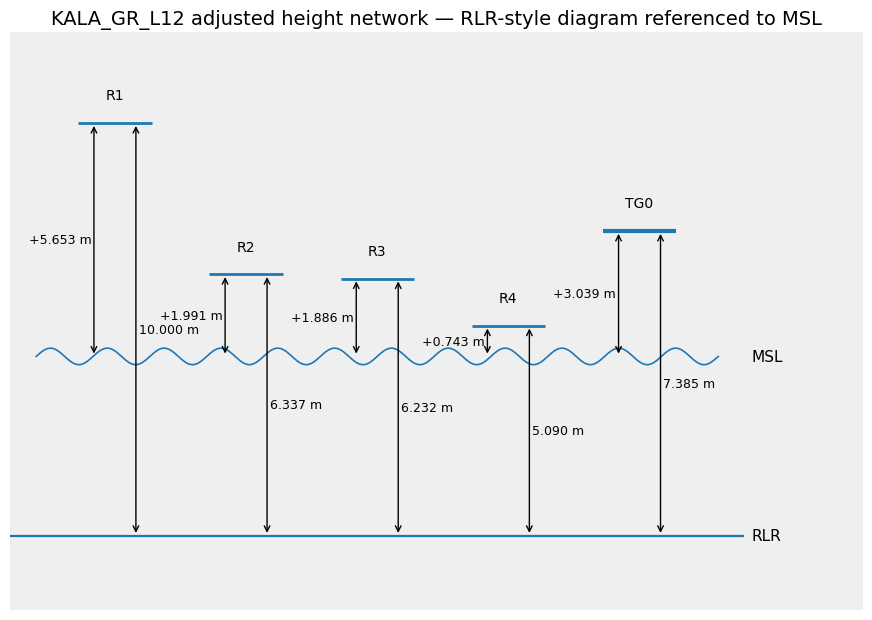

TG0 local height from Cell 8: 7.385362 m
TG0 height relative to MSL: 3.0389 m
TG0 orthometric height above EGM2008 geoid: 3.0160 m
Primary RLR benchmark: R1
Assigned RLR height of 'R1': 10.0000 m
Computed RLR level: -4.3465 m relative to MSL
Benchmarks plotted: R1, R2, R3, R4, TG0

RLR result table:


,benchmark,H_hat_m,sigma_H_m,H_above_MSL_m,H_above_RLR_m,is_fixed,is_virtual_tg0
0,R1,10.000000,0.000000,5.653493,10.000000,True,False
1,R2,6.337491,0.000595,1.990983,6.337491,False,False
2,R3,6.232411,0.000601,1.885903,6.232411,False,False
3,R4,5.089523,0.000568,0.743015,5.089523,False,False
4,TG0,7.385362,0.001623,3.038854,7.385362,False,True



TG0 target mean table:


,benchmark,H_hat_m,sigma_H_m,offset_to_TG0_m,sigma_offset_to_TG0_m,H_TG0_candidate_m,sigma_H_TG0_candidate_m,use_for_TG0_definition,note,weight
0,RADAR,7.385362,0.001623,0.0,0.0,7.385362,0.001623,True,RADAR surface,1.0



Accepted GNSSBM uncertainty table:


,run_label,benchmark_id_raw,network_benchmark_id,rtklib_to_lsq_match_type,benchmark_id,overlap_minutes,lon_deg,lat_deg,h_m,rtklib_std_h_m,cors_std_up_m,std_h_m,uncertainty_note,qc_flags,matching_status,antenna_delta_h_m,antenna_delta_e_m,antenna_delta_n_m,antenna_offset_source
0,__R41140__088A1130,__R4,R1,height_difference_user_confirmed,__R4,165.4333,28.068628,36.114064,23.7636,0.0251,0.0031,0.0253,RSS of RTKLIB scatter and CORS PPP repeatabili...,FRAGMENTED_FIXED_SOLUTION,accepted,1.414,-0.0011,0.0,RINEX_ANTENNA_DELTA_H/E/N



Geodetic datum documentation text:
Geodetic documentation of tide-gauge datum — KALA_GR_L12

Station and position
The documented tide-gauge site is Kalathos tide gauge (KALA_GR_L12), at longitude 28.06862801 deg and latitude 36.11406381 deg. The coordinate reference used for the position is: IGc20 / ITRF2020-u2024 geodetic coordinates. The reported geodetic latitude, longitude and ellipsoidal height are interpreted as WGS84 geodetic coordinates derived from IGS/ITRF XYZ coordinates using the RTKLIB/WGS84 ecef2pos convention.

GNSS reference and absolute ellipsoidal height
The main GNSS benchmark is R1. Its absolute ellipsoidal height was estimated as h = 23.7636 m ± 25.3 mm, in IGc20 / ITRF2020-u2024 at epoch 2026.31. The GNSS-derived ellipsoidal height tide system adopted in this workflow is tide_free. The geodetic ellipsoid is WGS84.

The GNSSBM height was computed using the common-CORS uncertainty model. The RTKLIB-only weighted component is 25.1 mm and the common CORS vertical com

,comparison_type,n_common_hours,comparison_epoch_start,comparison_epoch_end,tg_mean_ssh_above_egm2008_geoid_m,duacs_aligned_medsea_zos_mean_m,bias_tg_minus_model_m,std_tg_minus_model_m,rmse_m,mae_m,median_diff_m,min_diff_m,max_diff_m,pearson_r,tg_source_note,model_source_note,hourly_source_key
0,hourly absolute dynamic ocean topography,716,2026-04-24 00:00:00+00:00,2026-05-31 23:00:00+00:00,0.471517,-0.056195,0.527712,0.065644,0.531774,0.527712,0.530306,0.373397,0.660318,0.671933,TG SSH above EGM2008 geoid taken directly from...,DUACS-aligned MEDSEA zos taken from column 'me...,hourly_comparison_table



Hourly absolute SSH comparison table:


,datetime,tg_ssh_above_egm2008_geoid_m,n_tg_samples,radar_range_m,medsea_zos_raw_m,medsea_zos_duacs_aligned_m,diff_tg_minus_duacs_aligned_medsea_m
0,2026-04-24 00:00:00+00:00,0.465147,163,2.550810,-0.491841,-0.109948,0.575095
1,2026-04-24 01:00:00+00:00,0.473881,172,2.542076,-0.487437,-0.105544,0.579425
2,2026-04-24 02:00:00+00:00,0.479347,123,2.536610,-0.487246,-0.105353,0.584700
3,2026-04-24 03:00:00+00:00,0.479541,171,2.536415,-0.493648,-0.111755,0.591296
4,2026-04-24 04:00:00+00:00,0.473969,157,2.541987,-0.498074,-0.116181,0.590151
...,...,...,...,...,...,...,...
711,2026-05-31 19:00:00+00:00,0.462868,91,2.553088,-0.409462,-0.027569,0.490437
712,2026-05-31 20:00:00+00:00,0.475916,149,2.540040,-0.409941,-0.028048,0.503964
713,2026-05-31 21:00:00+00:00,0.470742,177,2.545215,-0.409565,-0.027672,0.498414
714,2026-05-31 22:00:00+00:00,0.446484,144,2.569472,-0.408565,-0.026672,0.473156


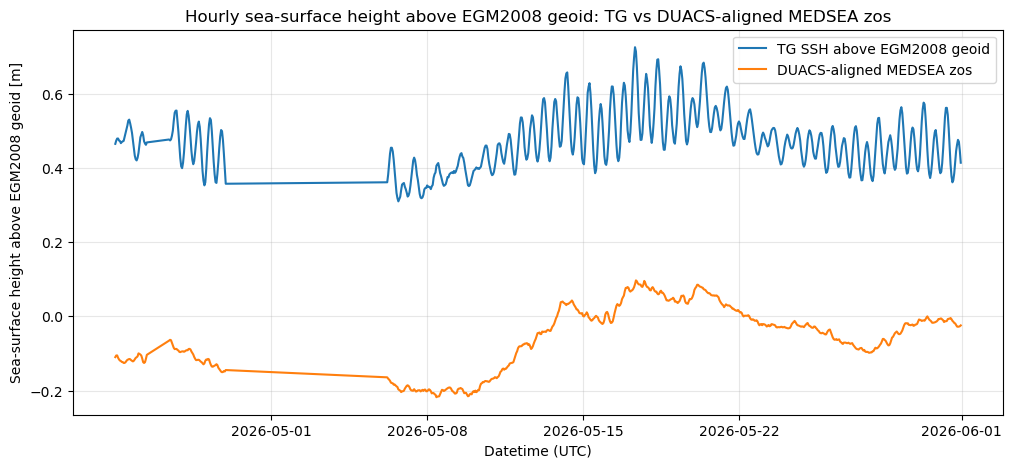


Saved outputs in datum_documentation['outputs']:
- rlr_results
- rlr_level_relative_to_msl_m
- datum_documentation_text
- tg_dynamic_topography_hourly_table
- tg_dynamic_topography_hourly_statistics_table
- tg_copernicus_hourly_table
- tg_copernicus_statistics_table


In [27]:
# === CELL 9 — RLR plot, datum documentation text, and hourly absolute SSH comparison ===
# Name: rlr_plot_and_hourly_absolute_ssh_comparison
#
# Purpose:
# - Use datum_documentation produced by Cell 8.
# - Produce:
#   (a) RLR-style plot,
#   (b) reduced benchmark-height table,
#   (c) geodetic documentation text,
#   (d) hourly comparison statistics,
#   (e) one comparison plot only:
#
#       Tide-gauge sea-surface height above EGM2008 geoid
#       vs
#       DUACS-aligned MEDSEA zos
#
# Notes:
# - TG input values are radar ranges.
# - TG SSH above geoid is computed as:
#
#       SSH_TG_above_geoid = H_TG0_above_geoid - radar_range
#
#   where H_TG0_above_geoid is the orthometric height of TG0
#   with respect to the selected EGM2008 geoid convention.
#
# - MEDSEA raw zos is aligned to DUACS using:
#
#       MEDSEA_zos_DUACS_aligned = MEDSEA_zos_raw + C_Med
#
# - No raw MEDSEA zos plot is produced.
# - No daily-difference plot is produced.
# - The comparison is hourly. If Cell 8 has not produced an hourly comparison table,
#   this cell stops with a clear error.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------
# 1) Retrieve inputs
# ------------------------------------------------------------
if "datum_documentation" not in globals() or not isinstance(datum_documentation, dict):
    raise RuntimeError("datum_documentation was not found. Run Cell 8 first.")

if "lsq" in globals() and isinstance(lsq, dict) and isinstance(lsq.get("heights", None), pd.DataFrame):
    heights_df = lsq["heights"].copy()
elif "heights" in globals() and isinstance(heights, pd.DataFrame):
    heights_df = heights.copy()
else:
    raise RuntimeError("Adjusted height network was not found. Run the LS adjustment cell first.")

required_cols = ["benchmark", "H_hat_m"]
for c in required_cols:
    if c not in heights_df.columns:
        raise RuntimeError(f"Column '{c}' was not found in adjusted heights dataframe.")

heights_df["benchmark"] = heights_df["benchmark"].astype(str).str.strip()
heights_df["H_hat_m"] = pd.to_numeric(heights_df["H_hat_m"], errors="coerce")

if "sigma_H_m" not in heights_df.columns:
    heights_df["sigma_H_m"] = np.nan
else:
    heights_df["sigma_H_m"] = pd.to_numeric(heights_df["sigma_H_m"], errors="coerce")

if "is_fixed" not in heights_df.columns:
    heights_df["is_fixed"] = False
else:
    heights_df["is_fixed"] = heights_df["is_fixed"].fillna(False).astype(bool)

heights_df = heights_df.drop_duplicates(subset=["benchmark"]).reset_index(drop=True)

bench = datum_documentation["benchmarks"]
computed = datum_documentation["computed_heights"]
station = datum_documentation["station"]
gnss = datum_documentation["gnss_solution"]
transfer = datum_documentation["local_height_transfer"]
tide_red = datum_documentation["tide_system_reduction"]
geoid = datum_documentation["geoid"]
mdot = datum_documentation["mdot"]
comparison = datum_documentation.get("tg_model_comparison", {"enabled": False})

main_gnssbm = bench["main_gnssbm"]
tg_reference_benchmark = bench.get("tg_reference_benchmark", "T2")
tg_target_benchmarks = bench.get("tg_target_benchmarks", [])
tg0_point_name = bench.get("tg0_point_name", "TG0")
rlr_primary_benchmark = bench["rlr_primary_benchmark"]
rlr_primary_height_m = float(bench["rlr_primary_height_m"])
plot_benchmarks = bench.get("plot_benchmarks", [main_gnssbm, "R2", "R3", "R4", "R5", tg0_point_name])

tg0_height_relative_to_msl_m = float(computed["tg0_height_relative_to_msl_m"])

# Generalized Cell 8 fields
gnss_height_tide_system = computed.get(
    "gnss_height_tide_system",
    gnss.get("height_tide_system", gnss.get("tide_system_input", "unknown"))
)
geoid_height_tide_system = computed.get(
    "geoid_height_tide_system",
    geoid.get("normalized_tide_system", geoid.get("tide_system", "unknown"))
)

tg0_h_gnss_tide_system_m = float(computed.get(
    "tg0_h_gnss_tide_system_m",
    computed.get("tg0_h_tide_free_m", np.nan)
))
sigma_tg0_h_gnss_tide_system_m = float(computed.get(
    "sigma_tg0_h_gnss_tide_system_m",
    computed.get("sigma_tg0_h_tide_free_m", np.nan)
))

height_tide_system_correction_m = float(computed.get(
    "height_tide_system_correction_m",
    tide_red.get("correction_m", 0.0)
))

tg0_h_geoid_tide_system_m = float(computed.get(
    "tg0_h_geoid_tide_system_m",
    computed.get("tg0_h_zero_tide_m", np.nan)
))
sigma_tg0_h_geoid_tide_system_m = float(computed.get(
    "sigma_tg0_h_geoid_tide_system_m",
    computed.get("sigma_tg0_h_zero_tide_m", np.nan)
))

N_geoid_m = float(computed.get(
    "N_geoid_m",
    geoid.get("N_geoid_m", geoid.get("N_zero_tide_m", np.nan))
))

tg0_H_orthometric_m = float(computed["tg0_H_orthometric_m"])
sigma_tg0_H_orthometric_m = float(computed.get("sigma_tg0_H_orthometric_m", np.nan))

# Cell 8 structure: TG0 is defined from target mean + offset.
if "target_mean_local_height_m" in transfer and "target_mean_to_tg0_offset_m" in transfer:
    H_tg0_local = (
        float(transfer["target_mean_local_height_m"])
        + float(transfer["target_mean_to_tg0_offset_m"])
    )
else:
    row_ref = heights_df[heights_df["benchmark"] == tg_reference_benchmark]
    if row_ref.empty:
        raise RuntimeError("Could not reconstruct local TG0 height from datum_documentation.")
    H_tg0_local = (
        float(row_ref["H_hat_m"].iloc[0])
        + float(transfer["tg_reference_to_tg0_offset_m"])
    )

available_benchmarks = heights_df["benchmark"].sort_values().tolist()

def _get_Hhat(bm):
    row = heights_df[heights_df["benchmark"] == str(bm).strip()]
    if row.empty:
        raise ValueError(f"Benchmark not found: {bm}")
    H = float(row["H_hat_m"].iloc[0])
    sig = float(row["sigma_H_m"].iloc[0]) if np.isfinite(row["sigma_H_m"].iloc[0]) else np.nan
    is_fixed = bool(row["is_fixed"].iloc[0]) if "is_fixed" in row.columns else False
    return H, sig, is_fixed

H_rlr_primary_local, _, _ = _get_Hhat(rlr_primary_benchmark)

# ------------------------------------------------------------
# 2) Build MSL/RLR-reduced benchmark table
# ------------------------------------------------------------
heights_df["H_above_MSL_m"] = (
    tg0_height_relative_to_msl_m
    + (heights_df["H_hat_m"] - H_tg0_local)
)

H_rlr_primary_above_MSL_m = float(
    heights_df.loc[heights_df["benchmark"] == rlr_primary_benchmark, "H_above_MSL_m"].iloc[0]
)

rlr_y = H_rlr_primary_above_MSL_m - rlr_primary_height_m
heights_df["H_above_RLR_m"] = heights_df["H_above_MSL_m"] - rlr_y
heights_df["is_virtual_tg0"] = False

virtual_tg0_sigma_m = float(transfer.get(
    "sigma_target_mean_local_height_m",
    transfer.get("sigma_dh_gnssbm_to_tg0_m", np.nan)
))

virtual_tg0 = pd.DataFrame([{
    "benchmark": tg0_point_name,
    "H_hat_m": H_tg0_local,
    "sigma_H_m": virtual_tg0_sigma_m,
    "is_fixed": False,
    "H_above_MSL_m": tg0_height_relative_to_msl_m,
    "H_above_RLR_m": tg0_height_relative_to_msl_m - rlr_y,
    "is_virtual_tg0": True,
}])

heights_plot_source = pd.concat([heights_df, virtual_tg0], ignore_index=True)

plot_benchmarks = [str(x).strip() for x in plot_benchmarks if str(x).strip() != ""]
valid_plot_benchmarks = [
    b for b in plot_benchmarks
    if b in heights_plot_source["benchmark"].astype(str).tolist()
]

if len(valid_plot_benchmarks) == 0:
    valid_plot_benchmarks = heights_plot_source["benchmark"].astype(str).tolist()

missing_plot_benchmarks = sorted(set(plot_benchmarks) - set(valid_plot_benchmarks))
if missing_plot_benchmarks:
    print("Plot benchmark(s) not found and skipped:", ", ".join(missing_plot_benchmarks))

plot_df = heights_plot_source[
    heights_plot_source["benchmark"].astype(str).isin(valid_plot_benchmarks)
].copy()

order_map = {b: i for i, b in enumerate(valid_plot_benchmarks)}
plot_df["plot_order"] = plot_df["benchmark"].map(order_map)
plot_df = plot_df.sort_values("plot_order").reset_index(drop=True)
plot_df["x"] = np.arange(len(plot_df), dtype=float)

# ------------------------------------------------------------
# 3) RLR-style plot — unchanged
# ------------------------------------------------------------
n_pts = len(plot_df)
msl_y = 0.0
min_y = float(min(plot_df["H_above_MSL_m"].min(), rlr_y, msl_y))
max_y = float(max(plot_df["H_above_MSL_m"].max(), rlr_y, msl_y))
span_y = max(max_y - min_y, 1.0)

fig_width = max(11, 1.55 * n_pts + 2.5)
fig, ax = plt.subplots(figsize=(fig_width, 7.6))
ax.set_facecolor("#efefef")

wave_x = np.linspace(-0.6, n_pts - 0.4, 800)
wave_amp = 0.02 * span_y
wave_y = msl_y + wave_amp * np.sin(
    2 * np.pi * 12 * (wave_x - wave_x.min()) / (wave_x.max() - wave_x.min() + 1e-12)
)

ax.plot(wave_x, wave_y, linewidth=1.2, zorder=1)
ax.hlines(rlr_y, -0.8, n_pts - 0.2, linewidth=1.6, zorder=1)

seg_half = 0.28
label_dy = 0.05 * span_y
txt_fs = 10
val_fs = 9

for _, r in plot_df.iterrows():
    x = float(r["x"])
    y = float(r["H_above_MSL_m"])
    bm = str(r["benchmark"]).strip()
    is_virtual = bool(r.get("is_virtual_tg0", False))

    lw = 3.0 if is_virtual else 2.0
    ax.hlines(y, x - seg_half, x + seg_half, linewidth=lw, zorder=3)

    ax.text(
        x,
        y + label_dy,
        bm,
        ha="center",
        va="bottom",
        fontsize=txt_fs,
        zorder=4
    )

    x_left = x - 0.16
    ax.annotate(
        "",
        xy=(x_left, y),
        xytext=(x_left, msl_y),
        arrowprops=dict(arrowstyle="<->", lw=1.0),
        zorder=2
    )
    ax.text(
        x_left - 0.02,
        0.5 * (y + msl_y),
        f"{y:+.3f} m",
        ha="right",
        va="center",
        fontsize=val_fs,
        zorder=4
    )

    x_right = x + 0.16
    ax.annotate(
        "",
        xy=(x_right, y),
        xytext=(x_right, rlr_y),
        arrowprops=dict(arrowstyle="<->", lw=1.0),
        zorder=2
    )
    ax.text(
        x_right + 0.02,
        0.5 * (y + rlr_y),
        f"{float(r['H_above_RLR_m']):.3f} m",
        ha="left",
        va="center",
        fontsize=val_fs,
        zorder=4
    )

ax.text(n_pts - 0.15, msl_y, "MSL", ha="left", va="center", fontsize=11, zorder=4)
ax.text(n_pts - 0.15, rlr_y, "RLR", ha="left", va="center", fontsize=11, zorder=4)

title = (
    f"{station.get('station_code', '')} adjusted height network — "
    "RLR-style diagram referenced to MSL"
)
ax.set_title(title, fontsize=14)

ax.set_xlim(-0.8, n_pts - 0.2 + 0.9)
ax.set_ylim(min(rlr_y, min_y) - 0.18 * span_y, max_y + 0.22 * span_y)
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(bottom=0.12)
plt.show()

# ------------------------------------------------------------
# 4) Output tables
# ------------------------------------------------------------
cols_out = [
    "benchmark",
    "H_hat_m",
    "sigma_H_m",
    "H_above_MSL_m",
    "H_above_RLR_m",
    "is_fixed",
    "is_virtual_tg0",
]
rlr_results = plot_df[cols_out].copy().reset_index(drop=True)

print(f"TG0 local height from Cell 8: {H_tg0_local:.6f} m")
print(f"TG0 height relative to MSL: {tg0_height_relative_to_msl_m:.4f} m")
print(f"TG0 orthometric height above EGM2008 geoid: {tg0_H_orthometric_m:.4f} m")
print(f"Primary RLR benchmark: {rlr_primary_benchmark}")
print(f"Assigned RLR height of '{rlr_primary_benchmark}': {rlr_primary_height_m:.4f} m")
print(f"Computed RLR level: {rlr_y:.4f} m relative to MSL")
print("Benchmarks plotted:", ", ".join(plot_df["benchmark"].astype(str).tolist()))

print("\nRLR result table:")
display(rlr_results)

if isinstance(transfer.get("target_mean_table", None), pd.DataFrame):
    print("\nTG0 target mean table:")
    display(transfer["target_mean_table"])

if isinstance(gnss.get("accepted_gnssbm_uncertainty_table", None), pd.DataFrame):
    print("\nAccepted GNSSBM uncertainty table:")
    display(gnss["accepted_gnssbm_uncertainty_table"])

# ------------------------------------------------------------
# 5) Datum documentation text
# ------------------------------------------------------------
ws = gnss.get("weighted_solution", {})
sigma_rtklib_weighted_m = ws.get("sigma_h_rtklib_weighted_m", np.nan)
sigma_cors_common_m = ws.get("sigma_h_cors_common_m", np.nan)
uncertainty_model = ws.get("uncertainty_model", "Not available.")

target_benchmarks_text = ", ".join(tg_target_benchmarks) if tg_target_benchmarks else "not available"

medsea_zos_raw_m = mdot.get("medsea_zos_raw_m", np.nan)
apply_alignment = bool(mdot.get("apply_medsea_to_duacs_alignment", False))
alignment_offset_m = float(mdot.get("medsea_to_duacs_alignment_offset_m", 0.0))
alignment_std_m = float(mdot.get("medsea_to_duacs_alignment_offset_std_m", 0.0))
alignment_source = mdot.get("medsea_to_duacs_alignment_source", "Not available.")
mdot_value_description = mdot.get("mdot_value_description", "Not available.")
mdot_alignment_status = mdot.get("mdot_alignment_status", "not specified")

datum_documentation_text = f"""
Geodetic documentation of tide-gauge datum — {station.get('station_code')}

Station and position
The documented tide-gauge site is {station.get('station_name')} ({station.get('station_code')}), at longitude {station.get('lon_deg'):.8f} deg and latitude {station.get('lat_deg'):.8f} deg. The coordinate reference used for the position is: {station.get('coordinate_reference')}. The reported geodetic latitude, longitude and ellipsoidal height are interpreted as WGS84 geodetic coordinates derived from IGS/ITRF XYZ coordinates using the RTKLIB/WGS84 ecef2pos convention.

GNSS reference and absolute ellipsoidal height
The main GNSS benchmark is {main_gnssbm}. Its absolute ellipsoidal height was estimated as h = {gnss['gnssbm_h_m']:.4f} m ± {1000.0 * gnss['sigma_gnssbm_h_m']:.1f} mm, in {gnss['frame']} at epoch {gnss['gnss_epoch']}. The GNSS-derived ellipsoidal height tide system adopted in this workflow is {gnss_height_tide_system}. The geodetic ellipsoid is {gnss.get('geodetic_ellipsoid', station.get('geodetic_ellipsoid', 'WGS84'))}.

The GNSSBM height was computed using the common-CORS uncertainty model. The RTKLIB-only weighted component is {1000.0 * sigma_rtklib_weighted_m:.1f} mm and the common CORS vertical component is {1000.0 * sigma_cors_common_m:.1f} mm. The adopted final uncertainty is the RSS combination of these two components. Uncertainty model note: {uncertainty_model}

Local height transfer to TG0
TG0 was defined from the weighted mean of the local target benchmarks {target_benchmarks_text}. The target-mean local height is {transfer['target_mean_local_height_m']:.4f} m. The adopted target-mean to TG0 offset is {transfer['target_mean_to_tg0_offset_m']:.4f} m, defined as H_TG0 - H_target_mean. The resulting local height transfer from {main_gnssbm} to TG0 is ΔH = {transfer['dh_gnssbm_to_tg0_m']:.4f} m ± {1000.0 * transfer['sigma_dh_gnssbm_to_tg0_m']:.1f} mm.

Permanent-tide-system compatibility
The ellipsoidal height of TG0 in the GNSS height tide system ({gnss_height_tide_system}) is h = {tg0_h_gnss_tide_system_m:.4f} m ± {1000.0 * sigma_tg0_h_gnss_tide_system_m:.1f} mm. The geoid grid tide system is {geoid_height_tide_system}. The applied correction from the GNSS height tide system to the geoid tide system is {height_tide_system_correction_m:.4f} m. Method: {tide_red.get('method', 'not specified')}. Formula: {tide_red.get('formula', 'not specified')}. The ellipsoidal height used in H = h - N is h = {tg0_h_geoid_tide_system_m:.4f} m ± {1000.0 * sigma_tg0_h_geoid_tide_system_m:.1f} mm.

Geoid model
The geoid height used for the reduction is N = {N_geoid_m:.4f} m, interpolated from model/grid {geoid.get('model_name')} using method {geoid.get('interpolation_method')}. The geoid metadata are: functional={geoid.get('functional')}, reference system={geoid.get('reference_system')}, tide system={geoid.get('tide_system')}, zero-degree term={geoid.get('zero_degree_term')}, unit={geoid.get('unit')}. The orthometric height of TG0 is therefore H = h_in_geoid_tide_system - N_geoid = {computed['tg0_H_orthometric_m']:.4f} m ± {1000.0 * computed['sigma_tg0_H_orthometric_m']:.1f} mm.

Model-based MSL reference
The raw MEDSEA/NEMO zos mean over the reference period {mdot.get('mdot_epoch')} is {medsea_zos_raw_m:.4f} m. MEDSEA/NEMO zos is not treated here as a strict geodetic MDOT/MDT realization, because its reference surface follows the NEMO ocean-model formulation rather than a fully documented WGS84/EGM2008 geodetic geoid with explicit W0, permanent-tide system and zero-degree term.

MEDSEA-to-DUACS empirical alignment
Alignment applied: {apply_alignment}. Alignment status: {mdot_alignment_status}. The adopted Mediterranean-wide empirical alignment offset is C_Med = {alignment_offset_m:.4f} m, with spatial standard deviation {alignment_std_m:.4f} m. Alignment source: {alignment_source}. The model-based value used for the MSL reduction is {mdot['mdot_value_m']:.4f} m. Description: {mdot_value_description}

The tide-gauge zero TG0 height relative to mean sea level is computed as H_MSL = H_orthometric - model_based_sea_surface_reference = {computed['tg0_height_relative_to_msl_m']:.4f} m ± {1000.0 * computed['sigma_tg0_height_relative_to_msl_m']:.1f} mm.

RLR representation
For the RLR-style representation, the primary RLR benchmark is {rlr_primary_benchmark}, assigned the local/RLR height {rlr_primary_height_m:.4f} m. The resulting RLR level is {rlr_y:.4f} m relative to MSL.
""".strip()

print("\nGeodetic datum documentation text:")
print(datum_documentation_text)

# Preserve any existing outputs instead of replacing everything.
datum_documentation.setdefault("outputs", {})
datum_documentation["outputs"]["rlr_results"] = rlr_results
datum_documentation["outputs"]["rlr_level_relative_to_msl_m"] = float(rlr_y)
datum_documentation["outputs"]["datum_documentation_text"] = datum_documentation_text

# ------------------------------------------------------------
# 6) Hourly absolute SSH comparison
# ------------------------------------------------------------
def _first_existing_key(dct, keys):
    if not isinstance(dct, dict):
        return None
    for k in keys:
        if k in dct and isinstance(dct[k], pd.DataFrame) and len(dct[k]) > 0:
            return k
    return None

def _find_time_col(df):
    candidates = [
        "datetime", "Datetime", "time", "Time", "date", "Date",
        "timestamp", "Timestamp", "valid_time", "time_utc"
    ]
    for c in candidates:
        if c in df.columns:
            return c
    for c in df.columns:
        cl = str(c).lower()
        if "time" in cl or "date" in cl:
            return c
    return None

def _find_numeric_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce")
            if s.notna().any():
                return c
    for c in df.columns:
        cl = str(c).lower()
        for cand in candidates:
            if str(cand).lower() in cl:
                s = pd.to_numeric(df[c], errors="coerce")
                if s.notna().any():
                    return c
    return None

def _is_hourly_or_subhourly(times):
    t = pd.to_datetime(pd.Series(times), errors="coerce")
    t = t.dropna().sort_values().drop_duplicates()
    if len(t) < 3:
        return True
    dt_sec = t.diff().dropna().dt.total_seconds()
    if len(dt_sec) == 0:
        return True
    median_dt_sec = float(dt_sec.median())
    return median_dt_sec <= 3700.0


def _standardize_hourly_comparison_table(df):
    out = df.copy()

    time_col = _find_time_col(out)
    if time_col is None:
        raise RuntimeError("No time/date column found in hourly comparison table.")

    out["datetime"] = pd.to_datetime(out[time_col], errors="coerce", utc=True)

    # ------------------------------------------------------------
    # TG SSH above EGM2008 geoid
    # ------------------------------------------------------------
    tg_ssh_col = _find_numeric_col(
        out,
        [
            "tg_ssh_above_egm2008_geoid_m",
            "tg_ssh_above_geoid_m",
            "tg_dynamic_topography_m",
        ]
    )

    radar_col = _find_numeric_col(
        out,
        [
            "radar_range_m",
            "range_m",
            "tg_radar_range_m",
            "water_range_m",
            "raw_radar_range_m",
            "tg_range_m",
        ]
    )

    tg_sl_col = _find_numeric_col(
        out,
        [
            "tg_sea_level_m",
            "sea_level_m",
            "tg_hourly_m",
            "tg_daily_m",
            "tg_sl_m",
            "tg_value_m",
        ]
    )

    if tg_ssh_col is not None:
        out["tg_ssh_above_egm2008_geoid_m"] = pd.to_numeric(
            out[tg_ssh_col],
            errors="coerce"
        )
        if radar_col is not None:
            out["radar_range_m"] = pd.to_numeric(out[radar_col], errors="coerce")
        else:
            out["radar_range_m"] = np.nan

        tg_source_note = (
            f"TG SSH above EGM2008 geoid taken directly from column '{tg_ssh_col}'."
        )

    elif radar_col is not None:
        out["radar_range_m"] = pd.to_numeric(out[radar_col], errors="coerce")
        out["tg_ssh_above_egm2008_geoid_m"] = (
            tg0_H_orthometric_m - out["radar_range_m"]
        )

        tg_source_note = (
            f"TG SSH above EGM2008 geoid computed as TG0 orthometric height "
            f"({tg0_H_orthometric_m:.6f} m) minus radar range column '{radar_col}'."
        )

    elif tg_sl_col is not None:
        out["radar_range_m"] = np.nan
        out["tg_sl_relative_to_msl_m"] = pd.to_numeric(out[tg_sl_col], errors="coerce")
        model_reference_m = float(mdot["mdot_value_m"])

        out["tg_ssh_above_egm2008_geoid_m"] = (
            out["tg_sl_relative_to_msl_m"] + model_reference_m
        )

        tg_source_note = (
            f"TG SSH above EGM2008 geoid computed from sea level column '{tg_sl_col}' "
            f"plus model-based MSL reference {model_reference_m:.6f} m. "
            f"Radar range column was not available."
        )

    else:
        raise RuntimeError(
            "No TG SSH, radar range, or TG sea-level column was found. "
            "Expected a column such as tg_ssh_above_egm2008_geoid_m, "
            "radar_range_m/range_m, or tg_sea_level_m."
        )

    # ------------------------------------------------------------
    # MEDSEA/NEMO zos, DUACS-aligned
    # ------------------------------------------------------------
    raw_model_col = _find_numeric_col(
        out,
        [
            "medsea_zos_raw_m",
            "raw_medsea_zos_m",
            "model_hourly_raw_medsea_zos_m",
            "model_daily_raw_medsea_zos_m",
            "model_raw_medsea_zos_m",
            "model_hourly_m",
            "model_daily_m",
            "model_m",
            "zos_m",
        ]
    )

    aligned_model_col = _find_numeric_col(
        out,
        [
            "medsea_zos_duacs_aligned_m",
            "duacs_aligned_medsea_zos_m",
            "model_hourly_duacs_aligned_medsea_zos_m",
            "model_daily_duacs_aligned_medsea_zos_m",
            "model_duacs_aligned_medsea_zos_m",
        ]
    )

    if aligned_model_col is not None:
        out["medsea_zos_duacs_aligned_m"] = pd.to_numeric(
            out[aligned_model_col],
            errors="coerce"
        )

        if raw_model_col is not None:
            out["medsea_zos_raw_m"] = pd.to_numeric(out[raw_model_col], errors="coerce")
        else:
            out["medsea_zos_raw_m"] = (
                out["medsea_zos_duacs_aligned_m"] - alignment_offset_m
            )

        model_source_note = (
            f"DUACS-aligned MEDSEA zos taken from column '{aligned_model_col}'."
        )

    elif raw_model_col is not None:
        out["medsea_zos_raw_m"] = pd.to_numeric(out[raw_model_col], errors="coerce")
        out["medsea_zos_duacs_aligned_m"] = (
            out["medsea_zos_raw_m"] + alignment_offset_m
        )

        model_source_note = (
            f"DUACS-aligned MEDSEA zos computed as raw model column '{raw_model_col}' "
            f"plus C_Med = {alignment_offset_m:.6f} m."
        )

    else:
        raise RuntimeError(
            "No MEDSEA zos model column was found. "
            "Expected medsea_zos_raw_m or medsea_zos_duacs_aligned_m."
        )

    # ------------------------------------------------------------
    # Difference: comparable quantities only
    # ------------------------------------------------------------
    out["diff_tg_minus_duacs_aligned_medsea_m"] = (
        out["tg_ssh_above_egm2008_geoid_m"]
        - out["medsea_zos_duacs_aligned_m"]
    )

    out = out.dropna(
        subset=[
            "datetime",
            "tg_ssh_above_egm2008_geoid_m",
            "medsea_zos_duacs_aligned_m",
        ]
    ).sort_values("datetime").reset_index(drop=True)

    if out.empty:
        raise RuntimeError("Hourly comparison table became empty after numeric/time filtering.")

    return out, tg_source_note, model_source_note


def _make_hourly_comparison_from_available_sources():
    candidate_keys = [
        "hourly_comparison_table",
        "comparison_hourly_table",
        "tg_model_hourly_comparison_table",
        "hourly_table",
        "comparison_table",
    ]

    key = _first_existing_key(comparison, candidate_keys)

    if key is None:
        raise RuntimeError(
            "No hourly TG/Copernicus comparison table was found in datum_documentation['tg_model_comparison'].\n"
            "Run Cell 8 with hourly comparison output enabled before running Cell 9."
        )

    source_df = comparison[key].copy()

    source_time_col = _find_time_col(source_df)
    if source_time_col is None:
        raise RuntimeError(f"Comparison table '{key}' has no time/date column.")

    if not _is_hourly_or_subhourly(source_df[source_time_col]):
        raise RuntimeError(
            f"The available comparison table '{key}' does not appear to be hourly/sub-hourly.\n"
            "Run Cell 8 with hourly MEDSEA comparison selected."
        )

    comp_hourly, tg_note, model_note = _standardize_hourly_comparison_table(source_df)

    return comp_hourly, key, tg_note, model_note

hourly_comparison_table, hourly_source_key, tg_source_note, model_source_note = (
    _make_hourly_comparison_from_available_sources()
)

def _stats_for_hourly_dynamic_topography(comp):
    d = comp["diff_tg_minus_duacs_aligned_medsea_m"].to_numpy(dtype=float)
    tg = comp["tg_ssh_above_egm2008_geoid_m"].to_numpy(dtype=float)
    model = comp["medsea_zos_duacs_aligned_m"].to_numpy(dtype=float)

    if len(comp) > 1 and np.std(tg) > 0 and np.std(model) > 0:
        pearson_r = float(np.corrcoef(tg, model)[0, 1])
    else:
        pearson_r = np.nan

    return {
        "comparison_type": "hourly absolute dynamic ocean topography",
        "n_common_hours": int(len(comp)),
        "comparison_epoch_start": str(pd.to_datetime(comp["datetime"]).min()),
        "comparison_epoch_end": str(pd.to_datetime(comp["datetime"]).max()),
        "tg_mean_ssh_above_egm2008_geoid_m": float(np.mean(tg)),
        "duacs_aligned_medsea_zos_mean_m": float(np.mean(model)),
        "bias_tg_minus_model_m": float(np.mean(d)),
        "std_tg_minus_model_m": float(np.std(d, ddof=1)) if len(d) > 1 else np.nan,
        "rmse_m": float(np.sqrt(np.mean(d**2))),
        "mae_m": float(np.mean(np.abs(d))),
        "median_diff_m": float(np.median(d)),
        "min_diff_m": float(np.min(d)),
        "max_diff_m": float(np.max(d)),
        "pearson_r": pearson_r,
        "tg_source_note": tg_source_note,
        "model_source_note": model_source_note,
        "hourly_source_key": hourly_source_key,
    }

hourly_comparison_stats = _stats_for_hourly_dynamic_topography(hourly_comparison_table)
hourly_comparison_stats_df = pd.DataFrame([hourly_comparison_stats])

print("\nHourly absolute SSH comparison metadata:")
print(f"Source table key: {hourly_source_key}")
print(tg_source_note)
print(model_source_note)
print(f"MEDSEA-to-DUACS alignment offset C_Med = {alignment_offset_m:.6f} m")

print("\nHourly absolute SSH comparison statistics:")
display(hourly_comparison_stats_df)

print("\nHourly absolute SSH comparison table:")
display(hourly_comparison_table)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    hourly_comparison_table["datetime"],
    hourly_comparison_table["tg_ssh_above_egm2008_geoid_m"],
    label="TG SSH above EGM2008 geoid"
)

ax.plot(
    hourly_comparison_table["datetime"],
    hourly_comparison_table["medsea_zos_duacs_aligned_m"],
    label="DUACS-aligned MEDSEA zos"
)

ax.set_title("Hourly sea-surface height above EGM2008 geoid: TG vs DUACS-aligned MEDSEA zos")
ax.set_xlabel("Datetime (UTC)")
ax.set_ylabel("Sea-surface height above EGM2008 geoid [m]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# ------------------------------------------------------------
# 7) Save outputs
# ------------------------------------------------------------
datum_documentation["outputs"]["tg_dynamic_topography_hourly_table"] = hourly_comparison_table
datum_documentation["outputs"]["tg_dynamic_topography_hourly_statistics_table"] = hourly_comparison_stats_df
datum_documentation["outputs"]["tg_dynamic_topography_hourly_plot_description"] = (
    "Hourly comparison of tide-gauge sea-surface height above EGM2008 geoid "
    "against DUACS-aligned MEDSEA zos. TG values are derived from radar range "
    "as H_TG0_above_geoid - radar_range when radar range is available."
)

# Backward-compatible aliases for report-builder cells.
datum_documentation["outputs"]["tg_copernicus_hourly_table"] = hourly_comparison_table
datum_documentation["outputs"]["tg_copernicus_statistics_table"] = hourly_comparison_stats_df

print("\nSaved outputs in datum_documentation['outputs']:")
print("- rlr_results")
print("- rlr_level_relative_to_msl_m")
print("- datum_documentation_text")
print("- tg_dynamic_topography_hourly_table")
print("- tg_dynamic_topography_hourly_statistics_table")
print("- tg_copernicus_hourly_table")
print("- tg_copernicus_statistics_table")

## 2D horizontal network adjustment (N, E or lat, lon)

These cells extend the notebook from the vertical-only solution to an optional **2D horizontal adjustment**.

**Important model requirement:** a horizontal solution is possible only if the input workbook contains a horizontal observation, i.e. a **local horizontal direction** (`Hz`) or a **global azimuth/bearing** column.  
The existing vertical workflow alone (`from`, `to`, `V_gon`, `slope_m`, `HI`, `HT`) is **not sufficient** for unique planimetric coordinates.

**Observation model used here**
- Horizontal distance is computed as  
  `HD = slope * sin(Z)`  
  where `Z = V_gon * π / 200`
- Optional planimetric observations:
  - `hz_local`: local horizontal directions from each occupied station, with one unknown orientation parameter per setup station
  - `azimuth_global`: global azimuth/bearing observations, with no station orientation unknowns

**Datum requirements**
- `hz_local` mode: at least **2 fixed points** with known coordinates
- `azimuth_global` mode: at least **1 fixed point** with known coordinates

**Approximate coordinates**
- Because the 2D adjustment is nonlinear, approximate coordinates are required for **all** points before the solver cell is run.
- You may provide them either as:
  - `N_m`, `E_m`, or
  - `lat_deg`, `lon_deg`  
    In that case the solver converts them internally to a local EN frame using an azimuthal equidistant projection.

## Optional 2D Step 1 — Detect horizontal observations and compute horizontal distance

This cell starts the optional 2D extension of the notebook.

**Main role**
- detect horizontal-direction information in the workbook,
- parse the relevant angular field,
- compute horizontal distance from slope distance and zenith angle,
- build the planimetric observation dataframe `obs_xy`.

In [11]:
# === Optional 2D Step 1 — Detect horizontal observations and compute horizontal distance ===
# Name: optional_xy_prepare_observations
# Revised:
# - Prevents many-to-many merge inflation between obs and df_raw
# - Uses occurrence index within identical key groups for a deterministic 1-to-1 match
# - Computes horizontal distance HD = slope * sin(Z)
# - Builds planimetric observation table obs_xy safely

import numpy as np
import pandas as pd

def _find_col(df, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None

def _parse_float_local(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in ["", "-", "—", "–", "nan", "NaN", "None"]:
        return np.nan
    s = s.replace(",", ".")
    token = s.split()[0]
    try:
        return float(token)
    except Exception:
        import re
        m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
        return float(m.group(0)) if m else np.nan

def _angle_unit_from_name(colname):
    if colname is None:
        return None
    s = str(colname).lower()
    if ("deg" in s) or ("°" in s):
        return "deg"
    return "gon"

# ------------------------------------------------------------
# Detect candidate horizontal-angle columns
# ------------------------------------------------------------
col_hz = _find_col(df_raw, [
    "Hz [gon]", "Hz(gon)", "Hz", "Horizontal Direction [gon]", "Horizontal Direction",
    "Direction [gon]", "Direction", "Hz [deg]", "Direction [deg]"
])

col_az = _find_col(df_raw, [
    "Azimuth [gon]", "Azimuth", "Bearing [gon]", "Bearing",
    "Azimuth [deg]", "Bearing [deg]"
])

unit_hz = _angle_unit_from_name(col_hz)
unit_az = _angle_unit_from_name(col_az)

# ------------------------------------------------------------
# Build raw-side comparison table
# ------------------------------------------------------------
tmp_raw = df_raw.copy()

col_from_raw = _find_col(df_raw, ["From Station", "From", "Station", "Station Name", "Setup Station"])
col_to_raw   = _find_col(df_raw, ["To", "Target", "To Station", "Point", "Sight To"])
col_face_raw = _find_col(df_raw, ["Face", "FACE"])
col_v_raw    = _find_col(df_raw, ["V [gon]", "V(gon)", "V", "Zenith [gon]", "Zenith", "Z [gon]"])
col_sd_raw   = _find_col(df_raw, ["Slope Dist. [m]", "Slope Dist [m]", "Slope Distance [m]", "Slope [m]", "SD [m]"])
col_ht_raw   = _find_col(df_raw, ["Target Height [m]", "Target Height", "HT [m]", "Prism Height [m]", "Reflector Height [m]"])

tmp_raw["_from"]    = tmp_raw[col_from_raw].astype(str).str.strip()
tmp_raw["_to"]      = tmp_raw[col_to_raw].astype(str).str.strip()
tmp_raw["_face"]    = tmp_raw[col_face_raw].astype(str).str.strip().str.upper()
tmp_raw["_V_gon"]   = tmp_raw[col_v_raw].apply(_parse_float_local)
tmp_raw["_slope_m"] = tmp_raw[col_sd_raw].apply(_parse_float_local)
tmp_raw["_HI_m"]    = tmp_raw[config["hi_col"]].apply(_parse_float_local)
tmp_raw["_HT_m"]    = tmp_raw[col_ht_raw].apply(_parse_float_local)

raw_key_cols = ["_from", "_to", "_face", "_V_gon", "_slope_m", "_HI_m", "_HT_m"]

raw_cmp = tmp_raw[raw_key_cols].copy()
raw_cmp["raw_row_id_xy"] = np.arange(len(raw_cmp), dtype=int)

if col_hz is not None:
    raw_cmp["Hz_raw"] = tmp_raw[col_hz].apply(_parse_float_local)

if col_az is not None:
    raw_cmp["Az_raw"] = tmp_raw[col_az].apply(_parse_float_local)

# Occurrence index INSIDE each identical raw key
raw_cmp["_match_seq_xy"] = raw_cmp.groupby(raw_key_cols, dropna=False).cumcount()

# ------------------------------------------------------------
# Build obs-side table
# ------------------------------------------------------------
obs_xy = obs.copy().reset_index(drop=True)

# Drop stale columns if the cell is rerun
for c in ["Hz_raw", "Az_raw", "raw_row_id_xy", "_match_seq_xy", "obs_id_xy"]:
    if c in obs_xy.columns:
        obs_xy = obs_xy.drop(columns=c)

obs_xy["_from"]    = obs_xy["from"].astype(str).str.strip()
obs_xy["_to"]      = obs_xy["to"].astype(str).str.strip()
obs_xy["_face"]    = obs_xy["face"].astype(str).str.strip().str.upper()
obs_xy["_V_gon"]   = pd.to_numeric(obs_xy["V_gon"], errors="coerce")
obs_xy["_slope_m"] = pd.to_numeric(obs_xy["slope_m"], errors="coerce")
obs_xy["_HI_m"]    = pd.to_numeric(obs_xy["HI_m"], errors="coerce")
obs_xy["_HT_m"]    = pd.to_numeric(obs_xy["HT_m"], errors="coerce")

# Occurrence index INSIDE each identical obs key
obs_xy["_match_seq_xy"] = obs_xy.groupby(raw_key_cols, dropna=False).cumcount()

# ------------------------------------------------------------
# Safe 1-to-1 merge (prevents row multiplication)
# ------------------------------------------------------------
merge_cols = raw_key_cols + ["_match_seq_xy"]

obs_xy = obs_xy.merge(
    raw_cmp[merge_cols + ["raw_row_id_xy"] + ([ "Hz_raw" ] if "Hz_raw" in raw_cmp.columns else []) + ([ "Az_raw" ] if "Az_raw" in raw_cmp.columns else [])],
    on=merge_cols,
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# Horizontal distance from zenith angle
# ------------------------------------------------------------
if "Z_rad" not in obs_xy.columns:
    obs_xy["Z_rad"] = pd.to_numeric(obs_xy["V_gon"], errors="coerce") * np.pi / 200.0

obs_xy["HD_C_m"] = pd.to_numeric(obs_xy["slope_m"], errors="coerce") * np.sin(pd.to_numeric(obs_xy["Z_rad"], errors="coerce"))

# Stable observation id for 2D processing
obs_xy = obs_xy.reset_index(drop=True).copy()
obs_xy["obs_id_xy"] = np.arange(len(obs_xy), dtype=int)

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------
n_obs_in = len(obs)
n_obs_out = len(obs_xy)
n_unmatched_raw = int(obs_xy["raw_row_id_xy"].isna().sum())

raw_dup_groups = int((raw_cmp.groupby(raw_key_cols, dropna=False).size() > 1).sum())
obs_dup_groups = int((obs_xy.groupby(raw_key_cols, dropna=False).size() > 1).sum())

xy_prepare = {
    "col_hz": col_hz,
    "unit_hz": unit_hz,
    "col_az": col_az,
    "unit_az": unit_az,
    "n_obs_input_from_obs": int(n_obs_in),
    "n_obs_output_obs_xy": int(n_obs_out),
    "n_unmatched_raw_rows": int(n_unmatched_raw),
    "n_duplicate_key_groups_in_raw": int(raw_dup_groups),
    "n_duplicate_key_groups_in_obs": int(obs_dup_groups),
    "n_hz_finite": int(np.isfinite(obs_xy["Hz_raw"]).sum()) if "Hz_raw" in obs_xy.columns else 0,
    "n_az_finite": int(np.isfinite(obs_xy["Az_raw"]).sum()) if "Az_raw" in obs_xy.columns else 0,
}

print("Horizontal-observation detection summary:")
print(xy_prepare)

if col_hz is None and col_az is None:
    print("\nWARNING: No horizontal direction / azimuth column was detected in df_raw.")
    print("A unique 2D coordinate adjustment is therefore not possible until such a column exists in the input workbook.")

if n_obs_out != n_obs_in:
    print("\nWARNING: obs_xy row count changed. This should normally NOT happen.")
else:
    print("\nRow count check passed: obs_xy has the same number of rows as obs.")

if n_unmatched_raw > 0:
    print(f"WARNING: {n_unmatched_raw} obs rows could not be matched back to df_raw for Hz/Az attachment.")

print("\nAdded planimetric preparation DataFrame: obs_xy")
display(obs_xy.head(20))

Horizontal-observation detection summary:
{'col_hz': None, 'unit_hz': None, 'col_az': 'Azimuth [gon]', 'unit_az': 'gon', 'n_obs_input_from_obs': 655, 'n_obs_output_obs_xy': 655, 'n_unmatched_raw_rows': 0, 'n_duplicate_key_groups_in_raw': 117, 'n_duplicate_key_groups_in_obs': 117, 'n_hz_finite': 0, 'n_az_finite': 655}

Row count check passed: obs_xy has the same number of rows as obs.

Added planimetric preparation DataFrame: obs_xy


,from,to,face,V_gon,slope_m,HI_m,HT_m,datetime,is_valid,Z_rad,...,_face,_V_gon,_slope_m,_HI_m,_HT_m,_match_seq_xy,raw_row_id_xy,Az_raw,HD_C_m,obs_id_xy
0,R1,R2,I,102.9057,109.1053,1.415853,0.1,2026-04-24,True,1.616439,...,I,102.9057,109.1053,1.415853,0.1,0,407,349.8397,108.991673,0
1,R1,R2,I,102.9062,109.1053,1.415853,0.1,2026-04-24,True,1.616447,...,I,102.9062,109.1053,1.415853,0.1,0,409,349.8396,108.991634,1
2,R1,R2,I,102.9064,109.1052,1.415853,0.1,2026-04-24,True,1.616450,...,I,102.9064,109.1052,1.415853,0.1,0,411,349.8393,108.991518,2
3,R1,R2,I,102.9065,109.1051,1.415853,0.1,2026-04-24,True,1.616452,...,I,102.9065,109.1051,1.415853,0.1,0,413,349.8395,108.991411,3
4,R1,R2,I,102.9061,109.1054,1.415853,0.1,2026-04-24,True,1.616445,...,I,102.9061,109.1054,1.415853,0.1,0,415,349.8399,108.991742,4
5,R1,R2,I,102.9062,109.1053,1.415853,0.1,2026-04-24,True,1.616447,...,I,102.9062,109.1053,1.415853,0.1,1,417,349.8395,108.991634,5
6,R1,R2,I,102.9062,109.1053,1.415853,0.1,2026-04-24,True,1.616447,...,I,102.9062,109.1053,1.415853,0.1,2,419,349.8394,108.991634,6
7,R1,R2,I,102.9061,109.1052,1.415853,0.1,2026-04-24,True,1.616445,...,I,102.9061,109.1052,1.415853,0.1,0,422,349.8398,108.991542,7
8,R1,R2,I,102.9061,109.1053,1.415853,0.1,2026-04-24,True,1.616445,...,I,102.9061,109.1053,1.415853,0.1,0,424,349.8398,108.991642,8
9,R1,R2,I,102.9063,109.1053,1.415853,0.1,2026-04-24,True,1.616448,...,I,102.9063,109.1053,1.415853,0.1,0,426,349.8396,108.991626,9


## Optional 2D Step 1A — Input a priori instrument accuracies

This cell records the a priori instrument-accuracy parameters used in the horizontal stochastic model.

**Main role**
- ask for the distance constant term,
- ask for the distance proportional term,
- ask for the direction accuracy,
- convert all quantities to the internal units used later in the 2D adjustment.

In [12]:
# --- A priori instrument accuracies for 2D adjustment ---
sigma_dist_const_mm = float(input("Enter distance accuracy constant term a [mm] (e.g. 0.3): ").strip().replace(",", "."))
sigma_dist_ppm      = float(input("Enter distance accuracy proportional term b [ppm] (e.g. 13): ").strip().replace(",", "."))
sigma_dir_arcsec    = float(input("Enter direction accuracy c [arcsec] (e.g. 0.5): ").strip().replace(",", "."))

# --- Unit conversions ---
sigma_dist_const_m = sigma_dist_const_mm / 1000.0
sigma_dir_gon = sigma_dir_arcsec * (10.0 / (9.0 * 3600.0))

print("\nA priori stochastic model parameters:")
print(f"Distance: ±({sigma_dist_const_mm:.6f} mm + {sigma_dist_ppm:.6f} ppm)")
print(f"Direction: ±{sigma_dir_arcsec:.6f} arcsec")
print("\nConverted internal units:")
print(f"sigma_dist_const_m = {sigma_dist_const_m:.12f} m")
print(f"sigma_dir_gon      = {sigma_dir_gon:.12f} gon")

Enter distance accuracy constant term a [mm] (e.g. 0.3):  0.3
Enter distance accuracy proportional term b [ppm] (e.g. 13):  13
Enter direction accuracy c [arcsec] (e.g. 0.5):  0.5



A priori stochastic model parameters:
Distance: ±(0.300000 mm + 13.000000 ppm)
Direction: ±0.500000 arcsec

Converted internal units:
sigma_dist_const_m = 0.000300000000 m
sigma_dir_gon      = 0.000154320988 gon


## 2D Step 1B — Directed-edge internal precision and QC for horizontal observables

This cell evaluates repeatability and performs optional QC for the main horizontal observables.

**Main role**
- summarize precision for horizontal distance `HD_C_m`,
- summarize precision for opened direction `Hz_open_gon`,
- perform optional `k·σ` outlier flagging,
- optionally overwrite `obs_xy` with a cleaned dataset for later 2D processing.

In [13]:
# === Optional 2D Step 1B — Occupation-based internal precision + QC (horizontal), updated with non-point block assignment ===
# Name: optional_xy_occupation_based_precision_and_qc_revised_nonpoint_assignment
# Description:
# - Builds initial contiguous block IDs (block_id_xy) using:
#     * benchmark ('from')
#     * HI_m changes
#     * optional substantial backward datetime jump within same benchmark
#     * optional large same-HI direction jump to an already-seen POINT target within the current block
# - User may declare NON-POINT targets; these are:
#     * EXEMPT from REPEAT_TARGET_DIRECTION_JUMP during initial split
#     * EXCLUDED from point-based block-merge evidence
# - Compares blocks of the SAME benchmark to infer TRUE setups from POINT-target direction evidence only.
# - Non-point-only blocks are then attached to an inferred setup as follows:
#     * if exactly one candidate setup exists with same from + HI -> auto-attach
#     * if multiple candidate setups exist with same from + HI -> ask user to choose
#     * if no candidate exists -> keep as standalone unresolved setup (reported explicitly)
# - Computes setup-based internal precision for:
#     * HD_C_m
#     * Hz_open_gon
# - Optional QC per observable:
#     * mode="combined": per (setup_id_xy, from->to) using both faces together
#     * mode="per_face": per (setup_id_xy, from->to->face) using each face separately
# - Optional drops of flagged observations and overwrite of obs_xy for the next 2D cells
# - Saves results in dict: qc_edge_xy
#
# IMPORTANT:
# - This cell assumes that the field used as local direction ('Hz_open_gon') is already OPENED
#   within each local direction system. No ±200 gon face-II shift is applied here.
# - 'setup_id_xy' means: observations sharing the SAME local direction system
#   and belonging to the SAME benchmark.
# - 'block_id_xy' means: initial contiguous blocks before setup merging / non-point assignment.

import numpy as np
import pandas as pd

if "obs_xy" not in globals():
    raise RuntimeError("obs_xy was not found. Run Optional 2D Step 1 first.")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

def _se_from_std(std, n):
    return float(std / np.sqrt(n)) if n > 0 else np.nan

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _wrap_gon_pm200(g):
    g = np.asarray(g, dtype=float)
    return (g + 200.0) % 400.0 - 200.0

def _circular_mean_gon(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    ang = vals * np.pi / 200.0
    s = np.mean(np.sin(ang))
    c = np.mean(np.cos(ang))
    if np.isclose(s, 0.0) and np.isclose(c, 0.0):
        ref = vals[0]
        unwrapped = ref + _wrap_gon_pm200(vals - ref)
        return float(_wrap_gon_0_400(np.mean(unwrapped)))
    return float(_wrap_gon_0_400(np.arctan2(s, c) * 200.0 / np.pi))

def _circular_std_ddof1_gon(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) <= 1:
        return 0.0
    mu = _circular_mean_gon(vals)
    res = _wrap_gon_pm200(vals - mu)
    return float(np.std(res, ddof=1))

def _is_finite_number(x):
    try:
        return np.isfinite(float(x))
    except Exception:
        return False

def _safe_numeric(x):
    try:
        v = float(x)
        return v if np.isfinite(v) else np.nan
    except Exception:
        return np.nan

def _safe_col(df, col, fill=np.nan):
    if col not in df.columns:
        df[col] = fill

def _parse_datetime_safe(series):
    s = series.copy()
    try:
        dt = pd.to_datetime(s, errors="coerce", dayfirst=True)
    except Exception:
        dt = pd.to_datetime(s.astype(str), errors="coerce", dayfirst=True)
    return dt

def _hi_unique_values(series, decimals=6):
    vals = pd.to_numeric(series, errors="coerce")
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.array([], dtype=float)
    vals = np.round(vals.astype(float), decimals)
    return np.sort(np.unique(vals))

def _hi_ref_m(series, decimals=6):
    u = _hi_unique_values(series, decimals=decimals)
    return float(u[0]) if len(u) > 0 else np.nan

def _hi_n_unique(series, decimals=6):
    u = _hi_unique_values(series, decimals=decimals)
    return int(len(u))

def _hi_values_m(series, decimals=6):
    u = _hi_unique_values(series, decimals=decimals)
    return ", ".join(f"{v:.6f}" for v in u)

def _hi_is_constant(series, decimals=6):
    n = _hi_n_unique(series, decimals=decimals)
    return (n == 1) if n > 0 else np.nan

def _series_unique_str(series):
    s = pd.Series(series).dropna().astype(str).str.strip()
    s = s[s != ""]
    if len(s) == 0:
        return []
    return sorted(s.unique().tolist())

def _join_unique_str(series):
    vals = _series_unique_str(series)
    return ", ".join(vals)

def _join_unique_str_preserve_order(series):
    s = pd.Series(series).dropna().astype(str).str.strip()
    s = s[s != ""]
    if len(s) == 0:
        return ""
    vals = pd.Index(s).unique().tolist()
    return ", ".join(map(str, vals))

class _UnionFind:
    def __init__(self, items):
        self.parent = {x: x for x in items}
        self.rank = {x: 0 for x in items}

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, a, b):
        ra = self.find(a)
        rb = self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        elif self.rank[ra] > self.rank[rb]:
            self.parent[rb] = ra
        else:
            self.parent[rb] = ra
            self.rank[ra] += 1

def _block_circular_target_means(block_df, value_col="Hz_open_gon"):
    rows = []
    for tgt, g in block_df.groupby("to", dropna=False):
        vals = pd.to_numeric(g[value_col], errors="coerce").dropna().values
        n = len(vals)
        if n == 0:
            continue
        mu = _circular_mean_gon(vals)
        std = _circular_std_ddof1_gon(vals)
        se = _se_from_std(std, n)
        rows.append({
            "to": str(tgt).strip(),
            "n": int(n),
            "mean_gon": mu,
            "std_gon": std,
            "se_gon": se,
        })
    return pd.DataFrame(rows)

def _infer_block_ids_from_contiguous_blocks(
    df,
    hi_tol_m=0.001,
    restart_split_gon=0.001,
    backward_time_split_sec=60.0,
    non_point_targets_exempt=None,
):
    """
    Infer initial contiguous block IDs.

    A new block starts when:
    - 'from' changes
    - HI changes by more than hi_tol_m
    - OR, within same 'from' and HI, datetime jumps substantially backwards
    - OR, within same 'from' and HI, a POINT target already seen in the current block
      appears again with a direction jump > restart_split_gon

    NON-POINT targets declared by the user are exempt from the repeat-target direction trigger.
    """
    if non_point_targets_exempt is None:
        non_point_targets_exempt = set()

    block_ids = []
    block_seq = []
    split_reason = []

    seq_by_from = {}
    current_from = None
    current_hi = np.nan
    current_dt = pd.NaT
    current_block_target_means = {}
    current_block_id = None

    for _, row in df.iterrows():
        f = str(row["from"]).strip()
        t = str(row["to"]).strip()
        hi = _safe_numeric(row["HI_m"])
        hz = _safe_numeric(row["Hz_open_gon"])
        dt = row["datetime"] if "datetime" in row.index else pd.NaT
        is_nonpoint = bool(row.get("is_nonpoint_target", False))

        start_new = False
        reason = "CONTINUE"

        if current_from is None:
            start_new = True
            reason = "FIRST_ROW"
        else:
            if f != current_from:
                start_new = True
                reason = "FROM_CHANGED"
            else:
                prev_hi_fin = _is_finite_number(current_hi)
                hi_fin = _is_finite_number(hi)

                if prev_hi_fin != hi_fin:
                    start_new = True
                    reason = "HI_FINITE_STATE_CHANGED"
                elif prev_hi_fin and hi_fin:
                    if abs(float(hi) - float(current_hi)) > hi_tol_m:
                        start_new = True
                        reason = "HI_CHANGED"

                if (
                    not start_new
                    and pd.notna(current_dt)
                    and pd.notna(dt)
                    and (dt < current_dt - pd.Timedelta(seconds=backward_time_split_sec))
                ):
                    start_new = True
                    reason = "DATETIME_BACKWARD_JUMP"

                if (
                    not start_new
                    and (not is_nonpoint)
                    and _is_finite_number(hz)
                    and t in current_block_target_means
                    and t not in non_point_targets_exempt
                ):
                    hz_mean_prev = current_block_target_means[t]
                    delta = abs(float(_wrap_gon_pm200(hz - hz_mean_prev)))
                    if delta > restart_split_gon:
                        start_new = True
                        reason = "REPEAT_TARGET_DIRECTION_JUMP"

        if start_new:
            seq_by_from[f] = seq_by_from.get(f, 0) + 1
            current_block_id = f"{f}__BLK{seq_by_from[f]:03d}"
            current_block_target_means = {}

        block_ids.append(current_block_id)
        block_seq.append(seq_by_from[f])
        split_reason.append(reason)

        if _is_finite_number(hz):
            if t not in current_block_target_means:
                current_block_target_means[t] = float(hz)
            else:
                current_block_target_means[t] = float(
                    _circular_mean_gon([current_block_target_means[t], hz])
                )

        current_from = f
        current_hi = hi
        current_dt = dt

    return block_ids, block_seq, split_reason

def _build_direct_setup_map_from_blocks(block_summary_df):
    """
    Guaranteed fallback:
    each block gets one setup_id_xy, ordered by first_row within each benchmark.
    """
    rows = []
    if len(block_summary_df) == 0:
        return pd.DataFrame(columns=["from_benchmark", "block_id_xy", "setup_id_xy"])

    for f, g_f in block_summary_df.groupby("from_benchmark", dropna=False):
        g_f2 = g_f.sort_values(["first_row", "block_id_xy"]).reset_index(drop=True)
        for iset, (_, r) in enumerate(g_f2.iterrows(), start=1):
            rows.append({
                "from_benchmark": f,
                "block_id_xy": r["block_id_xy"],
                "setup_id_xy": f"{f}__SET{iset:03d}",
            })

    return pd.DataFrame(rows, columns=["from_benchmark", "block_id_xy", "setup_id_xy"])

# ------------------------------------------------------------
# Prepare working horizontal-observation table
# ------------------------------------------------------------
obs_xy_work = obs_xy.copy().reset_index(drop=True)

obs_xy_work["from"] = obs_xy_work["from"].astype(str).str.strip()
obs_xy_work["to"] = obs_xy_work["to"].astype(str).str.strip()

_safe_col(obs_xy_work, "face", np.nan)
obs_xy_work["face"] = obs_xy_work["face"].astype("string").str.strip().str.upper()
obs_xy_work["face"] = obs_xy_work["face"].replace({"<NA>": np.nan, "NAN": np.nan, "": np.nan})

for c in ["datetime", "V_gon", "slope_m", "HI_m", "HT_m", "Az_raw", "Hz_raw"]:
    _safe_col(obs_xy_work, c, np.nan)

if "obs_id_xy" not in obs_xy_work.columns:
    obs_xy_work["obs_id_xy"] = np.arange(len(obs_xy_work), dtype=int)

obs_xy_work["__row_order_xy"] = np.arange(len(obs_xy_work), dtype=int)
obs_xy_work["datetime"] = _parse_datetime_safe(obs_xy_work["datetime"])

# Reclassify local direction field if needed
if ("Hz_raw" not in obs_xy_work.columns or obs_xy_work["Hz_raw"].isna().all()) and ("Az_raw" in obs_xy_work.columns):
    obs_xy_work["Hz_raw"] = obs_xy_work["Az_raw"]
    print("Reclassified 'Az_raw' as local direction field 'Hz_raw'.")

if "HD_C_m" not in obs_xy_work.columns:
    raise RuntimeError("HD_C_m was not found in obs_xy.")

obs_xy_work["HD_C_m"] = pd.to_numeric(obs_xy_work["HD_C_m"], errors="coerce").abs()
obs_xy_work["Hz_raw"] = pd.to_numeric(obs_xy_work["Hz_raw"], errors="coerce")
obs_xy_work["Hz_open_gon"] = obs_xy_work["Hz_raw"].copy()
obs_xy_work["HI_m"] = pd.to_numeric(obs_xy_work["HI_m"], errors="coerce")

# Keep original copy before any QC drop
obs_xy_original = obs_xy_work.copy()

# ------------------------------------------------------------
# NON-POINT target declaration
# ------------------------------------------------------------
available_targets_xy = sorted(obs_xy_work["to"].dropna().astype(str).str.strip().unique().tolist())

print("\nAvailable targets in current obs_xy:")
print(", ".join(available_targets_xy) if len(available_targets_xy) > 0 else "(none)")

print("\nDeclare NON-POINT targets to EXEMPT from REPEAT_TARGET_DIRECTION_JUMP during initial block splitting? (y/n): ", flush=True)
declare_nonpoint_targets = input().strip().lower()
if declare_nonpoint_targets not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

non_point_targets_xy = set()
if declare_nonpoint_targets == "y":
    print(
        "Enter comma-separated target names exactly as they appear in column 'to' "
        "(example: RADAR, WALL, PANEL_1). Leave blank for none:",
        flush=True
    )
    raw_nonpoint = input().strip()

    if raw_nonpoint != "":
        requested_nonpoint = [x.strip() for x in raw_nonpoint.split(",") if x.strip() != ""]
        unknown_nonpoint = sorted(set(requested_nonpoint) - set(available_targets_xy))
        if len(unknown_nonpoint) > 0:
            raise ValueError(
                "The following declared NON-POINT targets were not found in column 'to': "
                + ", ".join(unknown_nonpoint)
            )
        non_point_targets_xy = set(requested_nonpoint)

obs_xy_work["is_nonpoint_target"] = obs_xy_work["to"].isin(non_point_targets_xy)

if len(non_point_targets_xy) > 0:
    print("\nActive NON-POINT targets exempt from REPEAT_TARGET_DIRECTION_JUMP:")
    print(", ".join(sorted(non_point_targets_xy)))
else:
    print("\nNo NON-POINT targets declared. All targets participate in repeat-target split logic.")

# ------------------------------------------------------------
# Step A — Initial contiguous blocks
# ------------------------------------------------------------
HI_SPLIT_TOL_M = 0.001
RESTART_SPLIT_GON = 0.001
BACKWARD_TIME_SPLIT_SEC = 60.0

block_ids, block_seq, split_reason = _infer_block_ids_from_contiguous_blocks(
    obs_xy_work,
    hi_tol_m=HI_SPLIT_TOL_M,
    restart_split_gon=RESTART_SPLIT_GON,
    backward_time_split_sec=BACKWARD_TIME_SPLIT_SEC,
    non_point_targets_exempt=non_point_targets_xy,
)

obs_xy_work["block_id_xy"] = block_ids
obs_xy_work["block_seq_xy"] = block_seq
obs_xy_work["block_split_reason_xy"] = split_reason

block_meta_rows = []
for block_id, g in obs_xy_work.groupby("block_id_xy", dropna=False):
    targets_all = _series_unique_str(g["to"])
    targets_point = _series_unique_str(g.loc[~g["is_nonpoint_target"], "to"])
    targets_nonpoint = _series_unique_str(g.loc[g["is_nonpoint_target"], "to"])

    block_meta_rows.append({
        "block_id_xy": block_id,
        "from_benchmark": str(g["from"].iloc[0]).strip(),
        "n_obs": int(len(g)),
        "n_targets": int(g["to"].nunique()),
        "n_targets_point": int(len(targets_point)),
        "n_targets_nonpoint": int(len(targets_nonpoint)),
        "targets_all": ", ".join(targets_all),
        "targets_point": ", ".join(targets_point),
        "targets_nonpoint": ", ".join(targets_nonpoint),
        "has_point_target": bool(len(targets_point) > 0),
        "is_nonpoint_only": bool((len(targets_nonpoint) > 0) and (len(targets_point) == 0)),
        "HI_ref_m": _hi_ref_m(g["HI_m"]),
        "HI_n_unique": _hi_n_unique(g["HI_m"]),
        "HI_values_m": _hi_values_m(g["HI_m"]),
        "HI_is_constant": _hi_is_constant(g["HI_m"]),
        "first_row": int(g["__row_order_xy"].min()),
        "last_row": int(g["__row_order_xy"].max()),
        "datetime_first": g["datetime"].iloc[0] if "datetime" in g.columns else pd.NaT,
        "datetime_last": g["datetime"].iloc[-1] if "datetime" in g.columns else pd.NaT,
        "split_reason_first": str(g["block_split_reason_xy"].iloc[0]),
    })

block_summary_xy = (
    pd.DataFrame(block_meta_rows)
    .sort_values(["first_row", "block_id_xy"])
    .reset_index(drop=True)
)

block_station_status_xy = (
    block_summary_xy.groupby("from_benchmark", as_index=False)
    .agg(
        n_blocks=("block_id_xy", "nunique"),
        n_obs=("n_obs", "sum"),
        n_targets_total=("n_targets", "sum"),
        n_point_blocks=("has_point_target", "sum"),
        n_nonpoint_only_blocks=("is_nonpoint_only", "sum"),
    )
    .sort_values(["from_benchmark"])
    .reset_index(drop=True)
)
block_station_status_xy["inter_block_comparison_possible"] = block_station_status_xy["n_blocks"] >= 2

print("\nInitial contiguous blocks (block_id_xy):")
display(block_summary_xy)

print("\nInitial block status by benchmark:")
display(block_station_status_xy)

# ------------------------------------------------------------
# Step B — Block-level direction summaries
# ------------------------------------------------------------
block_target_hz_rows_all = []
block_target_hz_rows_point = []

for (block_id, f), g_block in obs_xy_work.groupby(["block_id_xy", "from"], dropna=False):
    hi_ref = _hi_ref_m(g_block["HI_m"])
    first_row = int(g_block["__row_order_xy"].min())

    tgt_df_all = _block_circular_target_means(g_block, value_col="Hz_open_gon")
    if len(tgt_df_all) > 0:
        for _, r in tgt_df_all.iterrows():
            tgt = str(r["to"]).strip()
            block_target_hz_rows_all.append({
                "block_id_xy": block_id,
                "from": str(f).strip(),
                "to": tgt,
                "is_nonpoint_target": bool(tgt in non_point_targets_xy),
                "n_hz": int(r["n"]),
                "mean_hz_gon": float(r["mean_gon"]),
                "std_hz_gon": float(r["std_gon"]),
                "se_hz_gon": float(r["se_gon"]) if np.isfinite(r["se_gon"]) else np.nan,
                "HI_ref_m": hi_ref,
                "first_row": first_row,
            })

    g_point = g_block.loc[~g_block["is_nonpoint_target"]].copy()
    tgt_df_point = _block_circular_target_means(g_point, value_col="Hz_open_gon") if len(g_point) > 0 else pd.DataFrame()

    if len(tgt_df_point) > 0:
        for _, r in tgt_df_point.iterrows():
            block_target_hz_rows_point.append({
                "block_id_xy": block_id,
                "from": str(f).strip(),
                "to": str(r["to"]).strip(),
                "n_hz": int(r["n"]),
                "mean_hz_gon": float(r["mean_gon"]),
                "std_hz_gon": float(r["std_gon"]),
                "se_hz_gon": float(r["se_gon"]) if np.isfinite(r["se_gon"]) else np.nan,
                "HI_ref_m": hi_ref,
                "first_row": first_row,
            })

block_target_hz_summary_xy = (
    pd.DataFrame(block_target_hz_rows_all).sort_values(["from", "first_row", "to"]).reset_index(drop=True)
    if len(block_target_hz_rows_all) > 0
    else pd.DataFrame(columns=[
        "block_id_xy", "from", "to", "is_nonpoint_target", "n_hz",
        "mean_hz_gon", "std_hz_gon", "se_hz_gon", "HI_ref_m", "first_row"
    ])
)

block_target_hz_point_summary_xy = (
    pd.DataFrame(block_target_hz_rows_point).sort_values(["from", "first_row", "to"]).reset_index(drop=True)
    if len(block_target_hz_rows_point) > 0
    else pd.DataFrame(columns=[
        "block_id_xy", "from", "to", "n_hz",
        "mean_hz_gon", "std_hz_gon", "se_hz_gon", "HI_ref_m", "first_row"
    ])
)

finite_std_block = (
    block_target_hz_point_summary_xy["std_hz_gon"][
        np.isfinite(block_target_hz_point_summary_xy["std_hz_gon"]) &
        (block_target_hz_point_summary_xy["std_hz_gon"] > 0)
    ]
    if len(block_target_hz_point_summary_xy) > 0
    else pd.Series(dtype=float)
)
default_std_hz_gon = float(np.median(finite_std_block)) if len(finite_std_block) > 0 else 0.001

# ------------------------------------------------------------
# Step C — Compare blocks of the same benchmark and infer POINT-based setup groups
# ------------------------------------------------------------
K_ZERO = 10.0
HI_MERGE_TOL_M = 0.0

comparison_rows = []
merge_edges = []

block_comparison_cols = [
    "from_benchmark",
    "block_1",
    "block_2",
    "HI_1_m",
    "HI_2_m",
    "HI_compatible",
    "block_1_has_point_target",
    "block_2_has_point_target",
    "n_common_targets",
    "common_targets",
    "offset_mean_gon",
    "offset_std_gon",
    "max_abs_delta_gon",
    "max_abs_delta_over_sigma",
    "K_zero",
    "comparison_basis",
    "relation",
]

block_has_point_map = dict(zip(block_summary_xy["block_id_xy"], block_summary_xy["has_point_target"]))

for f, g_f in block_summary_xy.groupby("from_benchmark", dropna=False):
    block_ids_f = g_f.sort_values("first_row")["block_id_xy"].tolist()

    if len(block_ids_f) < 2:
        continue

    point_map = {}
    for blk in block_ids_f:
        point_map[blk] = block_target_hz_point_summary_xy[
            block_target_hz_point_summary_xy["block_id_xy"] == blk
        ].copy()

    for i in range(len(block_ids_f)):
        for j in range(i + 1, len(block_ids_f)):
            b1 = block_ids_f[i]
            b2 = block_ids_f[j]

            s1 = point_map[b1]
            s2 = point_map[b2]

            hi1 = _safe_numeric(block_summary_xy.loc[block_summary_xy["block_id_xy"] == b1, "HI_ref_m"].iloc[0])
            hi2 = _safe_numeric(block_summary_xy.loc[block_summary_xy["block_id_xy"] == b2, "HI_ref_m"].iloc[0])

            hi_compatible = False
            if _is_finite_number(hi1) and _is_finite_number(hi2):
                hi_compatible = abs(float(hi1) - float(hi2)) <= HI_MERGE_TOL_M
            elif (not _is_finite_number(hi1)) and (not _is_finite_number(hi2)):
                hi_compatible = True

            relation = None
            offset_mean_gon = np.nan
            offset_std_gon = np.nan
            max_abs_delta_gon = np.nan
            max_abs_delta_over_sigma = np.nan
            comparison_basis = "POINT_TARGETS_ONLY"

            has_point_1 = bool(block_has_point_map.get(b1, False))
            has_point_2 = bool(block_has_point_map.get(b2, False))

            if not hi_compatible:
                common_targets = []
                relation = "DIFFERENT_HI"
            elif (not has_point_1) and (not has_point_2):
                common_targets = []
                relation = "NONPOINT_ONLY_NO_POINT_EVIDENCE"
            elif (not has_point_1) or (not has_point_2):
                common_targets = []
                relation = "ONE_BLOCK_NONPOINT_ONLY"
            else:
                common_targets = sorted(set(s1["to"].tolist()).intersection(set(s2["to"].tolist())))
                n_common = len(common_targets)

                if n_common == 0:
                    relation = "AMBIG_NO_COMMON_POINT_TARGET"
                else:
                    delta_list = []
                    z_list = []
                    zero_ok_each = []

                    for tgt in common_targets:
                        r1 = s1[s1["to"] == tgt].iloc[0]
                        r2 = s2[s2["to"] == tgt].iloc[0]

                        mu1 = float(r1["mean_hz_gon"])
                        mu2 = float(r2["mean_hz_gon"])

                        std1 = float(r1["std_hz_gon"]) if np.isfinite(r1["std_hz_gon"]) and r1["std_hz_gon"] > 0 else default_std_hz_gon
                        std2 = float(r2["std_hz_gon"]) if np.isfinite(r2["std_hz_gon"]) and r2["std_hz_gon"] > 0 else default_std_hz_gon

                        delta = float(_wrap_gon_pm200(mu2 - mu1))
                        sigma_delta = float(np.sqrt(std1**2 + std2**2))
                        sigma_delta = max(sigma_delta, default_std_hz_gon)
                        z = abs(delta) / sigma_delta

                        delta_list.append(delta)
                        z_list.append(z)
                        zero_ok_each.append(abs(delta) <= K_ZERO * sigma_delta)

                    offset_mean_gon = float(np.mean(delta_list)) if len(delta_list) > 0 else np.nan
                    offset_std_gon = _std_ddof1(delta_list) if len(delta_list) > 1 else 0.0
                    max_abs_delta_gon = float(np.max(np.abs(delta_list)))
                    max_abs_delta_over_sigma = float(np.max(z_list))

                    if all(zero_ok_each):
                        relation = "MERGE_ZERO_COMPATIBLE"
                        merge_edges.append((b1, b2))
                    else:
                        relation = "DIFFERENT_DIRECTION_SYSTEM"

            comparison_rows.append({
                "from_benchmark": f,
                "block_1": b1,
                "block_2": b2,
                "HI_1_m": hi1,
                "HI_2_m": hi2,
                "HI_compatible": hi_compatible,
                "block_1_has_point_target": has_point_1,
                "block_2_has_point_target": has_point_2,
                "n_common_targets": len(common_targets),
                "common_targets": ", ".join(common_targets) if len(common_targets) > 0 else "",
                "offset_mean_gon": offset_mean_gon,
                "offset_std_gon": offset_std_gon,
                "max_abs_delta_gon": max_abs_delta_gon,
                "max_abs_delta_over_sigma": max_abs_delta_over_sigma,
                "K_zero": K_ZERO,
                "comparison_basis": comparison_basis,
                "relation": relation,
            })

if len(comparison_rows) > 0:
    block_comparison_xy = pd.DataFrame(comparison_rows)[block_comparison_cols].sort_values(
        ["from_benchmark", "block_1", "block_2"]
    ).reset_index(drop=True)
else:
    block_comparison_xy = pd.DataFrame(columns=block_comparison_cols)

# ------------------------------------------------------------
# Step D — POINT-based components first, then attach NON-POINT-only blocks
# ------------------------------------------------------------
all_blocks = block_summary_xy["block_id_xy"].tolist()
uf = _UnionFind(all_blocks)
for a, b in merge_edges:
    uf.union(a, b)

block_to_root = {blk: uf.find(blk) for blk in all_blocks}

# Build point-evidence components
point_component_rows = []
temp_group_to_preview = {}
point_candidate_info_rows = []

for f, g_f in block_summary_xy.groupby("from_benchmark", dropna=False):
    blocks_f = g_f["block_id_xy"].tolist()

    comp_dict = {}
    for blk in blocks_f:
        root = block_to_root[blk]
        comp_dict.setdefault(root, []).append(blk)

    comp_items = []
    for root, members in comp_dict.items():
        g_members = block_summary_xy[block_summary_xy["block_id_xy"].isin(members)].copy()
        point_members = g_members[g_members["has_point_target"]].copy()
        has_point_evidence = len(point_members) > 0

        first_row = int(g_members["first_row"].min())
        last_row = int(g_members["last_row"].max())

        comp_items.append({
            "temp_group_id": f"TEMP::{f}::{root}",
            "from_benchmark": f,
            "block_members": sorted(members, key=lambda b: int(block_summary_xy.loc[block_summary_xy["block_id_xy"] == b, "first_row"].iloc[0])),
            "point_block_members": point_members.sort_values(["first_row", "block_id_xy"])["block_id_xy"].tolist(),
            "has_point_evidence": bool(has_point_evidence),
            "first_row": first_row,
            "last_row": last_row,
            "HI_values": _series_unique_str(g_members["HI_values_m"]),
            "HI_ref_m": _hi_ref_m(g_members["HI_ref_m"]),
            "targets_all": _join_unique_str(g_members["targets_all"].str.split(", ").explode() if len(g_members) > 0 else pd.Series(dtype=str)),
            "targets_point": _join_unique_str(g_members["targets_point"].str.split(", ").explode() if len(point_members) > 0 else pd.Series(dtype=str)),
        })

    comp_items = sorted(comp_items, key=lambda x: (x["first_row"], x["temp_group_id"]))

    pseq = 0
    for item in comp_items:
        if item["has_point_evidence"]:
            pseq += 1
            preview_id = f"{f}__PSET{pseq:03d}"
            temp_group_to_preview[item["temp_group_id"]] = preview_id

            point_candidate_info_rows.append({
                "from_benchmark": f,
                "preview_setup_id_xy": preview_id,
                "temp_group_id": item["temp_group_id"],
                "HI_ref_m": item["HI_ref_m"],
                "first_row": item["first_row"],
                "last_row": item["last_row"],
                "block_members": ", ".join(item["block_members"]),
                "point_block_members": ", ".join(item["point_block_members"]),
                "targets_point": item["targets_point"],
                "targets_all": item["targets_all"],
            })

point_candidate_info_xy = (
    pd.DataFrame(point_candidate_info_rows).sort_values(["from_benchmark", "first_row", "preview_setup_id_xy"]).reset_index(drop=True)
    if len(point_candidate_info_rows) > 0
    else pd.DataFrame(columns=[
        "from_benchmark", "preview_setup_id_xy", "temp_group_id", "HI_ref_m",
        "first_row", "last_row", "block_members", "point_block_members", "targets_point", "targets_all"
    ])
)

# Initial temp-group assignment from point evidence only
block_assignment_rows = []
assigned_block_to_temp = {}

for _, row in point_candidate_info_xy.iterrows():
    temp_group = row["temp_group_id"]
    block_members = [x.strip() for x in str(row["block_members"]).split(",") if x.strip() != ""]
    for blk in block_members:
        assigned_block_to_temp[blk] = temp_group
        block_assignment_rows.append({
            "block_id_xy": blk,
            "from_benchmark": row["from_benchmark"],
            "temp_group_id": temp_group,
            "preview_setup_id_xy": row["preview_setup_id_xy"],
            "assignment_method": "POINT_EVIDENCE",
            "assignment_note": "Block belongs to a point-evidence component inferred from common point-target direction offsets.",
            "candidate_preview_setup_ids": row["preview_setup_id_xy"],
            "n_candidates": 1,
        })

# Attach NON-POINT-only blocks using from + HI against point-evidence setups
nonpoint_assignment_rows = []

for _, r_blk in block_summary_xy.sort_values(["first_row", "block_id_xy"]).iterrows():
    blk = r_blk["block_id_xy"]

    if blk in assigned_block_to_temp:
        continue

    blk_from = r_blk["from_benchmark"]
    blk_hi = _safe_numeric(r_blk["HI_ref_m"])
    blk_is_nonpoint_only = bool(r_blk["is_nonpoint_only"])

    if not blk_is_nonpoint_only:
        # Point-bearing block with no point-based merge evidence -> standalone point-resolved group
        temp_group = f"TEMP::{blk_from}::STANDALONE::{blk}"
        assigned_block_to_temp[blk] = temp_group
        nonpoint_assignment_rows.append({
            "block_id_xy": blk,
            "from_benchmark": blk_from,
            "HI_ref_m": blk_hi,
            "is_nonpoint_only": False,
            "targets_all": r_blk["targets_all"],
            "candidate_preview_setup_ids": "",
            "n_candidates": 0,
            "assigned_preview_setup_id_xy": "",
            "assignment_method": "POINT_BLOCK_STANDALONE",
            "assignment_note": "Point-bearing block had no merge edge to any other point-evidence block, so it remains as its own standalone setup.",
        })
        block_assignment_rows.append({
            "block_id_xy": blk,
            "from_benchmark": blk_from,
            "temp_group_id": temp_group,
            "preview_setup_id_xy": "",
            "assignment_method": "POINT_BLOCK_STANDALONE",
            "assignment_note": "Point-bearing block had no merge edge to any other point-evidence block, so it remains as its own standalone setup.",
            "candidate_preview_setup_ids": "",
            "n_candidates": 0,
        })
        continue

    cand = point_candidate_info_xy[point_candidate_info_xy["from_benchmark"] == blk_from].copy()
    if _is_finite_number(blk_hi):
        cand = cand[np.abs(pd.to_numeric(cand["HI_ref_m"], errors="coerce") - blk_hi) <= HI_MERGE_TOL_M]
    else:
        cand = cand[pd.to_numeric(cand["HI_ref_m"], errors="coerce").isna()]

    cand = cand.sort_values(["first_row", "preview_setup_id_xy"]).reset_index(drop=True)
    candidate_preview_ids = cand["preview_setup_id_xy"].tolist()

    if len(cand) == 1:
        chosen_temp_group = cand.loc[0, "temp_group_id"]
        chosen_preview = cand.loc[0, "preview_setup_id_xy"]

        assigned_block_to_temp[blk] = chosen_temp_group
        nonpoint_assignment_rows.append({
            "block_id_xy": blk,
            "from_benchmark": blk_from,
            "HI_ref_m": blk_hi,
            "is_nonpoint_only": True,
            "targets_all": r_blk["targets_all"],
            "candidate_preview_setup_ids": ", ".join(candidate_preview_ids),
            "n_candidates": 1,
            "assigned_preview_setup_id_xy": chosen_preview,
            "assignment_method": "AUTO_FROM_HI_UNIQUE",
            "assignment_note": "Non-point-only block attached automatically because there is exactly one point-evidence setup with same from + HI.",
        })
        block_assignment_rows.append({
            "block_id_xy": blk,
            "from_benchmark": blk_from,
            "temp_group_id": chosen_temp_group,
            "preview_setup_id_xy": chosen_preview,
            "assignment_method": "AUTO_FROM_HI_UNIQUE",
            "assignment_note": "Non-point-only block attached automatically because there is exactly one point-evidence setup with same from + HI.",
            "candidate_preview_setup_ids": ", ".join(candidate_preview_ids),
            "n_candidates": 1,
        })

    elif len(cand) > 1:
        print("\n" + "=" * 90)
        print(f"NON-POINT-only block requires user choice: {blk}")
        print(f"from = {blk_from} | HI_ref_m = {blk_hi:.6f}" if _is_finite_number(blk_hi) else f"from = {blk_from} | HI_ref_m = NaN")
        print(f"targets_all = {r_blk['targets_all']}")
        print("Multiple point-evidence setups with same from + HI were found.")
        print("Choose the setup to which this NON-POINT-only block belongs.")
        print("")

        for iopt, (_, rc) in enumerate(cand.iterrows(), start=1):
            print(
                f"[{iopt}] {rc['preview_setup_id_xy']} | rows {int(rc['first_row'])}-{int(rc['last_row'])} | "
                f"blocks: {rc['block_members']} | point_targets: {rc['targets_point']}"
            )

        print("")
        user_in = input(
            f"Enter option number for block {blk} (or press Enter to keep it standalone/unresolved): "
        ).strip()

        if user_in == "":
            chosen_temp_group = f"TEMP::{blk_from}::UNRES::{blk}"
            assigned_block_to_temp[blk] = chosen_temp_group

            nonpoint_assignment_rows.append({
                "block_id_xy": blk,
                "from_benchmark": blk_from,
                "HI_ref_m": blk_hi,
                "is_nonpoint_only": True,
                "targets_all": r_blk["targets_all"],
                "candidate_preview_setup_ids": ", ".join(candidate_preview_ids),
                "n_candidates": int(len(cand)),
                "assigned_preview_setup_id_xy": "",
                "assignment_method": "UNRESOLVED_STANDALONE_USER_SKIPPED",
                "assignment_note": "Multiple candidate setups existed with same from + HI, but no user choice was made. Block kept as standalone unresolved setup.",
            })
            block_assignment_rows.append({
                "block_id_xy": blk,
                "from_benchmark": blk_from,
                "temp_group_id": chosen_temp_group,
                "preview_setup_id_xy": "",
                "assignment_method": "UNRESOLVED_STANDALONE_USER_SKIPPED",
                "assignment_note": "Multiple candidate setups existed with same from + HI, but no user choice was made. Block kept as standalone unresolved setup.",
                "candidate_preview_setup_ids": ", ".join(candidate_preview_ids),
                "n_candidates": int(len(cand)),
            })
        else:
            try:
                i_choice = int(user_in)
            except Exception:
                raise ValueError(f"Invalid selection '{user_in}' for block {blk}. Expected an integer option number or blank.")

            if not (1 <= i_choice <= len(cand)):
                raise ValueError(f"Invalid selection '{user_in}' for block {blk}. Valid options are 1..{len(cand)}.")

            chosen_row = cand.iloc[i_choice - 1]
            chosen_temp_group = chosen_row["temp_group_id"]
            chosen_preview = chosen_row["preview_setup_id_xy"]

            assigned_block_to_temp[blk] = chosen_temp_group
            nonpoint_assignment_rows.append({
                "block_id_xy": blk,
                "from_benchmark": blk_from,
                "HI_ref_m": blk_hi,
                "is_nonpoint_only": True,
                "targets_all": r_blk["targets_all"],
                "candidate_preview_setup_ids": ", ".join(candidate_preview_ids),
                "n_candidates": int(len(cand)),
                "assigned_preview_setup_id_xy": chosen_preview,
                "assignment_method": "USER_SELECTED_FROM_HI_MULTIPLE",
                "assignment_note": "Multiple candidate setups with same from + HI existed; block was attached based on explicit user choice.",
            })
            block_assignment_rows.append({
                "block_id_xy": blk,
                "from_benchmark": blk_from,
                "temp_group_id": chosen_temp_group,
                "preview_setup_id_xy": chosen_preview,
                "assignment_method": "USER_SELECTED_FROM_HI_MULTIPLE",
                "assignment_note": "Multiple candidate setups with same from + HI existed; block was attached based on explicit user choice.",
                "candidate_preview_setup_ids": ", ".join(candidate_preview_ids),
                "n_candidates": int(len(cand)),
            })

    else:
        chosen_temp_group = f"TEMP::{blk_from}::UNRES::{blk}"
        assigned_block_to_temp[blk] = chosen_temp_group

        nonpoint_assignment_rows.append({
            "block_id_xy": blk,
            "from_benchmark": blk_from,
            "HI_ref_m": blk_hi,
            "is_nonpoint_only": True,
            "targets_all": r_blk["targets_all"],
            "candidate_preview_setup_ids": "",
            "n_candidates": 0,
            "assigned_preview_setup_id_xy": "",
            "assignment_method": "UNRESOLVED_STANDALONE_NO_CANDIDATE",
            "assignment_note": "No point-evidence setup with same from + HI existed, so the non-point-only block was kept as standalone unresolved setup.",
        })
        block_assignment_rows.append({
            "block_id_xy": blk,
            "from_benchmark": blk_from,
            "temp_group_id": chosen_temp_group,
            "preview_setup_id_xy": "",
            "assignment_method": "UNRESOLVED_STANDALONE_NO_CANDIDATE",
            "assignment_note": "No point-evidence setup with same from + HI existed, so the non-point-only block was kept as standalone unresolved setup.",
            "candidate_preview_setup_ids": "",
            "n_candidates": 0,
        })

block_assignment_xy = (
    pd.DataFrame(block_assignment_rows)
    .sort_values(["from_benchmark", "block_id_xy"])
    .reset_index(drop=True)
)

nonpoint_assignment_report_xy = (
    pd.DataFrame(nonpoint_assignment_rows)
    .sort_values(["from_benchmark", "block_id_xy"])
    .reset_index(drop=True)
    if len(nonpoint_assignment_rows) > 0
    else pd.DataFrame(columns=[
        "block_id_xy", "from_benchmark", "HI_ref_m", "is_nonpoint_only", "targets_all",
        "candidate_preview_setup_ids", "n_candidates", "assigned_preview_setup_id_xy",
        "assignment_method", "assignment_note"
    ])
)

# ------------------------------------------------------------
# Step E — Final renumbering of temp groups to final setup_id_xy
# ------------------------------------------------------------
if len(block_assignment_xy) == 0:
    block_to_setup_xy = _build_direct_setup_map_from_blocks(block_summary_xy)
    block_assignment_xy = block_to_setup_xy.copy()
    block_assignment_xy["temp_group_id"] = block_assignment_xy["setup_id_xy"]
    block_assignment_xy["preview_setup_id_xy"] = ""
    block_assignment_xy["assignment_method"] = "FALLBACK_DIRECT_BLOCK_TO_SETUP"
    block_assignment_xy["assignment_note"] = "Fallback: each block assigned to its own setup."
    block_assignment_xy["candidate_preview_setup_ids"] = ""
    block_assignment_xy["n_candidates"] = 0
else:
    temp_group_rows = []
    for f, g_f in block_assignment_xy.groupby("from_benchmark", dropna=False):
        temp_groups = sorted(
            g_f["temp_group_id"].unique().tolist(),
            key=lambda tg: (
                int(block_summary_xy.loc[block_summary_xy["block_id_xy"].isin(g_f.loc[g_f["temp_group_id"] == tg, "block_id_xy"]), "first_row"].min()),
                str(tg),
            )
        )

        for iset, tg in enumerate(temp_groups, start=1):
            final_setup_id = f"{f}__SET{iset:03d}"
            blk_members = g_f.loc[g_f["temp_group_id"] == tg, "block_id_xy"].tolist()
            for blk in blk_members:
                temp_group_rows.append({
                    "from_benchmark": f,
                    "block_id_xy": blk,
                    "temp_group_id": tg,
                    "setup_id_xy": final_setup_id,
                })

    block_to_setup_xy = (
        pd.DataFrame(temp_group_rows)
        .drop_duplicates()
        .sort_values(["from_benchmark", "setup_id_xy", "block_id_xy"])
        .reset_index(drop=True)
    )

# Merge final setup ids
obs_xy_work = obs_xy_work.merge(
    block_to_setup_xy[["block_id_xy", "setup_id_xy"]],
    on="block_id_xy",
    how="left",
)

# Fallback if something failed
if ("setup_id_xy" not in obs_xy_work.columns) or (obs_xy_work["setup_id_xy"].isna().any()):
    fallback_map_df = _build_direct_setup_map_from_blocks(block_summary_xy)
    fallback_map = dict(zip(fallback_map_df["block_id_xy"], fallback_map_df["setup_id_xy"]))

    if "setup_id_xy" not in obs_xy_work.columns:
        obs_xy_work["setup_id_xy"] = obs_xy_work["block_id_xy"].map(fallback_map)
    else:
        obs_xy_work["setup_id_xy"] = obs_xy_work["setup_id_xy"].fillna(
            obs_xy_work["block_id_xy"].map(fallback_map)
        )

if ("setup_id_xy" not in obs_xy_work.columns) or (obs_xy_work["setup_id_xy"].isna().any()):
    missing_blocks = (
        obs_xy_work.loc[obs_xy_work["setup_id_xy"].isna(), "block_id_xy"]
        .astype(str).drop_duplicates().tolist()
        if "setup_id_xy" in obs_xy_work.columns else []
    )
    raise RuntimeError(
        "Failed to assign setup_id_xy to all observations. "
        f"Missing block_id_xy values: {missing_blocks}"
    )

# Also enrich block assignment with final setup ids
block_assignment_xy = block_assignment_xy.merge(
    block_to_setup_xy[["block_id_xy", "setup_id_xy"]],
    on="block_id_xy",
    how="left",
)

nonpoint_assignment_report_xy = nonpoint_assignment_report_xy.merge(
    block_to_setup_xy[["block_id_xy", "setup_id_xy"]],
    on="block_id_xy",
    how="left"
)

# ------------------------------------------------------------
# Step F — Setup summary and ambiguity / assignment reports
# ------------------------------------------------------------
setup_summary_xy = (
    obs_xy_work.groupby("setup_id_xy", as_index=False, dropna=False)
    .agg(
        from_benchmark=("from", "first"),
        n_blocks=("block_id_xy", "nunique"),
        n_obs=("obs_id_xy", "size"),
        n_targets=("to", "nunique"),
        n_targets_point=("is_nonpoint_target", lambda s: int((~pd.Series(s).fillna(False)).sum())),
        n_targets_nonpoint=("is_nonpoint_target", lambda s: int(pd.Series(s).fillna(False).sum())),
        HI_ref_m=("HI_m", _hi_ref_m),
        HI_n_unique=("HI_m", _hi_n_unique),
        HI_values_m=("HI_m", _hi_values_m),
        HI_is_constant=("HI_m", _hi_is_constant),
        first_row=("__row_order_xy", "min"),
        last_row=("__row_order_xy", "max"),
        datetime_first=("datetime", "first"),
        datetime_last=("datetime", "last"),
    )
    .sort_values(["first_row", "setup_id_xy"])
    .reset_index(drop=True)
)

setup_block_members_xy = (
    obs_xy_work.groupby("setup_id_xy", dropna=False)["block_id_xy"]
    .apply(_join_unique_str_preserve_order)
    .reset_index(name="block_members")
)

setup_targets_all_xy = (
    obs_xy_work.groupby("setup_id_xy", dropna=False)["to"]
    .apply(_join_unique_str)
    .reset_index(name="targets_all")
)

setup_targets_point_xy = (
    obs_xy_work.loc[~obs_xy_work["is_nonpoint_target"]]
    .groupby("setup_id_xy", dropna=False)["to"]
    .apply(_join_unique_str)
    .reset_index(name="targets_point")
    if (~obs_xy_work["is_nonpoint_target"]).any()
    else pd.DataFrame(columns=["setup_id_xy", "targets_point"])
)

setup_targets_nonpoint_xy = (
    obs_xy_work.loc[obs_xy_work["is_nonpoint_target"]]
    .groupby("setup_id_xy", dropna=False)["to"]
    .apply(_join_unique_str)
    .reset_index(name="targets_nonpoint")
    if (obs_xy_work["is_nonpoint_target"]).any()
    else pd.DataFrame(columns=["setup_id_xy", "targets_nonpoint"])
)

setup_assignment_methods_xy = (
    block_assignment_xy.groupby("setup_id_xy", dropna=False)["assignment_method"]
    .apply(_join_unique_str)
    .reset_index(name="block_assignment_methods")
)

setup_summary_xy = setup_summary_xy.merge(setup_block_members_xy, on="setup_id_xy", how="left")
setup_summary_xy = setup_summary_xy.merge(setup_targets_all_xy, on="setup_id_xy", how="left")
setup_summary_xy = setup_summary_xy.merge(setup_targets_point_xy, on="setup_id_xy", how="left")
setup_summary_xy = setup_summary_xy.merge(setup_targets_nonpoint_xy, on="setup_id_xy", how="left")
setup_summary_xy = setup_summary_xy.merge(setup_assignment_methods_xy, on="setup_id_xy", how="left")

setup_summary_xy["targets_point"] = setup_summary_xy["targets_point"].fillna("")
setup_summary_xy["targets_nonpoint"] = setup_summary_xy["targets_nonpoint"].fillna("")

if len(block_comparison_xy) > 0:
    ambiguity_report_xy = block_comparison_xy[
        block_comparison_xy["relation"] == "AMBIG_NO_COMMON_POINT_TARGET"
    ].copy().reset_index(drop=True)
else:
    ambiguity_report_xy = pd.DataFrame(columns=block_comparison_cols)

print("\nBlock-comparison table used to infer POINT-based setup evidence:")
if len(block_comparison_xy) > 0:
    display(block_comparison_xy)
else:
    print("No inter-block comparisons were possible.")

print("\nFinal block-assignment report (how each block entered a setup):")
display(
    block_assignment_xy[
        [
            "block_id_xy", "from_benchmark", "setup_id_xy", "assignment_method",
            "candidate_preview_setup_ids", "n_candidates", "assignment_note"
        ]
    ].sort_values(["from_benchmark", "setup_id_xy", "block_id_xy"]).reset_index(drop=True)
)

print("\nNON-POINT block assignment report:")
if len(nonpoint_assignment_report_xy) > 0:
    display(nonpoint_assignment_report_xy)
else:
    print("No NON-POINT-specific assignments were needed.")

print("\nInferred TRUE setup IDs (setup_id_xy):")
display(setup_summary_xy)

if len(ambiguity_report_xy) > 0:
    print("\nAmbiguous point-based block pairs with NO common POINT target (not auto-merged by point evidence):")
    display(ambiguity_report_xy)
else:
    print("\nNo ambiguous point-based block pairs without common POINT target were found.")

# ------------------------------------------------------------
# Table I equivalents for horizontal observables (SETUP-BASED)
# ------------------------------------------------------------
def _compute_table_hd(obs_df):
    out_cols = [
        "setup_id_xy", "from", "to",
        "n_all", "mean_all_m", "std_all_m", "se_all_m",
        "n_I", "mean_I_m", "std_I_m", "se_I_m",
        "n_II", "mean_II_m", "std_II_m", "se_II_m",
        "mean_I_minus_II_m",
    ]
    rows = []
    for (setup_id, f, t), g in obs_df.groupby(["setup_id_xy", "from", "to"], dropna=False):
        vals_all = pd.to_numeric(g["HD_C_m"], errors="coerce").dropna().values
        n_all = len(vals_all)
        mean_all = float(np.mean(vals_all)) if n_all > 0 else np.nan
        std_all = _std_ddof1(vals_all) if n_all > 0 else np.nan
        se_all = _se_from_std(std_all, n_all) if n_all > 0 else np.nan

        gI = pd.to_numeric(g.loc[g["face"] == "I", "HD_C_m"], errors="coerce").dropna().values
        gII = pd.to_numeric(g.loc[g["face"] == "II", "HD_C_m"], errors="coerce").dropna().values

        nI, nII = len(gI), len(gII)
        meanI = float(np.mean(gI)) if nI > 0 else np.nan
        meanII = float(np.mean(gII)) if nII > 0 else np.nan
        stdI = _std_ddof1(gI) if nI > 0 else np.nan
        stdII = _std_ddof1(gII) if nII > 0 else np.nan
        seI = _se_from_std(stdI, nI) if nI > 0 else np.nan
        seII = _se_from_std(stdII, nII) if nII > 0 else np.nan

        rows.append({
            "setup_id_xy": setup_id,
            "from": f,
            "to": t,
            "n_all": n_all, "mean_all_m": mean_all, "std_all_m": std_all, "se_all_m": se_all,
            "n_I": nI, "mean_I_m": meanI, "std_I_m": stdI, "se_I_m": seI,
            "n_II": nII, "mean_II_m": meanII, "std_II_m": stdII, "se_II_m": seII,
            "mean_I_minus_II_m": (meanI - meanII) if (np.isfinite(meanI) and np.isfinite(meanII)) else np.nan,
        })

    if len(rows) == 0:
        return pd.DataFrame(columns=out_cols)

    return pd.DataFrame(rows)[out_cols].sort_values(["setup_id_xy", "from", "to"]).reset_index(drop=True)

def _compute_table_hz(obs_df):
    out_cols = [
        "setup_id_xy", "from", "to",
        "n_all", "mean_all_gon", "std_all_gon", "se_all_gon",
        "n_I", "mean_I_gon", "std_I_gon", "se_I_gon",
        "n_II", "mean_II_gon", "std_II_gon", "se_II_gon",
        "mean_I_minus_II_gon",
    ]
    rows = []
    for (setup_id, f, t), g in obs_df.groupby(["setup_id_xy", "from", "to"], dropna=False):
        vals_all = pd.to_numeric(g["Hz_open_gon"], errors="coerce").dropna().values
        n_all = len(vals_all)
        mean_all = _circular_mean_gon(vals_all) if n_all > 0 else np.nan
        std_all = _circular_std_ddof1_gon(vals_all) if n_all > 0 else np.nan
        se_all = _se_from_std(std_all, n_all) if n_all > 0 else np.nan

        gI = pd.to_numeric(g.loc[g["face"] == "I", "Hz_open_gon"], errors="coerce").dropna().values
        gII = pd.to_numeric(g.loc[g["face"] == "II", "Hz_open_gon"], errors="coerce").dropna().values

        nI, nII = len(gI), len(gII)
        meanI = _circular_mean_gon(gI) if nI > 0 else np.nan
        meanII = _circular_mean_gon(gII) if nII > 0 else np.nan
        stdI = _circular_std_ddof1_gon(gI) if nI > 0 else np.nan
        stdII = _circular_std_ddof1_gon(gII) if nII > 0 else np.nan
        seI = _se_from_std(stdI, nI) if nI > 0 else np.nan
        seII = _se_from_std(stdII, nII) if nII > 0 else np.nan

        rows.append({
            "setup_id_xy": setup_id,
            "from": f,
            "to": t,
            "n_all": n_all, "mean_all_gon": mean_all, "std_all_gon": std_all, "se_all_gon": se_all,
            "n_I": nI, "mean_I_gon": meanI, "std_I_gon": stdI, "se_I_gon": seI,
            "n_II": nII, "mean_II_gon": meanII, "std_II_gon": stdII, "se_II_gon": seII,
            "mean_I_minus_II_gon": _wrap_gon_pm200(meanI - meanII) if (np.isfinite(meanI) and np.isfinite(meanII)) else np.nan,
        })

    if len(rows) == 0:
        return pd.DataFrame(columns=out_cols)

    return pd.DataFrame(rows)[out_cols].sort_values(["setup_id_xy", "from", "to"]).reset_index(drop=True)

edge_precision_xy_hd = _compute_table_hd(obs_xy_work)
edge_precision_xy_hz = _compute_table_hz(obs_xy_work)

print("\nSetup-based internal precision (overall + per face) — HD_C_m:")
display(edge_precision_xy_hd)

print("\nSetup-based internal precision (overall + per face) — Hz_open_gon:")
display(edge_precision_xy_hz)

# ------------------------------------------------------------
# QC helpers (SETUP-BASED)
# ------------------------------------------------------------
def _flag_outliers_linear(obs_df, value_col, group_cols, k_used, observable_name):
    flag_rows = []

    for _, g in obs_df.groupby(group_cols, dropna=False):
        vals = pd.to_numeric(g[value_col], errors="coerce").values.astype(float)
        finite = np.isfinite(vals)
        if finite.sum() == 0:
            continue

        g2 = g.loc[finite].copy()
        vals2 = vals[finite]

        mu = float(np.mean(vals2))
        sig = _std_ddof1(vals2)
        if sig == 0.0:
            is_out = np.zeros(len(g2), dtype=bool)
        else:
            is_out = np.abs(vals2 - mu) > k_used * sig

        if np.any(is_out):
            tmp = g2.loc[is_out, [
                "obs_id_xy", "block_id_xy", "setup_id_xy", "from", "to", "face", "datetime",
                "V_gon", "slope_m", "HI_m", "HT_m", "HD_C_m", "Hz_raw", "Hz_open_gon"
            ]].copy()
            tmp["observable"] = observable_name
            tmp["sample_mean"] = mu
            tmp["sample_std"] = sig
            tmp["residual"] = tmp[value_col].astype(float) - mu
            tmp["k_used"] = k_used
            tmp["qc_mode"] = "combined" if group_cols == ["setup_id_xy", "from", "to"] else "per_face"
            tmp["sample_face"] = tmp["face"] if "face" in group_cols else np.nan
            flag_rows.append(tmp)

    return pd.concat(flag_rows, ignore_index=True) if flag_rows else pd.DataFrame()

def _flag_outliers_circular_gon(obs_df, value_col, group_cols, k_used, observable_name):
    flag_rows = []

    for _, g in obs_df.groupby(group_cols, dropna=False):
        vals = pd.to_numeric(g[value_col], errors="coerce").values.astype(float)
        finite = np.isfinite(vals)
        if finite.sum() == 0:
            continue

        g2 = g.loc[finite].copy()
        vals2 = vals[finite]

        mu = _circular_mean_gon(vals2)
        sig = _circular_std_ddof1_gon(vals2)
        res = _wrap_gon_pm200(vals2 - mu)

        if sig == 0.0:
            is_out = np.zeros(len(g2), dtype=bool)
        else:
            is_out = np.abs(res) > k_used * sig

        if np.any(is_out):
            tmp = g2.loc[is_out, [
                "obs_id_xy", "block_id_xy", "setup_id_xy", "from", "to", "face", "datetime",
                "V_gon", "slope_m", "HI_m", "HT_m", "HD_C_m", "Hz_raw", "Hz_open_gon"
            ]].copy()
            tmp["observable"] = observable_name
            tmp["sample_mean"] = mu
            tmp["sample_std"] = sig
            tmp["residual"] = _wrap_gon_pm200(tmp[value_col].astype(float) - mu)
            tmp["k_used"] = k_used
            tmp["qc_mode"] = "combined" if group_cols == ["setup_id_xy", "from", "to"] else "per_face"
            tmp["sample_face"] = tmp["face"] if "face" in group_cols else np.nan
            flag_rows.append(tmp)

    return pd.concat(flag_rows, ignore_index=True) if flag_rows else pd.DataFrame()

# ------------------------------------------------------------
# Optional QC (SETUP-BASED)
# ------------------------------------------------------------
print("\n--- Setup-based directed-edge QC (optional) ---", flush=True)

print("Apply setup-based QC (k·σ) on HD_C_m? (y/n): ", flush=True)
apply_qc_hd = input().strip().lower()
if apply_qc_hd not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

print("Apply setup-based QC (k·σ) on Hz_open_gon? (y/n): ", flush=True)
apply_qc_hz = input().strip().lower()
if apply_qc_hz not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

k_used_edge_qc_hd = None
k_used_edge_qc_hz = None
qc_mode_edge_qc_hd = None
qc_mode_edge_qc_hz = None

flagged_parts = []

if apply_qc_hd == "y":
    print(
        "QC sample for HD_C_m: 'combined' (same inferred setup, faces I+II together) or "
        "'per_face' (same inferred setup, each face separately)? ",
        flush=True
    )
    qc_mode_edge_qc_hd = input().strip().lower()
    if qc_mode_edge_qc_hd not in ["combined", "per_face"]:
        raise ValueError("Invalid choice. Use 'combined' or 'per_face'.")

    print("Enter k for |HD - mean(sample)| > k*std(sample) (e.g., 3): ", flush=True)
    k_used_edge_qc_hd = float(input().strip().replace(",", "."))

    group_cols_hd = (
        ["setup_id_xy", "from", "to"]
        if qc_mode_edge_qc_hd == "combined"
        else ["setup_id_xy", "from", "to", "face"]
    )

    flagged_hd = _flag_outliers_linear(
        obs_df=obs_xy_work,
        value_col="HD_C_m",
        group_cols=group_cols_hd,
        k_used=k_used_edge_qc_hd,
        observable_name="HD_C_m"
    )
    if len(flagged_hd) > 0:
        flagged_parts.append(flagged_hd)

if apply_qc_hz == "y":
    print(
        "QC sample for Hz_open_gon: 'combined' (same inferred setup, faces I+II together) or "
        "'per_face' (same inferred setup, each face separately)? ",
        flush=True
    )
    qc_mode_edge_qc_hz = input().strip().lower()
    if qc_mode_edge_qc_hz not in ["combined", "per_face"]:
        raise ValueError("Invalid choice. Use 'combined' or 'per_face'.")

    print("Enter k for |wrap(Hz - mean(sample))| > k*std(sample) (e.g., 3): ", flush=True)
    k_used_edge_qc_hz = float(input().strip().replace(",", "."))

    group_cols_hz = (
        ["setup_id_xy", "from", "to"]
        if qc_mode_edge_qc_hz == "combined"
        else ["setup_id_xy", "from", "to", "face"]
    )

    flagged_hz = _flag_outliers_circular_gon(
        obs_df=obs_xy_work,
        value_col="Hz_open_gon",
        group_cols=group_cols_hz,
        k_used=k_used_edge_qc_hz,
        observable_name="Hz_open_gon"
    )
    if len(flagged_hz) > 0:
        flagged_parts.append(flagged_hz)

flagged_edge_xy_outliers = (
    pd.concat(flagged_parts, ignore_index=True)
    if flagged_parts else pd.DataFrame(
        columns=[
            "obs_id_xy", "block_id_xy", "setup_id_xy", "from", "to", "face", "datetime",
            "V_gon", "slope_m", "HI_m", "HT_m", "HD_C_m", "Hz_raw", "Hz_open_gon",
            "observable", "sample_mean", "sample_std", "residual", "k_used", "qc_mode", "sample_face"
        ]
    )
)

if len(flagged_edge_xy_outliers) > 0:
    flagged_edge_xy_summary = (
        flagged_edge_xy_outliers
        .groupby(["observable", "qc_mode", "setup_id_xy", "from", "to", "sample_face"], dropna=False)
        .size()
        .reset_index(name="n_flagged")
        .sort_values(["observable", "setup_id_xy", "from", "to", "sample_face"], na_position="last")
        .reset_index(drop=True)
    )
else:
    flagged_edge_xy_summary = pd.DataFrame(
        columns=["observable", "qc_mode", "setup_id_xy", "from", "to", "sample_face", "n_flagged"]
    )

print("\nFlagged outliers per sample:", flush=True)
display(flagged_edge_xy_summary)

if len(flagged_edge_xy_outliers) > 0:
    print("\nFlagged observations (first 100 rows):", flush=True)
    display(flagged_edge_xy_outliers.head(100))
else:
    print("\nNo observations flagged with the chosen settings.", flush=True)

print("Drop flagged observations and recompute setup-based Table I? (y/n): ", flush=True)
drop_flagged = input().strip().lower()
if drop_flagged not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

if drop_flagged == "y" and len(flagged_edge_xy_outliers) > 0:
    drop_ids = set(flagged_edge_xy_outliers["obs_id_xy"].astype(int).tolist())
    before = len(obs_xy_work)
    obs_xy_qc = obs_xy_work[~obs_xy_work["obs_id_xy"].isin(drop_ids)].copy()
    after = len(obs_xy_qc)
    print(f"\nDropped {before-after} rows. Remaining: {after}", flush=True)
else:
    obs_xy_qc = obs_xy_work.copy()
    print("\nNo rows dropped. Using original setup-based horizontal observations as obs_xy_qc.", flush=True)

# Recompute setup-based Table I equivalents after QC
edge_precision_xy_hd_clean = _compute_table_hd(obs_xy_qc)
edge_precision_xy_hz_clean = _compute_table_hz(obs_xy_qc)

print("\nSetup-based internal precision (overall + per face) AFTER directed-edge QC — HD_C_m:")
display(edge_precision_xy_hd_clean)

print("\nSetup-based internal precision (overall + per face) AFTER directed-edge QC — Hz_open_gon:")
display(edge_precision_xy_hz_clean)

# ------------------------------------------------------------
# Optional post-QC filter on small setup-based groups
# ------------------------------------------------------------
print("\n--- Post-QC filter on small setup-based groups (optional) ---", flush=True)

small_n_reference_xy = (
    edge_precision_xy_hz_clean[["setup_id_xy", "from", "to", "n_all"]]
    .drop_duplicates()
    .sort_values(["setup_id_xy", "from", "to"])
    .reset_index(drop=True)
)

print("Reference groups from the post-QC Hz table:")
display(small_n_reference_xy)

apply_min_n_filter_xy = input(
    "Reject setup-based groups (setup_id_xy, from, to) with n_all < Nmin after reviewing the post-QC Hz table? (y/n): "
).strip().lower()
if apply_min_n_filter_xy not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

min_n_threshold_xy = None
small_n_groups_to_drop_xy = pd.DataFrame(columns=["setup_id_xy", "from", "to", "n_all"])
obs_xy_final = obs_xy_qc.copy()

if apply_min_n_filter_xy == "y":
    min_n_threshold_xy = int(
        input("Enter Nmin (groups with n_all < Nmin will be dropped): ").strip()
    )

    small_n_groups_to_drop_xy = (
        small_n_reference_xy[small_n_reference_xy["n_all"] < min_n_threshold_xy]
        .copy()
        .sort_values(["setup_id_xy", "from", "to"])
        .reset_index(drop=True)
    )

    if len(small_n_groups_to_drop_xy) > 0:
        print(f"\nGroups that will be dropped because n_all < {min_n_threshold_xy}:")
        display(small_n_groups_to_drop_xy)

        drop_keys_xy = set(
            zip(
                small_n_groups_to_drop_xy["setup_id_xy"].astype(str),
                small_n_groups_to_drop_xy["from"].astype(str),
                small_n_groups_to_drop_xy["to"].astype(str),
            )
        )

        row_keys_xy = list(
            zip(
                obs_xy_qc["setup_id_xy"].astype(str),
                obs_xy_qc["from"].astype(str),
                obs_xy_qc["to"].astype(str),
            )
        )

        keep_mask_xy = [rk not in drop_keys_xy for rk in row_keys_xy]
        before_xy = len(obs_xy_qc)
        obs_xy_final = obs_xy_qc.loc[keep_mask_xy].copy()
        after_xy = len(obs_xy_final)

        print(f"\nDropped {before_xy - after_xy} observation rows by post-QC minimum-n filter. Remaining: {after_xy}", flush=True)
    else:
        obs_xy_final = obs_xy_qc.copy()
        print(f"\nNo setup-based groups found with n_all < {min_n_threshold_xy}. No rows dropped.", flush=True)

# ------------------------------------------------------------
# Final setup-based tables after optional minimum-n filtering
# ------------------------------------------------------------
edge_precision_xy_hd_final = _compute_table_hd(obs_xy_final)
edge_precision_xy_hz_final = _compute_table_hz(obs_xy_final)

print("\nFINAL setup-based internal precision (overall + per face) — HD_C_m:")
display(edge_precision_xy_hd_final)

print("\nFINAL setup-based internal precision (overall + per face) — Hz_open_gon:")
display(edge_precision_xy_hz_final)

# ------------------------------------------------------------
# Overwrite active obs_xy for next cells with FINAL dataset
# ------------------------------------------------------------
obs_xy = obs_xy_final.copy()

qc_edge_xy = {
    "obs_xy_original": obs_xy_original,
    "obs_xy_qc": obs_xy_qc,
    "obs_xy_final": obs_xy_final,
    "obs_xy_active": obs_xy,

    "non_point_targets_xy": sorted(non_point_targets_xy),
    "HI_SPLIT_TOL_M": HI_SPLIT_TOL_M,
    "RESTART_SPLIT_GON": RESTART_SPLIT_GON,
    "BACKWARD_TIME_SPLIT_SEC": BACKWARD_TIME_SPLIT_SEC,
    "HI_MERGE_TOL_M": HI_MERGE_TOL_M,
    "K_ZERO": K_ZERO,

    "block_summary_xy": block_summary_xy,
    "block_station_status_xy": block_station_status_xy,
    "block_target_hz_summary_xy": block_target_hz_summary_xy,
    "block_target_hz_point_summary_xy": block_target_hz_point_summary_xy,
    "block_comparison_xy": block_comparison_xy,
    "block_to_setup_xy": block_to_setup_xy,
    "block_assignment_xy": block_assignment_xy,
    "point_candidate_info_xy": point_candidate_info_xy,
    "nonpoint_assignment_report_xy": nonpoint_assignment_report_xy,
    "setup_summary_xy": setup_summary_xy,
    "ambiguity_report_xy": ambiguity_report_xy,

    "edge_precision_xy_hd": edge_precision_xy_hd,
    "edge_precision_xy_hz": edge_precision_xy_hz,
    "edge_precision_xy_hd_clean": edge_precision_xy_hd_clean,
    "edge_precision_xy_hz_clean": edge_precision_xy_hz_clean,
    "edge_precision_xy_hd_final": edge_precision_xy_hd_final,
    "edge_precision_xy_hz_final": edge_precision_xy_hz_final,

    "flagged_edge_xy_outliers": flagged_edge_xy_outliers,
    "flagged_edge_xy_summary": flagged_edge_xy_summary,

    "apply_qc_hd": apply_qc_hd,
    "apply_qc_hz": apply_qc_hz,
    "k_used_edge_qc_hd": k_used_edge_qc_hd,
    "k_used_edge_qc_hz": k_used_edge_qc_hz,
    "qc_mode_edge_qc_hd": qc_mode_edge_qc_hd,
    "qc_mode_edge_qc_hz": qc_mode_edge_qc_hz,

    "apply_min_n_filter_xy": apply_min_n_filter_xy,
    "min_n_threshold_xy": min_n_threshold_xy,
    "small_n_reference_xy": small_n_reference_xy,
    "small_n_groups_to_drop_xy": small_n_groups_to_drop_xy,
}

print("\nSaved revised setup-based QC results in dict: qc_edge_xy")
print("Key output for next cells: obs_xy (updated), obs_xy_qc, obs_xy_final, block_id_xy, setup_id_xy")

# OPTIONAL 2D — Next diagnostic step:
# Targeted occupation/setup inspection tables
#
# Returns:
#   1) block -> setup
#   2) setup -> target(s) -> n_all
#
# Purpose:
#   To inspect whether the inferred occupation logic is geodetically plausible,
#   not only computationally consistent.

import pandas as pd
import numpy as np
from IPython.display import display

# ------------------------------------------------------------
# 0. Select the active observation table produced by Step 1B
# ------------------------------------------------------------
if "obs_xy_final" in globals() and isinstance(obs_xy_final, pd.DataFrame) and len(obs_xy_final) > 0:
    obs_xy_active = obs_xy_final.copy()
    active_name = "obs_xy_final"
elif "obs_xy_qc" in globals() and isinstance(obs_xy_qc, pd.DataFrame) and len(obs_xy_qc) > 0:
    obs_xy_active = obs_xy_qc.copy()
    active_name = "obs_xy_qc"
elif "obs_xy" in globals() and isinstance(obs_xy, pd.DataFrame) and len(obs_xy) > 0:
    obs_xy_active = obs_xy.copy()
    active_name = "obs_xy"
else:
    raise RuntimeError("No active 2D observation table found. Run Optional 2D Step 1B first.")

print(f"Using active table: {active_name}")

required_cols = {"block_id_xy", "setup_id_xy", "from", "to"}
missing = required_cols - set(obs_xy_active.columns)
if missing:
    raise RuntimeError(f"Active table is missing required columns: {sorted(missing)}")

# helper: display-friendly sorted unique join
def _uniq_join(series):
    vals = [str(v) for v in series.dropna().astype(str).tolist() if str(v).strip() != ""]
    vals = sorted(pd.unique(vals).tolist())
    return ", ".join(vals)

# helper: count by face if available
has_face = "face" in obs_xy_active.columns

# helper: choose order column if available
order_col = None
for c in ["obs_id_xy", "obs_id", "row_id"]:
    if c in obs_xy_active.columns:
        order_col = c
        break

# ------------------------------------------------------------
# 1. BLOCK -> SETUP table
# ------------------------------------------------------------
block_group_cols = ["block_id_xy", "setup_id_xy", "from"]

agg_dict_block = {
    "to": [("n_targets", lambda s: s.dropna().astype(str).nunique()),
           ("targets", _uniq_join)],
}

if "HI_m" in obs_xy_active.columns:
    agg_dict_block["HI_m"] = [
        ("HI_mean_m", "mean"),
        ("HI_min_m", "min"),
        ("HI_max_m", "max"),
    ]

# pandas named aggregation
block_to_setup = (
    obs_xy_active
    .groupby(block_group_cols, dropna=False)
    .agg(
        n_obs=("to", "size"),
        n_targets=("to", lambda s: s.dropna().astype(str).nunique()),
        targets=("to", _uniq_join),
        **(
            {
                "HI_mean_m": ("HI_m", "mean"),
                "HI_min_m": ("HI_m", "min"),
                "HI_max_m": ("HI_m", "max"),
            } if "HI_m" in obs_xy_active.columns else {}
        ),
        **(
            {
                "n_I": ("face", lambda s: int((s.astype(str) == "I").sum())),
                "n_II": ("face", lambda s: int((s.astype(str) == "II").sum())),
                "faces_present": ("face", _uniq_join),
            } if has_face else {}
        ),
        **(
            {
                "first_obs_id": (order_col, "min"),
                "last_obs_id": (order_col, "max"),
            } if order_col is not None else {}
        ),
    )
    .reset_index()
)

# Optional ordering
sort_cols_block = ["from", "setup_id_xy", "block_id_xy"]
block_to_setup = block_to_setup.sort_values(sort_cols_block, kind="stable").reset_index(drop=True)

# ------------------------------------------------------------
# 2. SETUP -> TARGET(S) -> n_all table
# ------------------------------------------------------------
setup_target = (
    obs_xy_active
    .groupby(["setup_id_xy", "from", "to"], dropna=False)
    .agg(
        n_all=("to", "size"),
        **(
            {
                "n_I": ("face", lambda s: int((s.astype(str) == "I").sum())),
                "n_II": ("face", lambda s: int((s.astype(str) == "II").sum())),
            } if has_face else {}
        )
    )
    .reset_index()
)

# Attach setup-level context: block members and setup-wide target list
setup_context = (
    obs_xy_active
    .groupby(["setup_id_xy", "from"], dropna=False)
    .agg(
        n_blocks=("block_id_xy", lambda s: s.dropna().astype(str).nunique()),
        block_members=("block_id_xy", _uniq_join),
        n_targets_in_setup=("to", lambda s: s.dropna().astype(str).nunique()),
        targets_in_setup=("to", _uniq_join),
        **(
            {
                "HI_mean_m": ("HI_m", "mean"),
                "HI_min_m": ("HI_m", "min"),
                "HI_max_m": ("HI_m", "max"),
            } if "HI_m" in obs_xy_active.columns else {}
        ),
    )
    .reset_index()
)

setup_target = (
    setup_target
    .merge(setup_context, on=["setup_id_xy", "from"], how="left")
    .sort_values(["from", "setup_id_xy", "to"], kind="stable")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. Optional compact setup summary for quick plausibility reading
# ------------------------------------------------------------
setup_compact = (
    obs_xy_active
    .groupby(["setup_id_xy", "from"], dropna=False)
    .agg(
        n_obs=("to", "size"),
        n_blocks=("block_id_xy", lambda s: s.dropna().astype(str).nunique()),
        block_members=("block_id_xy", _uniq_join),
        n_targets=("to", lambda s: s.dropna().astype(str).nunique()),
        targets=("to", _uniq_join),
        **(
            {
                "HI_mean_m": ("HI_m", "mean"),
                "HI_min_m": ("HI_m", "min"),
                "HI_max_m": ("HI_m", "max"),
            } if "HI_m" in obs_xy_active.columns else {}
        ),
    )
    .reset_index()
    .sort_values(["from", "setup_id_xy"], kind="stable")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. Save outputs for next cells
# ------------------------------------------------------------
occupation_inspection_xy = {
    "source_table": active_name,
    "block_to_setup": block_to_setup.copy(),
    "setup_target_counts": setup_target.copy(),
    "setup_compact": setup_compact.copy(),
}

globals()["block_to_setup_xy_inspect"] = block_to_setup.copy()
globals()["setup_target_counts_xy_inspect"] = setup_target.copy()
globals()["setup_compact_xy_inspect"] = setup_compact.copy()
globals()["occupation_inspection_xy"] = occupation_inspection_xy

# ------------------------------------------------------------
# 5. Display
# ------------------------------------------------------------
print("\nTargeted table 1 — block -> setup")
display(block_to_setup)

print("\nTargeted table 2 — setup -> target(s) -> n_all")
display(setup_target)

print("\nCompact setup summary")
display(setup_compact)

print("\nSaved in dict: occupation_inspection_xy")
print("Keys:")
print(" - source_table")
print(" - block_to_setup")
print(" - setup_target_counts")
print(" - setup_compact")
print("\nAlso saved as:")
print(" - block_to_setup_xy_inspect")
print(" - setup_target_counts_xy_inspect")
print(" - setup_compact_xy_inspect")

Reclassified 'Az_raw' as local direction field 'Hz_raw'.

Available targets in current obs_xy:
E1, E2, M1, M2, R1, R2, R3, R4, RADAR, REKLISAKI

Declare NON-POINT targets to EXEMPT from REPEAT_TARGET_DIRECTION_JUMP during initial block splitting? (y/n): 


 y


Enter comma-separated target names exactly as they appear in column 'to' (example: RADAR, WALL, PANEL_1). Leave blank for none:


 E1, E2, M1, M2, RADAR, REKLISAKI



Active NON-POINT targets exempt from REPEAT_TARGET_DIRECTION_JUMP:
E1, E2, M1, M2, RADAR, REKLISAKI

Initial contiguous blocks (block_id_xy):


...


Targeted table 2 — setup -> target(s) -> n_all


,setup_id_xy,from,to,n_all,n_I,n_II,n_blocks,block_members,n_targets_in_setup,targets_in_setup,HI_mean_m,HI_min_m,HI_max_m
0,R1__SET001,R1,R2,45,22,23,4,"R1__BLK001, R1__BLK002, R1__BLK003, R1__BLK004",4,"R2, R3, R4, REKLISAKI",1.415853,1.415853,1.415853
1,R1__SET001,R1,R3,49,25,24,4,"R1__BLK001, R1__BLK002, R1__BLK003, R1__BLK004",4,"R2, R3, R4, REKLISAKI",1.415853,1.415853,1.415853
2,R1__SET001,R1,R4,45,24,21,4,"R1__BLK001, R1__BLK002, R1__BLK003, R1__BLK004",4,"R2, R3, R4, REKLISAKI",1.415853,1.415853,1.415853
3,R1__SET001,R1,REKLISAKI,4,2,2,4,"R1__BLK001, R1__BLK002, R1__BLK003, R1__BLK004",4,"R2, R3, R4, REKLISAKI",1.415853,1.415853,1.415853
4,R2__SET001,R2,R1,50,26,24,9,"R2__BLK001, R2__BLK002, R2__BLK003, R2__BLK004...",3,"R1, R3, R4",1.537022,1.537022,1.537022
5,R2__SET001,R2,R3,52,27,25,9,"R2__BLK001, R2__BLK002, R2__BLK003, R2__BLK004...",3,"R1, R3, R4",1.537022,1.537022,1.537022
6,R2__SET001,R2,R4,47,24,23,9,"R2__BLK001, R2__BLK002, R2__BLK003, R2__BLK004...",3,"R1, R3, R4",1.537022,1.537022,1.537022
7,R3__SET001,R3,R1,49,25,24,4,"R3__BLK001, R3__BLK002, R3__BLK003, R3__BLK004",3,"R1, R2, R4",1.578074,1.578074,1.578074
8,R3__SET001,R3,R2,43,21,22,4,"R3__BLK001, R3__BLK002, R3__BLK003, R3__BLK004",3,"R1, R2, R4",1.578074,1.578074,1.578074
9,R3__SET001,R3,R4,46,23,23,4,"R3__BLK001, R3__BLK002, R3__BLK003, R3__BLK004",3,"R1, R2, R4",1.578074,1.578074,1.578074



Compact setup summary


,setup_id_xy,from,n_obs,n_blocks,block_members,n_targets,targets,HI_mean_m,HI_min_m,HI_max_m
0,R1__SET001,R1,143,4,"R1__BLK001, R1__BLK002, R1__BLK003, R1__BLK004",4,"R2, R3, R4, REKLISAKI",1.415853,1.415853,1.415853
1,R2__SET001,R2,149,9,"R2__BLK001, R2__BLK002, R2__BLK003, R2__BLK004...",3,"R1, R3, R4",1.537022,1.537022,1.537022
2,R3__SET001,R3,138,4,"R3__BLK001, R3__BLK002, R3__BLK003, R3__BLK004",3,"R1, R2, R4",1.578074,1.578074,1.578074
3,R4__SET001,R4,183,4,"R4__BLK001, R4__BLK002, R4__BLK003, R4__BLK004",8,"E1, E2, M1, M2, R1, R2, R3, RADAR",1.554044,1.554044,1.554044



Saved in dict: occupation_inspection_xy
Keys:
 - source_table
 - block_to_setup
 - setup_target_counts
 - setup_compact

Also saved as:
 - block_to_setup_xy_inspect
 - setup_target_counts_xy_inspect
 - setup_compact_xy_inspect


## 2D Step 2 — Approximate coordinates and datum anchoring

This cell constructs approximate 2D coordinates before the final adjustment.

**Main role**
- derive approximate coordinates from horizontal distances,
- define the horizontal datum using an anchor point and orientation information,
- refine the approximate coordinate set,
- prepare the final starting coordinates for the 2D model.

In [14]:
# === Optional 2D Step 2 — Joint preliminary approximate geometry from POINT-only mean distances + mean directions ===
# Name: optional_xy_joint_preliminary_approx_coords_point_only
#
# Purpose:
# - Builds preliminary approximate 2D coordinates for the POINT skeleton of the network.
# - By default, EXCLUDES NON-POINT targets from the preliminary joint geometry.
# - Uses occupation-aware / setup-aware horizontal observations:
#     * mean_HD_m from HD_C_m
#     * mean_Hz_gon from Hz_open_gon (circular mean)
# - Builds a distance-only seed by connected component using MDS on undirected mean HD.
# - Applies user-defined datum anchoring:
#     1) anchor point
#     2) known N,E at anchor
#     3) orientation point
#     4) known azimuth anchor -> orientation point [gon]
# - Solves a preliminary joint model with unknowns:
#     * N,E of all free POINT targets in the anchor component
#     * one unknown orientation per eligible setup_id_xy
#
# Direction convention:
#     Hz = AZIMUTH - ORIENTATION
# therefore:
#     ORIENTATION = AZIMUTH - Hz
#
# Main outputs for next cells:
# - coords_xy_input
# - xy_datum_definition
# - approx_orientations_xy
# - direction_setup_status_xy
# - ray_obs_xy_mean
# - ray_obs_xy_mean_point_only
# - approx_iter_history_xy
# - approx_joint_residuals_xy
# - approx_distance_check
# - approx_direction_check

import numpy as np
import pandas as pd
import heapq
from IPython.display import display

required_vars = ["network"]
missing = [v for v in required_vars if v not in globals()]

if missing:
    raise RuntimeError(f"Missing required variables: {missing}")
    
# ------------------------------------------------------------------
# Choose observation source
# ------------------------------------------------------------------
if "obs_xy_final" in globals() and isinstance(obs_xy_final, pd.DataFrame) and len(obs_xy_final) > 0:
    obs_xy_step2_source_name = "obs_xy_final"
    obs_pre_all = obs_xy_final.copy()
elif "obs_xy_qc" in globals() and isinstance(obs_xy_qc, pd.DataFrame) and len(obs_xy_qc) > 0:
    obs_xy_step2_source_name = "obs_xy_qc"
    obs_pre_all = obs_xy_qc.copy()
elif "obs_xy" in globals() and isinstance(obs_xy, pd.DataFrame) and len(obs_xy) > 0:
    obs_xy_step2_source_name = "obs_xy"
    obs_pre_all = obs_xy.copy()
else:
    raise RuntimeError("No suitable observation table found. Expected one of: obs_xy_final, obs_xy_qc, obs_xy.")

print(f"Step 2 uses observation source: {obs_xy_step2_source_name}")
print(f"Number of input observations in Step 2: {len(obs_pre_all)}")

# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------
def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _wrap_gon_pm200(g):
    g = np.asarray(g, dtype=float)
    return (g + 200.0) % 400.0 - 200.0

def _gon_to_rad(g):
    g = np.asarray(g, dtype=float)
    return g * np.pi / 200.0

def _rad_to_gon(r):
    r = np.asarray(r, dtype=float)
    return r * 200.0 / np.pi

def _wrap_rad_pm_pi(x):
    x = np.asarray(x, dtype=float)
    return (x + np.pi) % (2.0 * np.pi) - np.pi

def _azimuth_from_dNE_rad(dN, dE):
    return float(np.arctan2(dE, dN))

def _azimuth_from_dNE_gon(dN, dE):
    return float(_wrap_gon_0_400(_rad_to_gon(np.arctan2(dE, dN))))

def _rotate_dNE(dN, dE, delta_gon):
    a = float(_gon_to_rad(delta_gon))
    dN_rot = dN * np.cos(a) - dE * np.sin(a)
    dE_rot = dN * np.sin(a) + dE * np.cos(a)
    return dN_rot, dE_rot

def _connected_components(nodes, adjacency):
    seen = set()
    comps = []
    for s in nodes:
        if s in seen:
            continue
        stack = [s]
        comp = []
        seen.add(s)
        while stack:
            u = stack.pop()
            comp.append(u)
            for v in adjacency.get(u, {}):
                if v not in seen:
                    seen.add(v)
                    stack.append(v)
        comps.append(sorted(comp))
    return comps

def _dijkstra_allpairs(component_nodes, adjacency):
    comp_set = set(component_nodes)
    D = pd.DataFrame(np.inf, index=component_nodes, columns=component_nodes, dtype=float)

    for src in component_nodes:
        dist = {src: 0.0}
        pq = [(0.0, src)]
        while pq:
            du, u = heapq.heappop(pq)
            if du > dist[u]:
                continue
            for v, w in adjacency.get(u, {}).items():
                if v not in comp_set:
                    continue
                nd = du + float(w)
                if (v not in dist) or (nd < dist[v]):
                    dist[v] = nd
                    heapq.heappush(pq, (nd, v))
        for tgt, d in dist.items():
            D.loc[src, tgt] = d

    return D.values.astype(float), component_nodes

def _classical_mds(D):
    n = D.shape[0]
    if n == 1:
        return np.array([[0.0, 0.0]], dtype=float)

    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J

    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    pos = eigvals > 1e-12
    eigvals_pos = eigvals[pos]
    eigvecs_pos = eigvecs[:, pos]

    if len(eigvals_pos) == 0:
        x = np.arange(n, dtype=float)
        y = np.zeros(n, dtype=float)
        return np.column_stack([x, y])

    if len(eigvals_pos) == 1:
        X1 = eigvecs_pos[:, 0] * np.sqrt(eigvals_pos[0])
        X2 = np.zeros(n, dtype=float)
        return np.column_stack([X1, X2])

    X = eigvecs_pos[:, :2] @ np.diag(np.sqrt(eigvals_pos[:2]))
    return X.astype(float)

def _circular_mean_gon(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan

    ang = _gon_to_rad(vals)
    s = np.mean(np.sin(ang))
    c = np.mean(np.cos(ang))

    if np.isclose(s, 0.0) and np.isclose(c, 0.0):
        ref = vals[0]
        unwrapped = ref + _wrap_gon_pm200(vals - ref)
        return float(_wrap_gon_0_400(np.mean(unwrapped)))

    return float(_wrap_gon_0_400(_rad_to_gon(np.arctan2(s, c))))

def _circular_std_ddof1_gon(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) <= 1:
        return np.nan
    mu = _circular_mean_gon(vals)
    res = _wrap_gon_pm200(vals - mu)
    return float(np.std(res, ddof=1))

def _se_from_std(std, n):
    if not np.isfinite(std) or n <= 1:
        return np.nan
    return float(std / np.sqrt(n))

def _safe_positive_sigma(x, fallback):
    x = float(x) if np.isfinite(x) else np.nan
    if np.isfinite(x) and x > 0:
        return float(x)
    return float(fallback)

def _solve_normal(A, l, w):
    Aw = A * np.sqrt(w)[:, None]
    lw = l * np.sqrt(w)
    N = Aw.T @ Aw
    u = Aw.T @ lw
    try:
        dx = np.linalg.solve(N, u)
    except np.linalg.LinAlgError:
        dx = np.linalg.pinv(N) @ u
    return dx, N, u

def _ask_yes_no(prompt, default="y"):
    default = str(default).strip().lower()
    if default not in ["y", "n"]:
        default = "y"

    suffix = " [Y/n]" if default == "y" else " [y/N]"
    ans = input(prompt + suffix + ": ").strip().lower()

    if ans == "":
        ans = default

    if ans not in ["y", "n"]:
        raise ValueError("Please answer with 'y' or 'n'.")

    return ans

def _parse_csv_names(raw):
    return [x.strip() for x in str(raw).split(",") if x.strip() != ""]

def _row_target_role(r):
    if "target_role_xy" in r.index and pd.notna(r["target_role_xy"]):
        val = str(r["target_role_xy"]).strip().upper()
        if val in {"POINT", "NONPOINT"}:
            return val
    if "is_nonpoint_target" in r.index and pd.notna(r["is_nonpoint_target"]):
        try:
            return "NONPOINT" if bool(r["is_nonpoint_target"]) else "POINT"
        except Exception:
            pass
    return "POINT"

# ------------------------------------------------------------------
# Prepare observations
# ------------------------------------------------------------------
obs_pre_all = obs_pre_all.copy()

required_cols = ["from", "to", "HD_C_m"]
for c in required_cols:
    if c not in obs_pre_all.columns:
        raise RuntimeError(f"Column '{c}' is missing from {obs_xy_step2_source_name}.")

if "setup_id_xy" not in obs_pre_all.columns:
    obs_pre_all["setup_id_xy"] = (
        obs_pre_all["from"].astype(str).str.strip() + "__SET001"
    )

obs_pre_all["from"] = obs_pre_all["from"].astype(str).str.strip()
obs_pre_all["to"] = obs_pre_all["to"].astype(str).str.strip()
obs_pre_all["setup_id_xy"] = obs_pre_all["setup_id_xy"].astype(str).str.strip()

obs_pre_all["HD_C_m"] = pd.to_numeric(obs_pre_all["HD_C_m"], errors="coerce").abs()

if "Hz_open_gon" in obs_pre_all.columns:
    obs_pre_all["Hz_open_gon"] = pd.to_numeric(obs_pre_all["Hz_open_gon"], errors="coerce")
elif "Hz_raw" in obs_pre_all.columns:
    obs_pre_all["Hz_open_gon"] = pd.to_numeric(obs_pre_all["Hz_raw"], errors="coerce")
elif "Az_raw" in obs_pre_all.columns:
    obs_pre_all["Hz_open_gon"] = pd.to_numeric(obs_pre_all["Az_raw"], errors="coerce")
else:
    obs_pre_all["Hz_open_gon"] = np.nan

obs_pre_all["target_role_xy"] = obs_pre_all.apply(_row_target_role, axis=1)

nodes = [str(x).strip() for x in network["nodes"]]

print("\nAvailable points in the network:")
print(", ".join(nodes))

# ------------------------------------------------------------------
# Infer POINT / NONPOINT target classes for preliminary geometry
# ------------------------------------------------------------------
target_class_rows = []
for p in nodes:
    g_to = obs_pre_all.loc[obs_pre_all["to"] == p].copy()
    n_total = int(len(g_to))
    n_point = int((g_to["target_role_xy"] == "POINT").sum())
    n_nonpoint = int((g_to["target_role_xy"] == "NONPOINT").sum())

    if n_point > 0 and n_nonpoint == 0:
        role = "POINT"
    elif n_nonpoint > 0 and n_point == 0:
        role = "NONPOINT"
    elif n_point > 0 and n_nonpoint > 0:
        raise RuntimeError(f"Mixed POINT/NONPOINT classification found for target '{p}'.")
    else:
        role = "POINT"

    target_class_rows.append({
        "benchmark": p,
        "n_obs_as_target": n_total,
        "n_point_flags": n_point,
        "n_nonpoint_flags": n_nonpoint,
        "target_role_xy": role,
    })

preliminary_target_classification_xy = (
    pd.DataFrame(target_class_rows)
    .sort_values("benchmark")
    .reset_index(drop=True)
)

inferred_point_targets = sorted(
    preliminary_target_classification_xy
    .loc[preliminary_target_classification_xy["target_role_xy"] == "POINT", "benchmark"]
    .astype(str)
    .tolist()
)

inferred_nonpoint_targets = sorted(
    preliminary_target_classification_xy
    .loc[preliminary_target_classification_xy["target_role_xy"] == "NONPOINT", "benchmark"]
    .astype(str)
    .tolist()
)

print("\nInferred target classes from Step 1B/QC flags:")
display(preliminary_target_classification_xy)

print("\nInferred POINT targets:")
print(", ".join(inferred_point_targets) if inferred_point_targets else "(none)")

print("\nInferred NON-POINT targets:")
print(", ".join(inferred_nonpoint_targets) if inferred_nonpoint_targets else "(none)")

use_point_only_preliminary = _ask_yes_no(
    "\nUse only POINT targets for the Step 2 preliminary geometry",
    default="y"
)

if use_point_only_preliminary == "y":
    default_point_string = ", ".join(inferred_point_targets)
    print("\nPOINT targets to be used in preliminary geometry.")
    print(f"Default: {default_point_string}")
    raw_point_targets = input(
        "Press Enter to use the default, or enter comma-separated POINT target names: "
    ).strip()

    if raw_point_targets == "":
        preliminary_point_targets = inferred_point_targets.copy()
    else:
        preliminary_point_targets = _parse_csv_names(raw_point_targets)

    unknown_point_targets = sorted(set(preliminary_point_targets) - set(nodes))
    if unknown_point_targets:
        raise RuntimeError(
            "The following requested POINT targets are not present in the network: "
            + ", ".join(unknown_point_targets)
        )

    if len(preliminary_point_targets) < 2:
        raise RuntimeError("At least two POINT targets are required for Step 2 preliminary geometry.")

    obs_pre = obs_pre_all[
        obs_pre_all["from"].isin(preliminary_point_targets)
        & obs_pre_all["to"].isin(preliminary_point_targets)
    ].copy()

    step2_preliminary_geometry_mode = "POINT_ONLY"
else:
    preliminary_point_targets = nodes.copy()
    obs_pre = obs_pre_all.copy()
    step2_preliminary_geometry_mode = "ALL_TARGETS_LEGACY"

if obs_pre.empty:
    raise RuntimeError(
        "No observations remain for Step 2 after applying the preliminary-geometry target filter."
    )

print("\nStep 2 preliminary geometry mode:")
print(step2_preliminary_geometry_mode)

print("\nTargets used in Step 2 preliminary geometry:")
print(", ".join(preliminary_point_targets))

print(f"\nNumber of observations used for preliminary geometry: {len(obs_pre)}")
print(f"Number of observations excluded from preliminary geometry: {len(obs_pre_all) - len(obs_pre)}")

# ------------------------------------------------------------------
# User-defined datum anchoring
# ------------------------------------------------------------------
while True:
    xy_anchor_point = input("\n1) Enter anchor point name: ").strip()
    if xy_anchor_point in preliminary_point_targets:
        break
    print("Invalid anchor point. Choose one of the POINT targets used in Step 2 preliminary geometry.")

while True:
    try:
        xy_anchor_N = float(input(f"2) Enter known N of anchor point '{xy_anchor_point}' [m]: ").strip().replace(",", "."))
        break
    except Exception:
        print("Invalid numeric value for N.")

while True:
    try:
        xy_anchor_E = float(input(f"   Enter known E of anchor point '{xy_anchor_point}' [m]: ").strip().replace(",", "."))
        break
    except Exception:
        print("Invalid numeric value for E.")

while True:
    xy_orient_point = input(f"3) Enter orientation point name (different from '{xy_anchor_point}'): ").strip()
    if xy_orient_point not in preliminary_point_targets:
        print("Invalid orientation point. Choose one of the POINT targets used in Step 2 preliminary geometry.")
        continue
    if xy_orient_point == xy_anchor_point:
        print("Orientation point must be different from the anchor point.")
        continue
    break

while True:
    try:
        xy_known_az_gon = float(input(
            f"4) Enter known azimuth from '{xy_anchor_point}' to '{xy_orient_point}' [gon]: "
        ).strip().replace(",", "."))
        xy_known_az_gon = float(_wrap_gon_0_400(xy_known_az_gon))
        break
    except Exception:
        print("Invalid numeric value for azimuth.")

# ------------------------------------------------------------------
# Build occupation-aware directed rays for all observations and Step 2 observations
# ------------------------------------------------------------------
def _aggregate_directed_rays(obs_table):
    ray_rows = []

    for (setup_id, f, t), g in obs_table.groupby(["setup_id_xy", "from", "to"]):
        hd_vals = pd.to_numeric(g["HD_C_m"], errors="coerce").dropna().values.astype(float)
        hz_vals = pd.to_numeric(g["Hz_open_gon"], errors="coerce").dropna().values.astype(float)

        n_hd = len(hd_vals)
        n_hz = len(hz_vals)

        mean_hd = float(np.mean(hd_vals)) if n_hd > 0 else np.nan
        std_hd = float(np.std(hd_vals, ddof=1)) if n_hd > 1 else np.nan
        se_hd = _se_from_std(std_hd, n_hd)

        mean_hz = _circular_mean_gon(hz_vals) if n_hz > 0 else np.nan
        std_hz = _circular_std_ddof1_gon(hz_vals) if n_hz > 1 else np.nan
        se_hz = _se_from_std(std_hz, n_hz)

        ray_rows.append({
            "setup_id_xy": str(setup_id).strip(),
            "from": str(f).strip(),
            "to": str(t).strip(),
            "n_HD": int(n_hd),
            "mean_HD_m": mean_hd,
            "std_HD_m": std_hd,
            "se_HD_m": se_hd,
            "n_Hz": int(n_hz),
            "mean_Hz_gon": mean_hz,
            "std_Hz_gon": std_hz,
            "se_Hz_gon": se_hz,
        })

    if len(ray_rows) == 0:
        return pd.DataFrame(columns=[
            "setup_id_xy", "from", "to", "n_HD", "mean_HD_m", "std_HD_m", "se_HD_m",
            "n_Hz", "mean_Hz_gon", "std_Hz_gon", "se_Hz_gon"
        ])

    return (
        pd.DataFrame(ray_rows)
        .sort_values(["setup_id_xy", "from", "to"])
        .reset_index(drop=True)
    )

ray_obs_xy_mean_all = _aggregate_directed_rays(obs_pre_all)
ray_obs_xy_mean_point_only = _aggregate_directed_rays(obs_pre)

if ray_obs_xy_mean_point_only.empty:
    raise RuntimeError("No aggregated directed setup-aware POINT rays could be formed.")

ray_obs_xy_mean = ray_obs_xy_mean_point_only.copy()

# ------------------------------------------------------------------
# Setup-orientation eligibility for Step 2 POINT-only rays
# ------------------------------------------------------------------
setup_status_rows = []

for setup_id, g in ray_obs_xy_mean.groupby("setup_id_xy"):
    from_station_vals = g["from"].dropna().astype(str).unique().tolist()
    from_station = from_station_vals[0] if len(from_station_vals) else ""

    hz_targets = sorted(
        g.loc[np.isfinite(g["mean_Hz_gon"]), "to"].astype(str).unique().tolist()
    )
    n_targets_with_Hz = len(hz_targets)

    use_orientation = False
    reason = ""

    if n_targets_with_Hz >= 2:
        use_orientation = True
        reason = ">=2 distinct POINT targets with Hz in this setup"
    elif n_targets_with_Hz == 1:
        only_target = hz_targets[0]
        if only_target in {xy_anchor_point, xy_orient_point}:
            use_orientation = True
            reason = "single POINT Hz target but target is anchor/orientation point"
        else:
            use_orientation = False
            reason = "insufficient POINT geometry for independent setup orientation"
    else:
        use_orientation = False
        reason = "no finite Hz observations in this setup"

    setup_status_rows.append({
        "setup_id_xy": str(setup_id).strip(),
        "from_station": from_station,
        "n_targets_with_Hz": int(n_targets_with_Hz),
        "targets_with_Hz": ", ".join(hz_targets),
        "use_orientation_in_joint": bool(use_orientation),
        "reason": reason,
    })

direction_setup_status_xy = (
    pd.DataFrame(setup_status_rows)
    .sort_values(["from_station", "setup_id_xy"])
    .reset_index(drop=True)
)

setup_use_map = dict(zip(direction_setup_status_xy["setup_id_xy"], direction_setup_status_xy["use_orientation_in_joint"]))

ray_obs_xy_mean["use_orientation_in_joint"] = ray_obs_xy_mean["setup_id_xy"].map(setup_use_map).fillna(False)
ray_obs_xy_mean["use_Hz_in_joint"] = (
    ray_obs_xy_mean["use_orientation_in_joint"]
    & np.isfinite(ray_obs_xy_mean["mean_Hz_gon"])
)

# ------------------------------------------------------------------
# Build undirected mean-distance graph for the initial seed
# ------------------------------------------------------------------
obs_d = obs_pre[np.isfinite(obs_pre["HD_C_m"]) & (obs_pre["HD_C_m"] > 0)].copy()
if obs_d.empty:
    raise RuntimeError("No usable HD_C_m observations were found after POINT-only filtering.")

obs_d["p_min"] = obs_d.apply(lambda r: min(str(r["from"]).strip(), str(r["to"]).strip()), axis=1)
obs_d["p_max"] = obs_d.apply(lambda r: max(str(r["from"]).strip(), str(r["to"]).strip()), axis=1)

edge_mean = (
    obs_d.groupby(["p_min", "p_max"], as_index=False)
    .agg(
        n_obs=("HD_C_m", "size"),
        mean_HD_m=("HD_C_m", "mean"),
        std_HD_m=("HD_C_m", "std"),
    )
    .sort_values(["p_min", "p_max"])
    .reset_index(drop=True)
)

preliminary_nodes = sorted(preliminary_point_targets)

adj = {p: {} for p in preliminary_nodes}
for _, r in edge_mean.iterrows():
    a = str(r["p_min"]).strip()
    b = str(r["p_max"]).strip()
    d = float(r["mean_HD_m"])

    if a not in adj or b not in adj:
        continue

    adj[a][b] = d
    adj[b][a] = d

components = _connected_components(preliminary_nodes, adj)
coords0 = {}
point_component = {}
component_summaries = []

for icomp, comp_nodes in enumerate(components, start=1):
    for p in comp_nodes:
        point_component[p] = icomp

    if len(comp_nodes) == 1:
        p = comp_nodes[0]
        coords0[p] = (float((icomp - 1) * 1000.0), 0.0)
        component_summaries.append({
            "component_id": icomp,
            "n_points": 1,
            "status": "isolated point",
        })
        continue

    D, labels = _dijkstra_allpairs(comp_nodes, adj)
    if not np.isfinite(D).all():
        raise RuntimeError(f"Component {icomp} is not fully connected in shortest-path computation.")

    X = _classical_mds(D)
    offset_N = float((icomp - 1) * 1000.0)
    offset_E = 0.0

    for j, p in enumerate(labels):
        coords0[p] = (float(X[j, 0] + offset_N), float(X[j, 1] + offset_E))

    component_summaries.append({
        "component_id": icomp,
        "n_points": len(comp_nodes),
        "status": "POINT-only distance-MDS seed",
    })

component_summary_df = pd.DataFrame(component_summaries)

anchor_comp_id = point_component.get(xy_anchor_point, None)
orient_comp_id = point_component.get(xy_orient_point, None)

if anchor_comp_id is None or orient_comp_id is None:
    raise RuntimeError("Anchor/orientation point not found in POINT-only connected components.")
if anchor_comp_id != orient_comp_id:
    raise RuntimeError("Orientation point must be in the same POINT-only connected component as the anchor point.")

# ------------------------------------------------------------------
# Rigid transform of the POINT-only seed to the user-defined datum
# ------------------------------------------------------------------
NA0, EA0 = coords0[xy_anchor_point]
NB0, EB0 = coords0[xy_orient_point]

dN0 = NB0 - NA0
dE0 = EB0 - EA0
dist0 = float(np.hypot(dN0, dE0))
if dist0 <= 1e-12:
    raise RuntimeError(
        f"The POINT-only distance seed placed '{xy_anchor_point}' and '{xy_orient_point}' at the same coordinates. "
        "Choose another orientation point."
    )

az0_gon = _azimuth_from_dNE_gon(dN0, dE0)
delta_gon = float(_wrap_gon_0_400(xy_known_az_gon - az0_gon))

coord_dict = {}
for p in preliminary_nodes:
    N0, E0 = coords0[p]
    dN = N0 - NA0
    dE = E0 - EA0
    dN_rot, dE_rot = _rotate_dNE(dN, dE, delta_gon)
    coord_dict[p] = [float(xy_anchor_N + dN_rot), float(xy_anchor_E + dE_rot)]

# ------------------------------------------------------------------
# Build the JOINT preliminary model on the anchor POINT component
# ------------------------------------------------------------------
comp_points = sorted([p for p in preliminary_nodes if point_component.get(p) == anchor_comp_id])

ray_use = ray_obs_xy_mean[
    ray_obs_xy_mean["from"].isin(comp_points)
    & ray_obs_xy_mean["to"].isin(comp_points)
].copy()

if ray_use.empty:
    raise RuntimeError("No POINT-only setup-aware rays were found inside the anchor component.")

fixed_points = {xy_anchor_point}
free_points = [p for p in comp_points if p not in fixed_points]

setup_orientations = sorted(
    ray_use.loc[ray_use["use_orientation_in_joint"], "setup_id_xy"].astype(str).unique().tolist()
)

idx = {}
k = 0
for p in free_points:
    idx[(p, "N")] = k
    idx[(p, "E")] = k + 1
    k += 2

for sid in setup_orientations:
    idx[(sid, "ORI")] = k
    k += 1

n_unknowns = k
if n_unknowns == 0:
    raise RuntimeError("No unknowns were assembled for the preliminary joint model.")

finite_se_hd = ray_use["se_HD_m"][np.isfinite(ray_use["se_HD_m"]) & (ray_use["se_HD_m"] > 0)]
finite_se_hz = ray_use.loc[ray_use["use_Hz_in_joint"], "se_Hz_gon"]
finite_se_hz = finite_se_hz[np.isfinite(finite_se_hz) & (finite_se_hz > 0)]

default_sigma_HD_m = float(np.median(finite_se_hd)) if len(finite_se_hd) > 0 else 0.005
default_sigma_Hz_gon = float(np.median(finite_se_hz)) if len(finite_se_hz) > 0 else 0.005
default_sigma_Hz_rad = float(_gon_to_rad(default_sigma_Hz_gon))
default_sigma_datum_gon = 0.001
default_sigma_datum_rad = float(_gon_to_rad(default_sigma_datum_gon))

# ------------------------------------------------------------------
# Initial setup orientations from the POINT-only seed geometry
# Hz = AZ - ORI  =>  ORI = AZ - Hz
# ------------------------------------------------------------------
ori_dict = {}
setup_station_map = {}

for sid in setup_orientations:
    g = ray_use[(ray_use["setup_id_xy"] == sid) & (ray_use["use_Hz_in_joint"])].copy()

    from_vals = g["from"].dropna().astype(str).unique().tolist()
    setup_station_map[sid] = from_vals[0] if len(from_vals) else ""

    samples = []
    for _, r in g.iterrows():
        f = str(r["from"]).strip()
        t = str(r["to"]).strip()

        Nf, Ef = coord_dict[f]
        Nt, Et = coord_dict[t]
        az_rad = _azimuth_from_dNE_rad(Nt - Nf, Et - Ef)
        hz_rad = float(_gon_to_rad(r["mean_Hz_gon"]))

        ori_sample = _wrap_rad_pm_pi(az_rad - hz_rad)
        samples.append(ori_sample)

    if len(samples) == 0:
        ori_dict[sid] = 0.0
    else:
        s = np.mean(np.sin(samples))
        c = np.mean(np.cos(samples))
        ori_dict[sid] = float(np.arctan2(s, c))

# ------------------------------------------------------------------
# Iterative joint preliminary refinement
# calc_Hz = AZ - ORI
# ------------------------------------------------------------------
max_iter = 20
coord_tol_m = 1e-6
ori_tol_gon = 1e-6

iter_history = []

for it in range(1, max_iter + 1):
    A_rows = []
    l_rows = []
    w_rows = []

    for _, r in ray_use.iterrows():
        setup_id = str(r["setup_id_xy"]).strip()
        f = str(r["from"]).strip()
        t = str(r["to"]).strip()

        Nf, Ef = coord_dict[f]
        Nt, Et = coord_dict[t]
        dN = Nt - Nf
        dE = Et - Ef
        sdist = float(np.hypot(dN, dE))
        if sdist <= 1e-12:
            continue

        q = float(dN**2 + dE**2)
        az_rad = _azimuth_from_dNE_rad(dN, dE)

        if np.isfinite(r["mean_HD_m"]):
            row = np.zeros(n_unknowns, dtype=float)

            if f in free_points:
                row[idx[(f, "N")]] = -dN / sdist
                row[idx[(f, "E")]] = -dE / sdist
            if t in free_points:
                row[idx[(t, "N")]] = dN / sdist
                row[idx[(t, "E")]] = dE / sdist

            obs_val = float(r["mean_HD_m"])
            calc_val = sdist
            l_val = obs_val - calc_val
            sigma = _safe_positive_sigma(r["se_HD_m"], default_sigma_HD_m)
            w_val = 1.0 / (sigma ** 2)

            A_rows.append(row)
            l_rows.append(l_val)
            w_rows.append(w_val)

        if (
            bool(r["use_Hz_in_joint"])
            and (setup_id in setup_orientations)
            and np.isfinite(r["mean_Hz_gon"])
            and (q > 1e-12)
        ):
            row = np.zeros(n_unknowns, dtype=float)

            if f in free_points:
                row[idx[(f, "N")]] = dE / q
                row[idx[(f, "E")]] = -dN / q
            if t in free_points:
                row[idx[(t, "N")]] = -dE / q
                row[idx[(t, "E")]] = dN / q

            row[idx[(setup_id, "ORI")]] = -1.0

            obs_val = float(_gon_to_rad(r["mean_Hz_gon"]))
            calc_val = float(_wrap_rad_pm_pi(az_rad - ori_dict[setup_id]))
            l_val = float(_wrap_rad_pm_pi(obs_val - calc_val))

            sigma = _safe_positive_sigma(
                float(_gon_to_rad(r["se_Hz_gon"])) if np.isfinite(r["se_Hz_gon"]) else np.nan,
                default_sigma_Hz_rad
            )
            w_val = 1.0 / (sigma ** 2)

            A_rows.append(row)
            l_rows.append(l_val)
            w_rows.append(w_val)

    Na, Ea = coord_dict[xy_anchor_point]
    Nb, Eb = coord_dict[xy_orient_point]
    dN_ab = Nb - Na
    dE_ab = Eb - Ea
    q_ab = float(dN_ab**2 + dE_ab**2)
    if q_ab <= 1e-12:
        raise RuntimeError("Anchor and orientation point collapsed during Step 2.")

    az_ab_rad = _azimuth_from_dNE_rad(dN_ab, dE_ab)

    row = np.zeros(n_unknowns, dtype=float)

    if xy_orient_point in free_points:
        row[idx[(xy_orient_point, "N")]] = -dE_ab / q_ab
        row[idx[(xy_orient_point, "E")]] = dN_ab / q_ab

    obs_val = float(_gon_to_rad(xy_known_az_gon))
    calc_val = float(az_ab_rad)
    l_val = float(_wrap_rad_pm_pi(obs_val - calc_val))
    w_val = 1.0 / (default_sigma_datum_rad ** 2)

    A_rows.append(row)
    l_rows.append(l_val)
    w_rows.append(w_val)

    if len(A_rows) == 0:
        raise RuntimeError("No valid equations were assembled for the preliminary joint model.")

    A = np.vstack(A_rows)
    l = np.asarray(l_rows, dtype=float)
    w = np.asarray(w_rows, dtype=float)

    dx, Nmat, umat = _solve_normal(A, l, w)

    for p in free_points:
        coord_dict[p][0] += dx[idx[(p, "N")]]
        coord_dict[p][1] += dx[idx[(p, "E")]]

    for sid in setup_orientations:
        ori_dict[sid] = float(_wrap_rad_pm_pi(ori_dict[sid] + dx[idx[(sid, "ORI")]]))

    max_coord_corr = 0.0
    max_ori_corr_gon = 0.0

    if len(free_points) > 0:
        coord_corr = []
        for p in free_points:
            dNp = dx[idx[(p, "N")]]
            dEp = dx[idx[(p, "E")]]
            coord_corr.append(float(np.hypot(dNp, dEp)))
        max_coord_corr = float(np.max(coord_corr)) if len(coord_corr) > 0 else 0.0

    if len(setup_orientations) > 0:
        ori_corr = [abs(float(_rad_to_gon(dx[idx[(sid, "ORI")]]))) for sid in setup_orientations]
        max_ori_corr_gon = float(np.max(ori_corr)) if len(ori_corr) > 0 else 0.0

    iter_history.append({
        "iteration": it,
        "n_equations": int(len(A_rows)),
        "n_unknowns": int(n_unknowns),
        "max_coord_correction_m": max_coord_corr,
        "max_orientation_correction_gon": max_ori_corr_gon,
    })

    if (max_coord_corr < coord_tol_m) and (max_ori_corr_gon < ori_tol_gon):
        break

approx_iter_history_xy = pd.DataFrame(iter_history)

# ------------------------------------------------------------------
# Approximate coordinates for NON-POINT / excluded targets
# ------------------------------------------------------------------
excluded_targets = [p for p in nodes if p not in coord_dict]
nonpoint_coord_rows = []

ray_all_for_nonpoint = ray_obs_xy_mean_all.copy()
ray_all_for_nonpoint["use_orientation_in_joint"] = ray_all_for_nonpoint["setup_id_xy"].map(setup_use_map).fillna(False)
ray_all_for_nonpoint["use_Hz_in_joint"] = (
    ray_all_for_nonpoint["use_orientation_in_joint"]
    & np.isfinite(ray_all_for_nonpoint["mean_Hz_gon"])
)

for target in excluded_targets:
    cand_rows = []

    g = ray_all_for_nonpoint[
        ray_all_for_nonpoint["to"].astype(str).eq(target)
        & ray_all_for_nonpoint["from"].astype(str).isin(coord_dict.keys())
        & np.isfinite(ray_all_for_nonpoint["mean_HD_m"])
        & (ray_all_for_nonpoint["mean_HD_m"] > 0)
    ].copy()

    for _, r in g.iterrows():
        sid = str(r["setup_id_xy"]).strip()
        f = str(r["from"]).strip()

        if f not in coord_dict:
            continue

        if not (bool(r["use_Hz_in_joint"]) and sid in ori_dict and np.isfinite(r["mean_Hz_gon"])):
            continue

        Nf, Ef = coord_dict[f]
        hd = float(r["mean_HD_m"])
        hz_rad = float(_gon_to_rad(r["mean_Hz_gon"]))
        az_rad = float(_wrap_rad_pm_pi(hz_rad + ori_dict[sid]))

        Nt = float(Nf + hd * np.cos(az_rad))
        Et = float(Ef + hd * np.sin(az_rad))

        sigma_hd = _safe_positive_sigma(r["se_HD_m"], default_sigma_HD_m)
        weight = 1.0 / (sigma_hd ** 2)

        cand_rows.append({
            "benchmark": target,
            "from": f,
            "setup_id_xy": sid,
            "N_candidate_m": Nt,
            "E_candidate_m": Et,
            "weight": weight,
            "mean_HD_m": hd,
            "mean_Hz_gon": float(r["mean_Hz_gon"]),
        })

    if len(cand_rows) > 0:
        cand = pd.DataFrame(cand_rows)
        wsum = float(cand["weight"].sum())
        if wsum <= 0 or not np.isfinite(wsum):
            N_est = float(cand["N_candidate_m"].mean())
            E_est = float(cand["E_candidate_m"].mean())
        else:
            N_est = float(np.sum(cand["N_candidate_m"] * cand["weight"]) / wsum)
            E_est = float(np.sum(cand["E_candidate_m"] * cand["weight"]) / wsum)

        coord_dict[target] = [N_est, E_est]
        point_component[target] = anchor_comp_id

        nonpoint_coord_rows.append({
            "benchmark": target,
            "method": "propagated_from_POINT_setup_rays",
            "n_candidates": int(len(cand)),
            "source_setups": ", ".join(sorted(cand["setup_id_xy"].astype(str).unique().tolist())),
            "source_from_points": ", ".join(sorted(cand["from"].astype(str).unique().tolist())),
            "N_m": N_est,
            "E_m": E_est,
        })
    else:
        incoming_from_active = obs_pre_all[
            obs_pre_all["to"].astype(str).eq(target)
            & obs_pre_all["from"].astype(str).isin(comp_points)
        ].copy()

        if len(incoming_from_active) > 0:
            coord_dict[target] = [float(xy_anchor_N), float(xy_anchor_E)]
            point_component[target] = anchor_comp_id
            method = "placeholder_at_anchor_no_oriented_ray"
        else:
            coord_dict[target] = [float(xy_anchor_N), float(xy_anchor_E)]
            point_component[target] = -1
            method = "placeholder_at_anchor_disconnected"

        nonpoint_coord_rows.append({
            "benchmark": target,
            "method": method,
            "n_candidates": 0,
            "source_setups": "",
            "source_from_points": "",
            "N_m": coord_dict[target][0],
            "E_m": coord_dict[target][1],
        })

nonpoint_preliminary_coord_report_xy = pd.DataFrame(nonpoint_coord_rows)

# ------------------------------------------------------------------
# Final coords_xy_input
# ------------------------------------------------------------------
coords_xy_input_rows = []
for p in nodes:
    if p not in coord_dict:
        coord_dict[p] = [np.nan, np.nan]
        point_component[p] = -1

    coords_xy_input_rows.append({
        "benchmark": p,
        "N_m": float(coord_dict[p][0]) if np.isfinite(coord_dict[p][0]) else np.nan,
        "E_m": float(coord_dict[p][1]) if np.isfinite(coord_dict[p][1]) else np.nan,
        "lat_deg": np.nan,
        "lon_deg": np.nan,
        "is_fixed_xy": bool(p == xy_anchor_point),
        "component_id": point_component.get(p, -1),
    })

coords_xy_input = pd.DataFrame(coords_xy_input_rows)

# ------------------------------------------------------------------
# Residual diagnostics for POINT-only rays
# ------------------------------------------------------------------
res_rows = []

for _, r in ray_use.iterrows():
    setup_id = str(r["setup_id_xy"]).strip()
    f = str(r["from"]).strip()
    t = str(r["to"]).strip()

    Nf, Ef = coord_dict[f]
    Nt, Et = coord_dict[t]
    dN = Nt - Nf
    dE = Et - Ef
    sdist = float(np.hypot(dN, dE))
    az_rad = _azimuth_from_dNE_rad(dN, dE)

    if np.isfinite(r["mean_HD_m"]):
        obs_val = float(r["mean_HD_m"])
        calc_val = sdist
        res_val = obs_val - calc_val
        sigma = _safe_positive_sigma(r["se_HD_m"], default_sigma_HD_m)
        res_rows.append({
            "obs_type": "HD",
            "setup_id_xy": setup_id,
            "from": f,
            "to": t,
            "obs_value": obs_val,
            "calc_value": calc_val,
            "residual": res_val,
            "sigma_used": sigma,
            "residual_over_sigma": res_val / sigma if sigma > 0 else np.nan,
            "used_in_joint": True,
        })

    if np.isfinite(r["mean_Hz_gon"]):
        if bool(r["use_Hz_in_joint"]) and (setup_id in ori_dict):
            obs_val_rad = float(_gon_to_rad(r["mean_Hz_gon"]))
            calc_val_rad = float(_wrap_rad_pm_pi(az_rad - ori_dict[setup_id]))
            res_val_rad = float(_wrap_rad_pm_pi(obs_val_rad - calc_val_rad))
            sigma_rad = _safe_positive_sigma(
                float(_gon_to_rad(r["se_Hz_gon"])) if np.isfinite(r["se_Hz_gon"]) else np.nan,
                default_sigma_Hz_rad
            )
            res_rows.append({
                "obs_type": "Hz",
                "setup_id_xy": setup_id,
                "from": f,
                "to": t,
                "obs_value": float(r["mean_Hz_gon"]),
                "calc_value": float(_wrap_gon_0_400(_rad_to_gon(calc_val_rad))),
                "residual": float(_rad_to_gon(res_val_rad)),
                "sigma_used": float(_rad_to_gon(sigma_rad)),
                "residual_over_sigma": float(res_val_rad / sigma_rad) if sigma_rad > 0 else np.nan,
                "used_in_joint": True,
            })
        else:
            res_rows.append({
                "obs_type": "Hz",
                "setup_id_xy": setup_id,
                "from": f,
                "to": t,
                "obs_value": float(r["mean_Hz_gon"]),
                "calc_value": np.nan,
                "residual": np.nan,
                "sigma_used": float(r["se_Hz_gon"]) if np.isfinite(r["se_Hz_gon"]) else np.nan,
                "residual_over_sigma": np.nan,
                "used_in_joint": False,
            })

Na, Ea = coord_dict[xy_anchor_point]
Nb, Eb = coord_dict[xy_orient_point]
az_ab_rad = _azimuth_from_dNE_rad(Nb - Na, Eb - Ea)
datum_res_rad = float(_wrap_rad_pm_pi(_gon_to_rad(xy_known_az_gon) - az_ab_rad))
res_rows.append({
    "obs_type": "DATUM_AZ",
    "setup_id_xy": "DATUM",
    "from": xy_anchor_point,
    "to": xy_orient_point,
    "obs_value": float(xy_known_az_gon),
    "calc_value": float(_wrap_gon_0_400(_rad_to_gon(az_ab_rad))),
    "residual": float(_rad_to_gon(datum_res_rad)),
    "sigma_used": float(default_sigma_datum_gon),
    "residual_over_sigma": float(_rad_to_gon(datum_res_rad) / default_sigma_datum_gon),
    "used_in_joint": True,
})

approx_joint_residuals_xy = pd.DataFrame(res_rows)

# ------------------------------------------------------------------
# Distance and direction consistency checks for POINT-only rays
# ------------------------------------------------------------------
dist_check_rows = []
dir_check_rows = []

for _, r in ray_use.iterrows():
    setup_id = str(r["setup_id_xy"]).strip()
    f = str(r["from"]).strip()
    t = str(r["to"]).strip()

    Nf, Ef = coord_dict[f]
    Nt, Et = coord_dict[t]
    dN = Nt - Nf
    dE = Et - Ef
    sdist = float(np.hypot(dN, dE))
    az_gon = float(_wrap_gon_0_400(_rad_to_gon(_azimuth_from_dNE_rad(dN, dE))))

    if np.isfinite(r["mean_HD_m"]):
        dist_check_rows.append({
            "setup_id_xy": setup_id,
            "from": f,
            "to": t,
            "n_HD": int(r["n_HD"]),
            "mean_HD_m": float(r["mean_HD_m"]),
            "calc_HD_m": sdist,
            "residual_m": sdist - float(r["mean_HD_m"]),
        })

    if np.isfinite(r["mean_Hz_gon"]):
        if bool(r["use_Hz_in_joint"]) and (setup_id in ori_dict):
            calc_hz_gon = float(_wrap_gon_0_400(az_gon - _rad_to_gon(ori_dict[setup_id])))
            res_gon = float(_wrap_gon_pm200(calc_hz_gon - float(r["mean_Hz_gon"])))
            dir_check_rows.append({
                "setup_id_xy": setup_id,
                "from": f,
                "to": t,
                "n_Hz": int(r["n_Hz"]),
                "mean_Hz_gon": float(r["mean_Hz_gon"]),
                "calc_Hz_gon": calc_hz_gon,
                "residual_gon": res_gon,
                "residual_cc": float(res_gon * 10000.0),
                "setup_orientation_gon": float(_wrap_gon_0_400(_rad_to_gon(ori_dict[setup_id]))),
                "use_Hz_in_joint": True,
            })
        else:
            dir_check_rows.append({
                "setup_id_xy": setup_id,
                "from": f,
                "to": t,
                "n_Hz": int(r["n_Hz"]),
                "mean_Hz_gon": float(r["mean_Hz_gon"]),
                "calc_Hz_gon": np.nan,
                "residual_gon": np.nan,
                "residual_cc": np.nan,
                "setup_orientation_gon": np.nan,
                "use_Hz_in_joint": False,
            })

approx_distance_check = (
    pd.DataFrame(dist_check_rows)
    .sort_values(["setup_id_xy", "from", "to"])
    .reset_index(drop=True)
)

approx_direction_check = (
    pd.DataFrame(dir_check_rows)
    .sort_values(["setup_id_xy", "from", "to"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------------
# Preliminary setup orientations
# ------------------------------------------------------------------
approx_orientations_xy = pd.DataFrame({
    "setup_id_xy": setup_orientations,
    "station": [setup_station_map.get(sid, "") for sid in setup_orientations],
    "orientation_rad": [float(ori_dict[sid]) for sid in setup_orientations],
    "orientation_gon": [float(_wrap_gon_0_400(_rad_to_gon(ori_dict[sid]))) for sid in setup_orientations],
}).sort_values(["station", "setup_id_xy"]).reset_index(drop=True)

# ------------------------------------------------------------------
# Datum metadata
# ------------------------------------------------------------------
xy_datum_definition = {
    "mode": "point_only_joint_preliminary_mean_HD_plus_mean_Hz_with_setup_orientations",
    "preliminary_geometry_mode": step2_preliminary_geometry_mode,
    "anchor_point": xy_anchor_point,
    "anchor_N_m": xy_anchor_N,
    "anchor_E_m": xy_anchor_E,
    "orientation_point": xy_orient_point,
    "known_azimuth_gon": xy_known_az_gon,
    "initial_component_azimuth_gon": az0_gon,
    "applied_rotation_gon": delta_gon,
    "anchor_component_id": anchor_comp_id,
    "observation_source": obs_xy_step2_source_name,
    "n_input_observations": int(len(obs_pre_all)),
    "n_preliminary_geometry_observations": int(len(obs_pre)),
    "point_targets_used_for_preliminary_geometry": preliminary_point_targets,
    "nonpoint_targets_excluded_from_preliminary_geometry": inferred_nonpoint_targets,
}

# ------------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------------
if len(approx_distance_check) > 0:
    mad_res_dist = float(np.median(np.abs(approx_distance_check["residual_m"].values)))
    max_res_dist = float(np.max(np.abs(approx_distance_check["residual_m"].values)))
else:
    mad_res_dist = np.nan
    max_res_dist = np.nan

dir_res_finite = approx_direction_check["residual_cc"][np.isfinite(approx_direction_check["residual_cc"])]
if len(dir_res_finite) > 0:
    mad_res_dir_cc = float(np.median(np.abs(dir_res_finite.values)))
    max_res_dir_cc = float(np.max(np.abs(dir_res_finite.values)))
else:
    mad_res_dir_cc = np.nan
    max_res_dir_cc = np.nan

# ------------------------------------------------------------------
# Output
# ------------------------------------------------------------------
print("\nComponent summary for POINT-only preliminary graph:")
display(component_summary_df)

print("\nDatum definition summary:")
print(xy_datum_definition)

print("\nSetup-orientation eligibility summary for POINT-only preliminary model:")
display(direction_setup_status_xy)

print("\nAggregated directed rays used in the preliminary model (POINT-only):")
display(ray_use)

print("\nIteration history of the preliminary joint model:")
display(approx_iter_history_xy)

print("\nGenerated preliminary approximate coordinates:")
display(coords_xy_input[["benchmark", "N_m", "E_m", "lat_deg", "lon_deg", "is_fixed_xy", "component_id"]])

print("\nEstimated preliminary setup orientations:")
display(approx_orientations_xy)

print("\nApproximate-coordinate distance check (POINT-only rays):")
display(approx_distance_check)

print("\nApproximate-coordinate direction check (POINT-only rays):")
display(approx_direction_check)

print("\nDetailed residual table of the preliminary model:")
display(approx_joint_residuals_xy)

print(f"\nMedian |distance residual| = {mad_res_dist:.6f} m")
print(f"Maximum |distance residual| = {max_res_dist:.6f} m")
print(f"Median |direction residual| = {mad_res_dir_cc:.3f} cc")
print(f"Maximum |direction residual| = {max_res_dir_cc:.3f} cc")

if not nonpoint_preliminary_coord_report_xy.empty:
    print("\nPreliminary coordinates assigned to excluded NON-POINT targets:")
    display(nonpoint_preliminary_coord_report_xy)

other_components = sorted([c for c in set(point_component.values()) if c not in {anchor_comp_id, -1}])
if other_components:
    print("\nWARNING: The POINT-only network contains disconnected components not tied to the anchor component.")
    print("These components were kept from the rigidly transformed POINT-only distance seed and were NOT jointly refined.")

# ------------------------------------------------------------------
# Save variables
# ------------------------------------------------------------------
preliminary_point_targets_xy = preliminary_point_targets
preliminary_nonpoint_targets_xy = inferred_nonpoint_targets

print("\nSaved variables:")
print("- coords_xy_input")
print("- xy_datum_definition")
print("- approx_orientations_xy")
print("- direction_setup_status_xy")
print("- ray_obs_xy_mean")
print("- ray_obs_xy_mean_all")
print("- ray_obs_xy_mean_point_only")
print("- approx_iter_history_xy")
print("- approx_joint_residuals_xy")
print("- approx_distance_check")
print("- approx_direction_check")
print("- preliminary_target_classification_xy")
print("- nonpoint_preliminary_coord_report_xy")
print("- preliminary_point_targets_xy")
print("- preliminary_nonpoint_targets_xy")

Step 2 uses observation source: obs_xy_final
Number of input observations in Step 2: 613

Available points in the network:
E1, E2, M1, M2, R1, R2, R3, R4, RADAR, REKLISAKI

Inferred target classes from Step 1B/QC flags:


,benchmark,n_obs_as_target,n_point_flags,n_nonpoint_flags,target_role_xy
0,E1,6,0,6,NONPOINT
1,E2,8,0,8,NONPOINT
2,M1,6,0,6,NONPOINT
3,M2,6,0,6,NONPOINT
4,R1,146,146,0,POINT
5,R2,133,133,0,POINT
6,R3,149,149,0,POINT
7,R4,138,138,0,POINT
8,RADAR,17,0,17,NONPOINT
9,REKLISAKI,4,0,4,NONPOINT



Inferred POINT targets:
R1, R2, R3, R4

Inferred NON-POINT targets:
E1, E2, M1, M2, RADAR, REKLISAKI



Use only POINT targets for the Step 2 preliminary geometry [Y/n]:  Y



POINT targets to be used in preliminary geometry.
Default: R1, R2, R3, R4


...


Detailed residual table of the preliminary model:


,obs_type,setup_id_xy,from,to,obs_value,calc_value,residual,sigma_used,residual_over_sigma,used_in_joint
0,HD,R1__SET001,R1,R2,108.991641,108.991779,-1.381675e-04,0.000012,-1.120613e+01,True
1,Hz,R1__SET001,R1,R2,349.838518,349.838100,4.176233e-04,0.000158,2.640594e+00,True
2,HD,R1__SET001,R1,R3,136.103703,136.103504,1.989966e-04,0.000013,1.576449e+01,True
3,Hz,R1__SET001,R1,R3,324.200261,324.200337,-7.554381e-05,0.000149,-5.064259e-01,True
4,HD,R1__SET001,R1,R4,86.767832,86.768165,-3.326224e-04,0.000014,-2.376655e+01,True
5,Hz,R1__SET001,R1,R4,284.985373,284.985639,-2.655421e-04,0.000141,-1.879375e+00,True
6,HD,R2__SET001,R2,R1,108.991284,108.991779,-4.955677e-04,0.000026,-1.897365e+01,True
7,Hz,R2__SET001,R2,R1,254.471444,254.470560,8.838418e-04,0.000350,2.527292e+00,True
8,HD,R2__SET001,R2,R3,55.753595,55.754154,-5.598047e-04,0.000022,-2.553576e+01,True
9,Hz,R2__SET001,R2,R3,373.267527,373.266866,6.605883e-04,0.000169,3.914015e+00,True



Median |distance residual| = 0.000395 m
Maximum |distance residual| = 0.000593 m
Median |direction residual| = 6.672 cc
Maximum |direction residual| = 46.512 cc

Preliminary coordinates assigned to excluded NON-POINT targets:


,benchmark,method,n_candidates,source_setups,source_from_points,N_m,E_m
0,E1,propagated_from_POINT_setup_rays,1,R4__SET001,R4,1032.294008,922.918110
1,E2,propagated_from_POINT_setup_rays,1,R4__SET001,R4,1032.271497,922.884650
2,M1,propagated_from_POINT_setup_rays,1,R4__SET001,R4,1032.212339,922.922184
3,M2,propagated_from_POINT_setup_rays,1,R4__SET001,R4,1031.088262,921.405198
4,RADAR,propagated_from_POINT_setup_rays,1,R4__SET001,R4,1032.193927,922.958837
5,REKLISAKI,propagated_from_POINT_setup_rays,1,R1__SET001,R1,993.103746,1001.185484



Saved variables:
- coords_xy_input
- xy_datum_definition
- approx_orientations_xy
- direction_setup_status_xy
- ray_obs_xy_mean
- ray_obs_xy_mean_all
- ray_obs_xy_mean_point_only
- approx_iter_history_xy
- approx_joint_residuals_xy
- approx_distance_check
- approx_direction_check
- preliminary_target_classification_xy
- nonpoint_preliminary_coord_report_xy
- preliminary_point_targets_xy
- preliminary_nonpoint_targets_xy


## 2D Step 2A — Build stochastic model for horizontal observations

This cell assigns uncertainties and weights to the horizontal observations.

**Main role**
- combine internal precision estimates with instrument specifications,
- compute stochastic-model quantities for distance and direction observations,
- build the weighted observation dataset `obs_xy_sto` for the later linearized model.

In [15]:
# === Optional 2D Step 2A — Build stochastic model per observation (HD / Hz) ===
# Compatible with the UPDATED Optional 2D Step 1B workflow
#
# Uses:
# - active observation table priority:
#     obs_xy_final -> obs_xy_qc -> obs_xy
# - setup-based precision table priority:
#     edge_precision_xy_hd_final -> edge_precision_xy_hd_clean -> edge_precision_xy_hd
#     edge_precision_xy_hz_final -> edge_precision_xy_hz_clean -> edge_precision_xy_hz
#
# Requires:
# - sigma_dist_const_m
# - sigma_dist_ppm
# - sigma_dir_gon
#
# Returns:
# - obs_xy_sto
# - stochastic_model_xy

import numpy as np
import pandas as pd
from IPython.display import display

# ------------------------------------------------------------
# 0. Required scalar inputs
# ------------------------------------------------------------
required_scalars = [
    "sigma_dist_const_m",
    "sigma_dist_ppm",
    "sigma_dir_gon",
]
missing = [v for v in required_scalars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required scalar variables: {missing}")

# ------------------------------------------------------------
# 1. Select active observation source
# ------------------------------------------------------------
if "obs_xy_final" in globals() and isinstance(obs_xy_final, pd.DataFrame) and len(obs_xy_final) > 0:
    obs_xy_source_name = "obs_xy_final"
    obs_xy_sto = obs_xy_final.copy()
elif "obs_xy_qc" in globals() and isinstance(obs_xy_qc, pd.DataFrame) and len(obs_xy_qc) > 0:
    obs_xy_source_name = "obs_xy_qc"
    obs_xy_sto = obs_xy_qc.copy()
elif "obs_xy" in globals() and isinstance(obs_xy, pd.DataFrame) and len(obs_xy) > 0:
    obs_xy_source_name = "obs_xy"
    obs_xy_sto = obs_xy.copy()
else:
    raise RuntimeError("No active 2D observation table found. Expected one of: obs_xy_final, obs_xy_qc, obs_xy.")

# ------------------------------------------------------------
# 2. Select setup-based clean/final precision tables
# ------------------------------------------------------------
if "edge_precision_xy_hd_final" in globals() and isinstance(edge_precision_xy_hd_final, pd.DataFrame) and len(edge_precision_xy_hd_final) > 0:
    hd_precision_source_name = "edge_precision_xy_hd_final"
    hd_precision_df = edge_precision_xy_hd_final.copy()
elif "edge_precision_xy_hd_clean" in globals() and isinstance(edge_precision_xy_hd_clean, pd.DataFrame) and len(edge_precision_xy_hd_clean) > 0:
    hd_precision_source_name = "edge_precision_xy_hd_clean"
    hd_precision_df = edge_precision_xy_hd_clean.copy()
elif "edge_precision_xy_hd" in globals() and isinstance(edge_precision_xy_hd, pd.DataFrame) and len(edge_precision_xy_hd) > 0:
    hd_precision_source_name = "edge_precision_xy_hd"
    hd_precision_df = edge_precision_xy_hd.copy()
else:
    raise RuntimeError(
        "No setup-based HD precision table found. Expected one of: "
        "edge_precision_xy_hd_final, edge_precision_xy_hd_clean, edge_precision_xy_hd."
    )

if "edge_precision_xy_hz_final" in globals() and isinstance(edge_precision_xy_hz_final, pd.DataFrame) and len(edge_precision_xy_hz_final) > 0:
    hz_precision_source_name = "edge_precision_xy_hz_final"
    hz_precision_df = edge_precision_xy_hz_final.copy()
elif "edge_precision_xy_hz_clean" in globals() and isinstance(edge_precision_xy_hz_clean, pd.DataFrame) and len(edge_precision_xy_hz_clean) > 0:
    hz_precision_source_name = "edge_precision_xy_hz_clean"
    hz_precision_df = edge_precision_xy_hz_clean.copy()
elif "edge_precision_xy_hz" in globals() and isinstance(edge_precision_xy_hz, pd.DataFrame) and len(edge_precision_xy_hz) > 0:
    hz_precision_source_name = "edge_precision_xy_hz"
    hz_precision_df = edge_precision_xy_hz.copy()
else:
    raise RuntimeError(
        "No setup-based Hz precision table found. Expected one of: "
        "edge_precision_xy_hz_final, edge_precision_xy_hz_clean, edge_precision_xy_hz."
    )

print(f"Active observation source: {obs_xy_source_name}")
print(f"HD precision source     : {hd_precision_source_name}")
print(f"Hz precision source     : {hz_precision_source_name}")

# ------------------------------------------------------------
# 3. Basic checks / normalization
# ------------------------------------------------------------
required_obs_cols = {"from", "to", "HD_C_m"}
missing_obs = required_obs_cols - set(obs_xy_sto.columns)
if missing_obs:
    raise RuntimeError(f"Active observation table is missing required columns: {sorted(missing_obs)}")

# setup_id_xy is required for correct setup-aware joins
if "setup_id_xy" not in obs_xy_sto.columns:
    if "from" in obs_xy_sto.columns:
        obs_xy_sto["setup_id_xy"] = obs_xy_sto["from"].astype(str).str.strip() + "__SET001"
        print("WARNING: 'setup_id_xy' was missing in the active observation table. A fallback setup_id_xy was created.")
    else:
        raise RuntimeError("Active observation table has no 'setup_id_xy' column and no fallback can be created.")

for df_name, df in [("HD precision table", hd_precision_df), ("Hz precision table", hz_precision_df)]:
    needed = {"setup_id_xy", "from", "to"}
    missing_here = needed - set(df.columns)
    if missing_here:
        raise RuntimeError(f"{df_name} is missing required columns: {sorted(missing_here)}")

obs_xy_sto["setup_id_xy"] = obs_xy_sto["setup_id_xy"].astype(str).str.strip()
obs_xy_sto["from"] = obs_xy_sto["from"].astype(str).str.strip()
obs_xy_sto["to"]   = obs_xy_sto["to"].astype(str).str.strip()

if "face" not in obs_xy_sto.columns:
    raise RuntimeError("Active observation table is missing required column: 'face'")

obs_xy_sto["face"] = obs_xy_sto["face"].astype(str).str.strip().str.upper()

# Ensure usable observables
obs_xy_sto["HD_C_m"] = pd.to_numeric(obs_xy_sto["HD_C_m"], errors="coerce").abs()

if "Hz_open_gon" not in obs_xy_sto.columns:
    if "Hz_raw" in obs_xy_sto.columns:
        obs_xy_sto["Hz_open_gon"] = pd.to_numeric(obs_xy_sto["Hz_raw"], errors="coerce")
    elif "Az_raw" in obs_xy_sto.columns:
        obs_xy_sto["Hz_open_gon"] = pd.to_numeric(obs_xy_sto["Az_raw"], errors="coerce")
    else:
        obs_xy_sto["Hz_open_gon"] = np.nan
else:
    obs_xy_sto["Hz_open_gon"] = pd.to_numeric(obs_xy_sto["Hz_open_gon"], errors="coerce")

n_obs_before_merge = len(obs_xy_sto)

# ------------------------------------------------------------
# 4. Empirical weight model, setup-aware and face-aware
#    Same logic as in the height adjustment, but keyed by:
#    (setup_id_xy, from, to, face)
# ------------------------------------------------------------
def _build_empirical_face_weights(df_clean, family="HD"):
    df = df_clean.copy()

    df["setup_id_xy"] = df["setup_id_xy"].astype(str).str.strip()
    df["from"] = df["from"].astype(str).str.strip()
    df["to"]   = df["to"].astype(str).str.strip()

    if family == "HD":
        diff_col = "mean_I_minus_II_m"
        stdI_col = "std_I_m"
        stdII_col = "std_II_m"
    elif family == "Hz":
        diff_col = "mean_I_minus_II_gon"
        stdI_col = "std_I_gon"
        stdII_col = "std_II_gon"
    else:
        raise ValueError("family must be 'HD' or 'Hz'")

    for c in [diff_col, stdI_col, stdII_col]:
        if c not in df.columns:
            raise RuntimeError(f"Precision table for family '{family}' is missing required column '{c}'.")

    df["abs_face_diff"] = pd.to_numeric(df[diff_col], errors="coerce").abs()

    finite_diffs = df["abs_face_diff"][np.isfinite(df["abs_face_diff"])]
    if len(finite_diffs) == 0:
        delta_min = 1.0
    else:
        delta_min = float(finite_diffs.min())
        if delta_min < 1e-12:
            delta_min = 1e-12

    # A per directed edge inside setup
    df["A_edge"] = np.sqrt(df["abs_face_diff"] / delta_min)
    df.loc[~np.isfinite(df["A_edge"]) | (df["A_edge"] <= 0), "A_edge"] = 1.0

    rows = []
    for _, r in df.iterrows():
        sid = str(r["setup_id_xy"]).strip()
        f = str(r["from"]).strip()
        t = str(r["to"]).strip()
        A = float(r["A_edge"])

        for face_label, std_col in [("I", stdI_col), ("II", stdII_col)]:
            std_face = pd.to_numeric(pd.Series([r[std_col]]), errors="coerce").iloc[0]

            if not np.isfinite(std_face) or std_face <= 0:
                B_face = 1e-6
            else:
                B_face = np.sqrt(float(std_face))
                if B_face < 1e-6:
                    B_face = 1e-6

            W_face = np.sqrt(1.0 / (A * B_face))

            rows.append({
                "setup_id_xy": sid,
                "from": f,
                "to": t,
                "face": face_label,
                "A_edge": A,
                "std_face": std_face,
                "B_face": B_face,
                "W_raw": W_face,
            })

    wdf = pd.DataFrame(rows)

    if len(wdf) == 0:
        raise RuntimeError(f"No empirical weights could be built for family '{family}'.")

    max_w = float(wdf["W_raw"].max()) if len(wdf) > 0 else 1.0
    if not np.isfinite(max_w) or max_w <= 0:
        max_w = 1.0

    wdf["W_norm"] = wdf["W_raw"] / max_w
    wdf["P_norm"] = wdf["W_norm"] ** 2

    key_cols = ["setup_id_xy", "from", "to", "face"]
    dup_mask = wdf.duplicated(subset=key_cols, keep=False)
    if dup_mask.any():
        dup_df = wdf.loc[dup_mask, key_cols].sort_values(key_cols).reset_index(drop=True)
        raise RuntimeError(
            "Duplicate empirical weight keys were created. "
            "The following setup-aware keys are not unique:\n"
            f"{dup_df.head(20)}"
        )

    return wdf, delta_min

# Build family-specific empirical weights
w_hd_df, delta_min_hd = _build_empirical_face_weights(hd_precision_df, family="HD")
w_hz_df, delta_min_hz = _build_empirical_face_weights(hz_precision_df, family="Hz")

# ------------------------------------------------------------
# 5. Join setup-aware face-aware empirical weights to observations
# ------------------------------------------------------------
merge_keys = ["setup_id_xy", "from", "to", "face"]

obs_xy_sto = obs_xy_sto.merge(
    w_hd_df[merge_keys + ["W_norm", "P_norm"]].rename(
        columns={"W_norm": "W_HD_int", "P_norm": "P_HD_int"}
    ),
    on=merge_keys,
    how="left",
    validate="m:1"
)

obs_xy_sto = obs_xy_sto.merge(
    w_hz_df[merge_keys + ["W_norm", "P_norm"]].rename(
        columns={"W_norm": "W_Hz_int", "P_norm": "P_Hz_int"}
    ),
    on=merge_keys,
    how="left",
    validate="m:1"
)

if len(obs_xy_sto) != n_obs_before_merge:
    raise RuntimeError(
        f"Observation count changed after setup-aware merges: "
        f"before={n_obs_before_merge}, after={len(obs_xy_sto)}. "
        "This indicates a non-unique merge key problem."
    )

# Fallback where a face-specific empirical weight is missing
obs_xy_sto["W_HD_int"] = pd.to_numeric(obs_xy_sto["W_HD_int"], errors="coerce").fillna(1.0)
obs_xy_sto["P_HD_int"] = pd.to_numeric(obs_xy_sto["P_HD_int"], errors="coerce").fillna(1.0)

obs_xy_sto["W_Hz_int"] = pd.to_numeric(obs_xy_sto["W_Hz_int"], errors="coerce").fillna(1.0)
obs_xy_sto["P_Hz_int"] = pd.to_numeric(obs_xy_sto["P_Hz_int"], errors="coerce").fillna(1.0)

# ------------------------------------------------------------
# 6. A priori sigmas from instrument specs
# ------------------------------------------------------------
# Distance: sigma_HD_i = sqrt( a^2 + (b*1e-6*HD_i)^2 )
obs_xy_sto["sigma_HD_apr_m"] = np.sqrt(
    float(sigma_dist_const_m)**2 +
    (float(sigma_dist_ppm) * 1e-6 * obs_xy_sto["HD_C_m"].astype(float))**2
)

# Direction: constant angular sigma
obs_xy_sto["sigma_Hz_apr_gon"] = float(sigma_dir_gon)

# ------------------------------------------------------------
# 7. Final sigmas / variances / weights per observation
#    Option 2:
#      sigma_final = sigma_apr / W_int
#      P = 1 / sigma_final^2
# ------------------------------------------------------------
obs_xy_sto["sigma_HD_final_m"] = obs_xy_sto["sigma_HD_apr_m"] / obs_xy_sto["W_HD_int"]
obs_xy_sto["sigma_Hz_final_gon"] = obs_xy_sto["sigma_Hz_apr_gon"] / obs_xy_sto["W_Hz_int"]

# Keep NaN if the corresponding observable is missing
obs_xy_sto.loc[~np.isfinite(obs_xy_sto["HD_C_m"]), ["sigma_HD_apr_m", "sigma_HD_final_m"]] = np.nan
obs_xy_sto.loc[~np.isfinite(obs_xy_sto["Hz_open_gon"]), ["sigma_Hz_apr_gon", "sigma_Hz_final_gon"]] = np.nan

obs_xy_sto["var_HD_final_m2"] = obs_xy_sto["sigma_HD_final_m"]**2
obs_xy_sto["var_Hz_final_gon2"] = obs_xy_sto["sigma_Hz_final_gon"]**2

obs_xy_sto["P_HD_final"] = np.where(
    np.isfinite(obs_xy_sto["var_HD_final_m2"]) & (obs_xy_sto["var_HD_final_m2"] > 0),
    1.0 / obs_xy_sto["var_HD_final_m2"],
    np.nan
)

obs_xy_sto["P_Hz_final"] = np.where(
    np.isfinite(obs_xy_sto["var_Hz_final_gon2"]) & (obs_xy_sto["var_Hz_final_gon2"] > 0),
    1.0 / obs_xy_sto["var_Hz_final_gon2"],
    np.nan
)

# ------------------------------------------------------------
# 8. Save outputs
# ------------------------------------------------------------
stochastic_model_xy = {
    "observation_source": obs_xy_source_name,
    "hd_precision_source": hd_precision_source_name,
    "hz_precision_source": hz_precision_source_name,
    "delta_min_hd": delta_min_hd,
    "delta_min_hz": delta_min_hz,
    "w_hd_df": w_hd_df.copy(),
    "w_hz_df": w_hz_df.copy(),
    "obs_xy_sto": obs_xy_sto.copy(),
    "sigma_dist_const_m": float(sigma_dist_const_m),
    "sigma_dist_ppm": float(sigma_dist_ppm),
    "sigma_dir_gon": float(sigma_dir_gon),
}

globals()["obs_xy_sto"] = obs_xy_sto.copy()
globals()["stochastic_model_xy"] = stochastic_model_xy

# ------------------------------------------------------------
# 9. Display
# ------------------------------------------------------------
print("\nStochastic model for 2D adjustment built successfully.")

print("\nEmpirical weights per directed edge / face — HD:")
display(w_hd_df)

print("\nEmpirical weights per directed edge / face — Hz:")
display(w_hz_df)

print("\nObservation-level stochastic model (first 20 rows):")
display(
    obs_xy_sto[
        [
            "setup_id_xy", "from", "to", "face",
            "HD_C_m", "Hz_open_gon",
            "W_HD_int", "W_Hz_int",
            "sigma_HD_apr_m", "sigma_Hz_apr_gon",
            "sigma_HD_final_m", "sigma_Hz_final_gon",
            "P_HD_final", "P_Hz_final"
        ]
    ].head(20)
)

print("\nSaved outputs:")
print(" - obs_xy_sto")
print(" - stochastic_model_xy")

Active observation source: obs_xy_final
HD precision source     : edge_precision_xy_hd_final
Hz precision source     : edge_precision_xy_hz_final

Stochastic model for 2D adjustment built successfully.

Empirical weights per directed edge / face — HD:


,setup_id_xy,from,to,face,A_edge,std_face,B_face,W_raw,W_norm,P_norm
0,R1__SET001,R1,R2,I,2.476544,0.000063,0.007913,7.143640,0.628467,0.394971
1,R1__SET001,R1,R2,II,2.476544,0.000098,0.009911,6.382861,0.561537,0.315324
2,R1__SET001,R1,R3,I,3.736644,0.000094,0.009683,5.257088,0.462496,0.213903
3,R1__SET001,R1,R3,II,3.736644,0.000074,0.008631,5.568440,0.489888,0.239990
4,R1__SET001,R1,R4,I,4.318205,0.000106,0.010286,4.744801,0.417427,0.174246
5,R1__SET001,R1,R4,II,4.318205,0.000060,0.007729,5.473610,0.481545,0.231886
6,R1__SET001,R1,REKLISAKI,I,4.601675,0.000139,0.011796,4.292224,0.377612,0.142591
7,R1__SET001,R1,REKLISAKI,II,4.601675,0.000003,0.001682,11.366768,1.000000,1.000000
8,R2__SET001,R2,R1,I,7.921306,0.000161,0.012680,3.155301,0.277590,0.077056
9,R2__SET001,R2,R1,II,7.921306,0.000111,0.010517,3.464602,0.304801,0.092904



Empirical weights per directed edge / face — Hz:


,setup_id_xy,from,to,face,A_edge,std_face,B_face,W_raw,W_norm,P_norm
0,R1__SET001,R1,R2,I,2.276469,0.000180,0.013408,5.723898,0.006335,4.012632e-05
1,R1__SET001,R1,R2,II,2.276469,0.000155,0.012456,5.938572,0.006572,4.319263e-05
2,R1__SET001,R1,R3,I,2.221392,0.000413,0.020318,4.706988,0.005209,2.713512e-05
3,R1__SET001,R1,R3,II,2.221392,0.000153,0.012376,6.031093,0.006675,4.454897e-05
4,R1__SET001,R1,R4,I,2.151619,0.000174,0.013190,5.935915,0.006569,4.315399e-05
5,R1__SET001,R1,R4,II,2.151619,0.000146,0.012079,6.203064,0.006865,4.712574e-05
6,R1__SET001,R1,REKLISAKI,I,1.224745,0.000000,0.000001,903.602004,1.000000,1.000000e+00
7,R1__SET001,R1,REKLISAKI,II,1.224745,0.000141,0.011892,8.286067,0.009170,8.408964e-05
8,R2__SET001,R2,R1,I,1.592249,0.002531,0.050311,3.533154,0.003910,1.528871e-05
9,R2__SET001,R2,R1,II,1.592249,0.002346,0.048440,3.600742,0.003985,1.587924e-05



Observation-level stochastic model (first 20 rows):


,setup_id_xy,from,to,face,HD_C_m,Hz_open_gon,W_HD_int,W_Hz_int,sigma_HD_apr_m,sigma_Hz_apr_gon,sigma_HD_final_m,sigma_Hz_final_gon,P_HD_final,P_Hz_final
0,R1__SET001,R1,R2,I,108.991673,349.8397,0.628467,0.006335,0.001448,0.000154,0.002305,0.024362,188298.175914,1684.920424
1,R1__SET001,R1,R2,I,108.991634,349.8396,0.628467,0.006335,0.001448,0.000154,0.002305,0.024362,188298.305224,1684.920424
2,R1__SET001,R1,R2,I,108.991518,349.8393,0.628467,0.006335,0.001448,0.000154,0.002304,0.024362,188298.687312,1684.920424
3,R1__SET001,R1,R2,I,108.991742,349.8399,0.628467,0.006335,0.001448,0.000154,0.002305,0.024362,188297.949003,1684.920424
4,R1__SET001,R1,R2,I,108.991634,349.8395,0.628467,0.006335,0.001448,0.000154,0.002305,0.024362,188298.305224,1684.920424
5,R1__SET001,R1,R2,I,108.991634,349.8394,0.628467,0.006335,0.001448,0.000154,0.002305,0.024362,188298.305224,1684.920424
6,R1__SET001,R1,R2,I,108.991542,349.8398,0.628467,0.006335,0.001448,0.000154,0.002304,0.024362,188298.609719,1684.920424
7,R1__SET001,R1,R2,I,108.991642,349.8398,0.628467,0.006335,0.001448,0.000154,0.002305,0.024362,188298.279360,1684.920424
8,R1__SET001,R1,R2,I,108.991626,349.8396,0.628467,0.006335,0.001448,0.000154,0.002305,0.024362,188298.331088,1684.920424
9,R1__SET001,R1,R2,I,108.991642,349.8395,0.628467,0.006335,0.001448,0.000154,0.002305,0.024362,188298.279360,1684.920424



Saved outputs:
 - obs_xy_sto
 - stochastic_model_xy


## Optional 2D Step 2B-pre — Joint refinement of approximate coordinates and station orientations

This cell performs a preliminary refinement to reduce large initial direction misclosures.

**Main role**
- keep the user-defined datum fixed,
- jointly refine non-fixed point coordinates,
- jointly refine one orientation parameter per occupied station,
- improve the initial state before building the final linearized observation model.

In [16]:
# === Optional 2D Step 2B-pre — Deprecated compatibility cell ===
# Purpose:
# - This cell is intentionally kept as a safe compatibility placeholder.
# - The previous version performed an additional joint refinement using an inconsistent
#   direction convention in some code paths.
# - The 2D adjustment is now handled consistently by:
#     Optional 2D Step 2  -> preliminary geometry
#     Optional 2D Step 2B -> model assembly
#     Optional 2D Step 3  -> iterative constrained 2D adjustment
#
# Direction convention used by the updated 2D workflow:
#     Hz = AZ - ORI
#
# Outputs kept for backward compatibility:
# - coords_xy_input_refined2
# - approx_orientations_xy_refined2
# - refinement_pre_status_xy

import pandas as pd

required_vars = ["coords_xy_input", "approx_orientations_xy"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

coords_xy_input_refined2 = coords_xy_input.copy()
approx_orientations_xy_refined2 = approx_orientations_xy.copy()

refinement_pre_status_xy = pd.DataFrame([{
    "step": "Optional 2D Step 2B-pre",
    "status": "skipped",
    "reason": (
        "Deprecated compatibility cell. The nonlinear refinement is now performed "
        "inside Optional 2D Step 3 with the single convention Hz = AZ - ORI."
    ),
}])

print("Optional 2D Step 2B-pre skipped by design.")
print("coords_xy_input and approx_orientations_xy were left unchanged.")
display(refinement_pre_status_xy)

Optional 2D Step 2B-pre skipped by design.
coords_xy_input and approx_orientations_xy were left unchanged.


,step,status,reason
0,Optional 2D Step 2B-pre,skipped,Deprecated compatibility cell. The nonlinear r...


## Optional 2D Step 2B — Build linearized 2D observation model

This cell forms the matrices and vectors of the 2D least-squares problem.

**Main role**
- construct the design matrix,
- construct the misclosure vector,
- construct the weight matrix,
- assemble model metadata required by the final constrained adjustment.

In [17]:
# === Optional 2D Step 2B — Build linearized 2D observation model (POINT-ONLY joint model, EXACT datum constraint) ===
# Compatible with:
# - Optional 2D Step 2 — Joint preliminary approximate geometry from mean distances + mean directions
#
# Purpose:
# - Builds the POINT-ONLY joint 2D adjustment model
# - EXCLUDES all observations to NON-POINT targets from the joint adjustment
# - Saves NON-POINT observations separately for post-adjustment coordinate propagation
# - Uses one orientation unknown per eligible setup_id_xy
# - Uses the exact direction convention:
#       Hz = AZ - ORI
# - Uses an EXACT datum constraint:
#       anchor point fixed at known N,E
#       orientation point constrained EXACTLY on the ray:
#           anchor + s * u(known_azimuth)
#   i.e. the anchor -> orientation direction is exact, not a weighted pseudo-observation
#
# Main outputs:
# - A_xy
# - l_xy
# - P_xy
# - x0_xy
# - xy_model
#
# Important:
# - After this exact-datum Step 2B, the old Step 3 must also be updated before execution,
#   because the orientation point is no longer modeled with independent N,E unknowns.

import numpy as np
import pandas as pd
from IPython.display import display

required_vars = ["network", "coords_xy_input", "xy_datum_definition", "approx_orientations_xy"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# ------------------------------------------------------------
# Observation source
# ------------------------------------------------------------
if "obs_xy_final" in globals() and isinstance(obs_xy_final, pd.DataFrame) and len(obs_xy_final) > 0:
    obs_xy_step2b_source_name = "obs_xy_final"
    obs_src = obs_xy_final.copy()
elif "obs_xy_qc" in globals() and isinstance(obs_xy_qc, pd.DataFrame) and len(obs_xy_qc) > 0:
    obs_xy_step2b_source_name = "obs_xy_qc"
    obs_src = obs_xy_qc.copy()
elif "obs_xy" in globals() and isinstance(obs_xy, pd.DataFrame) and len(obs_xy) > 0:
    obs_xy_step2b_source_name = "obs_xy"
    obs_src = obs_xy.copy()
else:
    raise RuntimeError("No suitable observation table found. Expected one of: obs_xy_final, obs_xy_qc, obs_xy.")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _gon_to_rad(g):
    return np.asarray(g, dtype=float) * np.pi / 200.0

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _wrap_rad_pm_pi(x):
    x = np.asarray(x, dtype=float)
    return (x + np.pi) % (2.0 * np.pi) - np.pi

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _safe_positive(x, fallback):
    x = float(x) if pd.notna(x) else np.nan
    if np.isfinite(x) and x > 0:
        return float(x)
    return float(fallback)

def _col_or_nan(df, col):
    return pd.to_numeric(df[col], errors="coerce") if col in df.columns else pd.Series(np.nan, index=df.index)

# ------------------------------------------------------------
# Normalize observations
# ------------------------------------------------------------
obs = obs_src.copy()

if "obs_row" not in obs.columns:
    obs["obs_row"] = np.arange(len(obs), dtype=int)

required_cols = ["from", "to", "HD_C_m"]
for c in required_cols:
    if c not in obs.columns:
        raise RuntimeError(f"Column '{c}' is missing from {obs_xy_step2b_source_name}.")

obs["from"] = obs["from"].astype(str).str.strip()
obs["to"]   = obs["to"].astype(str).str.strip()

if "setup_id_xy" not in obs.columns:
    obs["setup_id_xy"] = obs["from"] + "__SET001"
obs["setup_id_xy"] = obs["setup_id_xy"].astype(str).str.strip()

if "face" in obs.columns:
    obs["face"] = obs["face"].astype(str).str.strip().str.upper()
else:
    obs["face"] = ""

obs["HD_C_m"] = pd.to_numeric(obs["HD_C_m"], errors="coerce").abs()

if "Hz_open_gon" in obs.columns:
    obs["Hz_open_gon"] = pd.to_numeric(obs["Hz_open_gon"], errors="coerce")
elif "Hz_raw" in obs.columns:
    obs["Hz_open_gon"] = pd.to_numeric(obs["Hz_raw"], errors="coerce")
elif "Az_raw" in obs.columns:
    obs["Hz_open_gon"] = pd.to_numeric(obs["Az_raw"], errors="coerce")
else:
    obs["Hz_open_gon"] = np.nan

obs["sigma_HD_final_m"]   = _col_or_nan(obs, "sigma_HD_final_m")
obs["sigma_Hz_final_rad"] = _col_or_nan(obs, "sigma_Hz_final_rad")
obs["sigma_Hz_final_gon"] = _col_or_nan(obs, "sigma_Hz_final_gon")
obs["var_HD_final_m2"]    = _col_or_nan(obs, "var_HD_final_m2")
obs["var_Hz_final_gon2"]  = _col_or_nan(obs, "var_Hz_final_gon2")
obs["P_HD_final"]         = _col_or_nan(obs, "P_HD_final")
obs["P_Hz_final"]         = _col_or_nan(obs, "P_Hz_final")
obs["P_Hz_final_rad"]     = _col_or_nan(obs, "P_Hz_final_rad")

if obs["sigma_Hz_final_rad"].isna().all() and not obs["sigma_Hz_final_gon"].isna().all():
    obs["sigma_Hz_final_rad"] = _gon_to_rad(obs["sigma_Hz_final_gon"].values)

# ------------------------------------------------------------
# Datum + component information from Step 2
# ------------------------------------------------------------
anchor_point = str(xy_datum_definition["anchor_point"]).strip()
orientation_point = str(xy_datum_definition["orientation_point"]).strip()
known_azimuth_gon = float(xy_datum_definition["known_azimuth_gon"])
known_azimuth_rad = float(_gon_to_rad(known_azimuth_gon))

coords0_df = coords_xy_input.copy()
coords0_df["benchmark"] = coords0_df["benchmark"].astype(str).str.strip()

if anchor_point not in coords0_df["benchmark"].values:
    raise RuntimeError(f"Anchor point '{anchor_point}' not found in coords_xy_input.")
if orientation_point not in coords0_df["benchmark"].values:
    raise RuntimeError(f"Orientation point '{orientation_point}' not found in coords_xy_input.")

comp_lookup = coords0_df.set_index("benchmark")["component_id"].to_dict()
anchor_component_id = comp_lookup[anchor_point]
if comp_lookup[orientation_point] != anchor_component_id:
    raise RuntimeError("Orientation point must belong to the same connected component as the anchor point.")

active_component_points_all = sorted(
    coords0_df.loc[coords0_df["component_id"] == anchor_component_id, "benchmark"].astype(str).tolist()
)

# ------------------------------------------------------------
# Target classification (POINT / NONPOINT)
# ------------------------------------------------------------
def _row_target_role(r):
    if "target_role_xy" in r.index and pd.notna(r["target_role_xy"]):
        val = str(r["target_role_xy"]).strip().upper()
        if val in {"POINT", "NONPOINT"}:
            return val
    if "is_nonpoint_target" in r.index and pd.notna(r["is_nonpoint_target"]):
        try:
            return "NONPOINT" if bool(r["is_nonpoint_target"]) else "POINT"
        except Exception:
            pass
    return "POINT"

obs["target_role_xy"] = obs.apply(_row_target_role, axis=1)

obs_active_targets = obs[obs["to"].isin(active_component_points_all)].copy()

target_class_rows = []
for p in active_component_points_all:
    g = obs_active_targets.loc[obs_active_targets["to"] == p].copy()
    n_total = int(len(g))
    n_point = int((g["target_role_xy"] == "POINT").sum())
    n_nonpoint = int((g["target_role_xy"] == "NONPOINT").sum())

    if n_point > 0 and n_nonpoint == 0:
        role = "POINT"
    elif n_nonpoint > 0 and n_point == 0:
        role = "NONPOINT"
    elif n_point > 0 and n_nonpoint > 0:
        raise RuntimeError(f"Mixed POINT/NONPOINT classification found for target '{p}'.")
    else:
        # No incoming observations to this target inside active component
        # Keep it as POINT if it is anchor/orientation, else default POINT
        role = "POINT"

    target_class_rows.append({
        "benchmark": p,
        "n_obs_total": n_total,
        "n_obs_point_flag": n_point,
        "n_obs_nonpoint_flag": n_nonpoint,
        "target_role_xy": role,
    })

target_classification_xy = pd.DataFrame(target_class_rows).sort_values("benchmark").reset_index(drop=True)

point_names = sorted(
    target_classification_xy.loc[target_classification_xy["target_role_xy"] == "POINT", "benchmark"].astype(str).tolist()
)
nonpoint_target_names = sorted(
    target_classification_xy.loc[target_classification_xy["target_role_xy"] == "NONPOINT", "benchmark"].astype(str).tolist()
)

if anchor_point not in point_names:
    raise RuntimeError(f"Anchor point '{anchor_point}' must be classified as POINT.")
if orientation_point not in point_names:
    raise RuntimeError(f"Orientation point '{orientation_point}' must be classified as POINT.")

# ------------------------------------------------------------
# Exact datum geometry: project orientation point exactly on the known ray
# ------------------------------------------------------------
coords0_df = coords0_df.loc[coords0_df["benchmark"].isin(point_names)].copy().reset_index(drop=True)
coord0_lookup = coords0_df.set_index("benchmark")[["N_m", "E_m"]].copy()

Na = float(coord0_lookup.loc[anchor_point, "N_m"])
Ea = float(coord0_lookup.loc[anchor_point, "E_m"])
No0 = float(coord0_lookup.loc[orientation_point, "N_m"])
Eo0 = float(coord0_lookup.loc[orientation_point, "E_m"])

uN = float(np.cos(known_azimuth_rad))
uE = float(np.sin(known_azimuth_rad))

s0_orientation = float(uN * (No0 - Na) + uE * (Eo0 - Ea))
if not np.isfinite(s0_orientation) or s0_orientation <= 0:
    raise RuntimeError(
        f"Projected initial distance of orientation point '{orientation_point}' along the known datum ray "
        f"is non-positive ({s0_orientation})."
    )

No_exact0 = float(Na + s0_orientation * uN)
Eo_exact0 = float(Ea + s0_orientation * uE)

coord0_lookup.loc[orientation_point, "N_m"] = No_exact0
coord0_lookup.loc[orientation_point, "E_m"] = Eo_exact0

coords0_df["N_m"] = coords0_df["benchmark"].map(coord0_lookup["N_m"])
coords0_df["E_m"] = coords0_df["benchmark"].map(coord0_lookup["E_m"])
coords0_df["is_fixed_xy"] = coords0_df["benchmark"].eq(anchor_point)

# ------------------------------------------------------------
# Setup-orientation eligibility (POINT targets only)
# Rule:
# - eligible if >=2 distinct POINT targets with finite Hz
# - eligible if exactly 1 POINT target with finite Hz and that target is anchor/orientation point
# ------------------------------------------------------------
obs_point_active = obs[
    obs["from"].isin(point_names) &
    obs["to"].isin(point_names)
].copy()

setup_status_rows = []
for sid, g in obs_point_active.groupby("setup_id_xy"):
    station_vals = g["from"].dropna().astype(str).unique().tolist()
    station = station_vals[0] if len(station_vals) > 0 else ""

    hz_targets = sorted(
        g.loc[np.isfinite(g["Hz_open_gon"]), "to"].astype(str).unique().tolist()
    )
    n_hz_targets = len(hz_targets)

    use_orientation = False
    reason = ""

    if n_hz_targets >= 2:
        use_orientation = True
        reason = ">=2 distinct POINT targets with finite Hz"
    elif n_hz_targets == 1:
        only_target = hz_targets[0]
        if only_target in {anchor_point, orientation_point}:
            use_orientation = True
            reason = "single POINT target with finite Hz and target is anchor/orientation point"
        else:
            use_orientation = False
            reason = "insufficient POINT geometry for setup orientation"
    else:
        use_orientation = False
        reason = "no finite Hz toward POINT targets"

    setup_status_rows.append({
        "setup_id_xy": str(sid).strip(),
        "from_station": station,
        "n_targets_with_Hz": int(n_hz_targets),
        "targets_with_Hz": ", ".join(hz_targets),
        "use_orientation_in_joint": bool(use_orientation),
        "reason": reason,
    })

direction_setup_status_xy = (
    pd.DataFrame(setup_status_rows)
    .sort_values(["from_station", "setup_id_xy"])
    .reset_index(drop=True)
)

setup_use_map = dict(
    zip(direction_setup_status_xy["setup_id_xy"], direction_setup_status_xy["use_orientation_in_joint"])
)

eligible_setups = sorted(
    direction_setup_status_xy.loc[
        direction_setup_status_xy["use_orientation_in_joint"], "setup_id_xy"
    ].astype(str).tolist()
)

# ------------------------------------------------------------
# Initial setup orientations from Step 2
# ------------------------------------------------------------
ori_seed_df = approx_orientations_xy.copy()
ori_seed_df["setup_id_xy"] = ori_seed_df["setup_id_xy"].astype(str).str.strip()

ori_seed_lookup = ori_seed_df.set_index("setup_id_xy")["orientation_rad"].to_dict()

ori_init_rows = []
for sid in eligible_setups:
    if sid not in ori_seed_lookup:
        raise RuntimeError(f"Eligible setup '{sid}' is missing from approx_orientations_xy.")
    ori0 = float(ori_seed_lookup[sid])
    station_vals = obs_point_active.loc[obs_point_active["setup_id_xy"] == sid, "from"].astype(str).unique().tolist()
    station = station_vals[0] if len(station_vals) > 0 else ""
    ori_init_rows.append({
        "setup_id_xy": sid,
        "station": station,
        "orientation_0_rad": ori0,
        "orientation_0_gon": float(_wrap_gon_0_400(_rad_to_gon(ori0))),
    })

ori_init_df = pd.DataFrame(ori_init_rows).sort_values(["station", "setup_id_xy"]).reset_index(drop=True)

# ------------------------------------------------------------
# Unknown vector with EXACT datum constraint
# Parameterization:
# - anchor point: fixed N,E
# - orientation point: single scalar S along exact datum ray
# - all other free POINT targets: standard N,E
# - one orientation unknown per eligible setup
# ------------------------------------------------------------
fixed_points = {anchor_point}
free_points_ne = [p for p in point_names if p not in fixed_points and p != orientation_point]
free_points_all = [p for p in point_names if p not in fixed_points]

coord_idx = {}
line_idx = {}
ori_idx = {}

k = 0
for p in free_points_ne:
    coord_idx[(p, "N")] = k
    coord_idx[(p, "E")] = k + 1
    k += 2

if orientation_point not in fixed_points:
    line_idx[orientation_point] = k
    k += 1

for sid in eligible_setups:
    ori_idx[sid] = k
    k += 1

n_unknowns = k
if n_unknowns == 0:
    raise RuntimeError("No unknowns assembled in Step 2B.")

unknown_labels = [""] * n_unknowns
for p in free_points_ne:
    unknown_labels[coord_idx[(p, "N")]] = f"N_{p}"
    unknown_labels[coord_idx[(p, "E")]] = f"E_{p}"

if orientation_point in line_idx:
    unknown_labels[line_idx[orientation_point]] = f"S_{orientation_point}"

for sid in eligible_setups:
    unknown_labels[ori_idx[sid]] = f"ORI_{sid}"

# ------------------------------------------------------------
# Initial state vector x0
# ------------------------------------------------------------
x0_xy = np.zeros(n_unknowns, dtype=float)

for p in free_points_ne:
    x0_xy[coord_idx[(p, "N")]] = float(coord0_lookup.loc[p, "N_m"])
    x0_xy[coord_idx[(p, "E")]] = float(coord0_lookup.loc[p, "E_m"])

if orientation_point in line_idx:
    x0_xy[line_idx[orientation_point]] = float(s0_orientation)

for sid in eligible_setups:
    x0_xy[ori_idx[sid]] = float(ori_seed_lookup[sid])

# ------------------------------------------------------------
# Weight fallbacks
# ------------------------------------------------------------
finite_sigma_hd = obs["sigma_HD_final_m"][np.isfinite(obs["sigma_HD_final_m"]) & (obs["sigma_HD_final_m"] > 0)]
finite_sigma_hz_rad = obs["sigma_Hz_final_rad"][np.isfinite(obs["sigma_Hz_final_rad"]) & (obs["sigma_Hz_final_rad"] > 0)]

default_sigma_HD_m = float(np.median(finite_sigma_hd)) if len(finite_sigma_hd) > 0 else 0.005
default_sigma_Hz_rad = float(np.median(finite_sigma_hz_rad)) if len(finite_sigma_hz_rad) > 0 else float(_gon_to_rad(0.005))

# ------------------------------------------------------------
# Helpers for exact-datum point parameterization
# ------------------------------------------------------------
def _point_NE_from_initial(point_name):
    point_name = str(point_name).strip()
    if point_name == orientation_point:
        s = float(s0_orientation)
        return float(Na + s * uN), float(Ea + s * uE)
    return float(coord0_lookup.loc[point_name, "N_m"]), float(coord0_lookup.loc[point_name, "E_m"])

def _add_point_coeff(row, point_name, cN, cE):
    point_name = str(point_name).strip()

    if point_name in fixed_points:
        return

    if point_name == orientation_point:
        # dN = uN * dS , dE = uE * dS
        row[line_idx[orientation_point]] += float(cN * uN + cE * uE)
        return

    row[coord_idx[(point_name, "N")]] += float(cN)
    row[coord_idx[(point_name, "E")]] += float(cE)

# ------------------------------------------------------------
# Assemble linearized model
# ------------------------------------------------------------
A_rows = []
l_rows = []
w_rows = []
meta_rows = []
skipped_rows = []

# Save NON-POINT observations for later propagation
obs_nonpoint_xy = obs[
    obs["from"].isin(point_names) &
    obs["to"].isin(nonpoint_target_names)
].copy().reset_index(drop=True)

# Joint model uses POINT-only observations inside the active POINT network
obs_joint = obs[
    obs["from"].isin(point_names) &
    obs["to"].isin(point_names)
].copy().reset_index(drop=True)

for _, r in obs_joint.iterrows():
    obs_row = int(r["obs_row"])
    sid = str(r["setup_id_xy"]).strip()
    f = str(r["from"]).strip()
    t = str(r["to"]).strip()
    face = str(r["face"]).strip().upper()

    Nf, Ef = _point_NE_from_initial(f)
    Nt, Et = _point_NE_from_initial(t)
    dN = Nt - Nf
    dE = Et - Ef
    q = float(dN * dN + dE * dE)
    s = float(np.sqrt(q)) if q > 0 else 0.0

    # ----------------------------------
    # HD equation
    # ----------------------------------
    if np.isfinite(r["HD_C_m"]):
        if s <= 1e-12:
            skipped_rows.append({
                "obs_row": obs_row,
                "reason": "Degenerate geometry in HD linearization",
                "from": f,
                "to": t,
                "setup_id_xy": sid,
            })
        else:
            row = np.zeros(n_unknowns, dtype=float)

            _add_point_coeff(row, f, -dN / s, -dE / s)
            _add_point_coeff(row, t,  dN / s,  dE / s)

            obs_val = float(r["HD_C_m"])
            calc_val = float(s)
            misclosure = float(obs_val - calc_val)

            if np.isfinite(r["P_HD_final"]) and float(r["P_HD_final"]) > 0:
                w_val = float(r["P_HD_final"])
            elif np.isfinite(r["var_HD_final_m2"]) and float(r["var_HD_final_m2"]) > 0:
                w_val = 1.0 / float(r["var_HD_final_m2"])
            else:
                sig = _safe_positive(r["sigma_HD_final_m"], default_sigma_HD_m)
                w_val = 1.0 / (sig * sig)

            A_rows.append(row)
            l_rows.append(misclosure)
            w_rows.append(w_val)

            meta_rows.append({
                "obs_family": "HD",
                "unit": "m",
                "obs_row": obs_row,
                "setup_id_xy": sid,
                "from": f,
                "to": t,
                "face": face,
                "obs_value": obs_val,
                "calc_value": calc_val,
                "misclosure": misclosure,
                "weight": w_val,
                "misclosure_gon": np.nan,
                "participates_in_solution": True,
            })

    # ----------------------------------
    # Hz equation
    # ----------------------------------
    if np.isfinite(r["Hz_open_gon"]):
        if sid not in eligible_setups:
            skipped_rows.append({
                "obs_row": obs_row,
                "reason": "Hz not used in joint model for this setup",
                "from": f,
                "to": t,
                "setup_id_xy": sid,
            })
        elif q <= 1e-12:
            skipped_rows.append({
                "obs_row": obs_row,
                "reason": "Degenerate geometry in Hz linearization",
                "from": f,
                "to": t,
                "setup_id_xy": sid,
            })
        else:
            row = np.zeros(n_unknowns, dtype=float)

            # Hz = AZ - ORI
            # d(AZ)/dNf =  dE / q
            # d(AZ)/dEf = -dN / q
            # d(AZ)/dNt = -dE / q
            # d(AZ)/dEt =  dN / q
            # d(Hz)/dx = d(AZ)/dx - d(ORI)/dx

            _add_point_coeff(row, f,  (dE / q), -(dN / q))
            _add_point_coeff(row, t, -(dE / q),  (dN / q))
            row[ori_idx[sid]] += -1.0

            az_rad = float(np.arctan2(dE, dN))
            obs_val_rad = float(_gon_to_rad(r["Hz_open_gon"]))
            calc_val_rad = float(_wrap_rad_pm_pi(az_rad - float(ori_seed_lookup[sid])))
            misclosure_rad = float(_wrap_rad_pm_pi(obs_val_rad - calc_val_rad))

            if np.isfinite(r["P_Hz_final_rad"]) and float(r["P_Hz_final_rad"]) > 0:
                w_val = float(r["P_Hz_final_rad"])
            else:
                sig = _safe_positive(r["sigma_Hz_final_rad"], default_sigma_Hz_rad)
                w_val = 1.0 / (sig * sig)

            A_rows.append(row)
            l_rows.append(misclosure_rad)
            w_rows.append(w_val)

            meta_rows.append({
                "obs_family": "Hz",
                "unit": "rad",
                "obs_row": obs_row,
                "setup_id_xy": sid,
                "from": f,
                "to": t,
                "face": face,
                "obs_value": obs_val_rad,
                "calc_value": calc_val_rad,
                "misclosure": misclosure_rad,
                "weight": w_val,
                "misclosure_gon": float(_rad_to_gon(misclosure_rad)),
                "participates_in_solution": True,
            })

# ------------------------------------------------------------
# Final matrices
# ------------------------------------------------------------
if len(A_rows) == 0:
    raise RuntimeError("No equations assembled in Step 2B.")

A_xy = np.vstack(A_rows).astype(float)
l_xy = np.asarray(l_rows, dtype=float).reshape(-1, 1)
P_xy = np.diag(np.asarray(w_rows, dtype=float))

meta_xy = pd.DataFrame(meta_rows)
skipped_rows_xy = pd.DataFrame(skipped_rows)

# ------------------------------------------------------------
# Rich model dictionary for the exact-datum Step 3
# ------------------------------------------------------------
xy_model = {
    "model_source": "Optional 2D Step 2B",
    "observation_source": obs_xy_step2b_source_name,

    "coord_idx": coord_idx,                 # standard N/E unknowns only
    "line_idx": line_idx,                   # exact-datum scalar coordinate(s), here only orientation point
    "ori_idx": ori_idx,

    "point_names": point_names,             # POINT targets in active component
    "nonpoint_target_names": nonpoint_target_names,
    "active_component_points_all": active_component_points_all,

    "fixed_points": list(sorted(fixed_points)),
    "free_points": free_points_all,         # all non-fixed POINT targets
    "free_points_ne": free_points_ne,       # standard N/E unknowns
    "eligible_setups": eligible_setups,

    "coords0_df": coords0_df.copy(),        # projected onto exact datum ray for orientation point
    "obs_lin": obs_joint.copy(),            # POINT-only source obs table used for model assembly context
    "meta_xy": meta_xy.copy(),
    "obs_nonpoint_xy": obs_nonpoint_xy.copy(),

    "target_classification_xy": target_classification_xy.copy(),
    "direction_setup_status_xy": direction_setup_status_xy.copy(),
    "ori_init_df": ori_init_df.copy(),
    "skipped_rows_xy": skipped_rows_xy.copy(),

    "datum_definition": {
        "mode": "exact_direction_constraint",
        "anchor_point": anchor_point,
        "orientation_point": orientation_point,
        "known_azimuth_gon": known_azimuth_gon,
        "known_azimuth_rad": known_azimuth_rad,
        "anchor_N_m": Na,
        "anchor_E_m": Ea,
        "direction_unit_N": uN,
        "direction_unit_E": uE,
        "orientation_s0_m": float(s0_orientation),
        "orientation_point_projected_N0_m": float(No_exact0),
        "orientation_point_projected_E0_m": float(Eo_exact0),
        "anchor_component_id": anchor_component_id,
    },

    "exact_datum_constraint": True,
    "orientation_point_line_constraint": {
        "point": orientation_point,
        "anchor_point": anchor_point,
        "known_azimuth_gon": known_azimuth_gon,
        "uN": uN,
        "uE": uE,
        "s0_m": float(s0_orientation),
    },

    "unknown_labels": unknown_labels,
}

# ------------------------------------------------------------
# Reporting
# ------------------------------------------------------------
n_point_targets = len(point_names)
n_nonpoint_targets = len(nonpoint_target_names)
n_active_all = len(active_component_points_all)
n_eq = int(A_xy.shape[0])

print("Linearized 2D observation model built successfully (POINT-ONLY joint model, EXACT datum constraint).\n")
print(f"Active component points (all): {n_active_all}")
print(f"Network points used in joint adjustment: {n_point_targets}")
print(f"Non-point targets excluded from joint adjustment: {n_nonpoint_targets}")
print(f"Free point-coordinate unknowns (standard N,E): {2 * len(free_points_ne)}")
print(f"Exact-datum line-coordinate unknowns: {len(line_idx)}")
print(f"Eligible setup-orientation unknowns: {len(eligible_setups)}")
print(f"Total unknowns: {n_unknowns}")
print(f"Observation equations (POINT-ONLY, no datum pseudo-observation): {n_eq}")
print(f"A_xy shape: {A_xy.shape}")
print(f"l_xy shape: {l_xy.shape}")
print(f"P_xy shape: {P_xy.shape}")

n_dropped_nonpoint = int(
    ((obs["from"].isin(point_names)) & (obs["to"].isin(nonpoint_target_names))).sum()
)
print(f"Internal observations excluded because target is NON-POINT: {n_dropped_nonpoint}")

print("\nTarget classification:")
display(target_classification_xy)

print("\nInitial setup orientation estimates:")
display(ori_init_df)

print("\nObservation-equation metadata (first 20 rows):")
display(meta_xy.head(20))

print("\nNon-point targets excluded from the joint model:")
display(pd.DataFrame({"nonpoint_target": nonpoint_target_names}))

print("\nSaved non-point observations for post-adjustment propagation (first 20 rows):")
display(obs_nonpoint_xy.head(20))

if len(skipped_rows_xy) > 0:
    print("\nSkipped rows (first 20):")
    display(skipped_rows_xy.head(20))
else:
    print("\nSkipped rows: none")

Linearized 2D observation model built successfully (POINT-ONLY joint model, EXACT datum constraint).

Active component points (all): 10
Network points used in joint adjustment: 4
Non-point targets excluded from joint adjustment: 6
Free point-coordinate unknowns (standard N,E): 4
Exact-datum line-coordinate unknowns: 1
Eligible setup-orientation unknowns: 4
Total unknowns: 9
Observation equations (POINT-ONLY, no datum pseudo-observation): 1132
A_xy shape: (1132, 9)
l_xy shape: (1132, 1)
P_xy shape: (1132, 1132)
Internal observations excluded because target is NON-POINT: 47

Target classification:


,benchmark,n_obs_total,n_obs_point_flag,n_obs_nonpoint_flag,target_role_xy
0,E1,6,0,6,NONPOINT
1,E2,8,0,8,NONPOINT
2,M1,6,0,6,NONPOINT
3,M2,6,0,6,NONPOINT
4,R1,146,146,0,POINT
5,R2,133,133,0,POINT
6,R3,149,149,0,POINT
7,R4,138,138,0,POINT
8,RADAR,17,0,17,NONPOINT
9,REKLISAKI,4,0,4,NONPOINT



Initial setup orientation estimates:


,setup_id_xy,station,orientation_0_rad,orientation_0_gon
0,R1__SET001,R1,0.628544,40.014361
1,R2__SET001,R2,-1.015019,335.381901
2,R3__SET001,R3,-0.029295,398.135050
3,R4__SET001,R4,-2.970648,210.882653



Observation-equation metadata (first 20 rows):


...


Non-point targets excluded from the joint model:


,nonpoint_target
0,E1
1,E2
2,M1
3,M2
4,RADAR
5,REKLISAKI



Saved non-point observations for post-adjustment propagation (first 20 rows):


,from,to,face,V_gon,slope_m,HI_m,HT_m,datetime,is_valid,Z_rad,...,obs_row,sigma_HD_final_m,sigma_Hz_final_rad,sigma_Hz_final_gon,var_HD_final_m2,var_Hz_final_gon2,P_HD_final,P_Hz_final,P_Hz_final_rad,target_role_xy
0,R1,REKLISAKI,I,111.4613,7.1123,1.415853,0.1,2026-04-24,True,1.750830,...,139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
1,R1,REKLISAKI,I,111.4613,7.1125,1.415853,0.1,2026-04-24,True,1.750830,...,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
2,R1,REKLISAKI,II,288.5396,7.1123,1.415853,0.1,2026-04-24,True,4.532369,...,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
3,R1,REKLISAKI,II,288.5394,7.1123,1.415853,0.1,2026-04-24,True,4.532366,...,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
4,R4,E1,I,85.2667,3.3019,1.554044,0.0,2026-04-24,True,1.339366,...,430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
5,R4,E1,I,85.2659,3.3020,1.554044,0.0,2026-04-24,True,1.339354,...,431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
6,R4,E1,I,85.2655,3.3018,1.554044,0.0,2026-04-24,True,1.339347,...,432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
7,R4,E1,II,314.7334,3.3005,1.554044,0.0,2026-04-24,True,4.943821,...,433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
8,R4,E1,II,314.7347,3.3005,1.554044,0.0,2026-04-24,True,4.943841,...,434,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
9,R4,E1,II,314.7355,3.3007,1.554044,0.0,2026-04-24,True,4.943854,...,435,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT



Skipped rows: none


## Optional 2D Step 3 — Constrained 2D adjustment

This is the main 2D adjustment cell.

**Main role**
- impose the horizontal datum,
- solve for adjusted coordinates and station orientations,
- compute residuals and posterior statistics,
- generate the final adjusted 2D network products.

In [18]:
# === Optional 2D Step 3 — Iterative constrained 2D adjustment ===
# Compatible with:
# - Optional 2D Step 2B — Build linearized 2D observation model
#   (POINT-ONLY joint model, EXACT datum constraint)
#
# Solves the 2D model iteratively using:
# - POINT targets only in the joint adjustment
# - one orientation unknown per eligible setup_id_xy
# - exact direction convention:
#       Hz = AZ - ORI
# - EXACT datum constraint:
#       anchor point fixed
#       orientation point constrained on the exact datum ray
#
# Weight model:
# - Uses exactly the observation weights assembled in Optional 2D Step 2B
#   through xy_model["meta_xy"]["weight"].
#
# Outputs:
# - adjustment_results_xy
# - coords_xy_final
# - orientations_xy_final
# - residuals_xy
# - residual_summary_xy
# - variance_summary_xy
# - datum_summary_xy
# - Cxx_df, Qxx_df
# - adjustment_iteration_history_xy

import numpy as np
import pandas as pd
from IPython.display import display

required_vars = ["A_xy", "l_xy", "P_xy", "x0_xy", "xy_model"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# ------------------------------------------------------------
# User-adjustable numerical controls
# ------------------------------------------------------------
max_iterations_xy = 30
coord_tol_m_xy = 1e-8
line_tol_m_xy = 1e-8
ori_tol_gon_xy = 1e-8

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _gon_to_rad(g):
    return np.asarray(g, dtype=float) * np.pi / 200.0

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _wrap_rad_pm_pi(x):
    x = np.asarray(x, dtype=float)
    return (x + np.pi) % (2.0 * np.pi) - np.pi

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _wrap_gon_pm200(g):
    g = np.asarray(g, dtype=float)
    return (g + 200.0) % 400.0 - 200.0

def _as_float(x, name):
    try:
        val = float(x)
    except Exception:
        raise RuntimeError(f"Cannot convert '{name}' to float.")
    if not np.isfinite(val):
        raise RuntimeError(f"'{name}' is not finite.")
    return val

# ------------------------------------------------------------
# 0. Read Step 2B model
# ------------------------------------------------------------
A0 = np.asarray(A_xy, dtype=float)
x0 = np.asarray(x0_xy, dtype=float).reshape(-1)

coord_idx = dict(xy_model["coord_idx"])
line_idx = dict(xy_model.get("line_idx", {}))
ori_idx = dict(xy_model["ori_idx"])

point_names = [str(p).strip() for p in xy_model["point_names"]]
nonpoint_target_names = [str(p).strip() for p in xy_model.get("nonpoint_target_names", [])]

fixed_points = [str(p).strip() for p in xy_model["fixed_points"]]
fixed_points_set = set(fixed_points)

free_points = [str(p).strip() for p in xy_model["free_points"]]
free_points_ne = [str(p).strip() for p in xy_model.get("free_points_ne", free_points)]

eligible_setups = [str(s).strip() for s in xy_model["eligible_setups"]]

meta_xy = xy_model["meta_xy"].copy()
coords0_df = xy_model["coords0_df"].copy()
obs_lin = xy_model["obs_lin"].copy()
datum_definition = dict(xy_model["datum_definition"])

unknown_labels = list(xy_model.get("unknown_labels", [""] * A0.shape[1]))
if len(unknown_labels) != A0.shape[1]:
    raise RuntimeError("xy_model['unknown_labels'] is inconsistent with A_xy.")

coords0_df["benchmark"] = coords0_df["benchmark"].astype(str).str.strip()
obs_lin["from"] = obs_lin["from"].astype(str).str.strip()
obs_lin["to"]   = obs_lin["to"].astype(str).str.strip()
obs_lin["setup_id_xy"] = obs_lin["setup_id_xy"].astype(str).str.strip()

if "face" in obs_lin.columns:
    obs_lin["face"] = obs_lin["face"].astype(str).str.strip().str.upper()
else:
    obs_lin["face"] = ""

meta_xy["obs_family"] = meta_xy["obs_family"].astype(str).str.strip()
meta_xy["from"] = meta_xy["from"].astype(str).str.strip()
meta_xy["to"] = meta_xy["to"].astype(str).str.strip()
meta_xy["setup_id_xy"] = meta_xy["setup_id_xy"].astype(str).str.strip()
if "face" in meta_xy.columns:
    meta_xy["face"] = meta_xy["face"].astype(str).str.strip().str.upper()
else:
    meta_xy["face"] = ""

required_meta_cols = {"obs_family", "obs_value", "weight", "from", "to", "setup_id_xy"}
missing_meta = required_meta_cols - set(meta_xy.columns)
if missing_meta:
    raise RuntimeError(f"xy_model['meta_xy'] is missing required columns: {sorted(missing_meta)}")

anchor = str(datum_definition["anchor_point"]).strip()
orient_pt = str(datum_definition["orientation_point"]).strip()
known_az_gon = _as_float(datum_definition["known_azimuth_gon"], "known_azimuth_gon")
known_az_rad = _as_float(datum_definition["known_azimuth_rad"], "known_azimuth_rad")

anchor_N = _as_float(datum_definition["anchor_N_m"], "anchor_N_m")
anchor_E = _as_float(datum_definition["anchor_E_m"], "anchor_E_m")
uN = _as_float(datum_definition["direction_unit_N"], "direction_unit_N")
uE = _as_float(datum_definition["direction_unit_E"], "direction_unit_E")

if anchor not in point_names:
    raise RuntimeError(f"Anchor point '{anchor}' is not in point_names.")
if orient_pt not in point_names:
    raise RuntimeError(f"Orientation point '{orient_pt}' is not in point_names.")
if orient_pt not in line_idx:
    raise RuntimeError(f"Orientation point '{orient_pt}' must be represented by a line coordinate S.")

n_unknowns = len(x0)
if A0.shape[1] != n_unknowns:
    raise RuntimeError("A_xy and x0_xy have inconsistent numbers of unknowns.")

# ------------------------------------------------------------
# 1. Parameterized point-coordinate helpers
# ------------------------------------------------------------
def _point_NE_from_x(point_name, x):
    point_name = str(point_name).strip()

    if point_name == anchor:
        return float(anchor_N), float(anchor_E)

    if point_name == orient_pt:
        s = float(x[line_idx[orient_pt]])
        return float(anchor_N + s * uN), float(anchor_E + s * uE)

    if point_name in free_points_ne:
        return (
            float(x[coord_idx[(point_name, "N")]]),
            float(x[coord_idx[(point_name, "E")]]),
        )

    # Fallback for non-estimated points retained in coords0_df
    coords0_lookup = coords0_df.set_index("benchmark")[["N_m", "E_m"]]
    if point_name not in coords0_lookup.index:
        raise RuntimeError(f"Point '{point_name}' is not available in the coordinate model.")
    return (
        float(coords0_lookup.loc[point_name, "N_m"]),
        float(coords0_lookup.loc[point_name, "E_m"]),
    )

def _add_point_coeff(row, point_name, cN, cE):
    point_name = str(point_name).strip()

    if point_name in fixed_points_set:
        return

    if point_name == orient_pt:
        row[line_idx[orient_pt]] += float(cN * uN + cE * uE)
        return

    if point_name in free_points_ne:
        row[coord_idx[(point_name, "N")]] += float(cN)
        row[coord_idx[(point_name, "E")]] += float(cE)
        return

    raise RuntimeError(f"Point '{point_name}' has no available parameterization.")

def _build_model_at_x(x):
    A_rows = []
    l_rows = []
    w_rows = []
    meta_rows = []
    skipped_rows = []

    for _, m in meta_xy.iterrows():
        fam = str(m["obs_family"]).strip()
        f = str(m["from"]).strip()
        t = str(m["to"]).strip()
        sid = str(m["setup_id_xy"]).strip()
        face = str(m.get("face", "")).strip().upper()
        obs_row = int(m["obs_row"]) if "obs_row" in m.index and pd.notna(m["obs_row"]) else -1
        w_val = float(m["weight"])

        if not np.isfinite(w_val) or w_val <= 0:
            skipped_rows.append({
                "obs_family": fam,
                "obs_row": obs_row,
                "setup_id_xy": sid,
                "from": f,
                "to": t,
                "reason": "Non-positive or non-finite weight",
            })
            continue

        Nf, Ef = _point_NE_from_x(f, x)
        Nt, Et = _point_NE_from_x(t, x)

        dN = Nt - Nf
        dE = Et - Ef
        q = float(dN * dN + dE * dE)
        s = float(np.sqrt(q)) if q > 0 else 0.0

        if fam == "HD":
            if s <= 1e-12:
                skipped_rows.append({
                    "obs_family": fam,
                    "obs_row": obs_row,
                    "setup_id_xy": sid,
                    "from": f,
                    "to": t,
                    "reason": "Degenerate geometry in HD linearization",
                })
                continue

            row = np.zeros(n_unknowns, dtype=float)

            # calc_HD = sqrt(dN^2 + dE^2)
            _add_point_coeff(row, f, -dN / s, -dE / s)
            _add_point_coeff(row, t,  dN / s,  dE / s)

            obs_val = float(m["obs_value"])
            calc_val = float(s)
            l_val = float(obs_val - calc_val)

            A_rows.append(row)
            l_rows.append(l_val)
            w_rows.append(w_val)

            meta_rows.append({
                "obs_family": "HD",
                "unit": "m",
                "obs_row": obs_row,
                "setup_id_xy": sid,
                "from": f,
                "to": t,
                "face": face,
                "obs_value_internal": obs_val,
                "obs_value_report": obs_val,
                "calc_value_internal": calc_val,
                "calc_value_report": calc_val,
                "misclosure": l_val,
                "weight": w_val,
                "participates_in_solution": True,
            })

        elif fam == "Hz":
            if sid not in ori_idx:
                skipped_rows.append({
                    "obs_family": fam,
                    "obs_row": obs_row,
                    "setup_id_xy": sid,
                    "from": f,
                    "to": t,
                    "reason": "Missing setup orientation parameter",
                })
                continue
            if q <= 1e-12:
                skipped_rows.append({
                    "obs_family": fam,
                    "obs_row": obs_row,
                    "setup_id_xy": sid,
                    "from": f,
                    "to": t,
                    "reason": "Degenerate geometry in Hz linearization",
                })
                continue

            row = np.zeros(n_unknowns, dtype=float)

            # Direction convention:
            #   Hz = AZ - ORI
            #
            # d(AZ)/dNf =  dE / q
            # d(AZ)/dEf = -dN / q
            # d(AZ)/dNt = -dE / q
            # d(AZ)/dEt =  dN / q
            # d(Hz)/dx = d(AZ)/dx - d(ORI)/dx

            _add_point_coeff(row, f,  (dE / q), -(dN / q))
            _add_point_coeff(row, t, -(dE / q),  (dN / q))
            row[ori_idx[sid]] += -1.0

            az_rad = float(np.arctan2(dE, dN))
            ori_rad = float(x[ori_idx[sid]])
            obs_val_rad = float(m["obs_value"])
            calc_val_rad = float(_wrap_rad_pm_pi(az_rad - ori_rad))
            l_val = float(_wrap_rad_pm_pi(obs_val_rad - calc_val_rad))

            A_rows.append(row)
            l_rows.append(l_val)
            w_rows.append(w_val)

            meta_rows.append({
                "obs_family": "Hz",
                "unit": "rad",
                "obs_row": obs_row,
                "setup_id_xy": sid,
                "from": f,
                "to": t,
                "face": face,
                "obs_value_internal": obs_val_rad,
                "obs_value_report": float(_wrap_gon_0_400(_rad_to_gon(obs_val_rad))),
                "calc_value_internal": calc_val_rad,
                "calc_value_report": float(_wrap_gon_0_400(_rad_to_gon(calc_val_rad))),
                "misclosure": l_val,
                "misclosure_gon": float(_rad_to_gon(l_val)),
                "weight": w_val,
                "participates_in_solution": True,
            })

        else:
            raise RuntimeError(f"Unknown observation family in meta_xy: '{fam}'")

    if len(A_rows) == 0:
        raise RuntimeError("No equations assembled in iterative Step 3.")

    A = np.vstack(A_rows).astype(float)
    l = np.asarray(l_rows, dtype=float).reshape(-1, 1)
    P = np.diag(np.asarray(w_rows, dtype=float))

    meta_current = pd.DataFrame(meta_rows)
    skipped_current = pd.DataFrame(skipped_rows)

    return A, l, P, meta_current, skipped_current

def _solve_dx(A, l, P):
    N = A.T @ P @ A
    u = A.T @ P @ l
    try:
        dx = np.linalg.solve(N, u).reshape(-1)
    except np.linalg.LinAlgError:
        dx = (np.linalg.pinv(N) @ u).reshape(-1)
    return dx, N, u

def _wrap_orientation_unknowns(x):
    x = x.copy()
    for sid, j in ori_idx.items():
        x[j] = float(_wrap_rad_pm_pi(x[j]))
    return x

# ------------------------------------------------------------
# 2. Iterative least-squares solution
# ------------------------------------------------------------
x = _wrap_orientation_unknowns(x0.copy())
iteration_rows = []

for it in range(max_iterations_xy):
    A_it, l_it, P_it, meta_it, skipped_it = _build_model_at_x(x)
    dx, N_it, u_it = _solve_dx(A_it, l_it, P_it)

    x_new = x + dx
    x_new = _wrap_orientation_unknowns(x_new)

    coord_corrs = []
    for p in free_points_ne:
        if (p, "N") in coord_idx and (p, "E") in coord_idx:
            coord_corrs.append(
                float(np.hypot(dx[coord_idx[(p, "N")]], dx[coord_idx[(p, "E")]]))
            )

    line_corrs = [abs(float(dx[j])) for j in line_idx.values()]

    ori_corrs_gon = []
    for sid, j in ori_idx.items():
        ori_corrs_gon.append(abs(float(_rad_to_gon(dx[j]))))

    max_coord_corr_m = float(np.max(coord_corrs)) if len(coord_corrs) else 0.0
    max_line_corr_m = float(np.max(line_corrs)) if len(line_corrs) else 0.0
    max_ori_corr_gon = float(np.max(ori_corrs_gon)) if len(ori_corrs_gon) else 0.0

    iteration_rows.append({
        "iteration": it + 1,
        "n_equations": int(A_it.shape[0]),
        "n_unknowns": int(A_it.shape[1]),
        "max_coord_correction_m": max_coord_corr_m,
        "max_line_correction_m": max_line_corr_m,
        "max_orientation_correction_gon": max_ori_corr_gon,
    })

    x = x_new

    if (
        (max_coord_corr_m < coord_tol_m_xy) and
        (max_line_corr_m < line_tol_m_xy) and
        (max_ori_corr_gon < ori_tol_gon_xy)
    ):
        break

adjustment_iteration_history_xy = pd.DataFrame(iteration_rows)

# Final model at converged parameters
A_final, l_final, P_final, meta_final, skipped_final = _build_model_at_x(x)
v_final = -l_final

N_final = A_final.T @ P_final @ A_final

n_eq = int(A_final.shape[0])
n_unk = int(A_final.shape[1])
dof = int(n_eq - n_unk)

if dof > 0:
    sigma0_sq_post = float((v_final.T @ (P_final @ v_final))[0, 0] / dof)
    sigma0_post = float(np.sqrt(sigma0_sq_post))
else:
    sigma0_sq_post = np.nan
    sigma0_post = np.nan

try:
    Qxx = np.linalg.inv(N_final)
except np.linalg.LinAlgError:
    Qxx = np.linalg.pinv(N_final)

Cxx = sigma0_sq_post * Qxx if np.isfinite(sigma0_sq_post) else np.full_like(Qxx, np.nan)

Qxx_df = pd.DataFrame(Qxx, index=unknown_labels, columns=unknown_labels)
Cxx_df = pd.DataFrame(Cxx, index=unknown_labels, columns=unknown_labels)

# ------------------------------------------------------------
# 3. Build final coordinates
# ------------------------------------------------------------
coord_final_lookup = {}

for p in point_names:
    p = str(p).strip()
    coord_final_lookup[p] = list(_point_NE_from_x(p, x))

coords_xy_final = coords0_df.copy()
coords_xy_final = coords_xy_final[coords_xy_final["benchmark"].isin(point_names)].copy()
coords_xy_final["N_m"] = coords_xy_final["benchmark"].map(lambda p: coord_final_lookup[str(p).strip()][0])
coords_xy_final["E_m"] = coords_xy_final["benchmark"].map(lambda p: coord_final_lookup[str(p).strip()][1])
coords_xy_final["is_fixed_xy"] = coords_xy_final["benchmark"].map(lambda p: str(p).strip() in fixed_points_set)
coords_xy_final = coords_xy_final.sort_values("benchmark").reset_index(drop=True)

# ------------------------------------------------------------
# 4. Build final setup orientations
# ------------------------------------------------------------
setup_station_map = (
    obs_lin.groupby("setup_id_xy")["from"]
    .agg(lambda s: str(pd.Series(s).dropna().astype(str).iloc[0]).strip() if len(pd.Series(s).dropna()) else "")
    .to_dict()
)

orient_rows = []
for sid in eligible_setups:
    sid = str(sid).strip()
    ori_rad = float(_wrap_rad_pm_pi(x[ori_idx[sid]]))
    orient_rows.append({
        "setup_id_xy": sid,
        "station": setup_station_map.get(sid, ""),
        "orientation_rad": ori_rad,
        "orientation_gon": float(_wrap_gon_0_400(_rad_to_gon(ori_rad))),
        "used_in_joint": True,
    })

orientations_xy_final = (
    pd.DataFrame(orient_rows)
    .sort_values(["station", "setup_id_xy"])
    .reset_index(drop=True)
)

ori_final_map = {
    str(r["setup_id_xy"]).strip(): float(r["orientation_rad"])
    for _, r in orientations_xy_final.iterrows()
}

# ------------------------------------------------------------
# 5. Residual recomputation and reporting
# ------------------------------------------------------------
res_rows = []

for _, m in meta_final.iterrows():
    fam = str(m["obs_family"]).strip()
    f = str(m["from"]).strip()
    t = str(m["to"]).strip()
    sid = str(m["setup_id_xy"]).strip()
    obs_row = int(m["obs_row"])
    wt = float(m["weight"])
    face = str(m.get("face", "")).strip().upper()

    if fam == "HD":
        obs_hd = float(m["obs_value_internal"])
        calc_hd = float(m["calc_value_internal"])
        resid_m = float(calc_hd - obs_hd)

        res_rows.append({
            "obs_family": "HD",
            "obs_row": obs_row,
            "setup_id_xy": sid,
            "from": f,
            "to": t,
            "face": face,
            "obs_value": obs_hd,
            "calc_value": calc_hd,
            "residual_native": resid_m,
            "residual_internal": resid_m,
            "unit": "m",
            "weight": wt,
            "participates_in_solution": True,
        })

    elif fam == "Hz":
        obs_rad = float(m["obs_value_internal"])
        calc_rad = float(m["calc_value_internal"])
        resid_rad = float(_wrap_rad_pm_pi(calc_rad - obs_rad))
        resid_gon = float(_rad_to_gon(resid_rad))

        res_rows.append({
            "obs_family": "Hz",
            "obs_row": obs_row,
            "setup_id_xy": sid,
            "from": f,
            "to": t,
            "face": face,
            "obs_value": float(_wrap_gon_0_400(_rad_to_gon(obs_rad))),
            "calc_value": float(_wrap_gon_0_400(_rad_to_gon(calc_rad))),
            "residual_native": resid_gon,
            "residual_internal": resid_rad,
            "unit": "gon",
            "weight": wt,
            "participates_in_solution": True,
        })

    else:
        raise RuntimeError(f"Unknown observation family in final metadata: '{fam}'")

residuals_xy = pd.DataFrame(res_rows)

# ------------------------------------------------------------
# 6. Residual summary
# ------------------------------------------------------------
summary_rows = []
for fam in ["HD", "Hz"]:
    g = residuals_xy[residuals_xy["obs_family"] == fam].copy()
    if len(g) == 0:
        continue

    vals = pd.to_numeric(g["residual_native"], errors="coerce").astype(float).values
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        continue

    summary_rows.append({
        "obs_family": fam,
        "unit": "m" if fam == "HD" else "gon",
        "n": int(len(vals)),
        "mean_residual": float(np.mean(vals)),
        "std_residual": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
        "median_abs_residual": float(np.median(np.abs(vals))),
        "max_abs_residual": float(np.max(np.abs(vals))),
    })

residual_summary_xy = pd.DataFrame(summary_rows)

# ------------------------------------------------------------
# 7. Exact datum summary
# ------------------------------------------------------------
Na_fin, Ea_fin = coord_final_lookup[anchor]
Nb_fin, Eb_fin = coord_final_lookup[orient_pt]
final_az_rad = float(np.arctan2(Eb_fin - Ea_fin, Nb_fin - Na_fin))
final_az_gon = float(_wrap_gon_0_400(_rad_to_gon(final_az_rad)))
datum_residual_gon = float(_wrap_gon_pm200(final_az_gon - known_az_gon))

datum_summary_xy = pd.DataFrame([{
    "anchor_point": anchor,
    "orientation_point": orient_pt,
    "known_azimuth_gon": known_az_gon,
    "final_azimuth_gon": final_az_gon,
    "datum_residual_gon": datum_residual_gon,
    "datum_mode": "exact_direction_constraint_iterative_step_3",
}])

# ------------------------------------------------------------
# 8. Unknown estimates
# ------------------------------------------------------------
dx_total = x - x0
for sid, j in ori_idx.items():
    dx_total[j] = float(_wrap_rad_pm_pi(x[j] - x0[j]))

unknown_estimates_xy = pd.DataFrame({
    "unknown_label": unknown_labels,
    "x0": x0.reshape(-1),
    "dx_total": dx_total.reshape(-1),
    "x_hat": x.reshape(-1),
})

# ------------------------------------------------------------
# 9. Variance summary
# ------------------------------------------------------------
variance_summary_xy = pd.DataFrame([{
    "n_equations": n_eq,
    "n_unknowns": n_unk,
    "degrees_of_freedom": dof,
    "sigma0_sq_post": sigma0_sq_post,
    "sigma0_post": sigma0_post,
    "n_iterations": int(len(adjustment_iteration_history_xy)),
    "converged": bool(
        len(adjustment_iteration_history_xy) > 0
        and adjustment_iteration_history_xy.iloc[-1]["max_coord_correction_m"] < coord_tol_m_xy
        and adjustment_iteration_history_xy.iloc[-1]["max_line_correction_m"] < line_tol_m_xy
        and adjustment_iteration_history_xy.iloc[-1]["max_orientation_correction_gon"] < ori_tol_gon_xy
    ),
}])

# ------------------------------------------------------------
# 10. Save results
# ------------------------------------------------------------
adjustment_results_xy = {
    "coords_xy_final": coords_xy_final,
    "orientations_xy_final": orientations_xy_final,
    "residuals_xy": residuals_xy,
    "residual_summary_xy": residual_summary_xy,
    "variance_summary_xy": variance_summary_xy,
    "datum_summary_xy": datum_summary_xy,
    "constraint_summary_xy": datum_summary_xy.copy(),   # backward compatibility
    "unknown_estimates_xy": unknown_estimates_xy,
    "adjustment_iteration_history_xy": adjustment_iteration_history_xy,
    "Qxx_df": Qxx_df,
    "Cxx_df": Cxx_df,

    "meta_xy": meta_final.copy(),
    "obs_lin": obs_lin.copy(),
    "coords0_df": coords0_df.copy(),
    "skipped_rows_xy_step3": skipped_final.copy(),

    "coord_idx": coord_idx,
    "line_idx": line_idx,
    "ori_idx": ori_idx,
    "unknown_labels": unknown_labels,

    "point_names": point_names,
    "nonpoint_target_names": nonpoint_target_names,
    "fixed_points": fixed_points,
    "free_points": free_points,
    "free_points_ne": free_points_ne,
    "eligible_setups": eligible_setups,

    "anchor_point": anchor,
    "orientation_point": orient_pt,
    "known_azimuth_gon": known_az_gon,
    "known_azimuth_rad": known_az_rad,
    "datum_mode": "exact_direction_constraint_iterative_step_3",
    "exact_datum_constraint": True,
    "direction_convention": "Hz = AZ - ORI",
    "model_source": "Optional 2D Step 2B + iterative Optional 2D Step 3",

    "A_final": A_final,
    "l_final": l_final,
    "P_final": P_final,
    "v_final": v_final,
}

# Backward-compatible globals
coords_xy_final = adjustment_results_xy["coords_xy_final"]
orientations_xy_final = adjustment_results_xy["orientations_xy_final"]
residuals_xy = adjustment_results_xy["residuals_xy"]
residual_summary_xy = adjustment_results_xy["residual_summary_xy"]
variance_summary_xy = adjustment_results_xy["variance_summary_xy"]
datum_summary_xy = adjustment_results_xy["datum_summary_xy"]

print("2D adjustment solved successfully with iterative constrained model.\n")
print("Direction convention: Hz = AZ - ORI")
print(f"Unknowns solved: {n_unk}")
print(f"Equations used: {n_eq}")
print(f"Eligible setup orientations: {len(eligible_setups)}")

print("\nIteration history:")
display(adjustment_iteration_history_xy)

print("\nVariance-factor summary:")
display(variance_summary_xy)

print("\nDatum summary:")
display(datum_summary_xy)

print("\nFinal coordinates (POINT network only):")
display(coords_xy_final)

print("\nFinal setup orientations:")
display(orientations_xy_final)

print("\nResidual summary (POINT-only):")
display(residual_summary_xy)

print("\nResiduals (first 30 rows):")
display(residuals_xy.head(30))

print("\nUnknown estimates:")
display(unknown_estimates_xy.head(30))

if len(skipped_final) > 0:
    print("\nRows skipped in final model assembly (first 20):")
    display(skipped_final.head(20))
else:
    print("\nRows skipped in final model assembly: none")

print("\nCovariance matrix of unknowns saved in: adjustment_results_xy['Cxx_df']")
print("Normal-equation cofactor matrix saved in: adjustment_results_xy['Qxx_df']")

# === Optional 2D Step 3A — Final coordinates and uncertainties for NETWORK points ===
# Compatible with:
# - Optional 2D Step 2B — Build linearized 2D observation model
#   (POINT-ONLY joint model, EXACT datum constraint)
# - Optional 2D Step 3 — Constrained 2D adjustment
#
# Purpose:
# - Builds a compact report table for the ADJUSTED NETWORK POINTS ONLY
# - Correctly supports the EXACT datum parameterization:
#     * anchor point fixed
#     * orientation point represented by a 1D scalar S on the known datum ray
#     * all other free network points represented by N,E
#
# Requires:
# - adjustment_results_xy
# - xy_model
#
# Outputs:
# - network_points_xy
# - network_point_covariances_xy

import numpy as np
import pandas as pd
from IPython.display import display

required_vars = ["adjustment_results_xy", "xy_model"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _ellipse_from_cov(C2):
    C2 = np.asarray(C2, dtype=float)
    C2 = 0.5 * (C2 + C2.T)

    vals, vecs = np.linalg.eigh(C2)
    vals = np.maximum(vals, 0.0)

    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    smaj = float(np.sqrt(vals[0]))
    smin = float(np.sqrt(vals[1]))

    v = vecs[:, 0]   # eigenvector in [N, E]
    az_rad = float(np.arctan2(v[1], v[0]))
    az_gon = float(_wrap_gon_0_400(_rad_to_gon(az_rad)))

    return smaj, smin, az_gon

# ------------------------------------------------------------
# 0. Read results
# ------------------------------------------------------------
coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()
Cxx_df = adjustment_results_xy["Cxx_df"].copy()
meta_xy = adjustment_results_xy["meta_xy"].copy()

point_names = list(adjustment_results_xy["point_names"])
fixed_points = set(adjustment_results_xy["fixed_points"])

coord_idx = dict(adjustment_results_xy["coord_idx"])
line_idx = dict(adjustment_results_xy.get("line_idx", {}))

anchor_point = str(adjustment_results_xy["anchor_point"]).strip()
orientation_point = str(adjustment_results_xy["orientation_point"]).strip()
known_az_rad = float(adjustment_results_xy["known_azimuth_rad"])

uN = float(np.cos(known_az_rad))
uE = float(np.sin(known_az_rad))

coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()
meta_xy["from"] = meta_xy["from"].astype(str).str.strip()
meta_xy["to"]   = meta_xy["to"].astype(str).str.strip()
meta_xy["setup_id_xy"] = meta_xy["setup_id_xy"].astype(str).str.strip()

coord_lookup = coords_xy_final.set_index("benchmark")[["N_m", "E_m"]].copy()

label_to_idx = {str(lbl): i for i, lbl in enumerate(Cxx_df.index.astype(str).tolist())}
Cxx = Cxx_df.to_numpy(dtype=float)

# ------------------------------------------------------------
# 1. Build per-point covariance + report rows
# ------------------------------------------------------------
rows = []
network_point_covariances_xy = {}

meta_use = meta_xy[meta_xy["obs_family"].isin(["HD", "Hz"])].copy()

for p in point_names:
    p = str(p).strip()

    Np = float(coord_lookup.loc[p, "N_m"])
    Ep = float(coord_lookup.loc[p, "E_m"])

    # --------------------------------------------------------
    # Covariance extraction according to parameterization
    # --------------------------------------------------------
    if p == anchor_point:
        # anchor fixed exactly
        C2 = np.zeros((2, 2), dtype=float)

    elif p == orientation_point:
        # orientation point is parameterized as:
        #   X = X_anchor + S * u
        # so:
        #   Cov([N,E]) = Cov(S) * [[uN^2, uN*uE],[uN*uE, uE^2]]
        lbl_S = f"S_{p}"
        if lbl_S not in label_to_idx:
            raise RuntimeError(
                f"Orientation point '{p}' should be parameterized by '{lbl_S}', but this label is missing from Cxx_df."
            )
        iS = label_to_idx[lbl_S]
        varS = float(Cxx[iS, iS])
        C2 = varS * np.array([
            [uN * uN, uN * uE],
            [uN * uE, uE * uE],
        ], dtype=float)

    else:
        lbl_N = f"N_{p}"
        lbl_E = f"E_{p}"

        if (lbl_N not in label_to_idx) or (lbl_E not in label_to_idx):
            raise RuntimeError(
                f"Point '{p}' is neither fixed nor exact-datum orientation point, "
                f"but labels '{lbl_N}', '{lbl_E}' were not found in Cxx_df."
            )

        iN = label_to_idx[lbl_N]
        iE = label_to_idx[lbl_E]
        C2 = Cxx[np.ix_([iN, iE], [iN, iE])].copy()
        C2 = 0.5 * (C2 + C2.T)

    sigma_N = float(np.sqrt(max(C2[0, 0], 0.0)))
    sigma_E = float(np.sqrt(max(C2[1, 1], 0.0)))
    cov_NE  = float(C2[0, 1])

    smaj, smin, azmaj_gon = _ellipse_from_cov(C2)

    g = meta_use[(meta_use["from"] == p) | (meta_use["to"] == p)].copy()

    rows.append({
        "target": p,
        "n_observations": int(len(g)),
        "n_setups": int(g["setup_id_xy"].nunique()) if len(g) else 0,
        "n_stations": int(g["from"].nunique()) if len(g) else 0,
        "N_m": Np,
        "E_m": Ep,
        "sigma_N_m": sigma_N,
        "sigma_E_m": sigma_E,
        "cov_NE_m2": cov_NE,
        "sigma_major_m": smaj,
        "sigma_minor_m": smin,
        "az_major_gon": azmaj_gon,
        "is_fixed_xy": bool(p in fixed_points),
    })

    network_point_covariances_xy[p] = pd.DataFrame(
        C2,
        index=[f"N_{p}", f"E_{p}"],
        columns=[f"N_{p}", f"E_{p}"],
    )

network_points_xy = (
    pd.DataFrame(rows)
    .sort_values("target")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Save
# ------------------------------------------------------------
adjustment_results_xy["network_points_xy"] = network_points_xy
adjustment_results_xy["network_point_covariances_xy"] = network_point_covariances_xy

print("Network-point final coordinates and uncertainties computed successfully.\n")
print(f"Network points reported: {len(network_points_xy)}")

print("\nFinal coordinates and uncertainties (NETWORK points):")
display(network_points_xy)

print("\nIndividual 2x2 covariance matrices are saved in:")
print("adjustment_results_xy['network_point_covariances_xy']")

# === DIAGNOSTIC — Why Step 4 finds zero usable non-point observations ===

import numpy as np
import pandas as pd
from IPython.display import display

required_vars = ["adjustment_results_xy", "xy_model"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()
orientations_xy_final = adjustment_results_xy["orientations_xy_final"].copy()
obs_nonpoint_xy = xy_model["obs_nonpoint_xy"].copy()
nonpoint_target_names = list(xy_model["nonpoint_target_names"])

coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()
orientations_xy_final["setup_id_xy"] = orientations_xy_final["setup_id_xy"].astype(str).str.strip()

obs_nonpoint_xy["from"] = obs_nonpoint_xy["from"].astype(str).str.strip()
obs_nonpoint_xy["to"] = obs_nonpoint_xy["to"].astype(str).str.strip()
obs_nonpoint_xy["setup_id_xy"] = obs_nonpoint_xy["setup_id_xy"].astype(str).str.strip()

# numeric cleanup
for col in ["HD_C_m", "Hz_open_gon", "sigma_HD_final_m", "sigma_Hz_final_rad", "sigma_Hz_final_gon"]:
    if col in obs_nonpoint_xy.columns:
        obs_nonpoint_xy[col] = pd.to_numeric(obs_nonpoint_xy[col], errors="coerce")

# if sigma_Hz_final_rad missing/NaN but sigma_Hz_final_gon exists, derive it
if "sigma_Hz_final_rad" not in obs_nonpoint_xy.columns:
    obs_nonpoint_xy["sigma_Hz_final_rad"] = np.nan

if "sigma_Hz_final_gon" in obs_nonpoint_xy.columns:
    fill_mask = (~np.isfinite(obs_nonpoint_xy["sigma_Hz_final_rad"])) & np.isfinite(obs_nonpoint_xy["sigma_Hz_final_gon"])
    obs_nonpoint_xy.loc[fill_mask, "sigma_Hz_final_rad"] = (
        obs_nonpoint_xy.loc[fill_mask, "sigma_Hz_final_gon"] * np.pi / 200.0
    )

coord_index = set(coords_xy_final["benchmark"].astype(str))
ori_index = set(orientations_xy_final["setup_id_xy"].astype(str))

obs_np = obs_nonpoint_xy.loc[
    obs_nonpoint_xy["to"].isin(nonpoint_target_names)
].copy().reset_index(drop=True)

print(f"Rows in xy_model['obs_nonpoint_xy']                    : {len(obs_nonpoint_xy)}")
print(f"Rows after filtering to declared NON-POINT targets     : {len(obs_np)}")

mask_station = obs_np["from"].isin(coord_index)
mask_setup   = obs_np["setup_id_xy"].isin(ori_index)
mask_hd      = np.isfinite(obs_np["HD_C_m"])
mask_hz      = np.isfinite(obs_np["Hz_open_gon"])
mask_sig_hd  = np.isfinite(obs_np["sigma_HD_final_m"])
mask_sig_hz  = np.isfinite(obs_np["sigma_Hz_final_rad"])

diag = pd.DataFrame({
    "from": obs_np["from"],
    "to": obs_np["to"],
    "setup_id_xy": obs_np["setup_id_xy"],
    "HD_C_m": obs_np["HD_C_m"],
    "Hz_open_gon": obs_np["Hz_open_gon"],
    "sigma_HD_final_m": obs_np["sigma_HD_final_m"],
    "sigma_Hz_final_rad": obs_np["sigma_Hz_final_rad"],
    "ok_station": mask_station,
    "ok_setup": mask_setup,
    "ok_HD": mask_hd,
    "ok_Hz": mask_hz,
    "ok_sigma_HD": mask_sig_hd,
    "ok_sigma_Hz": mask_sig_hz,
})

usable_mask = mask_station & mask_setup & mask_hd & mask_hz & mask_sig_hd & mask_sig_hz

print("\nCounts passing each criterion:")
summary = pd.DataFrame([{
    "total_rows_after_nonpoint_filter": int(len(obs_np)),
    "ok_station": int(mask_station.sum()),
    "ok_setup": int(mask_setup.sum()),
    "ok_HD": int(mask_hd.sum()),
    "ok_Hz": int(mask_hz.sum()),
    "ok_sigma_HD": int(mask_sig_hd.sum()),
    "ok_sigma_Hz": int(mask_sig_hz.sum()),
    "usable_rows_final": int(usable_mask.sum()),
}])
display(summary)

print("\nDistinct setup_id_xy in obs_nonpoint_xy:")
display(pd.DataFrame({"setup_id_xy": sorted(obs_np["setup_id_xy"].dropna().astype(str).unique())}))

print("\nDistinct setup_id_xy in orientations_xy_final:")
display(pd.DataFrame({"setup_id_xy": sorted(orientations_xy_final["setup_id_xy"].dropna().astype(str).unique())}))

print("\nFirst 30 failing rows:")
display(diag.loc[~usable_mask].head(30))

print("\nColumn availability in obs_nonpoint_xy:")
display(pd.DataFrame({
    "column": obs_nonpoint_xy.columns,
    "dtype": [str(obs_nonpoint_xy[c].dtype) for c in obs_nonpoint_xy.columns]
}))

# === Optional 2D Step 4 — Compute NON-POINT target coordinates and propagated / empirical accuracy after adjustment ===
# Uses:
# - adjusted network coordinates
# - adjusted setup orientations
# - posterior covariance of adjusted unknowns
# - non-point observations saved from Step 2B
#
# Model per observation:
#   Hz = AZ - ORI   =>   AZ = ORI + Hz
#   N_t = N_s + d * cos(AZ)
#   E_t = E_s + d * sin(AZ)
#
# Important interpretation:
# - This cell DOES NOT estimate a single "ideal common point" for each non-point target.
# - For each observation, it computes a propagated coordinate and its propagated covariance.
# - For each physical non-point target, it reports:
#     A) representative coordinates = arithmetic mean of propagated coordinates
#     B) propagated accuracy = mean propagated covariance of the observation-level coordinates
#     C) empirical scatter = sample covariance / std / empirical ellipse of the propagated coordinates
#
# Outputs:
# - nonpoint_obs_xy
# - nonpoint_targets_xy
# - nonpoint_target_propagated_covariances_xy
# - nonpoint_target_empirical_covariances_xy

import numpy as np
import pandas as pd
from IPython.display import display

required_vars = ["adjustment_results_xy", "xy_model"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _gon_to_rad(g):
    return np.asarray(g, dtype=float) * np.pi / 200.0

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _wrap_rad_pm_pi(x):
    x = np.asarray(x, dtype=float)
    return (x + np.pi) % (2.0 * np.pi) - np.pi

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _ellipse_from_cov(C2):
    C2 = np.asarray(C2, dtype=float)
    C2 = 0.5 * (C2 + C2.T)

    vals, vecs = np.linalg.eigh(C2)
    vals = np.maximum(vals, 0.0)

    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    smaj = float(np.sqrt(vals[0]))
    smin = float(np.sqrt(vals[1]))

    v = vecs[:, 0]   # eigenvector in [N, E]
    az_rad = float(np.arctan2(v[1], v[0]))
    az_gon = float(_wrap_gon_0_400(_rad_to_gon(az_rad)))

    return smaj, smin, az_gon

def _safe_positive_sigma(x, fallback):
    try:
        x = float(x)
    except Exception:
        x = np.nan
    if np.isfinite(x) and x > 0:
        return float(x), False
    return float(fallback), True

# ------------------------------------------------------------
# 0. Read adjustment outputs
# ------------------------------------------------------------
coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()
orientations_xy_final = adjustment_results_xy["orientations_xy_final"].copy()
Cxx_df = adjustment_results_xy["Cxx_df"].copy()
unknown_labels = list(adjustment_results_xy["unknown_labels"])

obs_nonpoint_xy = xy_model["obs_nonpoint_xy"].copy()
nonpoint_target_names = list(xy_model["nonpoint_target_names"])

coord_idx = dict(adjustment_results_xy.get("coord_idx", xy_model.get("coord_idx", {})))
line_idx  = dict(adjustment_results_xy.get("line_idx",  xy_model.get("line_idx",  {})))
ori_idx   = dict(adjustment_results_xy.get("ori_idx",   xy_model.get("ori_idx",   {})))

fixed_points = set(adjustment_results_xy.get("fixed_points", xy_model.get("fixed_points", [])))
anchor_point = str(adjustment_results_xy.get("anchor_point", xy_model["datum_definition"]["anchor_point"])).strip()
orientation_point = str(adjustment_results_xy.get("orientation_point", xy_model["datum_definition"]["orientation_point"])).strip()

datum_definition = dict(xy_model["datum_definition"])
known_azimuth_rad = float(datum_definition["known_azimuth_rad"])
uN = float(datum_definition["direction_unit_N"])
uE = float(datum_definition["direction_unit_E"])

if len(obs_nonpoint_xy) == 0:
    raise RuntimeError("No non-point observations are available in xy_model['obs_nonpoint_xy'].")

coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()
orientations_xy_final["setup_id_xy"] = orientations_xy_final["setup_id_xy"].astype(str).str.strip()

obs_nonpoint_xy["from"] = obs_nonpoint_xy["from"].astype(str).str.strip()
obs_nonpoint_xy["to"] = obs_nonpoint_xy["to"].astype(str).str.strip()
obs_nonpoint_xy["face"] = obs_nonpoint_xy["face"].astype(str).str.strip().str.upper()
obs_nonpoint_xy["setup_id_xy"] = obs_nonpoint_xy["setup_id_xy"].astype(str).str.strip()

coord_lookup = coords_xy_final.set_index("benchmark")[["N_m", "E_m"]].copy()
ori_lookup = orientations_xy_final.set_index("setup_id_xy")[["orientation_rad", "orientation_gon", "station"]].copy()

Cxx = Cxx_df.to_numpy(dtype=float)
label_to_idx = {str(lbl): i for i, lbl in enumerate(Cxx_df.index.astype(str).tolist())}

# ------------------------------------------------------------
# 1. Numeric cleanup
# ------------------------------------------------------------
for col in ["HD_C_m", "Hz_open_gon", "sigma_HD_final_m", "sigma_Hz_final_rad", "sigma_Hz_final_gon"]:
    if col in obs_nonpoint_xy.columns:
        obs_nonpoint_xy[col] = pd.to_numeric(obs_nonpoint_xy[col], errors="coerce")

if "sigma_Hz_final_rad" not in obs_nonpoint_xy.columns:
    obs_nonpoint_xy["sigma_Hz_final_rad"] = np.nan

if obs_nonpoint_xy["sigma_Hz_final_rad"].isna().all() and "sigma_Hz_final_gon" in obs_nonpoint_xy.columns:
    obs_nonpoint_xy["sigma_Hz_final_rad"] = _gon_to_rad(obs_nonpoint_xy["sigma_Hz_final_gon"].values)

# keep only declared non-point targets
obs_nonpoint_xy = obs_nonpoint_xy.loc[
    obs_nonpoint_xy["to"].isin(nonpoint_target_names)
].copy().reset_index(drop=True)

# ------------------------------------------------------------
# 2. Fallback sigmas only if needed
# ------------------------------------------------------------
finite_sigma_hd = obs_nonpoint_xy["sigma_HD_final_m"][
    np.isfinite(obs_nonpoint_xy["sigma_HD_final_m"]) & (obs_nonpoint_xy["sigma_HD_final_m"] > 0)
]
finite_sigma_hz_rad = obs_nonpoint_xy["sigma_Hz_final_rad"][
    np.isfinite(obs_nonpoint_xy["sigma_Hz_final_rad"]) & (obs_nonpoint_xy["sigma_Hz_final_rad"] > 0)
]

default_sigma_HD_m = float(np.median(finite_sigma_hd)) if len(finite_sigma_hd) > 0 else 0.005
default_sigma_Hz_rad = float(np.median(finite_sigma_hz_rad)) if len(finite_sigma_hz_rad) > 0 else float(_gon_to_rad(0.005))
default_sigma_Hz_gon = float(_rad_to_gon(default_sigma_Hz_rad))

# usable rows by geometry / linkage only
usable_mask = (
    obs_nonpoint_xy["from"].isin(coord_lookup.index) &
    obs_nonpoint_xy["setup_id_xy"].isin(ori_lookup.index) &
    np.isfinite(obs_nonpoint_xy["HD_C_m"]) &
    np.isfinite(obs_nonpoint_xy["Hz_open_gon"])
)

obs_np = obs_nonpoint_xy.loc[usable_mask].copy().reset_index(drop=True)

if len(obs_np) == 0:
    raise RuntimeError("No usable non-point observations remain after filtering.")

# ------------------------------------------------------------
# 3. Helper: station-coordinate Jacobian wrt full unknown vector
#    Handles exact datum parameterization of the orientation point
# ------------------------------------------------------------
def _station_coord_jacobian(station_name):
    station_name = str(station_name).strip()
    J = np.zeros((2, len(unknown_labels)), dtype=float)

    lbl_N = f"N_{station_name}"
    lbl_E = f"E_{station_name}"

    if station_name in fixed_points:
        return J

    if station_name == orientation_point and station_name in line_idx:
        jS = int(line_idx[station_name])
        J[0, jS] = uN
        J[1, jS] = uE
        return J

    if lbl_N in label_to_idx:
        J[0, label_to_idx[lbl_N]] = 1.0
    if lbl_E in label_to_idx:
        J[1, label_to_idx[lbl_E]] = 1.0

    return J

# ------------------------------------------------------------
# 4. Per-observation coordinate propagation
# ------------------------------------------------------------
obs_rows = []
obs_cov_blocks = {}

n_fallback_hd = 0
n_fallback_hz = 0

for i, r in obs_np.iterrows():
    station = str(r["from"]).strip()
    target = str(r["to"]).strip()
    sid = str(r["setup_id_xy"]).strip()
    face = str(r["face"]).strip().upper()

    Ns = float(coord_lookup.loc[station, "N_m"])
    Es = float(coord_lookup.loc[station, "E_m"])
    ori = float(ori_lookup.loc[sid, "orientation_rad"])

    d = float(r["HD_C_m"])
    hz = float(_gon_to_rad(r["Hz_open_gon"]))

    sig_d, used_fb_hd = _safe_positive_sigma(r.get("sigma_HD_final_m", np.nan), default_sigma_HD_m)
    sig_hz, used_fb_hz = _safe_positive_sigma(r.get("sigma_Hz_final_rad", np.nan), default_sigma_Hz_rad)

    if used_fb_hd:
        n_fallback_hd += 1
    if used_fb_hz:
        n_fallback_hz += 1

    az = float(_wrap_rad_pm_pi(ori + hz))

    Nt = float(Ns + d * np.cos(az))
    Et = float(Es + d * np.sin(az))

    # Jacobian wrt adjusted-state unknowns
    Jx = np.zeros((2, len(unknown_labels)), dtype=float)

    # station coordinate contribution
    J_station = _station_coord_jacobian(station)
    Jx += J_station

    # setup orientation contribution
    lbl_Ori = f"ORI_{sid}"
    if lbl_Ori in label_to_idx:
        j_ori = label_to_idx[lbl_Ori]
        Jx[0, j_ori] = -d * np.sin(az)
        Jx[1, j_ori] =  d * np.cos(az)

    # Jacobian wrt observation errors [d, hz]
    # Nt = Ns + d cos(az), Et = Es + d sin(az), az = ori + hz
    Je = np.array([
        [np.cos(az), -d * np.sin(az)],
        [np.sin(az),  d * np.cos(az)],
    ], dtype=float)

    Ce = np.diag([sig_d**2, sig_hz**2])

    Cxy_obs = Jx @ Cxx @ Jx.T + Je @ Ce @ Je.T
    Cxy_obs = 0.5 * (Cxy_obs + Cxy_obs.T)

    sigma_N = float(np.sqrt(max(Cxy_obs[0, 0], 0.0)))
    sigma_E = float(np.sqrt(max(Cxy_obs[1, 1], 0.0)))
    cov_NE = float(Cxy_obs[0, 1])

    smaj, smin, azmaj_gon = _ellipse_from_cov(Cxy_obs)

    obs_rows.append({
        "obs_idx_np": i,
        "setup_id_xy": sid,
        "station": station,
        "target": target,
        "face": face,
        "HD_m": d,
        "Hz_gon": float(r["Hz_open_gon"]),
        "azimuth_gon": float(_wrap_gon_0_400(_rad_to_gon(az))),
        "N_m": Nt,
        "E_m": Et,
        "sigma_N_m": sigma_N,
        "sigma_E_m": sigma_E,
        "cov_NE_m2": cov_NE,
        "sigma_major_m": smaj,
        "sigma_minor_m": smin,
        "az_major_gon": azmaj_gon,
        "sigma_HD_m": sig_d,
        "sigma_Hz_gon": float(_rad_to_gon(sig_hz)),
        "used_fallback_sigma_HD": bool(used_fb_hd),
        "used_fallback_sigma_Hz": bool(used_fb_hz),
    })

    obs_cov_blocks[i] = {
        "Cxy_obs": Cxy_obs.copy(),
        "N_m": Nt,
        "E_m": Et,
        "station": station,
        "target": target,
        "setup_id_xy": sid,
        "face": face,
    }

nonpoint_obs_xy = pd.DataFrame(obs_rows)

# ------------------------------------------------------------
# 5. Target-level summary WITHOUT common-point adjustment
#    Representative coordinates = arithmetic mean of propagated coordinates
#    Propagated covariance      = mean of per-observation propagated covariances
#    Empirical covariance       = sample covariance of propagated coordinates
# ------------------------------------------------------------
target_rows = []
nonpoint_target_propagated_covariances_xy = {}
nonpoint_target_empirical_covariances_xy = {}

for target, g in nonpoint_obs_xy.groupby("target", dropna=False):
    target = str(target).strip()
    g = g.copy().reset_index(drop=True)

    n_obs = int(len(g))
    if n_obs == 0:
        continue

    # representative coordinates for reporting only
    N_mean = float(g["N_m"].mean())
    E_mean = float(g["E_m"].mean())

    # A) target-level propagated covariance = arithmetic mean of observation-level propagated covariances
    C_prop = np.zeros((2, 2), dtype=float)
    for obs_idx in g["obs_idx_np"].astype(int).tolist():
        C_prop += obs_cov_blocks[obs_idx]["Cxy_obs"]
    C_prop /= float(n_obs)
    C_prop = 0.5 * (C_prop + C_prop.T)

    prop_sigma_N = float(np.sqrt(max(C_prop[0, 0], 0.0)))
    prop_sigma_E = float(np.sqrt(max(C_prop[1, 1], 0.0)))
    prop_cov_NE  = float(C_prop[0, 1])
    prop_smaj, prop_smin, prop_azmaj_gon = _ellipse_from_cov(C_prop)

    # B) empirical scatter of the propagated coordinates
    XY = g[["N_m", "E_m"]].to_numpy(dtype=float)

    if n_obs >= 2:
        C_emp = np.cov(XY.T, ddof=1)
        C_emp = np.asarray(C_emp, dtype=float)
    else:
        C_emp = np.zeros((2, 2), dtype=float)

    C_emp = 0.5 * (C_emp + C_emp.T)

    std_N = float(np.sqrt(max(C_emp[0, 0], 0.0)))
    std_E = float(np.sqrt(max(C_emp[1, 1], 0.0)))
    emp_cov_NE = float(C_emp[0, 1])
    emp_smaj, emp_smin, emp_azmaj_gon = _ellipse_from_cov(C_emp)

    dN = XY[:, 0] - N_mean
    dE = XY[:, 1] - E_mean
    rms_radial = float(np.sqrt(np.mean(dN**2 + dE**2)))

    target_rows.append({
        "target": target,
        "n_observations": n_obs,
        "n_setups": int(g["setup_id_xy"].nunique()),
        "n_stations": int(g["station"].nunique()),

        # representative coordinates for reporting only
        "N_m": N_mean,
        "E_m": E_mean,

        # target-level propagated error (typical observation-level propagated uncertainty)
        "prop_sigma_N_m": prop_sigma_N,
        "prop_sigma_E_m": prop_sigma_E,
        "prop_cov_NE_m2": prop_cov_NE,
        "prop_sigma_major_m": prop_smaj,
        "prop_sigma_minor_m": prop_smin,
        "prop_az_major_gon": prop_azmaj_gon,

        # empirical scatter of the propagated coordinates
        "std_N_m": std_N,
        "std_E_m": std_E,
        "emp_cov_NE_m2": emp_cov_NE,
        "emp_sigma_major_m": emp_smaj,
        "emp_sigma_minor_m": emp_smin,
        "emp_az_major_gon": emp_azmaj_gon,
        "rms_radial_scatter_m": rms_radial,
    })

    nonpoint_target_propagated_covariances_xy[target] = pd.DataFrame(
        C_prop,
        index=[f"N_{target}", f"E_{target}"],
        columns=[f"N_{target}", f"E_{target}"],
    )

    nonpoint_target_empirical_covariances_xy[target] = pd.DataFrame(
        C_emp,
        index=[f"N_{target}", f"E_{target}"],
        columns=[f"N_{target}", f"E_{target}"],
    )

nonpoint_targets_xy = (
    pd.DataFrame(target_rows)
    .sort_values("target")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 6. Save to results dict
# ------------------------------------------------------------
adjustment_results_xy["nonpoint_obs_xy"] = nonpoint_obs_xy
adjustment_results_xy["nonpoint_targets_xy"] = nonpoint_targets_xy
adjustment_results_xy["nonpoint_target_propagated_covariances_xy"] = nonpoint_target_propagated_covariances_xy
adjustment_results_xy["nonpoint_target_empirical_covariances_xy"] = nonpoint_target_empirical_covariances_xy

# backward-compatible alias
adjustment_results_xy["nonpoint_target_covariances_xy"] = nonpoint_target_propagated_covariances_xy

# ------------------------------------------------------------
# 7. Reporting
# ------------------------------------------------------------
print("Non-point target coordinates and propagated / empirical accuracy computed successfully.\n")
print(f"Usable non-point observations: {len(nonpoint_obs_xy)}")
print(f"Non-point targets reported: {len(nonpoint_targets_xy)}")

print("\nNOTE:")
print(
    "The table below does NOT model each non-point target as a single ideal common point.\n"
    "For each observation, a propagated coordinate is computed from:\n"
    "  (a) the adjusted error/covariance of the FROM station,\n"
    "  (b) the adjusted error/covariance of the setup orientation,\n"
    "  (c) the sigma_HD_m used for that observation,\n"
    "  (d) the sigma_Hz_gon used for that observation.\n"
    "Then, for each physical non-point target, the report shows separately:\n"
    "  - propagated error  : typical propagated uncertainty of the observation-level coordinates\n"
    "  - empirical scatter : actual spread of the propagated coordinates (std_N, std_E, empirical ellipse)\n"
    "The reported N_m, E_m are arithmetic means of the propagated coordinates and are provided for reporting only."
)

print(f"\nRows using fallback sigma_HD_m: {n_fallback_hd}")
print(f"Rows using fallback sigma_Hz_gon: {n_fallback_hz}")
print(f"Fallback sigma_HD_m value: {default_sigma_HD_m:.6f} m")
print(f"Fallback sigma_Hz_gon value: {default_sigma_Hz_gon:.6f} gon")

print("\nNon-point target report:")
display(nonpoint_targets_xy)

#print("\nPer-observation propagated non-point coordinates (first 30 rows):")
#display(nonpoint_obs_xy.head(30))

print("\nSaved covariance dictionaries:")
print("adjustment_results_xy['nonpoint_target_propagated_covariances_xy']")
print("adjustment_results_xy['nonpoint_target_empirical_covariances_xy']")

2D adjustment solved successfully with iterative constrained model.

Direction convention: Hz = AZ - ORI
Unknowns solved: 9
Equations used: 1132
Eligible setup orientations: 4

Iteration history:


,iteration,n_equations,n_unknowns,max_coord_correction_m,max_line_correction_m,max_orientation_correction_gon
0,1,1132,9,2.055104e-03,1.092250e-03,1.580034e-03
1,2,1132,9,8.350984e-08,1.815966e-08,4.872261e-08
2,3,1132,9,8.759771e-13,1.091567e-12,8.874532e-13



Variance-factor summary:


,n_equations,n_unknowns,degrees_of_freedom,sigma0_sq_post,sigma0_post,n_iterations,converged
0,1132,9,1123,0.102691,0.320454,3,True



Datum summary:


...


Column availability in obs_nonpoint_xy:


,column,dtype
0,from,object
1,to,object
2,face,object
3,V_gon,float64
4,slope_m,float64
5,HI_m,float64
6,HT_m,float64
7,datetime,datetime64[ns]
8,is_valid,bool
9,Z_rad,float64


Non-point target coordinates and propagated / empirical accuracy computed successfully.

Usable non-point observations: 47
Non-point targets reported: 6

NOTE:
The table below does NOT model each non-point target as a single ideal common point.
For each observation, a propagated coordinate is computed from:
  (a) the adjusted error/covariance of the FROM station,
  (b) the adjusted error/covariance of the setup orientation,
  (c) the sigma_HD_m used for that observation,
  (d) the sigma_Hz_gon used for that observation.
Then, for each physical non-point target, the report shows separately:
  - propagated error  : typical propagated uncertainty of the observation-level coordinates
  - empirical scatter : actual spread of the propagated coordinates (std_N, std_E, empirical ellipse)
The reported N_m, E_m are arithmetic means of the propagated coordinates and are provided for reporting only.

Rows using fallback sigma_HD_m: 47
Rows using fallback sigma_Hz_gon: 47
Fallback sigma_HD_m value:

,target,n_observations,n_setups,n_stations,N_m,E_m,prop_sigma_N_m,prop_sigma_E_m,prop_cov_NE_m2,prop_sigma_major_m,prop_sigma_minor_m,prop_az_major_gon,std_N_m,std_E_m,emp_cov_NE_m2,emp_sigma_major_m,emp_sigma_minor_m,emp_az_major_gon,rms_radial_scatter_m
0,E1,6,1,1,1032.293607,922.919124,0.001439,0.004797,-0.000007,0.005002,0.000253,118.298813,0.000178,0.000699,-1.229568e-07,0.000721,0.000028,115.717837,0.000659
1,E2,8,1,1,1032.271095,922.885664,0.001484,0.004783,-0.000007,0.005002,0.000251,118.918900,0.000069,0.000167,-1.053997e-08,0.000179,0.000025,123.544411,0.000169
2,M1,6,1,1,1032.211937,922.923199,0.001551,0.004762,-0.000007,0.005002,0.000255,119.813426,0.000084,0.000348,-2.844756e-08,0.000357,0.000019,114.738147,0.000327
3,M2,6,1,1,1031.087852,921.406219,0.004019,0.002985,-0.000012,0.005001,0.000220,159.374332,0.000326,0.000235,-7.633914e-08,0.000402,0.000017,160.250526,0.000367
4,RADAR,17,1,1,1032.193117,922.959524,0.001561,0.004759,-0.000007,0.005002,0.000264,119.935570,0.050278,0.050903,-2.113870e-03,0.068364,0.021104,149.523787,0.069411
5,REKLISAKI,4,1,1,993.103758,1001.185554,0.004929,0.001006,-0.000004,0.005000,0.000550,189.161615,0.000089,0.000048,-2.920994e-09,0.000096,0.000033,174.199885,0.000088



Saved covariance dictionaries:
adjustment_results_xy['nonpoint_target_propagated_covariances_xy']
adjustment_results_xy['nonpoint_target_empirical_covariances_xy']


## Optional 2D Step 5 — Plot adjusted 2D network with error ellipses

This cell visualizes the full adjusted 2D network.

**Main role**
- plot all adjusted points,
- plot network edges,
- label the benchmarks,
- draw scaled 1-sigma error ellipses for visual interpretation.

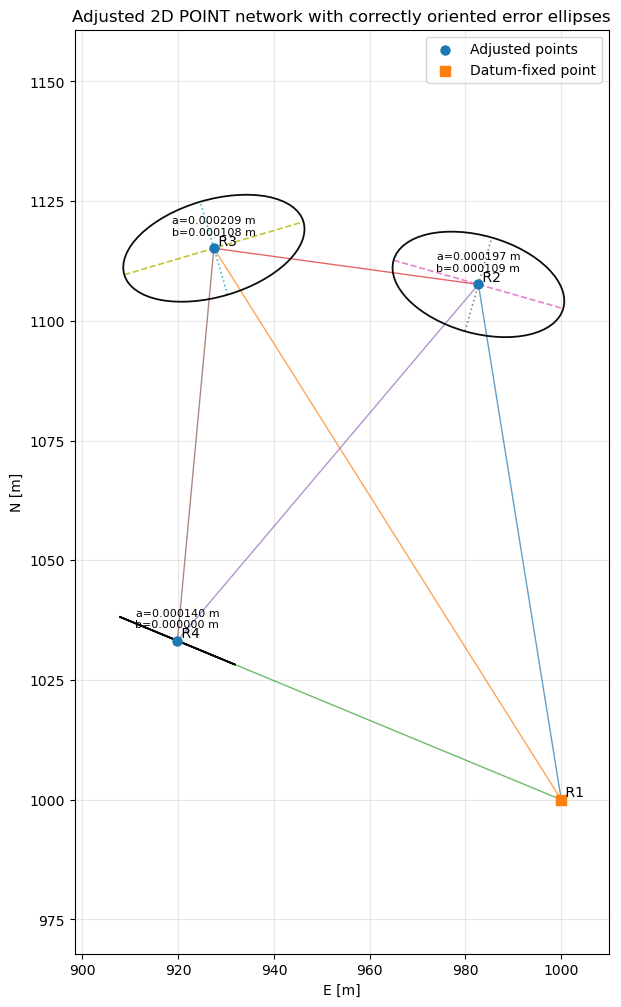

Precision source used: adjustment_results_xy['network_points_xy']
Observation source used for edges: obs_xy_final
Ellipse sigma level: 1.000
Visual ellipse scale factor: 93482.901x
Ellipse orientation fix applied: width=major axis, height=minor axis, angle=major-axis direction.


In [19]:
# === Optional 2D Step 5 — Plot adjusted 2D POINT network with correctly oriented error ellipses ===
# Requires:
# - adjustment_results_xy["coords_xy_final"]
# - adjustment_results_xy["network_points_xy"]   OR point_precision_xy
# - obs_xy / obs_xy_final / obs_xy_qc (for network edges)
#
# Plots:
# - adjusted 2D POINT network
# - point labels
# - correctly oriented 1-sigma error ellipses
# - major/minor axes of each ellipse
# - text above each free point with a,b values

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------
if "adjustment_results_xy" not in globals():
    raise RuntimeError("adjustment_results_xy was not found. Run Optional 2D Step 3 first.")

if "coords_xy_final" in adjustment_results_xy:
    coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()
else:
    raise RuntimeError("adjustment_results_xy['coords_xy_final'] was not found.")

# Preferred precision source: network_points_xy from Step 3A
if "network_points_xy" in adjustment_results_xy:
    pp = adjustment_results_xy["network_points_xy"].copy()
    precision_source_name = "adjustment_results_xy['network_points_xy']"
elif "point_precision_xy" in globals():
    pp = point_precision_xy.copy()
    precision_source_name = "point_precision_xy"
else:
    raise RuntimeError(
        "No point-precision table found. Expected adjustment_results_xy['network_points_xy'] "
        "or point_precision_xy."
    )

# Observation source for edges
if "obs_xy_final" in globals() and isinstance(obs_xy_final, pd.DataFrame) and len(obs_xy_final) > 0:
    obs_plot = obs_xy_final.copy()
    obs_source_name = "obs_xy_final"
elif "obs_xy_qc" in globals() and isinstance(obs_xy_qc, pd.DataFrame) and len(obs_xy_qc) > 0:
    obs_plot = obs_xy_qc.copy()
    obs_source_name = "obs_xy_qc"
elif "obs_xy" in globals() and isinstance(obs_xy, pd.DataFrame) and len(obs_xy) > 0:
    obs_plot = obs_xy.copy()
    obs_source_name = "obs_xy"
else:
    raise RuntimeError("No observation table found for plotting edges. Expected obs_xy_final / obs_xy_qc / obs_xy.")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _gon_to_deg(g):
    return np.asarray(g, dtype=float) * 0.9

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _az_gon_to_theta_plot_deg(az_gon):
    # azimuth: clockwise from North
    # matplotlib angle: counterclockwise from +x (East)
    return float(90.0 - _gon_to_deg(float(az_gon)))

# ------------------------------------------------------------
# Normalize data
# ------------------------------------------------------------
coords_xy_final = coords_xy_final.copy()
coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()

pp = pp.copy()
if "target" in pp.columns and "benchmark" not in pp.columns:
    pp = pp.rename(columns={"target": "benchmark"})
pp["benchmark"] = pp["benchmark"].astype(str).str.strip()

obs_plot["from"] = obs_plot["from"].astype(str).str.strip()
obs_plot["to"]   = obs_plot["to"].astype(str).str.strip()

coord_lookup = (
    coords_xy_final[["benchmark", "N_m", "E_m", "is_fixed_xy"]]
    .drop_duplicates(subset=["benchmark"])
    .set_index("benchmark")
)

# Keep only plotted points in precision table
pp = pp[pp["benchmark"].isin(coord_lookup.index)].copy().reset_index(drop=True)

# ------------------------------------------------------------
# Identify ellipse columns robustly
# ------------------------------------------------------------
if {"sigma_major_m", "sigma_minor_m", "az_major_gon"}.issubset(pp.columns):
    col_a = "sigma_major_m"
    col_b = "sigma_minor_m"
    col_az = "az_major_gon"
    az_unit = "gon"
elif {"ellipse_a_1sigma_m", "ellipse_b_1sigma_m", "ellipse_azimuth_deg"}.issubset(pp.columns):
    col_a = "ellipse_a_1sigma_m"
    col_b = "ellipse_b_1sigma_m"
    col_az = "ellipse_azimuth_deg"
    az_unit = "deg"
else:
    raise RuntimeError(
        "Could not identify ellipse columns. Expected either:\n"
        "1) sigma_major_m, sigma_minor_m, az_major_gon\n"
        "or\n"
        "2) ellipse_a_1sigma_m, ellipse_b_1sigma_m, ellipse_azimuth_deg"
    )

# ------------------------------------------------------------
# Build unique undirected POINT-network edges
# ------------------------------------------------------------
obs_plot = obs_plot.copy()
obs_plot["p_min"] = obs_plot[["from", "to"]].min(axis=1)
obs_plot["p_max"] = obs_plot[["from", "to"]].max(axis=1)

edges_df = (
    obs_plot.groupby(["p_min", "p_max"], as_index=False)
    .size()
    .rename(columns={"size": "n_obs"})
    .sort_values(["p_min", "p_max"])
    .reset_index(drop=True)
)

edges_df = edges_df[
    edges_df["p_min"].isin(coord_lookup.index) &
    edges_df["p_max"].isin(coord_lookup.index)
].copy()

# ------------------------------------------------------------
# User plot settings
# ------------------------------------------------------------
ellipse_sigma_level = 1.0       # 1-sigma ellipse
ellipse_target_fraction = 0.20  # target median visible major axis as fraction of median edge length
label_fontsize = 10
point_size_fixed = 60
point_size_free = 42
show_edge_labels = False

show_axes = True
axis_linewidth = 1.2
axis_alpha = 0.9

show_ab_text = True
ab_fontsize = 8
ab_offset_fraction = 0.020      # vertical offset relative to network N-span

ellipse_linewidth = 1.3
ellipse_alpha = 0.95

# ------------------------------------------------------------
# Auto-scale ellipses for readability
# ------------------------------------------------------------
edge_lengths = []
for _, r in edges_df.iterrows():
    a = str(r["p_min"]).strip()
    b = str(r["p_max"]).strip()
    Na, Ea = float(coord_lookup.loc[a, "N_m"]), float(coord_lookup.loc[a, "E_m"])
    Nb, Eb = float(coord_lookup.loc[b, "N_m"]), float(coord_lookup.loc[b, "E_m"])
    edge_lengths.append(float(np.hypot(Nb - Na, Eb - Ea)))

edge_lengths = np.asarray(edge_lengths, dtype=float)
edge_lengths = edge_lengths[np.isfinite(edge_lengths) & (edge_lengths > 0)]

median_edge_length = float(np.median(edge_lengths)) if len(edge_lengths) else 1.0

a_vals = pd.to_numeric(pp[col_a], errors="coerce").values.astype(float)
a_vals = a_vals[np.isfinite(a_vals) & (a_vals > 0)]

if len(a_vals) == 0:
    ellipse_plot_scale = 1.0
else:
    median_a = float(np.median(a_vals))
    ellipse_plot_scale = (ellipse_target_fraction * median_edge_length) / (ellipse_sigma_level * median_a)
    ellipse_plot_scale = float(np.clip(ellipse_plot_scale, 1.0, 1e6))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 12))

# Draw edges
for _, r in edges_df.iterrows():
    p1 = str(r["p_min"]).strip()
    p2 = str(r["p_max"]).strip()

    N1, E1 = float(coord_lookup.loc[p1, "N_m"]), float(coord_lookup.loc[p1, "E_m"])
    N2, E2 = float(coord_lookup.loc[p2, "N_m"]), float(coord_lookup.loc[p2, "E_m"])

    ax.plot([E1, E2], [N1, N2], linewidth=1.0, alpha=0.70)

    if show_edge_labels:
        Em = 0.5 * (E1 + E2)
        Nm = 0.5 * (N1 + N2)
        ax.text(Em, Nm, f"{p1}-{p2}", fontsize=7, ha="center", va="center")

# Draw points
fixed_mask = coords_xy_final["is_fixed_xy"].fillna(False).astype(bool)
free_mask = ~fixed_mask

ax.scatter(
    coords_xy_final.loc[free_mask, "E_m"],
    coords_xy_final.loc[free_mask, "N_m"],
    s=point_size_free,
    label="Adjusted points",
    zorder=4
)

ax.scatter(
    coords_xy_final.loc[fixed_mask, "E_m"],
    coords_xy_final.loc[fixed_mask, "N_m"],
    s=point_size_fixed,
    marker="s",
    label="Datum-fixed point",
    zorder=5
)

# Compute span for text offsets
all_E = coords_xy_final["E_m"].astype(float).values
all_N = coords_xy_final["N_m"].astype(float).values
span_E = max(float(np.max(all_E) - np.min(all_E)), 1.0)
span_N = max(float(np.max(all_N) - np.min(all_N)), 1.0)

ab_offset_N = ab_offset_fraction * span_N

# Point labels
for _, r in coords_xy_final.iterrows():
    p = str(r["benchmark"]).strip()
    Np = float(r["N_m"])
    Ep = float(r["E_m"])
    ax.text(Ep, Np, f" {p}", fontsize=label_fontsize, ha="left", va="bottom", zorder=6)

# Draw ellipses and their axes
for _, r in pp.iterrows():
    p = str(r["benchmark"]).strip()

    if p not in coord_lookup.index:
        continue
    if bool(coord_lookup.loc[p, "is_fixed_xy"]):
        continue

    a = pd.to_numeric(pd.Series([r[col_a]]), errors="coerce").iloc[0]
    b = pd.to_numeric(pd.Series([r[col_b]]), errors="coerce").iloc[0]
    az_raw = pd.to_numeric(pd.Series([r[col_az]]), errors="coerce").iloc[0]

    if not np.isfinite(a) or not np.isfinite(b) or not np.isfinite(az_raw):
        continue
    if a <= 0 or b < 0:
        continue

    if az_unit == "gon":
        az_major_gon = float(_wrap_gon_0_400(az_raw))
        theta_plot_deg = _az_gon_to_theta_plot_deg(az_major_gon)
        az_major_rad = np.deg2rad(theta_plot_deg)
    else:
        theta_plot_deg = float(az_raw)
        az_major_rad = np.deg2rad(theta_plot_deg)

    Np = float(coord_lookup.loc[p, "N_m"])
    Ep = float(coord_lookup.loc[p, "E_m"])

    a_plot = float(ellipse_sigma_level * a * ellipse_plot_scale)
    b_plot = float(ellipse_sigma_level * b * ellipse_plot_scale)

    # Correct orientation:
    # width must correspond to the MAJOR axis,
    # height must correspond to the MINOR axis,
    # angle must be the direction of the MAJOR axis.
    ell = Ellipse(
        xy=(Ep, Np),
        width=2.0 * a_plot,
        height=2.0 * b_plot,
        angle=theta_plot_deg,
        fill=False,
        linewidth=ellipse_linewidth,
        alpha=ellipse_alpha,
        zorder=3
    )
    ax.add_patch(ell)

    if show_axes:
        # Major axis unit vector in plot coordinates (E,N)
        ux = np.cos(az_major_rad)
        uy = np.sin(az_major_rad)

        # Minor axis is +90 deg from major
        vx = -np.sin(az_major_rad)
        vy =  np.cos(az_major_rad)

        # Major axis
        ax.plot(
            [Ep - a_plot * ux, Ep + a_plot * ux],
            [Np - a_plot * uy, Np + a_plot * uy],
            linestyle="--",
            linewidth=axis_linewidth,
            alpha=axis_alpha,
            zorder=2
        )

        # Minor axis
        ax.plot(
            [Ep - b_plot * vx, Ep + b_plot * vx],
            [Np - b_plot * vy, Np + b_plot * vy],
            linestyle=":",
            linewidth=axis_linewidth,
            alpha=axis_alpha,
            zorder=2
        )

    if show_ab_text:
        txt = f"a={a:.6f} m\nb={b:.6f} m"
        ax.text(
            Ep,
            Np + ab_offset_N,
            txt,
            fontsize=ab_fontsize,
            ha="center",
            va="bottom",
            zorder=7
        )

# Cosmetics
ax.set_xlabel("E [m]")
ax.set_ylabel("N [m]")
ax.set_title("Adjusted 2D POINT network with correctly oriented error ellipses")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

# ------------------------------------------------------------
# Expand limits including scaled error ellipses and labels
# ------------------------------------------------------------
if len(all_E) and len(all_N):

    plot_E_min = float(np.min(all_E))
    plot_E_max = float(np.max(all_E))
    plot_N_min = float(np.min(all_N))
    plot_N_max = float(np.max(all_N))

    for _, r in pp.iterrows():
        p = str(r["benchmark"]).strip()

        if p not in coord_lookup.index:
            continue
        if bool(coord_lookup.loc[p, "is_fixed_xy"]):
            continue

        a = pd.to_numeric(pd.Series([r[col_a]]), errors="coerce").iloc[0]
        b = pd.to_numeric(pd.Series([r[col_b]]), errors="coerce").iloc[0]
        az_raw = pd.to_numeric(pd.Series([r[col_az]]), errors="coerce").iloc[0]

        if not np.isfinite(a) or not np.isfinite(b) or not np.isfinite(az_raw):
            continue
        if a <= 0 or b < 0:
            continue

        if az_unit == "gon":
            az_major_gon = float(_wrap_gon_0_400(az_raw))
            theta_plot_deg = _az_gon_to_theta_plot_deg(az_major_gon)
        else:
            theta_plot_deg = float(az_raw)

        theta = np.deg2rad(theta_plot_deg)

        Ep = float(coord_lookup.loc[p, "E_m"])
        Np = float(coord_lookup.loc[p, "N_m"])

        a_plot = float(ellipse_sigma_level * a * ellipse_plot_scale)
        b_plot = float(ellipse_sigma_level * b * ellipse_plot_scale)

        # Bounding half-widths of a rotated ellipse in plot coordinates
        dx = float(np.sqrt((a_plot * np.cos(theta))**2 + (b_plot * np.sin(theta))**2))
        dy = float(np.sqrt((a_plot * np.sin(theta))**2 + (b_plot * np.cos(theta))**2))

        plot_E_min = min(plot_E_min, Ep - dx)
        plot_E_max = max(plot_E_max, Ep + dx)
        plot_N_min = min(plot_N_min, Np - dy)
        plot_N_max = max(plot_N_max, Np + dy + ab_offset_N)

    plot_span_E = max(plot_E_max - plot_E_min, 1.0)
    plot_span_N = max(plot_N_max - plot_N_min, 1.0)

    pad_E = 0.10 * plot_span_E
    pad_N = 0.25 * plot_span_N

    ax.set_xlim(plot_E_min - pad_E, plot_E_max + pad_E)
    ax.set_ylim(plot_N_min - pad_N, plot_N_max + pad_N)

plt.show()

print(f"Precision source used: {precision_source_name}")
print(f"Observation source used for edges: {obs_source_name}")
print(f"Ellipse sigma level: {ellipse_sigma_level:.3f}")
print(f"Visual ellipse scale factor: {ellipse_plot_scale:.3f}x")
print("Ellipse orientation fix applied: width=major axis, height=minor axis, angle=major-axis direction.")

## Optional 2D Step 6 — Georeference the local adjusted network

This cell links the adjusted local 2D network to a real projected coordinate reference system.

**Main role**
- accept control points in projected or geographic form,
- define a working metric CRS,
- estimate the transformation from the local system to the working CRS,
- compute georeferenced coordinates for the adjusted points.

In [20]:
# === Optional 2D Service Cell — Build horizontal control points from RTKLIB baseline report with satellite map preview + pairwise matching ===
# Name: service_rtklib_horizontal_control_points
# Purpose:
# - Read "14. Final GNSSBM coordinate solutions" from bases.solution.report.html.
# - Print run_label / benchmark_id / lon_deg / lat_deg / std_lon_m / std_lat_m / std_h_m.
# - Display all RTKLIB report solution points on a Google Maps JavaScript API satellite/hybrid map.
# - Cluster near-identical GNSS occupations into physical GNSS points.
# - Propose likely GNSS-cluster -> local-benchmark mappings using pairwise distance signatures.
# - Let the user accept a suggested mapping or manually map one or more run_label rows to local benchmarks.
# - If multiple run_labels are mapped to the same benchmark:
#     weighted mean is computed in projected UTM coordinates.
# - Automatically selects a suitable UTM North EPSG from the selected control-point longitude.
# - Outputs:
#     rtklib_horizontal_control_runs
#     rtklib_horizontal_control_points
#     rtklib_horizontal_control_epsg
#     rtklib_gnss_clusters
#     rtklib_pairwise_mapping_candidates
#     rtklib_pairwise_mapping_details

import os
import re
import math
import json
import uuid
import itertools
import numpy as np
import pandas as pd
from pyproj import CRS, Transformer
from IPython.display import display, HTML
from html import escape

# ------------------------------------------------------------
# 0) User settings
# ------------------------------------------------------------
MAP_TYPE = "hybrid"      # "satellite" or "hybrid"
MAP_ZOOM_CAP = 21        # cap after fitBounds
MARKER_LABEL_MODE = "row_id"  # fixed for this service cell

# Pairwise matching settings
GNSS_SAME_POINT_THRESHOLD_M = 0.05       # RTKLIB rows closer than this are treated as same physical GNSS point
PAIRWISE_DISTANCE_TOLERANCE_M = 0.05     # informative tolerance for candidate quality flag
MAX_CLUSTERS_FOR_FULL_MATCH = 6          # exhaustive matching is attempted up to this number of GNSS clusters
MAX_LOCAL_BENCHMARKS_FOR_MATCH = 14      # protects against excessive permutations
MAX_MATCH_PERMUTATIONS = 250000          # hard limit for exhaustive candidate enumeration
MAX_SUGGESTED_MAPPINGS = 20              # number of ranked candidate mappings printed

# ------------------------------------------------------------
# 1) File-picker and general helpers
# ------------------------------------------------------------
def _normalize_local_path(path_value):
    if path_value is None:
        return ""
    s = str(path_value).strip().strip('"').strip("'")
    if s.startswith("file://"):
        s = s[7:]
    return os.path.abspath(os.path.expanduser(s)) if s else ""

def _open_file_dialog(title, filetypes=None, initialdir=None):
    import tkinter as tk
    from tkinter import filedialog

    root = tk.Tk()
    root.withdraw()
    try:
        root.attributes("-topmost", True)
    except Exception:
        pass

    kwargs = {
        "title": title,
        "initialdir": initialdir or os.getcwd(),
    }
    if filetypes is not None:
        kwargs["filetypes"] = filetypes

    path = filedialog.askopenfilename(**kwargs)
    root.destroy()
    return path

def _select_file_path(title, filetypes=None, required=True, default_path=None):
    if default_path:
        print(f"\nDefault path for {title}")
        print(default_path)
        raw = input(
            "Press Enter to use this path, paste another file path, paste a folder path, "
            "or type PICK to open file picker:\n> "
        ).strip()

        if raw == "":
            candidate = _normalize_local_path(default_path)
            if os.path.isfile(candidate):
                return candidate
            raise FileNotFoundError(f"Default file path does not exist: {candidate}")

        if raw.lower() != "pick":
            candidate = _normalize_local_path(raw)
            if os.path.isfile(candidate):
                return candidate
            if os.path.isdir(candidate):
                initialdir = candidate
            else:
                if required:
                    raise FileNotFoundError(f"The pasted path is neither an existing file nor folder: {candidate}")
                return None
        else:
            initialdir = os.path.dirname(_normalize_local_path(default_path)) or os.getcwd()

    else:
        raw = input(
            f"\n{title}\n"
            "Paste full file path OR folder path, or press Enter to open file picker:\n> "
        ).strip()

        initialdir = os.getcwd()

        if raw != "":
            candidate = _normalize_local_path(raw)
            if os.path.isfile(candidate):
                return candidate
            if os.path.isdir(candidate):
                initialdir = candidate
            else:
                if required:
                    raise FileNotFoundError(f"The pasted path is neither an existing file nor folder: {candidate}")
                return None

    try:
        path = _open_file_dialog(title=title, filetypes=filetypes, initialdir=initialdir)
    except Exception as exc:
        print(f"Native file dialog is unavailable: {exc}")
        path = input(f"{title}\nEnter full file path, or press Enter to skip:\n> ").strip()

    path = _normalize_local_path(path)

    if path == "":
        if required:
            raise RuntimeError("No file was selected.")
        return None

    if not os.path.isfile(path):
        if required:
            raise FileNotFoundError(f"Selected file does not exist: {path}")
        return None

    return path

def _read_api_key_file(path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        text = f.read().strip()

    if text == "":
        raise RuntimeError("Google Maps API key file is empty.")

    # Accept:
    #   raw_key
    #   GOOGLE_MAPS_API_KEY=raw_key
    #   key: raw_key
    lines = [ln.strip() for ln in text.splitlines() if ln.strip() != ""]
    for ln in lines:
        if "=" in ln:
            k, v = ln.split("=", 1)
            if "key" in k.lower() or "google" in k.lower():
                return v.strip()
        if ":" in ln:
            k, v = ln.split(":", 1)
            if "key" in k.lower() or "google" in k.lower():
                return v.strip()

    return lines[0].strip()

def _find_table_by_columns(tables, required_cols):
    required = set(required_cols)
    for tab in tables:
        cols = set([str(c).strip() for c in tab.columns])
        if required.issubset(cols):
            out = tab.copy()
            out.columns = [str(c).strip() for c in out.columns]
            return out
    return None

def _utm_epsg_from_lonlat(lon_deg, lat_deg):
    lon = float(lon_deg)
    lat = float(lat_deg)
    zone = int(math.floor((lon + 180.0) / 6.0) + 1)
    zone = max(1, min(zone, 60))
    epsg = 32600 + zone if lat >= 0 else 32700 + zone
    return int(epsg), int(zone)

def _safe_sigma(series, fallback=0.005):
    vals = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if len(vals) == 0:
        return float(fallback)
    return float(np.median(vals))

def _weighted_mean_axis(values, sigmas):
    values = np.asarray(values, dtype=float)
    sigmas = np.asarray(sigmas, dtype=float)

    valid = np.isfinite(values) & np.isfinite(sigmas) & (sigmas > 0)
    values = values[valid]
    sigmas = sigmas[valid]

    if len(values) == 0:
        raise RuntimeError("No valid values/sigmas for weighted mean.")

    weights = 1.0 / (sigmas ** 2)
    mean = float(np.sum(weights * values) / np.sum(weights))
    sigma_formal = float(np.sqrt(1.0 / np.sum(weights)))

    if len(values) > 1:
        sample_std = float(np.std(values, ddof=1))
        sigma_scatter_mean = float(sample_std / np.sqrt(len(values)))
        sigma_final = float(max(sigma_formal, sigma_scatter_mean))
    else:
        sample_std = np.nan
        sigma_scatter_mean = np.nan
        sigma_final = sigma_formal

    return {
        "mean": mean,
        "sigma_formal": sigma_formal,
        "sample_std": sample_std,
        "sigma_scatter_mean": sigma_scatter_mean,
        "sigma_final": sigma_final,
        "n": int(len(values)),
    }

def _parse_index_list(text, max_index):
    text = str(text).strip()
    if text == "":
        return []

    tokens = []
    for part in text.split(","):
        p = part.strip()
        if p == "":
            continue

        if "-" in p:
            a, b = p.split("-", 1)
            a = int(a.strip())
            b = int(b.strip())
            tokens.extend(list(range(a, b + 1)))
        else:
            tokens.append(int(p))

    bad = [x for x in tokens if x < 1 or x > max_index]
    if bad:
        raise ValueError(f"Invalid row number(s): {bad}")

    return sorted(set(tokens))

def _make_google_map_for_rtklib_points(df_points, google_maps_api_key, map_type="hybrid", zoom_cap=21):
    if df_points.empty:
        raise RuntimeError("No RTKLIB points available for map display.")

    center_lat = float(df_points["lat_deg"].mean())
    center_lon = float(df_points["lon_deg"].mean())

    markers = []
    for _, r in df_points.iterrows():
        marker = {
            "row_id": int(r["row_id"]),
            "label": str(int(r["row_id"])),
            "run_label": str(r["run_label"]),
            "benchmark_id": str(r["benchmark_id"]),
            "lat": float(r["lat_deg"]),
            "lng": float(r["lon_deg"]),
            "h_m": None if "h_m" not in r or pd.isna(r["h_m"]) else float(r["h_m"]),
            "std_lon_m": None if "std_lon_m" not in r or pd.isna(r["std_lon_m"]) else float(r["std_lon_m"]),
            "std_lat_m": None if "std_lat_m" not in r or pd.isna(r["std_lat_m"]) else float(r["std_lat_m"]),
            "std_h_m": None if "std_h_m" not in r or pd.isna(r["std_h_m"]) else float(r["std_h_m"]),
            "qc_flags": "" if "qc_flags" not in r or pd.isna(r["qc_flags"]) else str(r["qc_flags"]),
            "uncertainty_note": "" if "uncertainty_note" not in r or pd.isna(r["uncertainty_note"]) else str(r["uncertainty_note"]),
        }
        markers.append(marker)

    map_id = "gmap_rtklib_" + uuid.uuid4().hex
    callback_name = "init_" + uuid.uuid4().hex
    markers_json = json.dumps(markers, ensure_ascii=False)

    html = f"""
<div id="{map_id}" style="width: 100%; height: 780px; border: 1px solid #999;"></div>

<script>
function {callback_name}() {{

  const map = new google.maps.Map(document.getElementById("{map_id}"), {{
    center: {{lat: {center_lat:.12f}, lng: {center_lon:.12f}}},
    zoom: {int(zoom_cap)},
    mapTypeId: "{escape(map_type)}",
    tilt: 0,
    streetViewControl: false,
    fullscreenControl: true,
    mapTypeControl: true,
    scaleControl: true,
    rotateControl: false
  }});

  const markers = {markers_json};
  const bounds = new google.maps.LatLngBounds();

  markers.forEach(function(p) {{
    const pos = {{lat: p.lat, lng: p.lng}};

    const marker = new google.maps.Marker({{
      position: pos,
      map: map,
      title: "row " + p.row_id + " | " + p.run_label,
      label: {{
        text: p.label,
        color: "white",
        fontSize: "13px",
        fontWeight: "bold"
      }}
    }});

    const hText = (p.h_m === null) ? "" : p.h_m.toFixed(4);
    const sLonText = (p.std_lon_m === null) ? "" : p.std_lon_m.toFixed(4);
    const sLatText = (p.std_lat_m === null) ? "" : p.std_lat_m.toFixed(4);
    const sHText = (p.std_h_m === null) ? "" : p.std_h_m.toFixed(4);

    const info = new google.maps.InfoWindow({{
      content:
        "<b>row_id: " + p.row_id + "</b><br>" +
        "<b>run_label:</b> " + p.run_label + "<br>" +
        "<b>benchmark_id:</b> " + p.benchmark_id + "<br>" +
        "<b>Lat:</b> " + p.lat.toFixed(10) + "<br>" +
        "<b>Lon:</b> " + p.lng.toFixed(10) + "<br>" +
        "<b>h_m:</b> " + hText + "<br>" +
        "<b>std_lon_m:</b> " + sLonText + "<br>" +
        "<b>std_lat_m:</b> " + sLatText + "<br>" +
        "<b>std_h_m:</b> " + sHText + "<br>" +
        "<b>qc_flags:</b> " + p.qc_flags + "<br>" +
        "<b>uncertainty_note:</b> " + p.uncertainty_note
    }});

    marker.addListener("click", function() {{
      info.open(map, marker);
    }});

    bounds.extend(pos);
  }});

  if (markers.length > 1) {{
    map.fitBounds(bounds);
    google.maps.event.addListenerOnce(map, "bounds_changed", function() {{
      if (map.getZoom() > {int(zoom_cap)}) {{
        map.setZoom({int(zoom_cap)});
      }}
    }});
  }} else if (markers.length === 1) {{
    map.setZoom({int(zoom_cap)});
  }}
}}
</script>

<script async defer
src="https://maps.googleapis.com/maps/api/js?key={google_maps_api_key}&callback={callback_name}&loading=async">
</script>
"""

    display(HTML(html))

def _union_find_clusters_by_distance(df, threshold_m, N_col="N_auto_m", E_col="E_auto_m"):
    """Cluster RTKLIB rows that are closer than threshold_m in projected coordinates."""
    n = len(df)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra = find(a)
        rb = find(b)
        if ra != rb:
            parent[rb] = ra

    N = pd.to_numeric(df[N_col], errors="coerce").to_numpy(dtype=float)
    E = pd.to_numeric(df[E_col], errors="coerce").to_numpy(dtype=float)

    for i in range(n):
        for j in range(i + 1, n):
            if not (np.isfinite(N[i]) and np.isfinite(E[i]) and np.isfinite(N[j]) and np.isfinite(E[j])):
                continue
            d = float(np.hypot(N[j] - N[i], E[j] - E[i]))
            if d <= float(threshold_m):
                union(i, j)

    root_to_cluster = {}
    cluster_ids = []
    for i in range(n):
        r = find(i)
        if r not in root_to_cluster:
            root_to_cluster[r] = len(root_to_cluster) + 1
        cluster_ids.append(root_to_cluster[r])

    return cluster_ids

def _build_gnss_clusters(rtklib_rows_projected):
    """Build physical GNSS clusters from RTKLIB solution rows."""
    rows = rtklib_rows_projected.copy().reset_index(drop=True)
    rows["gnss_cluster_id"] = _union_find_clusters_by_distance(
        rows,
        threshold_m=GNSS_SAME_POINT_THRESHOLD_M,
        N_col="N_auto_m",
        E_col="E_auto_m",
    )

    cluster_rows = []
    for cid, g in rows.groupby("gnss_cluster_id"):
        g = g.copy().reset_index(drop=True)

        sE = pd.to_numeric(g.get("std_lon_m", np.nan), errors="coerce")
        sN = pd.to_numeric(g.get("std_lat_m", np.nan), errors="coerce")

        fallback_E = _safe_sigma(sE, fallback=0.005)
        fallback_N = _safe_sigma(sN, fallback=0.005)

        sE = sE.where(np.isfinite(sE) & (sE > 0), fallback_E)
        sN = sN.where(np.isfinite(sN) & (sN > 0), fallback_N)

        E_stats = _weighted_mean_axis(g["E_auto_m"].values, sE.values)
        N_stats = _weighted_mean_axis(g["N_auto_m"].values, sN.values)

        dE = g["E_auto_m"].to_numpy(dtype=float) - E_stats["mean"]
        dN = g["N_auto_m"].to_numpy(dtype=float) - N_stats["mean"]
        radial = np.hypot(dE, dN)
        max_internal_distance_m = float(np.max(radial)) if len(radial) else np.nan

        cluster_rows.append({
            "gnss_cluster_id": int(cid),
            "n_rows": int(len(g)),
            "row_ids": ",".join(g["row_id"].astype(int).astype(str).tolist()),
            "run_labels": ", ".join(g["run_label"].astype(str).tolist()),
            "report_benchmark_ids": ", ".join(sorted(g["benchmark_id"].astype(str).unique().tolist())),
            "lon_deg_mean_raw": float(g["lon_deg"].mean()),
            "lat_deg_mean_raw": float(g["lat_deg"].mean()),
            "E_auto_m": float(E_stats["mean"]),
            "N_auto_m": float(N_stats["mean"]),
            "sigma_E_auto_m": float(E_stats["sigma_final"]),
            "sigma_N_auto_m": float(N_stats["sigma_final"]),
            "sigma_horizontal_auto_m": float(np.hypot(E_stats["sigma_final"], N_stats["sigma_final"])),
            "max_internal_distance_m": max_internal_distance_m,
        })

    clusters = pd.DataFrame(cluster_rows).sort_values("gnss_cluster_id").reset_index(drop=True)
    rows = rows.sort_values(["gnss_cluster_id", "row_id"]).reset_index(drop=True)

    return rows, clusters

def _local_benchmark_coordinate_table(local_benchmarks):
    """Return local benchmark coordinates from adjustment_results_xy['coords_xy_final'] if available."""
    if not (
        "adjustment_results_xy" in globals()
        and isinstance(adjustment_results_xy, dict)
        and isinstance(adjustment_results_xy.get("coords_xy_final", None), pd.DataFrame)
    ):
        return pd.DataFrame()

    df = adjustment_results_xy["coords_xy_final"].copy()
    if not {"benchmark", "N_m", "E_m"}.issubset(set(df.columns)):
        return pd.DataFrame()

    df["benchmark"] = df["benchmark"].astype(str).str.strip()
    df["N_m"] = pd.to_numeric(df["N_m"], errors="coerce")
    df["E_m"] = pd.to_numeric(df["E_m"], errors="coerce")
    df = df[
        df["benchmark"].isin(local_benchmarks)
        & np.isfinite(df["N_m"])
        & np.isfinite(df["E_m"])
    ].copy()

    return df[["benchmark", "N_m", "E_m"]].drop_duplicates("benchmark").sort_values("benchmark").reset_index(drop=True)

def _count_permutations(n, k):
    if k > n:
        return 0
    out = 1
    for v in range(n - k + 1, n + 1):
        out *= v
    return out

def _generate_pairwise_mapping_candidates(gnss_clusters, local_coord_df):
    """Compare pairwise distance signatures: GNSS cluster distances vs local benchmark distances."""
    if gnss_clusters is None or local_coord_df is None:
        return pd.DataFrame(), pd.DataFrame()
    if len(gnss_clusters) < 2 or len(local_coord_df) < 2:
        return pd.DataFrame(), pd.DataFrame()

    clusters = gnss_clusters.sort_values("gnss_cluster_id").reset_index(drop=True)
    locals_df = local_coord_df.sort_values("benchmark").reset_index(drop=True)

    n_g = len(clusters)
    n_l = len(locals_df)

    if n_g > MAX_CLUSTERS_FOR_FULL_MATCH:
        print(
            f"\nPairwise suggestion skipped: {n_g} GNSS clusters exceed "
            f"MAX_CLUSTERS_FOR_FULL_MATCH={MAX_CLUSTERS_FOR_FULL_MATCH}."
        )
        return pd.DataFrame(), pd.DataFrame()

    if n_l > MAX_LOCAL_BENCHMARKS_FOR_MATCH:
        print(
            f"\nPairwise suggestion skipped: {n_l} local benchmarks exceed "
            f"MAX_LOCAL_BENCHMARKS_FOR_MATCH={MAX_LOCAL_BENCHMARKS_FOR_MATCH}."
        )
        return pd.DataFrame(), pd.DataFrame()

    n_perm = _count_permutations(n_l, n_g)
    if n_perm > MAX_MATCH_PERMUTATIONS:
        print(
            f"\nPairwise suggestion skipped: {n_perm} possible mappings exceed "
            f"MAX_MATCH_PERMUTATIONS={MAX_MATCH_PERMUTATIONS}."
        )
        return pd.DataFrame(), pd.DataFrame()

    g_names = clusters["gnss_cluster_id"].astype(int).tolist()
    gN = clusters["N_auto_m"].to_numpy(dtype=float)
    gE = clusters["E_auto_m"].to_numpy(dtype=float)

    l_names = locals_df["benchmark"].astype(str).tolist()
    lN = locals_df["N_m"].to_numpy(dtype=float)
    lE = locals_df["E_m"].to_numpy(dtype=float)

    g_pair_dist = {}
    for i in range(n_g):
        for j in range(i + 1, n_g):
            g_pair_dist[(i, j)] = float(np.hypot(gN[j] - gN[i], gE[j] - gE[i]))

    candidate_rows = []
    detail_rows = []
    cand_id = 0

    for perm in itertools.permutations(range(n_l), n_g):
        residuals = []
        pair_details = []

        for i in range(n_g):
            for j in range(i + 1, n_g):
                li = perm[i]
                lj = perm[j]

                d_g = g_pair_dist[(i, j)]
                d_l = float(np.hypot(lN[lj] - lN[li], lE[lj] - lE[li]))
                res = d_g - d_l

                residuals.append(res)
                pair_details.append({
                    "gnss_pair": f"C{g_names[i]}-C{g_names[j]}",
                    "local_pair": f"{l_names[li]}-{l_names[lj]}",
                    "gnss_distance_m": d_g,
                    "local_distance_m": d_l,
                    "residual_m": res,
                    "abs_residual_m": abs(res),
                })

        if len(residuals) == 0:
            continue

        cand_id += 1
        residuals = np.asarray(residuals, dtype=float)
        abs_residuals = np.abs(residuals)

        rms_m = float(np.sqrt(np.mean(residuals ** 2)))
        max_abs_m = float(np.max(abs_residuals))
        mean_abs_m = float(np.mean(abs_residuals))

        mapping_pairs = []
        for i, li in enumerate(perm):
            mapping_pairs.append(f"C{g_names[i]}→{l_names[li]}")

        candidate_rows.append({
            "candidate_id_raw": cand_id,
            "n_gnss_clusters": int(n_g),
            "n_pairs": int(len(residuals)),
            "rms_distance_mismatch_m": rms_m,
            "mean_abs_distance_mismatch_m": mean_abs_m,
            "max_abs_distance_mismatch_m": max_abs_m,
            "within_tolerance": bool(max_abs_m <= PAIRWISE_DISTANCE_TOLERANCE_M),
            "mapping_text": "; ".join(mapping_pairs),
            "local_benchmarks_used": ", ".join(l_names[i] for i in perm),
            "permutation_indices": json.dumps(list(map(int, perm))),
        })

        for pdrow in pair_details:
            pdrow["candidate_id_raw"] = cand_id
            detail_rows.append(pdrow)

    if len(candidate_rows) == 0:
        return pd.DataFrame(), pd.DataFrame()

    cand = pd.DataFrame(candidate_rows).sort_values(
        ["rms_distance_mismatch_m", "max_abs_distance_mismatch_m", "mean_abs_distance_mismatch_m"]
    ).reset_index(drop=True)

    cand = cand.head(MAX_SUGGESTED_MAPPINGS).copy()
    cand.insert(0, "candidate_id", np.arange(1, len(cand) + 1))

    id_map = dict(zip(cand["candidate_id_raw"].astype(int), cand["candidate_id"].astype(int)))
    details = pd.DataFrame(detail_rows)
    if not details.empty:
        details = details[details["candidate_id_raw"].astype(int).isin(id_map.keys())].copy()
        details["candidate_id"] = details["candidate_id_raw"].astype(int).map(id_map)
        details = details.drop(columns=["candidate_id_raw"]).sort_values(
            ["candidate_id", "abs_residual_m"]
        ).reset_index(drop=True)

    cand = cand.drop(columns=["candidate_id_raw"]).reset_index(drop=True)
    return cand, details

def _mapping_defaults_from_candidate(candidate_row, gnss_clusters, local_coord_df):
    """Convert a selected candidate mapping into defaults: benchmark -> row_id list."""
    if candidate_row is None or len(candidate_row) == 0:
        return {}

    perm = json.loads(str(candidate_row["permutation_indices"]))
    clusters = gnss_clusters.sort_values("gnss_cluster_id").reset_index(drop=True)
    local_names = local_coord_df.sort_values("benchmark").reset_index(drop=True)["benchmark"].astype(str).tolist()

    defaults = {}
    for i, local_idx in enumerate(perm):
        bm = local_names[int(local_idx)]
        row_ids = [
            int(x) for x in str(clusters.loc[i, "row_ids"]).split(",")
            if str(x).strip() != ""
        ]
        defaults[bm] = row_ids
    return defaults

# ------------------------------------------------------------
# 2) Input files: RTKLIB report and Google Maps API key file
# ------------------------------------------------------------
default_report_path = None

if "datum_documentation" in globals() and isinstance(datum_documentation, dict):
    default_report_path = (
        datum_documentation
        .get("rtklib_report", {})
        .get("report_path", None)
    )

rtklib_report_path = _select_file_path(
    title="1) Select RTKLIB bases.solution.report.html",
    filetypes=(("HTML files", "*.html *.htm"), ("All files", "*.*")),
    required=True,
    default_path=default_report_path,
)

google_maps_key_path = _select_file_path(
    title="2) Select Google Maps JavaScript API key file",
    filetypes=(("Text files", "*.txt *.key *.env"), ("All files", "*.*")),
    required=True,
    default_path=None,
)

GOOGLE_MAPS_API_KEY = _read_api_key_file(google_maps_key_path)

if GOOGLE_MAPS_API_KEY == "":
    raise RuntimeError("Google Maps API key could not be read.")

# ------------------------------------------------------------
# 3) Read final GNSSBM coordinate solutions table
# ------------------------------------------------------------
tables = pd.read_html(rtklib_report_path)

required_cols = [
    "run_label",
    "benchmark_id",
    "lon_deg",
    "lat_deg",
    "h_m",
    "std_lon_m",
    "std_lat_m",
    "std_h_m",
]

rtklib_final = _find_table_by_columns(tables, required_cols)

if rtklib_final is None:
    raise RuntimeError(
        "Could not find the 'Final GNSSBM coordinate solutions' table. "
        "Expected columns include: "
        + ", ".join(required_cols)
    )

numeric_cols = [
    "lon_deg", "lat_deg", "h_m",
    "std_lon_m", "std_lat_m", "std_h_m",
    "X_m", "Y_m", "Z_m",
    "std_X_m", "std_Y_m", "std_Z_m",
    "rtklib_std_h_m", "cors_std_up_m",
]

for c in numeric_cols:
    if c in rtklib_final.columns:
        rtklib_final[c] = pd.to_numeric(rtklib_final[c], errors="coerce")

rtklib_final["run_label"] = rtklib_final["run_label"].astype(str).str.strip()
rtklib_final["benchmark_id"] = rtklib_final["benchmark_id"].astype(str).str.strip()

rtklib_final = rtklib_final[
    np.isfinite(rtklib_final["lon_deg"])
    & np.isfinite(rtklib_final["lat_deg"])
].copy().reset_index(drop=True)

if len(rtklib_final) == 0:
    raise RuntimeError("No valid lon/lat rows were found in RTKLIB final GNSSBM table.")

# ------------------------------------------------------------
# 4) Display available run_label rows for visual and tabular mapping
# ------------------------------------------------------------
rtklib_final_display = rtklib_final.copy()
rtklib_final_display.insert(0, "row_id", np.arange(1, len(rtklib_final_display) + 1))

display_cols = [
    "row_id",
    "run_label",
    "benchmark_id",
    "lon_deg",
    "lat_deg",
    "h_m",
    "std_lon_m",
    "std_lat_m",
    "std_h_m",
    "rtklib_std_h_m",
    "cors_std_up_m",
    "uncertainty_note",
    "qc_flags",
]
display_cols = [c for c in display_cols if c in rtklib_final_display.columns]

print("\nRTKLIB report — available GNSSBM coordinate solution rows:")
display(rtklib_final_display[display_cols])

print("\nSatellite/hybrid map of RTKLIB report solution rows:")
print("Marker label = row_id. Click each marker to inspect run_label and coordinate details.")
_make_google_map_for_rtklib_points(
    df_points=rtklib_final_display,
    google_maps_api_key=GOOGLE_MAPS_API_KEY,
    map_type=MAP_TYPE,
    zoom_cap=MAP_ZOOM_CAP,
)

print("\nMap type:", MAP_TYPE)
print("Note: Google Maps JavaScript API is used only for visual background display.")
print("No Google raw tiles are downloaded by Python.")
print("The API key is read from file and is not printed.")

# ------------------------------------------------------------
# 5) Get local benchmark names
# ------------------------------------------------------------
if "adjustment_results_xy" in globals() and isinstance(adjustment_results_xy, dict):
    if "coords_xy_final" in adjustment_results_xy:
        local_benchmarks = (
            adjustment_results_xy["coords_xy_final"]["benchmark"]
            .astype(str).str.strip()
            .drop_duplicates()
            .sort_values()
            .tolist()
        )
    else:
        local_benchmarks = []
elif "network" in globals() and isinstance(network, dict) and "nodes" in network:
    local_benchmarks = sorted([str(x).strip() for x in network["nodes"]])
else:
    local_benchmarks = []

if len(local_benchmarks) == 0:
    local_benchmarks = input(
        "Could not infer local benchmark names. Enter names separated by commas:\n> "
    ).strip().split(",")
    local_benchmarks = sorted([x.strip() for x in local_benchmarks if x.strip() != ""])

print("\nAvailable local network benchmarks:")
print(", ".join(local_benchmarks))

# ------------------------------------------------------------
# 6) Pairwise-distance suggestions + user mapping
# ------------------------------------------------------------
mean_lon_all = float(rtklib_final_display["lon_deg"].mean())
mean_lat_all = float(rtklib_final_display["lat_deg"].mean())
suggestion_epsg, suggestion_zone = _utm_epsg_from_lonlat(mean_lon_all, mean_lat_all)
suggestion_crs = CRS.from_epsg(suggestion_epsg)
tr_4326_to_suggestion = Transformer.from_crs(CRS.from_epsg(4326), suggestion_crs, always_xy=True)

E_auto, N_auto = tr_4326_to_suggestion.transform(
    rtklib_final_display["lon_deg"].astype(float).values,
    rtklib_final_display["lat_deg"].astype(float).values,
)

rtklib_rows_projected_for_match = rtklib_final_display.copy()
rtklib_rows_projected_for_match["E_auto_m"] = E_auto
rtklib_rows_projected_for_match["N_auto_m"] = N_auto
rtklib_rows_projected_for_match["suggestion_epsg"] = int(suggestion_epsg)

rtklib_clustered_rows, rtklib_gnss_clusters = _build_gnss_clusters(rtklib_rows_projected_for_match)

print("\nAutomatic GNSS occupation clustering for mapping assistance:")
print(f"Projected CRS used only for suggestions: EPSG:{suggestion_epsg}")
print(f"Same-point threshold: {GNSS_SAME_POINT_THRESHOLD_M:.3f} m")
display(
    rtklib_gnss_clusters.style.format({
        "lon_deg_mean_raw": "{:.10f}",
        "lat_deg_mean_raw": "{:.10f}",
        "E_auto_m": "{:.4f}",
        "N_auto_m": "{:.4f}",
        "sigma_E_auto_m": "{:.4f}",
        "sigma_N_auto_m": "{:.4f}",
        "sigma_horizontal_auto_m": "{:.4f}",
        "max_internal_distance_m": "{:.4f}",
    })
)

print("\nRTKLIB rows with assigned GNSS cluster IDs:")
display_cols_clustered = [
    "row_id", "gnss_cluster_id", "run_label", "benchmark_id",
    "lon_deg", "lat_deg", "E_auto_m", "N_auto_m",
    "std_lon_m", "std_lat_m", "std_h_m", "qc_flags"
]
display_cols_clustered = [c for c in display_cols_clustered if c in rtklib_clustered_rows.columns]
display(
    rtklib_clustered_rows[display_cols_clustered].style.format({
        "lon_deg": "{:.10f}",
        "lat_deg": "{:.10f}",
        "E_auto_m": "{:.4f}",
        "N_auto_m": "{:.4f}",
        "std_lon_m": "{:.4f}",
        "std_lat_m": "{:.4f}",
        "std_h_m": "{:.4f}",
    })
)

local_coord_df = _local_benchmark_coordinate_table(local_benchmarks)

if local_coord_df.empty:
    print("\nPairwise mapping suggestions are unavailable because local benchmark coordinates were not found.")
    pairwise_candidates = pd.DataFrame()
    pairwise_candidate_details = pd.DataFrame()
else:
    print("\nLocal benchmark coordinates used for pairwise-distance matching:")
    display(
        local_coord_df.style.format({
            "N_m": "{:.4f}",
            "E_m": "{:.4f}",
        })
    )

    pairwise_candidates, pairwise_candidate_details = _generate_pairwise_mapping_candidates(
        gnss_clusters=rtklib_gnss_clusters,
        local_coord_df=local_coord_df,
    )

if not pairwise_candidates.empty:
    print("\nSuggested GNSS-cluster -> local-benchmark mappings based on pairwise distances:")
    print(f"Quality flag tolerance: max pairwise distance mismatch <= {PAIRWISE_DISTANCE_TOLERANCE_M:.3f} m")
    display(
        pairwise_candidates[[
            "candidate_id",
            "n_gnss_clusters",
            "n_pairs",
            "rms_distance_mismatch_m",
            "mean_abs_distance_mismatch_m",
            "max_abs_distance_mismatch_m",
            "within_tolerance",
            "mapping_text",
        ]].style.format({
            "rms_distance_mismatch_m": "{:.4f}",
            "mean_abs_distance_mismatch_m": "{:.4f}",
            "max_abs_distance_mismatch_m": "{:.4f}",
        })
    )

    print("\nPairwise residual details for suggested mappings:")
    display(
        pairwise_candidate_details.style.format({
            "gnss_distance_m": "{:.4f}",
            "local_distance_m": "{:.4f}",
            "residual_m": "{:+.4f}",
            "abs_residual_m": "{:.4f}",
        })
    )
else:
    print("\nNo pairwise mapping candidates were generated.")
    print("This is expected if fewer than two GNSS clusters are available or if exhaustive matching limits were exceeded.")

mapping_defaults = {}
if not pairwise_candidates.empty:
    raw_use_suggestion = input(
        "\nUse one of the suggested mappings as defaults for the manual mapping prompts? [y/n, default y]\n> "
    ).strip().lower()
    if raw_use_suggestion == "":
        raw_use_suggestion = "y"

    if raw_use_suggestion not in ["y", "n"]:
        raise ValueError("Answer must be y or n.")

    if raw_use_suggestion == "y":
        raw_cand = input("Suggested mapping candidate_id to use [default 1]\n> ").strip()
        cand_id = 1 if raw_cand == "" else int(raw_cand)

        if cand_id not in pairwise_candidates["candidate_id"].astype(int).tolist():
            raise ValueError(f"Invalid candidate_id: {cand_id}")

        selected_candidate = pairwise_candidates[pairwise_candidates["candidate_id"].astype(int) == cand_id].iloc[0]
        mapping_defaults = _mapping_defaults_from_candidate(
            selected_candidate,
            rtklib_gnss_clusters,
            local_coord_df,
        )

        print("\nSelected suggested mapping defaults:")
        for bm in sorted(mapping_defaults):
            print(f"- {bm}: {','.join(map(str, mapping_defaults[bm]))}")

print("\nMap RTKLIB report rows to local network benchmarks.")
print("Use the satellite map, GNSS clusters, and pairwise suggestions above.")
print("For each benchmark, enter row_id values separated by commas, e.g. 1,2")
print("Press Enter to accept the suggested default if shown, or to skip when no default is shown.")
print("Type '-' to explicitly clear/skip a suggested default for a benchmark.")

mapping_rows = []
assigned_row_ids = set()

for bm in local_benchmarks:
    default_ids = mapping_defaults.get(bm, [])
    default_text = ",".join(map(str, default_ids)) if default_ids else ""

    if default_text:
        prompt = f"{bm}: row_id(s) from RTKLIB table [default: {default_text}; '-' = skip]\n> "
    else:
        prompt = f"{bm}: row_id(s) from RTKLIB table [blank = skip]\n> "

    raw = input(prompt).strip()

    if raw == "" and default_text:
        raw = default_text

    if raw == "" or raw == "-":
        continue

    try:
        row_ids = _parse_index_list(raw, max_index=len(rtklib_final_display))
    except Exception as exc:
        raise ValueError(f"Invalid mapping for benchmark {bm}: {exc}") from exc

    for rid in row_ids:
        if rid in assigned_row_ids:
            raise ValueError(
                f"row_id {rid} was assigned to more than one local benchmark. "
                "Each RTKLIB row can be used only once."
            )
        assigned_row_ids.add(rid)

        rr = rtklib_final_display.loc[rtklib_final_display["row_id"] == rid].iloc[0]
        cl = rtklib_clustered_rows.loc[rtklib_clustered_rows["row_id"] == rid, "gnss_cluster_id"]
        cluster_id = int(cl.iloc[0]) if len(cl) else np.nan

        mapping_rows.append({
            "benchmark": bm,
            "row_id": int(rid),
            "gnss_cluster_id": cluster_id,
            "run_label": str(rr["run_label"]),
            "report_benchmark_id": str(rr["benchmark_id"]),
        })

mapping_df = pd.DataFrame(mapping_rows)

if mapping_df.empty:
    raise RuntimeError("No RTKLIB report rows were mapped to local benchmarks.")

print("\nFinal RTKLIB run_label -> local benchmark mapping:")
display(mapping_df)

# ------------------------------------------------------------
# 7) Choose suitable UTM EPSG from selected rows
# ------------------------------------------------------------
selected_rows = rtklib_final_display[
    rtklib_final_display["row_id"].isin(mapping_df["row_id"].tolist())
].copy()

mean_lon_for_zone = float(selected_rows["lon_deg"].mean())
mean_lat_for_zone = float(selected_rows["lat_deg"].mean())

auto_epsg, auto_zone = _utm_epsg_from_lonlat(mean_lon_for_zone, mean_lat_for_zone)
hemisphere = "N" if mean_lat_for_zone >= 0 else "S"

print(f"\nAutomatic UTM EPSG from selected controls: EPSG:{auto_epsg} (UTM zone {auto_zone}{hemisphere})")

raw_epsg = input(f"Press Enter to use EPSG:{auto_epsg}, or enter another projected EPSG:\n> ").strip()

if raw_epsg == "":
    rtklib_horizontal_control_epsg = int(auto_epsg)
else:
    rtklib_horizontal_control_epsg = int(raw_epsg)

control_crs = CRS.from_epsg(rtklib_horizontal_control_epsg)
if not control_crs.is_projected:
    raise ValueError(f"EPSG:{rtklib_horizontal_control_epsg} is not projected. Use a metric projected CRS.")

tr_4326_to_control = Transformer.from_crs(CRS.from_epsg(4326), control_crs, always_xy=True)
tr_control_to_4326 = Transformer.from_crs(control_crs, CRS.from_epsg(4326), always_xy=True)

# ------------------------------------------------------------
# 8) Build per-run projected coordinates
# ------------------------------------------------------------
runs = mapping_df.merge(
    rtklib_final_display,
    on=["row_id", "run_label"],
    how="left",
    suffixes=("", "_rtklib")
)

E_vals, N_vals = tr_4326_to_control.transform(
    runs["lon_deg"].astype(float).values,
    runs["lat_deg"].astype(float).values
)

runs["E_m"] = E_vals
runs["N_m"] = N_vals

# In the RTKLIB report, std_lon_m and std_lat_m are metric horizontal standard deviations.
runs["sigma_E_input_m"] = pd.to_numeric(runs.get("std_lon_m", np.nan), errors="coerce")
runs["sigma_N_input_m"] = pd.to_numeric(runs.get("std_lat_m", np.nan), errors="coerce")

fallback_sigma_E = _safe_sigma(runs["sigma_E_input_m"], fallback=0.005)
fallback_sigma_N = _safe_sigma(runs["sigma_N_input_m"], fallback=0.005)

runs["sigma_E_input_m"] = runs["sigma_E_input_m"].where(
    np.isfinite(runs["sigma_E_input_m"]) & (runs["sigma_E_input_m"] > 0),
    fallback_sigma_E
)

runs["sigma_N_input_m"] = runs["sigma_N_input_m"].where(
    np.isfinite(runs["sigma_N_input_m"]) & (runs["sigma_N_input_m"] > 0),
    fallback_sigma_N
)

rtklib_horizontal_control_runs = runs.copy()

print("\nMapped RTKLIB horizontal control runs in projected CRS:")
display_cols_runs = [
    "benchmark",
    "row_id",
    "gnss_cluster_id",
    "run_label",
    "report_benchmark_id",
    "lon_deg",
    "lat_deg",
    "E_m",
    "N_m",
    "sigma_E_input_m",
    "sigma_N_input_m",
    "std_h_m",
    "qc_flags",
]
display_cols_runs = [c for c in display_cols_runs if c in rtklib_horizontal_control_runs.columns]
display(
    rtklib_horizontal_control_runs[display_cols_runs].style.format({
        "lon_deg": "{:.10f}",
        "lat_deg": "{:.10f}",
        "E_m": "{:.4f}",
        "N_m": "{:.4f}",
        "sigma_E_input_m": "{:.4f}",
        "sigma_N_input_m": "{:.4f}",
        "std_h_m": "{:.4f}",
    })
)

# ------------------------------------------------------------
# 9) Weighted mean per local benchmark
# ------------------------------------------------------------
control_rows = []

for bm, g in rtklib_horizontal_control_runs.groupby("benchmark"):
    g = g.copy().reset_index(drop=True)

    E_stats = _weighted_mean_axis(g["E_m"].values, g["sigma_E_input_m"].values)
    N_stats = _weighted_mean_axis(g["N_m"].values, g["sigma_N_input_m"].values)

    E_mean = E_stats["mean"]
    N_mean = N_stats["mean"]

    lon_mean, lat_mean = tr_control_to_4326.transform(E_mean, N_mean)

    sigma_E_final = E_stats["sigma_final"]
    sigma_N_final = N_stats["sigma_final"]

    sigma_horizontal_m = float(np.sqrt(sigma_E_final**2 + sigma_N_final**2))

    control_rows.append({
        "benchmark": str(bm),
        "n_runs": int(len(g)),
        "row_ids": ", ".join(g["row_id"].astype(int).astype(str).tolist()),
        "gnss_cluster_ids": ", ".join(sorted(g["gnss_cluster_id"].astype(str).unique().tolist())) if "gnss_cluster_id" in g.columns else "",
        "run_labels": ", ".join(g["run_label"].astype(str).tolist()),
        "report_benchmark_ids": ", ".join(sorted(g["report_benchmark_id"].astype(str).unique().tolist())),

        "epsg": int(rtklib_horizontal_control_epsg),
        "E_m": float(E_mean),
        "N_m": float(N_mean),
        "lon_deg": float(lon_mean),
        "lat_deg": float(lat_mean),

        "sigma_E_m": float(sigma_E_final),
        "sigma_N_m": float(sigma_N_final),
        "sigma_horizontal_m": sigma_horizontal_m,

        "sigma_E_formal_m": float(E_stats["sigma_formal"]),
        "sigma_N_formal_m": float(N_stats["sigma_formal"]),
        "E_sample_std_m": float(E_stats["sample_std"]) if np.isfinite(E_stats["sample_std"]) else np.nan,
        "N_sample_std_m": float(N_stats["sample_std"]) if np.isfinite(N_stats["sample_std"]) else np.nan,
        "sigma_E_scatter_mean_m": float(E_stats["sigma_scatter_mean"]) if np.isfinite(E_stats["sigma_scatter_mean"]) else np.nan,
        "sigma_N_scatter_mean_m": float(N_stats["sigma_scatter_mean"]) if np.isfinite(N_stats["sigma_scatter_mean"]) else np.nan,

        "weighting": "separate weighted means in projected E and N using std_lon_m and std_lat_m",
        "source": "RTKLIB bases.solution.report.html / section 14 Final GNSSBM coordinate solutions",
        "report_path": rtklib_report_path,
    })

rtklib_horizontal_control_points = pd.DataFrame(control_rows).sort_values("benchmark").reset_index(drop=True)

print("\nWeighted horizontal control points for Step 6:")
display(
    rtklib_horizontal_control_points.style.format({
        "E_m": "{:.4f}",
        "N_m": "{:.4f}",
        "lon_deg": "{:.10f}",
        "lat_deg": "{:.10f}",
        "sigma_E_m": "{:.4f}",
        "sigma_N_m": "{:.4f}",
        "sigma_horizontal_m": "{:.4f}",
        "sigma_E_formal_m": "{:.4f}",
        "sigma_N_formal_m": "{:.4f}",
        "E_sample_std_m": "{:.4f}",
        "N_sample_std_m": "{:.4f}",
        "sigma_E_scatter_mean_m": "{:.4f}",
        "sigma_N_scatter_mean_m": "{:.4f}",
    })
)

# Save diagnostic suggestion outputs for later inspection.
rtklib_gnss_clusters = rtklib_gnss_clusters.copy()
rtklib_pairwise_mapping_candidates = pairwise_candidates.copy() if isinstance(pairwise_candidates, pd.DataFrame) else pd.DataFrame()
rtklib_pairwise_mapping_details = pairwise_candidate_details.copy() if isinstance(pairwise_candidate_details, pd.DataFrame) else pd.DataFrame()
rtklib_horizontal_control_mapping = mapping_df.copy()

print("\nSaved variables:")
print("- rtklib_horizontal_control_runs")
print("- rtklib_horizontal_control_points")
print("- rtklib_horizontal_control_epsg")
print("- rtklib_gnss_clusters")
print("- rtklib_pairwise_mapping_candidates")
print("- rtklib_pairwise_mapping_details")
print("- rtklib_horizontal_control_mapping")



Default path for 1) Select RTKLIB bases.solution.report.html
/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/DATA/GNSS/raw_RINEX/RTK_process/bases.solution.report_GR_L12.html


Press Enter to use this path, paste another file path, paste a folder path, or type PICK to open file picker:
>  

2) Select Google Maps JavaScript API key file
Paste full file path OR folder path, or press Enter to open file picker:
>  /media/ioannis/02E83229E8321B7D/Users/win11/Documents/keys/Google_Maps_API_key.txt



RTKLIB report — available GNSSBM coordinate solution rows:


,row_id,run_label,benchmark_id,lon_deg,lat_deg,h_m,std_lon_m,std_lat_m,std_h_m,qc_flags
0,1,R4paliriografos1140__088A1130,R4paliriografos,28.069561,36.113868,20.4256,0.0189,0.0125,0.0317,LOW_FIXED_PERCENT; FRAGMENTED_FIXED_SOLUTION
1,2,__R41140__088A1130,__R4,28.068628,36.114064,25.1776,0.0083,0.0101,0.0251,FRAGMENTED_FIXED_SOLUTION



Satellite/hybrid map of RTKLIB report solution rows:
Marker label = row_id. Click each marker to inspect run_label and coordinate details.


...


Mapped RTKLIB horizontal control runs in projected CRS:


,benchmark,row_id,gnss_cluster_id,run_label,report_benchmark_id,lon_deg,lat_deg,E_m,N_m,sigma_E_input_m,sigma_N_input_m,std_h_m,qc_flags
0,R1,2,2,__R41140__088A1130,__R4,28.0686279944,36.1140638149,596175.7323,3997128.5764,0.0083,0.0101,0.0251,FRAGMENTED_FIXED_SOLUTION
1,R4,1,1,R4paliriografos1140__088A1130,R4paliriografos,28.0695607794,36.1138683916,596259.9238,3997107.8229,0.0189,0.0125,0.0317,LOW_FIXED_PERCENT; FRAGMENTED_FIXED_SOLUTION



Weighted horizontal control points for Step 6:


,benchmark,n_runs,row_ids,gnss_cluster_ids,run_labels,report_benchmark_ids,epsg,E_m,N_m,lon_deg,lat_deg,sigma_E_m,sigma_N_m,sigma_horizontal_m,sigma_E_formal_m,sigma_N_formal_m,E_sample_std_m,N_sample_std_m,sigma_E_scatter_mean_m,sigma_N_scatter_mean_m,weighting,source,report_path
0,R1,1,2,2,__R41140__088A1130,__R4,32635,596175.7323,3997128.5764,28.0686279944,36.1140638149,0.0083,0.0101,0.0131,0.0083,0.0101,nan,nan,nan,nan,separate weighted means in projected E and N using std_lon_m and std_lat_m,RTKLIB bases.solution.report.html / section 14 Final GNSSBM coordinate solutions,/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/DATA/GNSS/raw_RINEX/RTK_process/bases.solution.report_GR_L12.html
1,R4,1,1,1,R4paliriografos1140__088A1130,R4paliriografos,32635,596259.9238,3997107.8229,28.0695607794,36.1138683916,0.0189,0.0125,0.0227,0.0189,0.0125,nan,nan,nan,nan,separate weighted means in projected E and N using std_lon_m and std_lat_m,RTKLIB bases.solution.report.html / section 14 Final GNSSBM coordinate solutions,/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/DATA/GNSS/raw_RINEX/RTK_process/bases.solution.report_GR_L12.html



Saved variables:
- rtklib_horizontal_control_runs
- rtklib_horizontal_control_points
- rtklib_horizontal_control_epsg
- rtklib_gnss_clusters
- rtklib_pairwise_mapping_candidates
- rtklib_pairwise_mapping_details
- rtklib_horizontal_control_mapping


## Optional 2D Step 7 — Plot selected georeferenced points on satellite imagery

This final cell produces a map of selected georeferenced points over high-resolution satellite imagery.

**Main role**
- read the georeferenced point dataframe,
- ask the user to select a local text file containing the Google Map Tiles API key,
- request a valid Google tiles session,
- ask which benchmarks should be plotted,
- display only the selected points over satellite tiles.

In [21]:
# === Optional 2D Step 6 — Georeference adjusted 2D network AND NON-POINT targets using RTKLIB controls ===
# Name: optional_xy_georeference_network_with_rtklib_controls
#
# Requires:
# - adjustment_results_xy["coords_xy_final"]
# - adjustment_results_xy["nonpoint_targets_xy"]
# - xy_datum_definition
#
# Optional preferred input:
# - rtklib_horizontal_control_points
#   produced by the RTKLIB horizontal-control service cell.
#
# Main logic:
# - If >=2 RTKLIB-derived horizontal control points are available:
#     use them for 2D georeferencing.
#     User chooses:
#       1 -> projection_scaled_2d
#            shift + rotation + fixed local projection scale factor k.
#            This compares local/ground network distances after projection-scale reduction.
#       2 -> similarity_2d
#            shift + rotation + empirical scale from the GNSS/control baseline.
#            The empirical scale is printed and compared with the local projection scale factor.
# - If exactly 1 RTKLIB-derived control point is available:
#     use it as fixed anchor and ask the user for a conventional azimuth
#     from this anchor to another local network point.
#     Scale is set to the local projection scale factor k, not 1.0.
# - If no RTKLIB-derived controls are available:
#     fallback to manual coordinate input mode.
#
# Outputs:
# - coords_xy_georef
# - network_points_georef_xy
# - nonpoint_targets_georef_xy
# - georef_all_points_xy
# - georef_baseline_diagnostics_xy
# - georef_results_xy
# - adjustment_results_xy[...] convenience outputs

import numpy as np
import pandas as pd
from pyproj import CRS, Transformer, Proj
from IPython.display import display

# ------------------------------------------------------------
# 1) Required variables
# ------------------------------------------------------------
required_vars = ["adjustment_results_xy", "xy_datum_definition"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

if "coords_xy_final" not in adjustment_results_xy:
    raise RuntimeError("adjustment_results_xy does not contain 'coords_xy_final'.")
if "nonpoint_targets_xy" not in adjustment_results_xy:
    raise RuntimeError("adjustment_results_xy does not contain 'nonpoint_targets_xy'. Run Optional 2D Step 4 first.")

coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()
coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()

network_points_xy = adjustment_results_xy["network_points_xy"].copy() if "network_points_xy" in adjustment_results_xy else None
nonpoint_targets_xy = adjustment_results_xy["nonpoint_targets_xy"].copy()

local_points = coords_xy_final["benchmark"].astype(str).str.strip().tolist()

# ------------------------------------------------------------
# 2) Helpers
# ------------------------------------------------------------
def _gon_to_rad(g):
    return np.asarray(g, dtype=float) * np.pi / 200.0

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _wrap_gon_pm200(g):
    g = np.asarray(g, dtype=float)
    return (g + 200.0) % 400.0 - 200.0

def _azimuth_from_dNE(dN, dE):
    # 0 gon = North, 100 gon = East.
    return float(_wrap_gon_0_400(_rad_to_gon(np.arctan2(dE, dN))))

def _rotation_matrix_NE(delta_gon):
    a = float(_gon_to_rad(delta_gon))
    c = np.cos(a)
    s = np.sin(a)
    # [dN'; dE'] = R * [dN; dE]
    return np.array([[c, -s],
                     [s,  c]], dtype=float)

def _rotate_dNE(dN, dE, delta_gon):
    R = _rotation_matrix_NE(delta_gon)
    out = R @ np.array([dN, dE], dtype=float)
    return float(out[0]), float(out[1])

def _ellipse_from_cov(C2):
    C2 = np.asarray(C2, dtype=float)
    C2 = 0.5 * (C2 + C2.T)

    vals, vecs = np.linalg.eigh(C2)
    vals = np.maximum(vals, 0.0)

    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    smaj = float(np.sqrt(vals[0]))
    smin = float(np.sqrt(vals[1]))

    v = vecs[:, 0]  # [N, E]
    az_rad = float(np.arctan2(v[1], v[0]))
    az_gon = float(_wrap_gon_0_400(_rad_to_gon(az_rad)))

    return smaj, smin, az_gon

def _transform_covariance_NE(C_local, scale_factor, delta_gon):
    C_local = np.asarray(C_local, dtype=float)
    C_local = 0.5 * (C_local + C_local.T)
    R = _rotation_matrix_NE(delta_gon)
    A = float(scale_factor) * R
    C_geo = A @ C_local @ A.T
    return 0.5 * (C_geo + C_geo.T)

def _build_cov_from_row(row, sigmaN_col, sigmaE_col, cov_col):
    if sigmaN_col not in row.index or sigmaE_col not in row.index or cov_col not in row.index:
        return None
    sN = pd.to_numeric(pd.Series([row[sigmaN_col]]), errors="coerce").iloc[0]
    sE = pd.to_numeric(pd.Series([row[sigmaE_col]]), errors="coerce").iloc[0]
    cNE = pd.to_numeric(pd.Series([row[cov_col]]), errors="coerce").iloc[0]
    if not np.isfinite(sN) or not np.isfinite(sE) or not np.isfinite(cNE):
        return None
    return np.array([[float(sN)**2, float(cNE)],
                     [float(cNE),    float(sE)**2]], dtype=float)

def _ask_point(prompt, allowed_points, default=None, forbidden=None):
    forbidden = set([] if forbidden is None else forbidden)
    while True:
        if default is not None:
            raw = input(f"{prompt} [default: {default}]\n> ").strip()
            value = default if raw == "" else raw
        else:
            value = input(f"{prompt}\n> ").strip()

        value = str(value).strip()
        if value not in allowed_points:
            print("Invalid point name. Available:", ", ".join(allowed_points))
            continue
        if value in forbidden:
            print("Point is not allowed here:", value)
            continue
        return value

def _ask_float(prompt, default=None):
    while True:
        if default is not None:
            raw = input(f"{prompt} [default: {default}]\n> ").strip()
            if raw == "":
                return float(default)
        else:
            raw = input(f"{prompt}\n> ").strip()
        try:
            return float(raw.replace(",", "."))
        except Exception:
            print("Invalid numeric value.")

def _safe_float(x, default=np.nan):
    try:
        v = float(x)
        return v if np.isfinite(v) else default
    except Exception:
        return default

def _projection_scale_factor_at_lonlat(working_epsg, lon_deg, lat_deg):
    """
    Return local grid scale factor k for the projected CRS at lon/lat.

    For UTM this is the point scale. In conformal projections, meridional and
    parallel scales should be practically equal; their mean is used.
    """
    try:
        proj = Proj(CRS.from_epsg(int(working_epsg)))
        factors = proj.get_factors(float(lon_deg), float(lat_deg))
        vals = []
        for attr in ["meridional_scale", "parallel_scale"]:
            v = getattr(factors, attr, np.nan)
            if np.isfinite(v) and v > 0:
                vals.append(float(v))
        if len(vals) == 0:
            return np.nan
        return float(np.mean(vals))
    except Exception:
        return np.nan

def _projected_to_lonlat(E, N, working_crs):
    tr = Transformer.from_crs(working_crs, CRS.from_epsg(4326), always_xy=True)
    lon, lat = tr.transform(float(E), float(N))
    return float(lon), float(lat)

def _projection_scale_factor_at_projected_point(E, N, working_epsg, working_crs):
    lon, lat = _projected_to_lonlat(E, N, working_crs)
    k = _projection_scale_factor_at_lonlat(working_epsg, lon, lat)
    return k, lon, lat

def _baseline_projection_diagnostics(
    anchor,
    orient_pt,
    anchor_N_local,
    anchor_E_local,
    orient_N_local,
    orient_E_local,
    anchor_N_proj,
    anchor_E_proj,
    orient_N_proj,
    orient_E_proj,
    working_epsg,
    working_crs,
    source="control_baseline",
):
    dN_local = float(orient_N_local - anchor_N_local)
    dE_local = float(orient_E_local - anchor_E_local)
    len_local = float(np.hypot(dN_local, dE_local))

    dN_proj = float(orient_N_proj - anchor_N_proj)
    dE_proj = float(orient_E_proj - anchor_E_proj)
    len_proj = float(np.hypot(dN_proj, dE_proj))

    if len_local <= 1e-12:
        raise RuntimeError("Local anchor-orientation geometry is degenerate.")
    if len_proj <= 1e-12:
        raise RuntimeError("Projected anchor-orientation geometry is degenerate.")

    anchor_lon, anchor_lat = _projected_to_lonlat(anchor_E_proj, anchor_N_proj, working_crs)
    orient_lon, orient_lat = _projected_to_lonlat(orient_E_proj, orient_N_proj, working_crs)
    mid_E = 0.5 * (anchor_E_proj + orient_E_proj)
    mid_N = 0.5 * (anchor_N_proj + orient_N_proj)
    mid_lon, mid_lat = _projected_to_lonlat(mid_E, mid_N, working_crs)

    k_anchor = _projection_scale_factor_at_lonlat(working_epsg, anchor_lon, anchor_lat)
    k_orient = _projection_scale_factor_at_lonlat(working_epsg, orient_lon, orient_lat)
    k_mid = _projection_scale_factor_at_lonlat(working_epsg, mid_lon, mid_lat)

    if not np.isfinite(k_mid):
        finite_vals = [v for v in [k_anchor, k_orient] if np.isfinite(v)]
        k_mid = float(np.mean(finite_vals)) if finite_vals else 1.0

    empirical_scale = float(len_proj / len_local)
    local_scaled = float(len_local * k_mid)
    raw_residual = float(len_proj - len_local)
    scale_corrected_residual = float(len_proj - local_scaled)

    diag = {
        "source": source,
        "anchor_point": anchor,
        "orientation_point": orient_pt,
        "working_epsg": int(working_epsg),
        "anchor_lon_deg": float(anchor_lon),
        "anchor_lat_deg": float(anchor_lat),
        "orientation_lon_deg": float(orient_lon),
        "orientation_lat_deg": float(orient_lat),
        "mid_lon_deg": float(mid_lon),
        "mid_lat_deg": float(mid_lat),
        "local_distance_m": float(len_local),
        "projected_grid_distance_m": float(len_proj),
        "projection_scale_anchor": float(k_anchor) if np.isfinite(k_anchor) else np.nan,
        "projection_scale_orientation": float(k_orient) if np.isfinite(k_orient) else np.nan,
        "projection_scale_midpoint": float(k_mid),
        "local_distance_scaled_to_grid_m": local_scaled,
        "empirical_scale_from_controls": empirical_scale,
        "raw_residual_grid_minus_local_m": raw_residual,
        "scale_corrected_residual_grid_minus_scaled_local_m": scale_corrected_residual,
        "empirical_minus_projection_scale": float(empirical_scale - k_mid),
        "empirical_minus_projection_scale_ppm": float((empirical_scale - k_mid) * 1e6),
        "raw_residual_ppm_of_local": float(raw_residual / len_local * 1e6),
        "scale_corrected_residual_ppm_of_local": float(scale_corrected_residual / len_local * 1e6),
    }
    return diag

def _display_baseline_diagnostics(diag):
    df = pd.DataFrame([diag])
    print("\nAnchor-orientation baseline diagnostics:")
    display(
        df.style.format({
            "anchor_lon_deg": "{:.10f}",
            "anchor_lat_deg": "{:.10f}",
            "orientation_lon_deg": "{:.10f}",
            "orientation_lat_deg": "{:.10f}",
            "mid_lon_deg": "{:.10f}",
            "mid_lat_deg": "{:.10f}",
            "local_distance_m": "{:.4f}",
            "projected_grid_distance_m": "{:.4f}",
            "projection_scale_anchor": "{:.9f}",
            "projection_scale_orientation": "{:.9f}",
            "projection_scale_midpoint": "{:.9f}",
            "local_distance_scaled_to_grid_m": "{:.4f}",
            "empirical_scale_from_controls": "{:.9f}",
            "raw_residual_grid_minus_local_m": "{:.4f}",
            "scale_corrected_residual_grid_minus_scaled_local_m": "{:.4f}",
            "empirical_minus_projection_scale": "{:.9f}",
            "empirical_minus_projection_scale_ppm": "{:.2f}",
            "raw_residual_ppm_of_local": "{:.2f}",
            "scale_corrected_residual_ppm_of_local": "{:.2f}",
        })
    )
    print(
        "Projection-scale comparison: local/network distances are treated as ground/local distances; "
        "projected GNSS coordinates are grid distances. The scale-corrected residual compares "
        "GNSS grid distance with local_distance × k_projection."
    )
    return df

def _manual_two_point_transform_from_controls(
    anchor_point,
    orientation_point,
    anchor_N_local,
    anchor_E_local,
    orient_N_local,
    orient_E_local,
    anchor_N_proj,
    anchor_E_proj,
    orient_N_proj,
    orient_E_proj,
    transform_type,
    fixed_scale_factor=None,
    baseline_diagnostics=None,
):
    dN_local = orient_N_local - anchor_N_local
    dE_local = orient_E_local - anchor_E_local
    len_local = float(np.hypot(dN_local, dE_local))

    dN_proj = orient_N_proj - anchor_N_proj
    dE_proj = orient_E_proj - anchor_E_proj
    len_proj = float(np.hypot(dN_proj, dE_proj))

    if len_local <= 1e-12:
        raise RuntimeError("Local anchor-orientation geometry is degenerate.")
    if len_proj <= 1e-12:
        raise RuntimeError("Projected anchor-orientation geometry is degenerate.")

    az_local_gon = _azimuth_from_dNE(dN_local, dE_local)
    az_proj_gon = _azimuth_from_dNE(dN_proj, dE_proj)
    delta_gon = float(_wrap_gon_0_400(az_proj_gon - az_local_gon))

    if transform_type == "projection_scaled_2d":
        if fixed_scale_factor is None or not np.isfinite(float(fixed_scale_factor)) or float(fixed_scale_factor) <= 0:
            raise ValueError("projection_scaled_2d requires a positive fixed_scale_factor.")
        scale_factor = float(fixed_scale_factor)
    elif transform_type == "rigid_2d":
        # Retained only for backwards compatibility. New workflow should prefer projection_scaled_2d.
        scale_factor = 1.0
    elif transform_type == "similarity_2d":
        scale_factor = float(len_proj / len_local)
    else:
        raise ValueError("transform_type must be projection_scaled_2d, rigid_2d or similarity_2d.")

    R = _rotation_matrix_NE(delta_gon)
    x_anchor = np.array([anchor_N_local, anchor_E_local], dtype=float)
    y_anchor = np.array([anchor_N_proj, anchor_E_proj], dtype=float)
    t_vec = y_anchor - scale_factor * (R @ x_anchor)

    out = {
        "R": R,
        "t_vec": t_vec,
        "scale_factor": float(scale_factor),
        "delta_gon": float(delta_gon),
        "local_azimuth_gon": float(az_local_gon),
        "projected_azimuth_gon": float(az_proj_gon),
        "anchor_point": anchor_point,
        "orientation_point": orientation_point,
        "anchor_N_proj": float(anchor_N_proj),
        "anchor_E_proj": float(anchor_E_proj),
        "orientation_N_proj": float(orient_N_proj),
        "orientation_E_proj": float(orient_E_proj),
        "control_fit_mode": "anchor_orientation_two_point",
        "baseline_local_distance_m": float(len_local),
        "baseline_projected_grid_distance_m": float(len_proj),
        "empirical_scale_from_controls": float(len_proj / len_local),
        "fixed_scale_factor": float(fixed_scale_factor) if fixed_scale_factor is not None and np.isfinite(float(fixed_scale_factor)) else np.nan,
    }

    if isinstance(baseline_diagnostics, dict):
        out.update({
            "projection_scale_midpoint": baseline_diagnostics.get("projection_scale_midpoint", np.nan),
            "local_distance_scaled_to_grid_m": baseline_diagnostics.get("local_distance_scaled_to_grid_m", np.nan),
            "raw_residual_grid_minus_local_m": baseline_diagnostics.get("raw_residual_grid_minus_local_m", np.nan),
            "scale_corrected_residual_grid_minus_scaled_local_m": baseline_diagnostics.get("scale_corrected_residual_grid_minus_scaled_local_m", np.nan),
            "empirical_minus_projection_scale_ppm": baseline_diagnostics.get("empirical_minus_projection_scale_ppm", np.nan),
        })

    return out

def _apply_transform_NE(N_local, E_local, transform):
    x = np.array([float(N_local), float(E_local)], dtype=float)
    y = transform["t_vec"] + float(transform["scale_factor"]) * (transform["R"] @ x)
    return float(y[0]), float(y[1])

# ------------------------------------------------------------
# 3) Coordinate lookup
# ------------------------------------------------------------
coord_lookup = coords_xy_final.set_index("benchmark")[["N_m", "E_m"]]

# ------------------------------------------------------------
# 4) Detect RTKLIB horizontal controls
# ------------------------------------------------------------
has_rtklib_controls = (
    "rtklib_horizontal_control_points" in globals()
    and isinstance(rtklib_horizontal_control_points, pd.DataFrame)
    and len(rtklib_horizontal_control_points) > 0
)

control_df = None

if has_rtklib_controls:
    control_df = rtklib_horizontal_control_points.copy()
    control_df["benchmark"] = control_df["benchmark"].astype(str).str.strip()

    for c in ["E_m", "N_m", "epsg"]:
        if c not in control_df.columns:
            raise RuntimeError(f"rtklib_horizontal_control_points is missing column '{c}'.")

    control_df["E_m"] = pd.to_numeric(control_df["E_m"], errors="coerce")
    control_df["N_m"] = pd.to_numeric(control_df["N_m"], errors="coerce")
    control_df["epsg"] = pd.to_numeric(control_df["epsg"], errors="coerce")

    control_df = control_df[
        control_df["benchmark"].isin(local_points)
        & np.isfinite(control_df["E_m"])
        & np.isfinite(control_df["N_m"])
        & np.isfinite(control_df["epsg"])
    ].copy().reset_index(drop=True)

    if len(control_df) == 0:
        has_rtklib_controls = False

# ------------------------------------------------------------
# 5) Build georeferencing transform
# ------------------------------------------------------------
manual_fallback = False
georef_baseline_diagnostics_xy = pd.DataFrame()

if has_rtklib_controls:
    print("\nRTKLIB-derived horizontal control points available:")
    display(
        control_df.style.format({
            "E_m": "{:.4f}",
            "N_m": "{:.4f}",
            "lon_deg": "{:.10f}",
            "lat_deg": "{:.10f}",
            "sigma_E_m": "{:.4f}",
            "sigma_N_m": "{:.4f}",
            "sigma_horizontal_m": "{:.4f}",
        })
    )

    epsg_values = sorted(control_df["epsg"].dropna().astype(int).unique().tolist())
    if len(epsg_values) != 1:
        raise RuntimeError(f"Control points have multiple EPSG values: {epsg_values}")

    working_epsg_default = int(epsg_values[0])
    raw_epsg = input(f"\nWorking projected EPSG [default from RTKLIB controls: {working_epsg_default}]\n> ").strip()
    working_epsg = working_epsg_default if raw_epsg == "" else int(raw_epsg)

    working_crs = CRS.from_epsg(working_epsg)
    if not working_crs.is_projected:
        raise ValueError(f"EPSG:{working_epsg} is not projected. Use a metric projected CRS.")

    # If user changed EPSG, reproject controls from lon/lat if available.
    if working_epsg != working_epsg_default:
        if not {"lon_deg", "lat_deg"}.issubset(set(control_df.columns)):
            raise RuntimeError("Cannot change EPSG because lon_deg/lat_deg are not available in controls.")
        tr_tmp = Transformer.from_crs(CRS.from_epsg(4326), working_crs, always_xy=True)
        E_new, N_new = tr_tmp.transform(
            control_df["lon_deg"].astype(float).values,
            control_df["lat_deg"].astype(float).values
        )
        control_df["E_m"] = E_new
        control_df["N_m"] = N_new
        control_df["epsg"] = working_epsg

    n_controls = len(control_df)

    if n_controls >= 2:
        print("\nGeoreferencing mode: RTKLIB multi-control two-point datum.")
        print("The transform will use an anchor control and an orientation control.")

        control_names = control_df["benchmark"].tolist()

        default_anchor = str(xy_datum_definition.get("anchor_point", control_names[0])).strip()
        if default_anchor not in control_names:
            default_anchor = control_names[0]

        default_orient = str(xy_datum_definition.get("orientation_point", "")).strip()
        if default_orient not in control_names or default_orient == default_anchor:
            default_orient = [p for p in control_names if p != default_anchor][0]

        anchor = _ask_point(
            "\nAnchor control point",
            allowed_points=control_names,
            default=default_anchor
        )

        orient_pt = _ask_point(
            "Orientation control point",
            allowed_points=control_names,
            default=default_orient,
            forbidden={anchor}
        )

        anchor_row = control_df[control_df["benchmark"] == anchor].iloc[0]
        orient_row = control_df[control_df["benchmark"] == orient_pt].iloc[0]

        anchor_N_local = float(coord_lookup.loc[anchor, "N_m"])
        anchor_E_local = float(coord_lookup.loc[anchor, "E_m"])
        orient_N_local = float(coord_lookup.loc[orient_pt, "N_m"])
        orient_E_local = float(coord_lookup.loc[orient_pt, "E_m"])

        anchor_N_proj = float(anchor_row["N_m"])
        anchor_E_proj = float(anchor_row["E_m"])
        orient_N_proj = float(orient_row["N_m"])
        orient_E_proj = float(orient_row["E_m"])

        baseline_diag = _baseline_projection_diagnostics(
            anchor=anchor,
            orient_pt=orient_pt,
            anchor_N_local=anchor_N_local,
            anchor_E_local=anchor_E_local,
            orient_N_local=orient_N_local,
            orient_E_local=orient_E_local,
            anchor_N_proj=anchor_N_proj,
            anchor_E_proj=anchor_E_proj,
            orient_N_proj=orient_N_proj,
            orient_E_proj=orient_E_proj,
            working_epsg=working_epsg,
            working_crs=working_crs,
            source="rtklib_control_baseline",
        )
        georef_baseline_diagnostics_xy = _display_baseline_diagnostics(baseline_diag)

        print("\nTransform type:")
        print("  1 -> projection_scaled_2d")
        print("       shift + rotation + fixed projection scale k at the control-baseline midpoint")
        print("  2 -> similarity_2d")
        print("       shift + rotation + empirical scale from control baseline")
        transform_mode = input("Choose transform type [1/2, default 1]: ").strip()
        if transform_mode == "":
            transform_mode = "1"
        if transform_mode not in ["1", "2"]:
            raise ValueError("Transform type must be '1' or '2'.")

        if transform_mode == "1":
            transform_type = "projection_scaled_2d"
            fixed_scale_factor = float(baseline_diag["projection_scale_midpoint"])
            print(f"\nSelected transform: projection_scaled_2d")
            print(f"Fixed projection scale factor k = {fixed_scale_factor:.9f}")
            print(
                "Control baseline will not be forced to fit by empirical scale. "
                "The orientation-control residual is the scale-corrected GNSS/local baseline mismatch."
            )
        else:
            transform_type = "similarity_2d"
            fixed_scale_factor = None
            print(f"\nSelected transform: similarity_2d")
            print(f"Empirical scale from controls = {baseline_diag['empirical_scale_from_controls']:.9f}")
            print(f"Projection scale at midpoint = {baseline_diag['projection_scale_midpoint']:.9f}")
            print(f"Empirical - projection scale = {baseline_diag['empirical_minus_projection_scale_ppm']:.2f} ppm")

        transform = _manual_two_point_transform_from_controls(
            anchor_point=anchor,
            orientation_point=orient_pt,
            anchor_N_local=anchor_N_local,
            anchor_E_local=anchor_E_local,
            orient_N_local=orient_N_local,
            orient_E_local=orient_E_local,
            anchor_N_proj=anchor_N_proj,
            anchor_E_proj=anchor_E_proj,
            orient_N_proj=orient_N_proj,
            orient_E_proj=orient_E_proj,
            transform_type=transform_type,
            fixed_scale_factor=fixed_scale_factor,
            baseline_diagnostics=baseline_diag,
        )

        input_mode = "rtklib_horizontal_control_points"
        georef_mode = "rtklib_two_control_points"

    elif n_controls == 1:
        print("\nGeoreferencing mode: single RTKLIB control + conventional azimuth.")
        print("Scale is fixed to the local projection scale factor k at the anchor point.")

        transform_type = "projection_scaled_2d"

        anchor = str(control_df["benchmark"].iloc[0]).strip()
        anchor_row = control_df.iloc[0]

        default_orient = str(xy_datum_definition.get("orientation_point", "")).strip()
        if default_orient == "" or default_orient == anchor or default_orient not in local_points:
            candidates = [p for p in local_points if p != anchor]
            if len(candidates) == 0:
                raise RuntimeError("No valid orientation point candidate found.")
            default_orient = candidates[0]

        orient_pt = _ask_point(
            f"\nOrientation point for conventional azimuth from anchor '{anchor}'",
            allowed_points=local_points,
            default=default_orient,
            forbidden={anchor}
        )

        default_az = None
        if (
            str(xy_datum_definition.get("anchor_point", "")).strip() == anchor
            and str(xy_datum_definition.get("orientation_point", "")).strip() == orient_pt
            and "known_azimuth_gon" in xy_datum_definition
        ):
            default_az = float(xy_datum_definition["known_azimuth_gon"])

        known_az_gon = float(_wrap_gon_0_400(_ask_float(
            f"Conventional azimuth from '{anchor}' to '{orient_pt}' [gon]",
            default=default_az
        )))

        anchor_N_local = float(coord_lookup.loc[anchor, "N_m"])
        anchor_E_local = float(coord_lookup.loc[anchor, "E_m"])
        orient_N_local = float(coord_lookup.loc[orient_pt, "N_m"])
        orient_E_local = float(coord_lookup.loc[orient_pt, "E_m"])

        dN_local = orient_N_local - anchor_N_local
        dE_local = orient_E_local - anchor_E_local
        len_local = float(np.hypot(dN_local, dE_local))
        if len_local <= 1e-12:
            raise RuntimeError("Local anchor-orientation geometry is degenerate.")

        anchor_N_proj = float(anchor_row["N_m"])
        anchor_E_proj = float(anchor_row["E_m"])

        k_anchor, anchor_lon, anchor_lat = _projection_scale_factor_at_projected_point(
            anchor_E_proj,
            anchor_N_proj,
            working_epsg,
            working_crs,
        )
        if not np.isfinite(k_anchor) or k_anchor <= 0:
            k_anchor = 1.0

        az_rad = float(_gon_to_rad(known_az_gon))
        orient_N_proj = anchor_N_proj + len_local * k_anchor * np.cos(az_rad)
        orient_E_proj = anchor_E_proj + len_local * k_anchor * np.sin(az_rad)

        baseline_diag = _baseline_projection_diagnostics(
            anchor=anchor,
            orient_pt=orient_pt,
            anchor_N_local=anchor_N_local,
            anchor_E_local=anchor_E_local,
            orient_N_local=orient_N_local,
            orient_E_local=orient_E_local,
            anchor_N_proj=anchor_N_proj,
            anchor_E_proj=anchor_E_proj,
            orient_N_proj=orient_N_proj,
            orient_E_proj=orient_E_proj,
            working_epsg=working_epsg,
            working_crs=working_crs,
            source="single_control_synthetic_orientation_baseline",
        )
        baseline_diag["known_conventional_azimuth_gon"] = known_az_gon
        georef_baseline_diagnostics_xy = _display_baseline_diagnostics(baseline_diag)

        transform = _manual_two_point_transform_from_controls(
            anchor_point=anchor,
            orientation_point=orient_pt,
            anchor_N_local=anchor_N_local,
            anchor_E_local=anchor_E_local,
            orient_N_local=orient_N_local,
            orient_E_local=orient_E_local,
            anchor_N_proj=anchor_N_proj,
            anchor_E_proj=anchor_E_proj,
            orient_N_proj=orient_N_proj,
            orient_E_proj=orient_E_proj,
            transform_type="projection_scaled_2d",
            fixed_scale_factor=k_anchor,
            baseline_diagnostics=baseline_diag,
        )

        transform["known_conventional_azimuth_gon"] = known_az_gon
        transform["orientation_projected_coordinates_are_synthetic"] = True

        input_mode = "single_rtklib_control_plus_conventional_azimuth"
        georef_mode = "single_control_conventional_azimuth_projection_scaled"

else:
    manual_fallback = True

if manual_fallback:
    print("\nNo usable RTKLIB horizontal controls found. Falling back to manual mode.")

    print("Working CRS for georeferencing (must be a METRIC projected CRS).")
    print("Examples: 2100 for EGSA87, 32634 for UTM zone 34N, 32635 for UTM zone 35N")
    working_epsg = int(input("Enter working projected EPSG: ").strip())

    working_crs = CRS.from_epsg(working_epsg)
    if not working_crs.is_projected:
        raise ValueError(f"EPSG:{working_epsg} is not projected. Use a metric projected CRS.")

    old_anchor = str(xy_datum_definition["anchor_point"]).strip()
    old_orient = str(xy_datum_definition["orientation_point"]).strip()

    anchor = _ask_point(
        "Anchor point",
        allowed_points=local_points,
        default=old_anchor if old_anchor in local_points else local_points[0]
    )

    orient_pt = _ask_point(
        "Orientation point",
        allowed_points=local_points,
        default=old_orient if old_orient in local_points and old_orient != anchor else None,
        forbidden={anchor}
    )

    print("\nControl-coordinate input mode:")
    print("  1 -> coordinates already given in the working projected CRS")
    print("  2 -> lon/lat given in EPSG:4326, transformed internally to the working projected CRS")
    input_mode = input("Choose input mode [1/2]: ").strip()
    if input_mode not in ["1", "2"]:
        raise ValueError("Input mode must be '1' or '2'.")

    if input_mode == "1":
        anchor_E_proj = _ask_float(f"Enter real/projected E/X of '{anchor}' in EPSG:{working_epsg}")
        anchor_N_proj = _ask_float(f"Enter real/projected N/Y of '{anchor}' in EPSG:{working_epsg}")
        orient_E_proj = _ask_float(f"Enter real or approximate E/X of '{orient_pt}' in EPSG:{working_epsg}")
        orient_N_proj = _ask_float(f"Enter real or approximate N/Y of '{orient_pt}' in EPSG:{working_epsg}")
    else:
        anchor_lon = _ask_float(f"Enter longitude of '{anchor}' [deg, EPSG:4326]")
        anchor_lat = _ask_float(f"Enter latitude  of '{anchor}' [deg, EPSG:4326]")
        orient_lon = _ask_float(f"Enter longitude of '{orient_pt}' [deg, EPSG:4326]")
        orient_lat = _ask_float(f"Enter latitude  of '{orient_pt}' [deg, EPSG:4326]")

        tr_4326_to_work = Transformer.from_crs(CRS.from_epsg(4326), working_crs, always_xy=True)
        anchor_E_proj, anchor_N_proj = tr_4326_to_work.transform(anchor_lon, anchor_lat)
        orient_E_proj, orient_N_proj = tr_4326_to_work.transform(orient_lon, orient_lat)

    anchor_N_local = float(coord_lookup.loc[anchor, "N_m"])
    anchor_E_local = float(coord_lookup.loc[anchor, "E_m"])
    orient_N_local = float(coord_lookup.loc[orient_pt, "N_m"])
    orient_E_local = float(coord_lookup.loc[orient_pt, "E_m"])

    baseline_diag = _baseline_projection_diagnostics(
        anchor=anchor,
        orient_pt=orient_pt,
        anchor_N_local=anchor_N_local,
        anchor_E_local=anchor_E_local,
        orient_N_local=orient_N_local,
        orient_E_local=orient_E_local,
        anchor_N_proj=anchor_N_proj,
        anchor_E_proj=anchor_E_proj,
        orient_N_proj=orient_N_proj,
        orient_E_proj=orient_E_proj,
        working_epsg=working_epsg,
        working_crs=working_crs,
        source="manual_control_baseline",
    )
    georef_baseline_diagnostics_xy = _display_baseline_diagnostics(baseline_diag)

    print("\nTransform type:")
    print("  1 -> projection_scaled_2d")
    print("       shift + rotation + fixed projection scale k at the control-baseline midpoint")
    print("  2 -> similarity_2d")
    print("       shift + rotation + empirical scale from control baseline")
    transform_mode = input("Choose transform type [1/2, default 1]: ").strip()
    if transform_mode == "":
        transform_mode = "1"
    if transform_mode not in ["1", "2"]:
        raise ValueError("Transform type must be '1' or '2'.")

    if transform_mode == "1":
        transform_type = "projection_scaled_2d"
        fixed_scale_factor = float(baseline_diag["projection_scale_midpoint"])
    else:
        transform_type = "similarity_2d"
        fixed_scale_factor = None

    transform = _manual_two_point_transform_from_controls(
        anchor_point=anchor,
        orientation_point=orient_pt,
        anchor_N_local=anchor_N_local,
        anchor_E_local=anchor_E_local,
        orient_N_local=orient_N_local,
        orient_E_local=orient_E_local,
        anchor_N_proj=anchor_N_proj,
        anchor_E_proj=anchor_E_proj,
        orient_N_proj=orient_N_proj,
        orient_E_proj=orient_E_proj,
        transform_type=transform_type,
        fixed_scale_factor=fixed_scale_factor,
        baseline_diagnostics=baseline_diag,
    )

    georef_mode = "manual_fallback"

# ------------------------------------------------------------
# 6) Transform all POINT network coordinates: local -> working projected CRS
# ------------------------------------------------------------
working_crs = CRS.from_epsg(working_epsg)

anchor = transform["anchor_point"]
orient_pt = transform["orientation_point"]

anchor_N_local = float(coord_lookup.loc[anchor, "N_m"])
anchor_E_local = float(coord_lookup.loc[anchor, "E_m"])
orient_N_local = float(coord_lookup.loc[orient_pt, "N_m"])
orient_E_local = float(coord_lookup.loc[orient_pt, "E_m"])

anchor_N_proj = float(transform["anchor_N_proj"])
anchor_E_proj = float(transform["anchor_E_proj"])
orient_N_proj = float(transform["orientation_N_proj"])
orient_E_proj = float(transform["orientation_E_proj"])

delta_gon = float(transform["delta_gon"])
scale_factor = float(transform["scale_factor"])
az_local_gon = float(transform["local_azimuth_gon"])
az_proj_gon = float(transform["projected_azimuth_gon"])

rows = []
for _, r in coords_xy_final.iterrows():
    p = str(r["benchmark"]).strip()

    Nloc = float(r["N_m"])
    Eloc = float(r["E_m"])

    N_proj, E_proj = _apply_transform_NE(Nloc, Eloc, transform)

    rows.append({
        "benchmark": p,
        "N_local_m": Nloc,
        "E_local_m": Eloc,
        "N_geo": N_proj,
        "E_geo": E_proj,
        "is_fixed_xy": bool(r.get("is_fixed_xy", False)),
        "component_id": r.get("component_id", np.nan),
    })

coords_xy_georef = pd.DataFrame(rows)

# ------------------------------------------------------------
# 7) lon/lat output in EPSG:4326 for POINT network
# ------------------------------------------------------------
tr_work_to_4326 = Transformer.from_crs(working_crs, CRS.from_epsg(4326), always_xy=True)
lon_vals, lat_vals = tr_work_to_4326.transform(
    coords_xy_georef["E_geo"].astype(float).values,
    coords_xy_georef["N_geo"].astype(float).values
)
coords_xy_georef["lon_deg"] = lon_vals
coords_xy_georef["lat_deg"] = lat_vals

# ------------------------------------------------------------
# 8) Control-point check
# ------------------------------------------------------------
geo_lookup = coords_xy_georef.set_index("benchmark")[["N_geo", "E_geo"]]

check_rows = []

# Anchor/orientation check.
for p, E_given, N_given, role in [
    (anchor, anchor_E_proj, anchor_N_proj, "anchor"),
    (orient_pt, orient_E_proj, orient_N_proj, "orientation"),
]:
    N_chk = float(geo_lookup.loc[p, "N_geo"])
    E_chk = float(geo_lookup.loc[p, "E_geo"])
    check_rows.append({
        "point": p,
        "role": role,
        "given_E_proj": float(E_given),
        "given_N_proj": float(N_given),
        "transformed_E_proj": float(E_chk),
        "transformed_N_proj": float(N_chk),
        "dE_m": float(E_chk - E_given),
        "dN_m": float(N_chk - N_given),
        "offset_m": float(np.hypot(N_chk - N_given, E_chk - E_given)),
        "is_external_control": not (
            role == "orientation"
            and transform.get("orientation_projected_coordinates_are_synthetic", False)
        ),
    })

# All RTKLIB controls check, if available.
if has_rtklib_controls and control_df is not None:
    for _, cr in control_df.iterrows():
        p = str(cr["benchmark"]).strip()
        if p not in geo_lookup.index:
            continue
        N_chk = float(geo_lookup.loc[p, "N_geo"])
        E_chk = float(geo_lookup.loc[p, "E_geo"])
        E_given = float(cr["E_m"])
        N_given = float(cr["N_m"])
        check_rows.append({
            "point": p,
            "role": "rtklib_control_all",
            "given_E_proj": E_given,
            "given_N_proj": N_given,
            "transformed_E_proj": E_chk,
            "transformed_N_proj": N_chk,
            "dE_m": float(E_chk - E_given),
            "dN_m": float(N_chk - N_given),
            "offset_m": float(np.hypot(N_chk - N_given, E_chk - E_given)),
            "is_external_control": True,
        })

check_df = pd.DataFrame(check_rows).drop_duplicates(
    subset=["point", "role", "given_E_proj", "given_N_proj"]
).reset_index(drop=True)

anchor_offset_m = float(
    check_df.loc[check_df["role"] == "anchor", "offset_m"].iloc[0]
) if "anchor" in check_df["role"].values else np.nan

orientation_offset_m = float(
    check_df.loc[check_df["role"] == "orientation", "offset_m"].iloc[0]
) if "orientation" in check_df["role"].values else np.nan

# ------------------------------------------------------------
# 9) Transform POINT-network uncertainty report if available
# ------------------------------------------------------------
network_points_georef_xy = None
network_point_covariances_georef_xy = {}

if network_points_xy is not None and len(network_points_xy) > 0:
    network_points_xy = network_points_xy.copy()
    network_points_xy["target"] = network_points_xy["target"].astype(str).str.strip()

    network_cov_dict_local = adjustment_results_xy.get("network_point_covariances_xy", {})

    net_rows = []
    for _, r in network_points_xy.iterrows():
        p = str(r["target"]).strip()

        if p not in geo_lookup.index:
            continue

        N_geo = float(geo_lookup.loc[p, "N_geo"])
        E_geo = float(geo_lookup.loc[p, "E_geo"])

        C_local = None
        if isinstance(network_cov_dict_local, dict) and p in network_cov_dict_local:
            C_local = network_cov_dict_local[p].to_numpy(dtype=float)
        else:
            C_local = _build_cov_from_row(r, "sigma_N_m", "sigma_E_m", "cov_NE_m2")

        if C_local is None:
            C_geo = np.full((2, 2), np.nan)
            sigma_N_geo = np.nan
            sigma_E_geo = np.nan
            cov_NE_geo = np.nan
            smaj_geo = np.nan
            smin_geo = np.nan
            azmaj_geo = np.nan
        else:
            C_geo = _transform_covariance_NE(C_local, scale_factor, delta_gon)
            sigma_N_geo = float(np.sqrt(max(C_geo[0, 0], 0.0)))
            sigma_E_geo = float(np.sqrt(max(C_geo[1, 1], 0.0)))
            cov_NE_geo = float(C_geo[0, 1])
            smaj_geo, smin_geo, azmaj_geo = _ellipse_from_cov(C_geo)

            network_point_covariances_georef_xy[p] = pd.DataFrame(
                C_geo,
                index=[f"N_{p}", f"E_{p}"],
                columns=[f"N_{p}", f"E_{p}"],
            )

        row_out = r.to_dict()
        row_out["N_geo"] = N_geo
        row_out["E_geo"] = E_geo
        lon_p, lat_p = tr_work_to_4326.transform(E_geo, N_geo)
        row_out["lon_deg"] = float(lon_p)
        row_out["lat_deg"] = float(lat_p)

        row_out["sigma_N_geo_m"] = sigma_N_geo
        row_out["sigma_E_geo_m"] = sigma_E_geo
        row_out["cov_NE_geo_m2"] = cov_NE_geo
        row_out["sigma_major_geo_m"] = smaj_geo
        row_out["sigma_minor_geo_m"] = smin_geo
        row_out["az_major_geo_gon"] = azmaj_geo

        net_rows.append(row_out)

    network_points_georef_xy = pd.DataFrame(net_rows).sort_values("target").reset_index(drop=True)

# ------------------------------------------------------------
# 10) Transform NON-POINT target report
# ------------------------------------------------------------
nonpoint_targets_xy = nonpoint_targets_xy.copy()
nonpoint_targets_xy["target"] = nonpoint_targets_xy["target"].astype(str).str.strip()

prop_cov_dict_local = adjustment_results_xy.get("nonpoint_target_propagated_covariances_xy", {})
emp_cov_dict_local  = adjustment_results_xy.get("nonpoint_target_empirical_covariances_xy", {})

nonpoint_target_propagated_covariances_georef_xy = {}
nonpoint_target_empirical_covariances_georef_xy = {}

np_rows = []
for _, r in nonpoint_targets_xy.iterrows():
    p = str(r["target"]).strip()

    Nloc = float(r["N_m"])
    Eloc = float(r["E_m"])

    N_geo, E_geo = _apply_transform_NE(Nloc, Eloc, transform)
    lon_p, lat_p = tr_work_to_4326.transform(E_geo, N_geo)

    row_out = r.to_dict()
    row_out["N_geo"] = N_geo
    row_out["E_geo"] = E_geo
    row_out["lon_deg"] = float(lon_p)
    row_out["lat_deg"] = float(lat_p)

    # ---------- propagated covariance ----------
    C_prop_local = None
    if isinstance(prop_cov_dict_local, dict) and p in prop_cov_dict_local:
        C_prop_local = prop_cov_dict_local[p].to_numpy(dtype=float)
    else:
        C_prop_local = _build_cov_from_row(r, "prop_sigma_N_m", "prop_sigma_E_m", "prop_cov_NE_m2")

    if C_prop_local is not None:
        C_prop_geo = _transform_covariance_NE(C_prop_local, scale_factor, delta_gon)
        prop_sigma_N_geo = float(np.sqrt(max(C_prop_geo[0, 0], 0.0)))
        prop_sigma_E_geo = float(np.sqrt(max(C_prop_geo[1, 1], 0.0)))
        prop_cov_NE_geo = float(C_prop_geo[0, 1])
        prop_smaj_geo, prop_smin_geo, prop_azmaj_geo = _ellipse_from_cov(C_prop_geo)

        nonpoint_target_propagated_covariances_georef_xy[p] = pd.DataFrame(
            C_prop_geo,
            index=[f"N_{p}", f"E_{p}"],
            columns=[f"N_{p}", f"E_{p}"],
        )
    else:
        prop_sigma_N_geo = np.nan
        prop_sigma_E_geo = np.nan
        prop_cov_NE_geo = np.nan
        prop_smaj_geo = np.nan
        prop_smin_geo = np.nan
        prop_azmaj_geo = np.nan

    row_out["prop_sigma_N_geo_m"] = prop_sigma_N_geo
    row_out["prop_sigma_E_geo_m"] = prop_sigma_E_geo
    row_out["prop_cov_NE_geo_m2"] = prop_cov_NE_geo
    row_out["prop_sigma_major_geo_m"] = prop_smaj_geo
    row_out["prop_sigma_minor_geo_m"] = prop_smin_geo
    row_out["prop_az_major_geo_gon"] = prop_azmaj_geo

    # ---------- empirical covariance ----------
    C_emp_local = None
    if isinstance(emp_cov_dict_local, dict) and p in emp_cov_dict_local:
        C_emp_local = emp_cov_dict_local[p].to_numpy(dtype=float)
    else:
        if {"std_N_m", "std_E_m", "emp_cov_NE_m2"}.issubset(set(r.index)):
            C_emp_local = _build_cov_from_row(r, "std_N_m", "std_E_m", "emp_cov_NE_m2")

    if C_emp_local is not None:
        C_emp_geo = _transform_covariance_NE(C_emp_local, scale_factor, delta_gon)
        emp_std_N_geo = float(np.sqrt(max(C_emp_geo[0, 0], 0.0)))
        emp_std_E_geo = float(np.sqrt(max(C_emp_geo[1, 1], 0.0)))
        emp_cov_NE_geo = float(C_emp_geo[0, 1])
        emp_smaj_geo, emp_smin_geo, emp_azmaj_geo = _ellipse_from_cov(C_emp_geo)

        nonpoint_target_empirical_covariances_georef_xy[p] = pd.DataFrame(
            C_emp_geo,
            index=[f"N_{p}", f"E_{p}"],
            columns=[f"N_{p}", f"E_{p}"],
        )
    else:
        emp_std_N_geo = np.nan
        emp_std_E_geo = np.nan
        emp_cov_NE_geo = np.nan
        emp_smaj_geo = np.nan
        emp_smin_geo = np.nan
        emp_azmaj_geo = np.nan

    row_out["std_N_geo_m"] = emp_std_N_geo
    row_out["std_E_geo_m"] = emp_std_E_geo
    row_out["emp_cov_NE_geo_m2"] = emp_cov_NE_geo
    row_out["emp_sigma_major_geo_m"] = emp_smaj_geo
    row_out["emp_sigma_minor_geo_m"] = emp_smin_geo
    row_out["emp_az_major_geo_gon"] = emp_azmaj_geo

    if "rms_radial_scatter_m" in row_out and pd.notna(row_out["rms_radial_scatter_m"]):
        row_out["rms_radial_scatter_geo_m"] = float(abs(scale_factor) * float(row_out["rms_radial_scatter_m"]))
    else:
        row_out["rms_radial_scatter_geo_m"] = np.nan

    np_rows.append(row_out)

nonpoint_targets_georef_xy = pd.DataFrame(np_rows).sort_values("target").reset_index(drop=True)

# ------------------------------------------------------------
# 11) Build one coordinate table for plotting/export
# ------------------------------------------------------------
point_plot_df = coords_xy_georef.copy()
point_plot_df["point_type"] = "POINT"
point_plot_df["source_table"] = "coords_xy_georef"
point_plot_df["source_name"] = point_plot_df["benchmark"].astype(str).str.strip()
point_plot_df["N_m"] = point_plot_df["N_local_m"]
point_plot_df["E_m"] = point_plot_df["E_local_m"]

point_keep_cols = [
    "benchmark", "point_type", "source_table", "source_name",
    "N_m", "E_m", "N_geo", "E_geo", "lon_deg", "lat_deg",
    "is_fixed_xy", "component_id",
]
point_plot_df = point_plot_df[[c for c in point_keep_cols if c in point_plot_df.columns]].copy()

if nonpoint_targets_georef_xy is not None and len(nonpoint_targets_georef_xy) > 0:
    nonpoint_plot_df = nonpoint_targets_georef_xy.copy()
    nonpoint_plot_df["benchmark"] = nonpoint_plot_df["target"].astype(str).str.strip()
    nonpoint_plot_df["point_type"] = "NON_POINT_TARGET"
    nonpoint_plot_df["source_table"] = "nonpoint_targets_georef_xy"
    nonpoint_plot_df["source_name"] = nonpoint_plot_df["target"].astype(str).str.strip()
    nonpoint_plot_df["is_fixed_xy"] = False
    if "component_id" not in nonpoint_plot_df.columns:
        nonpoint_plot_df["component_id"] = np.nan

    nonpoint_keep_cols = [
        "benchmark", "point_type", "source_table", "source_name",
        "N_m", "E_m", "N_geo", "E_geo", "lon_deg", "lat_deg",
        "is_fixed_xy", "component_id",
    ]
    nonpoint_plot_df = nonpoint_plot_df[[c for c in nonpoint_keep_cols if c in nonpoint_plot_df.columns]].copy()
else:
    nonpoint_plot_df = pd.DataFrame(columns=point_plot_df.columns)

georef_all_points_xy = pd.concat(
    [point_plot_df, nonpoint_plot_df],
    ignore_index=True,
    sort=False,
)

sort_cols = [c for c in ["point_type", "benchmark"] if c in georef_all_points_xy.columns]
if sort_cols:
    georef_all_points_xy = georef_all_points_xy.sort_values(sort_cols).reset_index(drop=True)

# ------------------------------------------------------------
# 12) Save outputs
# ------------------------------------------------------------
_projection_scale_midpoint = transform.get("projection_scale_midpoint", np.nan)
_empirical_scale = transform.get("empirical_scale_from_controls", np.nan)

georef_definition_xy = {
    "working_epsg": int(working_epsg),
    "input_mode": input_mode,
    "georef_mode": georef_mode,
    "transform_type": transform_type,

    "anchor_point": anchor,
    "orientation_point": orient_pt,

    "anchor_proj_E": float(anchor_E_proj),
    "anchor_proj_N": float(anchor_N_proj),
    "orientation_proj_E": float(orient_E_proj),
    "orientation_proj_N": float(orient_N_proj),

    "local_azimuth_gon": float(az_local_gon),
    "projected_azimuth_gon": float(az_proj_gon),
    "applied_rotation_gon": float(delta_gon),
    "scale_factor": float(scale_factor),

    "projection_scale_factor_midpoint": float(_projection_scale_midpoint) if np.isfinite(_projection_scale_midpoint) else np.nan,
    "empirical_scale_from_controls": float(_empirical_scale) if np.isfinite(_empirical_scale) else np.nan,
    "scale_factor_source": (
        "projection_scale_midpoint" if transform_type == "projection_scaled_2d"
        else "empirical_control_baseline" if transform_type == "similarity_2d"
        else "unit_scale"
    ),
    "local_distance_scaled_to_grid_m": transform.get("local_distance_scaled_to_grid_m", np.nan),
    "raw_residual_grid_minus_local_m": transform.get("raw_residual_grid_minus_local_m", np.nan),
    "scale_corrected_residual_grid_minus_scaled_local_m": transform.get("scale_corrected_residual_grid_minus_scaled_local_m", np.nan),
    "empirical_minus_projection_scale_ppm": transform.get("empirical_minus_projection_scale_ppm", np.nan),

    "anchor_offset_m": float(anchor_offset_m),
    "orientation_offset_m": float(orientation_offset_m),

    "orientation_projected_coordinates_are_synthetic": bool(
        transform.get("orientation_projected_coordinates_are_synthetic", False)
    ),
    "known_conventional_azimuth_gon": transform.get("known_conventional_azimuth_gon", np.nan),
}

georef_results_xy = {
    "coords_xy_georef": coords_xy_georef,
    "georef_all_points_xy": georef_all_points_xy,
    "network_points_georef_xy": network_points_georef_xy,
    "nonpoint_targets_georef_xy": nonpoint_targets_georef_xy,
    "georef_definition_xy": georef_definition_xy,
    "georef_baseline_diagnostics_xy": georef_baseline_diagnostics_xy,
    "control_check_xy": check_df,
    "network_point_covariances_georef_xy": network_point_covariances_georef_xy,
    "nonpoint_target_propagated_covariances_georef_xy": nonpoint_target_propagated_covariances_georef_xy,
    "nonpoint_target_empirical_covariances_georef_xy": nonpoint_target_empirical_covariances_georef_xy,
}

# Also save into adjustment_results_xy for convenience.
adjustment_results_xy["coords_xy_georef"] = coords_xy_georef
adjustment_results_xy["georef_all_points_xy"] = georef_all_points_xy
adjustment_results_xy["network_points_georef_xy"] = network_points_georef_xy
adjustment_results_xy["nonpoint_targets_georef_xy"] = nonpoint_targets_georef_xy
adjustment_results_xy["georef_definition_xy"] = georef_definition_xy
adjustment_results_xy["georef_baseline_diagnostics_xy"] = georef_baseline_diagnostics_xy
adjustment_results_xy["control_check_xy"] = check_df
adjustment_results_xy["network_point_covariances_georef_xy"] = network_point_covariances_georef_xy
adjustment_results_xy["nonpoint_target_propagated_covariances_georef_xy"] = nonpoint_target_propagated_covariances_georef_xy
adjustment_results_xy["nonpoint_target_empirical_covariances_georef_xy"] = nonpoint_target_empirical_covariances_georef_xy

print("\nGeoreference definition summary:")
print(georef_definition_xy)

if georef_baseline_diagnostics_xy is not None and len(georef_baseline_diagnostics_xy) > 0:
    print("\nSaved baseline diagnostics:")
    display(
        georef_baseline_diagnostics_xy.style.format({
            "local_distance_m": "{:.4f}",
            "projected_grid_distance_m": "{:.4f}",
            "projection_scale_midpoint": "{:.9f}",
            "local_distance_scaled_to_grid_m": "{:.4f}",
            "empirical_scale_from_controls": "{:.9f}",
            "raw_residual_grid_minus_local_m": "{:.4f}",
            "scale_corrected_residual_grid_minus_scaled_local_m": "{:.4f}",
            "empirical_minus_projection_scale_ppm": "{:.2f}",
        })
    )

print("\nControl-point check:")
display(check_df)

print("\nGeoreferenced POINT network coordinates:")
coords_xy_georef_display = coords_xy_georef.sort_values("benchmark").reset_index(drop=True).copy()
display(
    coords_xy_georef_display.style.format({
        "N_local_m": "{:.6f}",
        "E_local_m": "{:.6f}",
        "N_geo": "{:.6f}",
        "E_geo": "{:.6f}",
        "lon_deg": "{:.8f}",
        "lat_deg": "{:.8f}",
    })
)

print("\nGeoreferenced ALL coordinate table for plotting/export (POINT + NON-POINT targets):")
georef_all_points_display = georef_all_points_xy.copy()
display(
    georef_all_points_display.style.format({
        "N_m": "{:.6f}",
        "E_m": "{:.6f}",
        "N_geo": "{:.6f}",
        "E_geo": "{:.6f}",
        "lon_deg": "{:.8f}",
        "lat_deg": "{:.8f}",
    })
)

if network_points_georef_xy is not None and len(network_points_georef_xy) > 0:
    print("\nGeoreferenced POINT network report:")
    display(network_points_georef_xy)

print("\nGeoreferenced NON-POINT target report:")
display(nonpoint_targets_georef_xy)

print("\nSaved georeferenced results in dict: georef_results_xy")



RTKLIB-derived horizontal control points available:


,benchmark,n_runs,row_ids,gnss_cluster_ids,run_labels,report_benchmark_ids,epsg,E_m,N_m,lon_deg,lat_deg,sigma_E_m,sigma_N_m,sigma_horizontal_m,sigma_E_formal_m,sigma_N_formal_m,E_sample_std_m,N_sample_std_m,sigma_E_scatter_mean_m,sigma_N_scatter_mean_m,weighting,source,report_path
0,R1,1,2,2,__R41140__088A1130,__R4,32635,596175.7323,3997128.5764,28.0686279944,36.1140638149,0.0083,0.0101,0.0131,0.008300,0.010100,nan,nan,nan,nan,separate weighted means in projected E and N using std_lon_m and std_lat_m,RTKLIB bases.solution.report.html / section 14 Final GNSSBM coordinate solutions,/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/DATA/GNSS/raw_RINEX/RTK_process/bases.solution.report_GR_L12.html
1,R4,1,1,1,R4paliriografos1140__088A1130,R4paliriografos,32635,596259.9238,3997107.8229,28.0695607794,36.1138683916,0.0189,0.0125,0.0227,0.018900,0.012500,nan,nan,nan,nan,separate weighted means in projected E and N using std_lon_m and std_lat_m,RTKLIB bases.solution.report.html / section 14 Final GNSSBM coordinate solutions,/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/DATA/GNSS/raw_RINEX/RTK_process/bases.solution.report_GR_L12.html



Working projected EPSG [default from RTKLIB controls: 32635]
>  



Georeferencing mode: RTKLIB multi-control two-point datum.
The transform will use an anchor control and an orientation control.



Anchor control point [default: R1]
>  
Orientation control point [default: R4]
>  


...


Georeferenced POINT network report:


,target,n_observations,n_setups,n_stations,N_m,E_m,sigma_N_m,sigma_E_m,cov_NE_m2,sigma_major_m,...,N_geo,E_geo,lon_deg,lat_deg,sigma_N_geo_m,sigma_E_geo_m,cov_NE_geo_m2,sigma_major_geo_m,sigma_minor_geo_m,az_major_geo_gon
0,R1,570,4,4,1000.000000,1000.000000,0.000000,0.000000,0.000000e+00,0.000000,...,3.997129e+06,596175.732288,28.068628,36.114064,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,100.000000
1,R2,564,4,4,1107.610925,982.698760,0.000118,0.000192,-7.107524e-09,0.000197,...,3.997025e+06,596209.016172,28.068985,36.113125,0.000111,0.000196,-3.376380e-09,0.000197,1.088329e-04,108.062591
2,R3,574,4,4,1115.160741,927.458077,0.000119,0.000202,8.652173e-09,0.000209,...,3.997026e+06,596264.748022,28.069604,36.113127,0.000132,0.000194,1.222535e-08,0.000209,1.082302e-04,72.084797
3,R4,556,4,4,1033.204321,919.837677,0.000054,0.000130,-6.978941e-09,0.000140,...,3.997108e+06,596259.953480,28.069561,36.113868,0.000034,0.000136,-4.584481e-09,0.000140,7.876455e-13,115.386145



Georeferenced NON-POINT target report:


,target,n_observations,n_setups,n_stations,N_m,E_m,prop_sigma_N_m,prop_sigma_E_m,prop_cov_NE_m2,prop_sigma_major_m,...,prop_sigma_major_geo_m,prop_sigma_minor_geo_m,prop_az_major_geo_gon,std_N_geo_m,std_E_geo_m,emp_cov_NE_geo_m2,emp_sigma_major_geo_m,emp_sigma_minor_geo_m,emp_az_major_geo_gon,rms_radial_scatter_geo_m
0,E1,6,1,1,1032.293607,922.919124,0.001439,0.004797,-0.000007,0.005002,...,0.005001,0.000253,108.684957,0.000074,0.000717,-4.941449e-08,0.000721,0.000028,106.103982,0.000658
1,E2,8,1,1,1032.271095,922.885664,0.001484,0.004783,-0.000007,0.005002,...,0.005001,0.000251,109.305044,0.000046,0.000174,-6.623204e-09,0.000179,0.000025,113.930555,0.000169
2,M1,6,1,1,1032.211937,922.923199,0.001551,0.004762,-0.000007,0.005002,...,0.005001,0.000255,110.199570,0.000034,0.000356,-1.020328e-08,0.000357,0.000019,105.124291,0.000327
3,M2,6,1,1,1031.087852,921.406219,0.004019,0.002985,-0.000012,0.005001,...,0.005000,0.000220,149.760476,0.000287,0.000281,-8.041391e-08,0.000401,0.000017,150.636670,0.000367
4,RADAR,17,1,1,1032.193117,922.959524,0.001561,0.004759,-0.000007,0.005002,...,0.005000,0.000263,110.321714,0.043582,0.056715,-2.007629e-03,0.068344,0.021098,139.909931,0.069391
5,REKLISAKI,4,1,1,993.103758,1001.185554,0.004929,0.001006,-0.000004,0.005000,...,0.004999,0.000550,179.547760,0.000083,0.000058,-3.612961e-09,0.000096,0.000033,164.586029,0.000088



Saved georeferenced results in dict: georef_results_xy


In [28]:
# === FINAL REPORT CELL — Generate datum_definition/adjusted_network.report.html ===
# Name: final_generate_adjusted_network_html_report
#
# Purpose:
# - Generate an HTML report from final notebook variables.
# - Save static PNG assets and CSV/JSON tables.
# - Embed PNG plots in the HTML report as base64 images.
# - Document georeferencing methodology and GNSS/local-network baseline diagnostics.
#
# Main output:
# - <user_selected_output_folder>/adjusted_network.report.html

import os
import json
import base64
import html
import math
import subprocess
import urllib.parse
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import CRS, Transformer

# ------------------------------------------------------------
# 0) Basic checks
# ------------------------------------------------------------
if "datum_documentation" not in globals() or not isinstance(datum_documentation, dict):
    raise RuntimeError("datum_documentation was not found. Run Cell 8 first.")

if "datum_summary" not in globals() or not isinstance(datum_summary, pd.DataFrame):
    datum_summary = pd.DataFrame()

if "lsq" in globals() and isinstance(lsq, dict) and isinstance(lsq.get("heights", None), pd.DataFrame):
    vertical_heights_df = lsq["heights"].copy()
elif "heights" in globals() and isinstance(heights, pd.DataFrame):
    vertical_heights_df = heights.copy()
else:
    vertical_heights_df = pd.DataFrame()

has_xy_adjustment = (
    "adjustment_results_xy" in globals()
    and isinstance(adjustment_results_xy, dict)
)

has_georef = (
    "georef_results_xy" in globals()
    and isinstance(georef_results_xy, dict)
)

# ------------------------------------------------------------
# 1) Output folders — user-defined output path
# ------------------------------------------------------------
def _normalize_dir_path(path_value):
    if path_value is None:
        return ""
    s = str(path_value).strip().strip('"').strip("'")
    if s.startswith("file://"):
        s = s[7:]
    return os.path.abspath(os.path.expanduser(s)) if s else ""

def _select_output_directory(title="Select output folder"):
    try:
        import tkinter as tk
        from tkinter import filedialog

        root = tk.Tk()
        root.withdraw()
        try:
            root.attributes("-topmost", True)
        except Exception:
            pass

        path = filedialog.askdirectory(title=title)
        root.destroy()
        return _normalize_dir_path(path)

    except Exception as exc:
        print(f"Native folder dialog is unavailable: {exc}")
        raw = input(f"{title}\nEnter full output folder path:\n> ").strip()
        return _normalize_dir_path(raw)

print("\nOutput folder for the final HTML report.")
print("This folder will contain:")
print("- adjusted_network.report.html")
print("- assets/")
print("- tables/")

raw_output = input(
    "\nPaste full output folder path, or press Enter to open folder picker:\n> "
).strip()

if raw_output == "":
    selected_output_dir = _select_output_directory(
        title="Select output folder for adjusted_network.report.html"
    )
else:
    selected_output_dir = _normalize_dir_path(raw_output)

if selected_output_dir == "":
    raise RuntimeError("No output folder was selected.")

output_root = Path(selected_output_dir)
assets_dir = output_root / "assets"
tables_dir = output_root / "tables"

assets_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

report_path = output_root / "adjusted_network.report.html"

print("\nFinal report output folder:")
print(output_root)

# ------------------------------------------------------------
# 2) Generic helpers
# ------------------------------------------------------------
def _esc(x):
    if x is None:
        return ""
    try:
        if isinstance(x, float) and np.isnan(x):
            return ""
    except Exception:
        pass
    return html.escape(str(x))

def _fmt(x, nd=4):
    try:
        if x is None or pd.isna(x):
            return ""
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

def _df_to_html(df, max_rows=None, float_format="{:.6f}", classes="report-table"):
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return "<p><em>Not available.</em></p>"

    out = df.copy()

    if max_rows is not None and len(out) > max_rows:
        shown = out.head(max_rows).copy()
        note = f"<p><em>Table preview: first {max_rows} of {len(out)} rows shown. Full CSV saved in tables folder.</em></p>"
        out = shown
    else:
        note = ""

    return note + out.to_html(
        index=False,
        escape=True,
        classes=classes,
        border=0,
        float_format=lambda v: float_format.format(v) if pd.notna(v) else ""
    )

def _save_table(name, df):
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None
    out_path = tables_dir / f"{name}.csv"
    df.to_csv(out_path, index=False, encoding="utf-8")
    return out_path

def _img_to_base64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("ascii")

def _embed_png(path, alt="plot"):
    if path is None or not Path(path).is_file():
        return "<p><em>Plot not available.</em></p>"
    b64 = _img_to_base64(path)
    return f'<img class="report-plot" src="data:image/png;base64,{b64}" alt="{_esc(alt)}">'

def _json_default(obj):
    if isinstance(obj, pd.DataFrame):
        return {
            "__type__": "DataFrame",
            "rows": int(len(obj)),
            "columns": list(map(str, obj.columns)),
        }
    if isinstance(obj, pd.Series):
        return {
            "__type__": "Series",
            "length": int(len(obj)),
            "name": str(obj.name),
        }
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        if np.isnan(obj):
            return None
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return {
            "__type__": "ndarray",
            "shape": list(obj.shape),
        }
    if isinstance(obj, Path):
        return str(obj)
    return str(obj)

def _write_json_summary(name, obj):
    out_path = tables_dir / f"{name}.json"
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=_json_default)
    return out_path

def _normalize_local_path(path_value):
    if path_value is None:
        return ""
    s = str(path_value).strip().strip('"').strip("'")
    if s.startswith("file://"):
        s = s[7:]
    return os.path.abspath(os.path.expanduser(s)) if s else ""

def _open_file_dialog(title, filetypes=None, initialdir=None):
    import tkinter as tk
    from tkinter import filedialog

    root = tk.Tk()
    root.withdraw()
    try:
        root.attributes("-topmost", True)
    except Exception:
        pass

    kwargs = {
        "title": title,
        "initialdir": initialdir or os.getcwd(),
    }
    if filetypes is not None:
        kwargs["filetypes"] = filetypes

    path = filedialog.askopenfilename(**kwargs)
    root.destroy()
    return path

def _select_file_path(title, filetypes=None, required=True, default_path=None):
    if default_path:
        print(f"\nDefault path for {title}")
        print(default_path)
        raw = input(
            "Press Enter to use this path, paste another file path, paste a folder path, "
            "or type PICK to open file picker:\n> "
        ).strip()

        if raw == "":
            candidate = _normalize_local_path(default_path)
            if os.path.isfile(candidate):
                return candidate
            if required:
                raise FileNotFoundError(f"Default file path does not exist: {candidate}")
            return None

        if raw.lower() != "pick":
            candidate = _normalize_local_path(raw)
            if os.path.isfile(candidate):
                return candidate
            if os.path.isdir(candidate):
                initialdir = candidate
            else:
                if required:
                    raise FileNotFoundError(f"The pasted path is neither an existing file nor folder: {candidate}")
                return None
        else:
            initialdir = os.path.dirname(_normalize_local_path(default_path)) or os.getcwd()

    else:
        raw = input(
            f"\n{title}\n"
            "Paste full file path OR folder path, or press Enter to open file picker:\n> "
        ).strip()

        initialdir = os.getcwd()

        if raw != "":
            candidate = _normalize_local_path(raw)
            if os.path.isfile(candidate):
                return candidate
            if os.path.isdir(candidate):
                initialdir = candidate
            else:
                if required:
                    raise FileNotFoundError(f"The pasted path is neither an existing file nor folder: {candidate}")
                return None

    try:
        path = _open_file_dialog(title=title, filetypes=filetypes, initialdir=initialdir)
    except Exception as exc:
        print(f"Native file dialog is unavailable: {exc}")
        path = input(f"{title}\nEnter full file path, or press Enter to skip:\n> ").strip()

    path = _normalize_local_path(path)

    if path == "":
        if required:
            raise RuntimeError("No file was selected.")
        return None

    if not os.path.isfile(path):
        if required:
            raise FileNotFoundError(f"Selected file does not exist: {path}")
        return None

    return path

def _read_api_key_file(path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        text = f.read().strip()

    if text == "":
        raise RuntimeError("Google Maps API key file is empty.")

    lines = [ln.strip() for ln in text.splitlines() if ln.strip() != ""]
    for ln in lines:
        if "=" in ln:
            k, v = ln.split("=", 1)
            if "key" in k.lower() or "google" in k.lower():
                return v.strip()
        if ":" in ln:
            k, v = ln.split(":", 1)
            if "key" in k.lower() or "google" in k.lower():
                return v.strip()

    return lines[0].strip()

def _get_first_df(candidates):
    for item in candidates:
        if isinstance(item, pd.DataFrame) and not item.empty:
            return item
    return None

# ------------------------------------------------------------
# 3) Extract main report variables
# ------------------------------------------------------------
station = datum_documentation.get("station", {})
bench = datum_documentation.get("benchmarks", {})
gnss = datum_documentation.get("gnss_solution", {})
transfer = datum_documentation.get("local_height_transfer", {})
tide_red = datum_documentation.get("tide_system_reduction", {})
geoid = datum_documentation.get("geoid", {})
mdot = datum_documentation.get("mdot", {})
computed = datum_documentation.get("computed_heights", {})
comparison = datum_documentation.get("tg_model_comparison", {})
outputs = datum_documentation.get("outputs", {})

station_code = station.get("station_code", "unknown_station")
station_name_default = str(station.get("station_name", "")).strip()

if station_name_default == "":
    station_name_default = str(station_code).strip()

station_name_input = input(
    f"Station name for report [default: {station_name_default}]\n> "
).strip()

station_name = station_name_input if station_name_input else station_name_default

datum_documentation.setdefault("station", {})["station_name"] = station_name
station["station_name"] = station_name

generated_utc = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

georef_definition = georef_results_xy.get("georef_definition_xy", {}) if has_georef else {}

georef_baseline_diagnostics_df = None
if has_georef:
    georef_baseline_diagnostics_df = _get_first_df([
        georef_results_xy.get("georef_baseline_diagnostics_xy", None),
        adjustment_results_xy.get("georef_baseline_diagnostics_xy", None) if has_xy_adjustment else None,
    ])

pairwise_candidates_df = globals().get("rtklib_pairwise_mapping_candidates", None)
pairwise_details_df = globals().get("rtklib_pairwise_mapping_details", None)
gnss_clusters_df = globals().get("rtklib_gnss_clusters", None)


# ------------------------------------------------------------
# 3A) Report-layer harmonization and interpretation notes
# ------------------------------------------------------------
# These changes affect only the final HTML/CSV reporting layer.
# They do not modify the numerical datum solution from Cell 8.

REPORT_GEOID_UNCERTAINTY_STATUS = "not_modelled"
REPORT_GEOID_UNCERTAINTY_NOTE = (
    "Geoid model uncertainty is not propagated in sigma_m. "
    "Indicative external EGM2008 uncertainty estimate for this pilot site/report: 0.10–0.16 m."
)

REPORT_MSL_SIGMA_NOTE = (
    "sigma_m reported for TG0/RADAR relative to MSL is the formal vertical sigma from "
    "GNSS + local topographic height transfer only. It excludes geoid-model uncertainty and "
    "ocean-model/MSL-reference uncertainty."
)

REPORT_MSL_VARIABILITY_NOTE = (
    "This is a model/reference epoch variability indicator, not a formal height-datum sigma."
)

def _to_float_report(x, default=np.nan):
    val = pd.to_numeric(pd.Series([x]), errors="coerce").iloc[0]
    return float(val) if np.isfinite(val) else default

def _formal_vertical_sigma_for_msl_report():
    """
    Formal vertical sigma to be reported for TG0/RADAR relative to MSL.

    This deliberately excludes MEDSEA/ZOS epoch variability and geoid-model external error.
    It is the propagated formal sigma from GNSS h and local topographic height transfer,
    under the current Cell 8 convention where sigma_N_m is not propagated.
    """
    for key in [
        "sigma_tg0_H_orthometric_m",
        "sigma_tg0_h_geoid_tide_system_m",
        "sigma_tg0_h_gnss_tide_system_m",
    ]:
        v = _to_float_report(computed.get(key, np.nan))
        if np.isfinite(v):
            return v
    return np.nan

def _build_datum_summary_report_table(summary_df):
    """
    Build report-only version of datum_summary with clarified sigma meanings.
    """
    if not isinstance(summary_df, pd.DataFrame) or summary_df.empty:
        return pd.DataFrame()

    out = summary_df.copy()

    if "quantity" not in out.columns:
        return out

    if "note" not in out.columns:
        out["note"] = ""

    if "sigma_interpretation" not in out.columns:
        out["sigma_interpretation"] = ""

    # Clarify local height transfer formal precision.
    mask = out["quantity"].astype(str).str.startswith("TG0 definition reference mean")
    out.loc[mask, "quantity"] = (
        out.loc[mask, "quantity"].astype(str)
        + " with formal error after least squares adjustment"
    )
    out.loc[mask, "sigma_interpretation"] = "formal LS adjustment sigma"

    mask = out["quantity"].astype(str).str.startswith("ΔH ")
    out.loc[mask, "quantity"] = (
        out.loc[mask, "quantity"].astype(str)
        + " with formal error after least squares adjustment"
    )
    out.loc[mask, "sigma_interpretation"] = "formal LS adjustment sigma"

    # Geoid uncertainty is not modelled as zero.
    mask = out["quantity"].astype(str).str.startswith("N geoid")
    if mask.any():
        out.loc[mask, "sigma_m"] = np.nan
        out.loc[mask, "sigma_interpretation"] = REPORT_GEOID_UNCERTAINTY_STATUS
        out.loc[mask, "note"] = REPORT_GEOID_UNCERTAINTY_NOTE

    # TG0/RADAR relative to MSL: sigma_m is formal vertical only.
    formal_sigma = _formal_vertical_sigma_for_msl_report()
    mask = out["quantity"].astype(str).isin(["TG0 relative to MSL", "RADAR relative to MSL"])
    if mask.any():
        out.loc[mask, "sigma_m"] = formal_sigma
        out.loc[mask, "sigma_interpretation"] = "formal vertical sigma only"
        out.loc[mask, "note"] = REPORT_MSL_SIGMA_NOTE

    # MEDSEA row: sigma_m is epoch variability, not datum error.
    mask = out["quantity"].astype(str).str.startswith("MEDSEA zos mean")
    if mask.any():
        out.loc[mask, "sigma_interpretation"] = "epoch variability indicator"
        out.loc[mask, "note"] = REPORT_MSL_VARIABILITY_NOTE

    return out

def _harmonize_accepted_gnssbm_table_for_report(df):
    """
    In the accepted GNSSBM table, h_m is the benchmark/monument ellipsoidal height.
    Rename it explicitly to benchmark_h_m for report clarity.
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        return df

    out = df.copy()

    if "h_m" in out.columns and "benchmark_h_m" not in out.columns:
        out = out.rename(columns={"h_m": "benchmark_h_m"})

    preferred = [
        "run_label",
        "benchmark_id_raw",
        "network_benchmark_id",
        "rtklib_to_lsq_match_type",
        "benchmark_id",
        "overlap_minutes",
        "lon_deg",
        "lat_deg",
        "benchmark_h_m",
        "rtklib_std_h_m",
        "cors_std_up_m",
        "std_h_m",
        "uncertainty_note",
        "qc_flags",
        "matching_status",
        "antenna_delta_h_m",
        "antenna_delta_e_m",
        "antenna_delta_n_m",
        "antenna_offset_source",
    ]

    preferred = [c for c in preferred if c in out.columns]
    rest = [c for c in out.columns if c not in preferred]
    return out[preferred + rest]

def _harmonize_rtklib_horizontal_runs_for_report(df):
    """
    In the horizontal-control RTKLIB table, h_m may be the antenna/APC ellipsoidal height.
    If antenna_delta_h_m is available, report both:
        antenna_h_m   = original h_m
        benchmark_h_m = antenna_h_m - antenna_delta_h_m
    and remove the ambiguous h_m column.
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        return df

    out = df.copy()

    # If horizontal-control runs do not carry antenna offsets, borrow them from the
    # accepted GNSSBM table by run_label when available.
    accepted_offsets = gnss.get("accepted_gnssbm_uncertainty_table", None)
    if (
        isinstance(accepted_offsets, pd.DataFrame)
        and not accepted_offsets.empty
        and "run_label" in accepted_offsets.columns
        and "run_label" in out.columns
    ):
        offset_cols = [
            c for c in ["antenna_delta_h_m", "antenna_delta_e_m", "antenna_delta_n_m", "antenna_offset_source"]
            if c in accepted_offsets.columns and c not in out.columns
        ]
        if offset_cols:
            out = out.merge(
                accepted_offsets[["run_label"] + offset_cols].drop_duplicates(subset=["run_label"]),
                on="run_label",
                how="left",
            )

    if "h_m" in out.columns:
        if "antenna_h_m" not in out.columns:
            out["antenna_h_m"] = pd.to_numeric(out["h_m"], errors="coerce")

        if "antenna_delta_h_m" in out.columns and "benchmark_h_m" not in out.columns:
            out["benchmark_h_m"] = (
                pd.to_numeric(out["antenna_h_m"], errors="coerce")
                - pd.to_numeric(out["antenna_delta_h_m"], errors="coerce")
            )

        out = out.drop(columns=["h_m"])

    preferred = [
        "benchmark",
        "row_id",
        "gnss_cluster_id",
        "run_label",
        "report_benchmark_id",
        "benchmark_id",
        "solution_method",
        "final_window_minutes",
        "X_m",
        "Y_m",
        "Z_m",
        "lon_deg",
        "lat_deg",
        "antenna_h_m",
        "antenna_delta_h_m",
        "benchmark_h_m",
        "std_X_m",
        "std_Y_m",
        "std_Z_m",
        "std_lon_m",
        "std_lat_m",
        "std_h_m",
        "baseline_E_m",
        "baseline_N_m",
        "baseline_U_m",
        "baseline_length_m",
        "q1_fixed_percent",
        "n_fixed_epochs_used",
        "fixed_time_start",
        "fixed_time_end",
        "fixed_total_duration_min",
        "longest_fixed_segment_start",
        "longest_fixed_segment_end",
        "longest_fixed_segment_duration_min",
        "longest_fixed_segment_epochs",
        "ratio_mean",
        "qc_flags",
        "E_m",
        "N_m",
        "sigma_E_input_m",
        "sigma_N_input_m",
    ]

    preferred = [c for c in preferred if c in out.columns]
    rest = [c for c in out.columns if c not in preferred]
    return out[preferred + rest]

def _clean_tg_model_stats_for_report(df):
    """
    Simplify TG–model statistics for report readability.

    RMSE and MAE are dominated by datum/bias when bias is large.
    Pearson r is not needed in this datum-definition report.
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        return df

    out = df.copy()

    if "min_diff_m" in out.columns and "max_diff_m" in out.columns:
        out["range_diff_m"] = (
            pd.to_numeric(out["max_diff_m"], errors="coerce")
            - pd.to_numeric(out["min_diff_m"], errors="coerce")
        )

    drop_cols = ["rmse_m", "mae_m", "pearson_r"]
    out = out.drop(columns=[c for c in drop_cols if c in out.columns])

    # Move range_diff_m immediately after max_diff_m where possible.
    if "range_diff_m" in out.columns and "max_diff_m" in out.columns:
        cols = [c for c in out.columns if c != "range_diff_m"]
        idx = cols.index("max_diff_m") + 1
        cols = cols[:idx] + ["range_diff_m"] + cols[idx:]
        out = out[cols]

    return out

def _build_geoid_metadata_report_table():
    return pd.DataFrame([{
        "model_name": geoid.get("model_name", ""),
        "functional": geoid.get("functional", ""),
        "reference_system": geoid.get("reference_system", ""),
        "tide_system": geoid.get("tide_system", ""),
        "normalized_tide_system": geoid.get("normalized_tide_system", ""),
        "zero_degree_term": geoid.get("zero_degree_term", ""),
        "N_geoid_m": geoid.get("N_geoid_m", np.nan),
        "sigma_N_m": np.nan,
        "geoid_uncertainty_status": REPORT_GEOID_UNCERTAINTY_STATUS,
        "geoid_uncertainty_note": REPORT_GEOID_UNCERTAINTY_NOTE,
        "grid_path": geoid.get("grid_path", ""),
    }])



datum_summary_report = _build_datum_summary_report_table(datum_summary)

accepted_gnssbm_uncertainty_table_report = _harmonize_accepted_gnssbm_table_for_report(
    gnss.get("accepted_gnssbm_uncertainty_table", None)
)

rtklib_horizontal_control_runs_report = None
if "rtklib_horizontal_control_runs" in globals() and isinstance(rtklib_horizontal_control_runs, pd.DataFrame):
    rtklib_horizontal_control_runs_report = _harmonize_rtklib_horizontal_runs_for_report(
        rtklib_horizontal_control_runs
    )

rtklib_horizontal_control_points_report = None
if "rtklib_horizontal_control_points" in globals() and isinstance(rtklib_horizontal_control_points, pd.DataFrame):
    rtklib_horizontal_control_points_report = rtklib_horizontal_control_points.copy()

# Cell 9 is part of the mandatory workflow and has already populated this table.
rlr_results_report = outputs["rlr_results"].copy()

# ------------------------------------------------------------
# 4) Save CSV / JSON tables
# ------------------------------------------------------------
table_paths = {}

table_paths["datum_summary"] = _save_table("datum_summary", datum_summary_report)
table_paths["vertical_adjusted_heights"] = _save_table("vertical_adjusted_heights", vertical_heights_df)

if isinstance(transfer.get("target_mean_table", None), pd.DataFrame):
    table_paths["tg0_target_mean_table"] = _save_table("tg0_target_mean_table", transfer["target_mean_table"])

if isinstance(accepted_gnssbm_uncertainty_table_report, pd.DataFrame):
    table_paths["accepted_gnssbm_uncertainty_table"] = _save_table(
        "accepted_gnssbm_uncertainty_table",
        accepted_gnssbm_uncertainty_table_report
    )

table_paths["rlr_results"] = _save_table("rlr_results", rlr_results_report)

if isinstance(outputs.get("tg_dynamic_topography_hourly_table", None), pd.DataFrame):
    table_paths["tg_dynamic_topography_hourly_comparison"] = _save_table(
        "tg_dynamic_topography_hourly_comparison",
        outputs["tg_dynamic_topography_hourly_table"]
    )

tg_dynamic_topography_hourly_statistics_table_report = _clean_tg_model_stats_for_report(
    outputs.get("tg_dynamic_topography_hourly_statistics_table", None)
)

if isinstance(tg_dynamic_topography_hourly_statistics_table_report, pd.DataFrame):
    table_paths["tg_dynamic_topography_hourly_statistics"] = _save_table(
        "tg_dynamic_topography_hourly_statistics",
        tg_dynamic_topography_hourly_statistics_table_report
    )

if isinstance(rtklib_horizontal_control_runs_report, pd.DataFrame):
    table_paths["rtklib_horizontal_control_runs"] = _save_table(
        "rtklib_horizontal_control_runs",
        rtklib_horizontal_control_runs_report
    )

if isinstance(rtklib_horizontal_control_points_report, pd.DataFrame):
    table_paths["rtklib_horizontal_control_points"] = _save_table(
        "rtklib_horizontal_control_points",
        rtklib_horizontal_control_points_report
    )

if isinstance(gnss_clusters_df, pd.DataFrame) and not gnss_clusters_df.empty:
    table_paths["rtklib_gnss_clusters"] = _save_table("rtklib_gnss_clusters", gnss_clusters_df)

if isinstance(pairwise_candidates_df, pd.DataFrame) and not pairwise_candidates_df.empty:
    table_paths["rtklib_pairwise_mapping_candidates"] = _save_table(
        "rtklib_pairwise_mapping_candidates",
        pairwise_candidates_df
    )

if isinstance(pairwise_details_df, pd.DataFrame) and not pairwise_details_df.empty:
    table_paths["rtklib_pairwise_mapping_details"] = _save_table(
        "rtklib_pairwise_mapping_details",
        pairwise_details_df
    )

if has_xy_adjustment:
    for key in [
        "coords_xy_final",
        "network_points_xy",
        "residuals_xy",
        "residual_summary_xy",
        "variance_summary_xy",
        "datum_summary_xy",
    ]:
        if isinstance(adjustment_results_xy.get(key, None), pd.DataFrame):
            table_paths[key] = _save_table(key, adjustment_results_xy[key])

if has_georef:
    for key in [
        "coords_xy_georef",
        "georef_all_points_xy",
        "network_points_georef_xy",
        "nonpoint_targets_georef_xy",
        "control_check_xy",
        "georef_baseline_diagnostics_xy",
    ]:
        if isinstance(georef_results_xy.get(key, None), pd.DataFrame):
            table_paths[key] = _save_table(key, georef_results_xy[key])

if georef_baseline_diagnostics_df is not None:
    table_paths["georef_baseline_diagnostics_xy"] = _save_table(
        "georef_baseline_diagnostics_xy",
        georef_baseline_diagnostics_df
    )

json_summary_path = _write_json_summary(
    "datum_documentation_summary",
    {
        "station": station,
        "benchmarks": bench,
        "gnss_solution": gnss,
        "local_height_transfer": transfer,
        "tide_system_reduction": tide_red,
        "geoid": geoid,
        "mdot": mdot,
        "computed_heights": computed,
        "tg_model_comparison_metadata": {
            k: v for k, v in comparison.items()
            if not isinstance(v, pd.DataFrame)
        },
        "georef_definition_xy": georef_definition,
    }
)

# ------------------------------------------------------------
# 5) Plot builders
# ------------------------------------------------------------
plot_paths = {}

def _plot_hourly_ssh_comparison():
    comp = outputs.get("tg_dynamic_topography_hourly_table", None)
    if not isinstance(comp, pd.DataFrame) or comp.empty:
        return None

    df = comp.copy()
    required_cols = [
        "datetime",
        "tg_ssh_above_egm2008_geoid_m",
        "medsea_zos_duacs_aligned_m",
    ]
    for c in required_cols:
        if c not in df.columns:
            raise RuntimeError(
                f"Required column '{c}' not found in "
                "datum_documentation['outputs']['tg_dynamic_topography_hourly_table']."
            )

    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", utc=True)
    df["tg_ssh_above_egm2008_geoid_m"] = pd.to_numeric(
        df["tg_ssh_above_egm2008_geoid_m"], errors="coerce"
    )
    df["medsea_zos_duacs_aligned_m"] = pd.to_numeric(
        df["medsea_zos_duacs_aligned_m"], errors="coerce"
    )
    df = df.dropna(subset=required_cols).sort_values("datetime")

    if df.empty:
        return None

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df["datetime"], df["tg_ssh_above_egm2008_geoid_m"], label="TG SSH above EGM2008 geoid")
    ax.plot(df["datetime"], df["medsea_zos_duacs_aligned_m"], label="DUACS-aligned MEDSEA zos")
    ax.set_title("Hourly sea-surface height above EGM2008 geoid: TG vs DUACS-aligned MEDSEA zos")
    ax.set_xlabel("Datetime (UTC)")
    ax.set_ylabel("Sea-surface height above EGM2008 geoid [m]")
    ax.grid(True, alpha=0.3)
    ax.legend()

    out = assets_dir / "hourly_ssh_above_egm2008_geoid_tg_vs_duacs_aligned_medsea.png"
    fig.tight_layout()
    fig.savefig(out, dpi=180)
    plt.close(fig)
    return out

plot_paths["tg_copernicus_sl_epoch"] = _plot_hourly_ssh_comparison()

def _plot_rlr_style():
    rlr = rlr_results_report
    plot_df = rlr.copy().reset_index(drop=True)
    if "plot_order" in plot_df.columns:
        plot_df = plot_df.sort_values("plot_order").reset_index(drop=True)
    else:
        plot_df = plot_df.sort_values(["H_above_MSL_m", "benchmark"], ascending=[False, True]).reset_index(drop=True)

    n_pts = len(plot_df)
    plot_df["x"] = np.arange(n_pts, dtype=float)
    msl_y = 0.0
    rlr_y = float(outputs["rlr_level_relative_to_msl_m"])

    min_y = float(min(plot_df["H_above_MSL_m"].min(), rlr_y, msl_y))
    max_y = float(max(plot_df["H_above_MSL_m"].max(), rlr_y, msl_y))
    span_y = max(max_y - min_y, 1.0)

    fig_width = max(11, 1.55 * n_pts + 2.5)
    fig, ax = plt.subplots(figsize=(fig_width, 7.6))
    ax.set_facecolor("#efefef")

    wave_x = np.linspace(-0.6, n_pts - 0.4, 800)
    wave_amp = 0.02 * span_y
    wave_y = msl_y + wave_amp * np.sin(
        2 * np.pi * 12 * (wave_x - wave_x.min()) / (wave_x.max() - wave_x.min() + 1e-12)
    )
    ax.plot(wave_x, wave_y, color="blue", linewidth=1.2, zorder=1)
    ax.hlines(rlr_y, -0.8, n_pts - 0.2, colors="red", linewidth=1.6, zorder=1)

    seg_half = 0.28
    label_dy = 0.05 * span_y
    for _, r in plot_df.iterrows():
        x = float(r["x"])
        y = float(r["H_above_MSL_m"])
        bm = str(r["benchmark"]).strip()
        ax.hlines(y, x - seg_half, x + seg_half, colors="black", linewidth=2.0, zorder=3)
        ax.text(x, y + label_dy, bm, ha="center", va="bottom", fontsize=10, color="black", zorder=4)

        x_left = x - 0.16
        ax.annotate("", xy=(x_left, y), xytext=(x_left, msl_y), arrowprops=dict(arrowstyle="<->", lw=1.0, color="black"), zorder=2)
        ax.text(x_left - 0.02, 0.5 * (y + msl_y), f"{y:+.3f} m", ha="right", va="center", fontsize=9, color="black", zorder=4)

        x_right = x + 0.16
        ax.annotate("", xy=(x_right, y), xytext=(x_right, rlr_y), arrowprops=dict(arrowstyle="<->", lw=1.0, color="black"), zorder=2)
        ax.text(x_right + 0.02, 0.5 * (y + rlr_y), f"{float(r['H_above_RLR_m']):.3f} m", ha="left", va="center", fontsize=9, color="black", zorder=4)

    ax.text(n_pts - 0.15, msl_y, "MSL", ha="left", va="center", fontsize=11, color="blue", zorder=4)
    ax.text(n_pts - 0.15, rlr_y, "RLR", ha="left", va="center", fontsize=11, color="red", zorder=4)
    ax.set_title("Adjusted height network — RLR-style diagram referenced to MSL", fontsize=14)
    ax.set_xlim(-0.8, n_pts - 0.2 + 0.9)
    ax.set_ylim(rlr_y - 0.18 * span_y, max_y + 0.22 * span_y)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    out = assets_dir / "rlr_style_diagram_notebook_style.png"
    fig.savefig(out, dpi=180)
    plt.close(fig)
    return out

plot_paths["rlr_style_diagram"] = _plot_rlr_style()

def _plot_adjusted_2d_network():
    """
    Reproduce the notebook-style Optional 2D Step 5 plot:
    adjusted POINT network with scaled, correctly oriented 1-sigma error ellipses.

    This function intentionally uses the same logic as the notebook plotting cell:
    - precision source: adjustment_results_xy["network_points_xy"] or point_precision_xy,
    - edge source: obs_xy_final / obs_xy_qc / obs_xy,
    - automatic visual ellipse scale based on median network edge length.
    """
    if not has_xy_adjustment:
        return None

    if "coords_xy_final" not in adjustment_results_xy:
        return None

    coords = adjustment_results_xy["coords_xy_final"].copy()
    if coords.empty or not {"benchmark", "N_m", "E_m"}.issubset(set(coords.columns)):
        return None

    # Preferred precision source: network_points_xy from the 2D adjustment cell.
    if isinstance(adjustment_results_xy.get("network_points_xy", None), pd.DataFrame):
        pp = adjustment_results_xy["network_points_xy"].copy()
        precision_source_name = "adjustment_results_xy['network_points_xy']"
    elif "point_precision_xy" in globals() and isinstance(point_precision_xy, pd.DataFrame):
        pp = point_precision_xy.copy()
        precision_source_name = "point_precision_xy"
    else:
        pp = pd.DataFrame()
        precision_source_name = "not available"

    # Observation source for edges.
    obs_plot = None
    obs_source_name = "not available"
    for nm in ["obs_xy_final", "obs_xy_qc", "obs_xy"]:
        if nm in globals() and isinstance(globals()[nm], pd.DataFrame) and len(globals()[nm]) > 0:
            obs_plot = globals()[nm].copy()
            obs_source_name = nm
            break

    def _gon_to_deg(g):
        return np.asarray(g, dtype=float) * 0.9

    def _az_gon_to_theta_plot_deg(az_gon):
        # azimuth: clockwise from North; matplotlib angle: counterclockwise from +x (East)
        return float(90.0 - _gon_to_deg(float(az_gon)))

    # Normalize coordinates.
    coords = coords.copy()
    coords["benchmark"] = coords["benchmark"].astype(str).str.strip()
    coords["N_m"] = pd.to_numeric(coords["N_m"], errors="coerce")
    coords["E_m"] = pd.to_numeric(coords["E_m"], errors="coerce")
    coords = coords.dropna(subset=["N_m", "E_m"]).reset_index(drop=True)

    if coords.empty:
        return None

    if "is_fixed_xy" not in coords.columns:
        coords["is_fixed_xy"] = False
    coords["is_fixed_xy"] = coords["is_fixed_xy"].fillna(False).astype(bool)

    if pp is not None and isinstance(pp, pd.DataFrame) and not pp.empty:
        pp = pp.copy()
        if "target" in pp.columns and "benchmark" not in pp.columns:
            pp = pp.rename(columns={"target": "benchmark"})
        if "benchmark" in pp.columns:
            pp["benchmark"] = pp["benchmark"].astype(str).str.strip()
        else:
            pp = pd.DataFrame()
    else:
        pp = pd.DataFrame()

    coord_lookup = (
        coords[["benchmark", "N_m", "E_m", "is_fixed_xy"]]
        .drop_duplicates(subset=["benchmark"])
        .set_index("benchmark")
    )

    # Keep only plotted points in precision table.
    if not pp.empty and "benchmark" in pp.columns:
        pp = pp[pp["benchmark"].isin(coord_lookup.index)].copy().reset_index(drop=True)

    # Identify ellipse columns robustly.
    col_a = col_b = col_az = None
    az_unit = "gon"
    if not pp.empty:
        if {"sigma_major_m", "sigma_minor_m", "az_major_gon"}.issubset(pp.columns):
            col_a = "sigma_major_m"
            col_b = "sigma_minor_m"
            col_az = "az_major_gon"
            az_unit = "gon"
        elif {"ellipse_a_1sigma_m", "ellipse_b_1sigma_m", "ellipse_azimuth_deg"}.issubset(pp.columns):
            col_a = "ellipse_a_1sigma_m"
            col_b = "ellipse_b_1sigma_m"
            col_az = "ellipse_azimuth_deg"
            az_unit = "deg"
        elif {"sigma_major_xy_m", "sigma_minor_xy_m", "az_major_xy_gon"}.issubset(pp.columns):
            col_a = "sigma_major_xy_m"
            col_b = "sigma_minor_xy_m"
            col_az = "az_major_xy_gon"
            az_unit = "gon"

    # Build unique undirected POINT-network edges.
    if obs_plot is not None and {"from", "to"}.issubset(set(obs_plot.columns)):
        obs_plot = obs_plot.copy()
        obs_plot["from"] = obs_plot["from"].astype(str).str.strip()
        obs_plot["to"] = obs_plot["to"].astype(str).str.strip()
        obs_plot["p_min"] = obs_plot[["from", "to"]].min(axis=1)
        obs_plot["p_max"] = obs_plot[["from", "to"]].max(axis=1)

        edges_df = (
            obs_plot.groupby(["p_min", "p_max"], as_index=False)
            .size()
            .rename(columns={"size": "n_obs"})
            .sort_values(["p_min", "p_max"])
            .reset_index(drop=True)
        )

        edges_df = edges_df[
            edges_df["p_min"].isin(coord_lookup.index)
            & edges_df["p_max"].isin(coord_lookup.index)
        ].copy()
    else:
        edges_df = pd.DataFrame(columns=["p_min", "p_max", "n_obs"])

    # Plot settings matching Optional 2D Step 5.
    ellipse_sigma_level = 1.0
    ellipse_target_fraction = 0.20
    label_fontsize = 10
    point_size_fixed = 60
    point_size_free = 42
    show_edge_labels = False
    show_axes = True
    axis_linewidth = 1.2
    axis_alpha = 0.9
    show_ab_text = True
    ab_fontsize = 8
    ab_offset_fraction = 0.020
    ellipse_linewidth = 1.3
    ellipse_alpha = 0.95

    # Auto-scale ellipses for readability.
    edge_lengths = []
    for _, r in edges_df.iterrows():
        a = str(r["p_min"]).strip()
        b = str(r["p_max"]).strip()
        Na, Ea = float(coord_lookup.loc[a, "N_m"]), float(coord_lookup.loc[a, "E_m"])
        Nb, Eb = float(coord_lookup.loc[b, "N_m"]), float(coord_lookup.loc[b, "E_m"])
        edge_lengths.append(float(np.hypot(Nb - Na, Eb - Ea)))

    edge_lengths = np.asarray(edge_lengths, dtype=float)
    edge_lengths = edge_lengths[np.isfinite(edge_lengths) & (edge_lengths > 0)]
    median_edge_length = float(np.median(edge_lengths)) if len(edge_lengths) else 1.0

    ellipse_plot_scale = 1.0
    if not pp.empty and col_a is not None:
        a_vals = pd.to_numeric(pp[col_a], errors="coerce").values.astype(float)
        a_vals = a_vals[np.isfinite(a_vals) & (a_vals > 0)]
        if len(a_vals) > 0:
            median_a = float(np.median(a_vals))
            ellipse_plot_scale = (ellipse_target_fraction * median_edge_length) / (ellipse_sigma_level * median_a)
            ellipse_plot_scale = float(np.clip(ellipse_plot_scale, 1.0, 1e6))

    # Plot.
    fig, ax = plt.subplots(figsize=(16, 12))

    # Draw edges.
    for _, r in edges_df.iterrows():
        p1 = str(r["p_min"]).strip()
        p2 = str(r["p_max"]).strip()
        N1, E1 = float(coord_lookup.loc[p1, "N_m"]), float(coord_lookup.loc[p1, "E_m"])
        N2, E2 = float(coord_lookup.loc[p2, "N_m"]), float(coord_lookup.loc[p2, "E_m"])
        ax.plot([E1, E2], [N1, N2], linewidth=1.0, alpha=0.70, zorder=1)
        if show_edge_labels:
            ax.text(0.5 * (E1 + E2), 0.5 * (N1 + N2), f"{p1}-{p2}", fontsize=7, ha="center", va="center")

    fixed_mask = coords["is_fixed_xy"].fillna(False).astype(bool)
    free_mask = ~fixed_mask

    ax.scatter(
        coords.loc[free_mask, "E_m"],
        coords.loc[free_mask, "N_m"],
        s=point_size_free,
        label="Adjusted points",
        zorder=4,
    )

    ax.scatter(
        coords.loc[fixed_mask, "E_m"],
        coords.loc[fixed_mask, "N_m"],
        s=point_size_fixed,
        marker="s",
        label="Datum-fixed point",
        zorder=5,
    )

    all_E = coords["E_m"].astype(float).values
    all_N = coords["N_m"].astype(float).values
    span_N = max(float(np.max(all_N) - np.min(all_N)), 1.0)
    ab_offset_N = ab_offset_fraction * span_N

    # Point labels.
    for _, r in coords.iterrows():
        p = str(r["benchmark"]).strip()
        Np = float(r["N_m"])
        Ep = float(r["E_m"])
        ax.text(Ep, Np, f" {p}", fontsize=label_fontsize, ha="left", va="bottom", zorder=6)

    # Draw ellipses and their axes.
    if not pp.empty and col_a is not None and col_b is not None and col_az is not None:
        from matplotlib.patches import Ellipse

        for _, r in pp.iterrows():
            p = str(r["benchmark"]).strip()
            if p not in coord_lookup.index:
                continue
            if bool(coord_lookup.loc[p, "is_fixed_xy"]):
                continue

            a = pd.to_numeric(pd.Series([r[col_a]]), errors="coerce").iloc[0]
            b = pd.to_numeric(pd.Series([r[col_b]]), errors="coerce").iloc[0]
            az_raw = pd.to_numeric(pd.Series([r[col_az]]), errors="coerce").iloc[0]

            if not np.isfinite(a) or not np.isfinite(b) or not np.isfinite(az_raw):
                continue
            if a <= 0 or b < 0:
                continue

            if az_unit == "gon":
                az_major_gon = float(_wrap_gon_0_400(az_raw))
                theta_plot_deg = _az_gon_to_theta_plot_deg(az_major_gon)
            else:
                theta_plot_deg = float(az_raw)

            az_major_rad = np.deg2rad(theta_plot_deg)
            Np = float(coord_lookup.loc[p, "N_m"])
            Ep = float(coord_lookup.loc[p, "E_m"])

            a_plot = float(ellipse_sigma_level * a * ellipse_plot_scale)
            b_plot = float(ellipse_sigma_level * b * ellipse_plot_scale)

            ell = Ellipse(
                xy=(Ep, Np),
                width=2.0 * a_plot,
                height=2.0 * b_plot,
                angle=theta_plot_deg,
                fill=False,
                linewidth=ellipse_linewidth,
                alpha=ellipse_alpha,
                zorder=3,
            )
            ax.add_patch(ell)

            if show_axes:
                ux = np.cos(az_major_rad)
                uy = np.sin(az_major_rad)
                vx = -np.sin(az_major_rad)
                vy = np.cos(az_major_rad)

                ax.plot(
                    [Ep - a_plot * ux, Ep + a_plot * ux],
                    [Np - a_plot * uy, Np + a_plot * uy],
                    linestyle="--",
                    linewidth=axis_linewidth,
                    alpha=axis_alpha,
                    zorder=2,
                )
                ax.plot(
                    [Ep - b_plot * vx, Ep + b_plot * vx],
                    [Np - b_plot * vy, Np + b_plot * vy],
                    linestyle=":",
                    linewidth=axis_linewidth,
                    alpha=axis_alpha,
                    zorder=2,
                )

            if show_ab_text:
                ax.text(
                    Ep,
                    Np + ab_offset_N,
                    f"a={a:.6f} m\nb={b:.6f} m",
                    fontsize=ab_fontsize,
                    ha="center",
                    va="bottom",
                    zorder=7,
                )

    ax.set_xlabel("E [m]")
    ax.set_ylabel("N [m]")
    ax.set_title("Adjusted 2D POINT network with correctly oriented error ellipses")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

    # Expand limits including scaled ellipses and labels.
    plot_E_min = float(np.min(all_E))
    plot_E_max = float(np.max(all_E))
    plot_N_min = float(np.min(all_N))
    plot_N_max = float(np.max(all_N))

    if not pp.empty and col_a is not None and col_b is not None and col_az is not None:
        for _, r in pp.iterrows():
            p = str(r["benchmark"]).strip()
            if p not in coord_lookup.index:
                continue
            if bool(coord_lookup.loc[p, "is_fixed_xy"]):
                continue

            a = pd.to_numeric(pd.Series([r[col_a]]), errors="coerce").iloc[0]
            b = pd.to_numeric(pd.Series([r[col_b]]), errors="coerce").iloc[0]
            az_raw = pd.to_numeric(pd.Series([r[col_az]]), errors="coerce").iloc[0]

            if not np.isfinite(a) or not np.isfinite(b) or not np.isfinite(az_raw):
                continue
            if a <= 0 or b < 0:
                continue

            if az_unit == "gon":
                theta_plot_deg = _az_gon_to_theta_plot_deg(float(_wrap_gon_0_400(az_raw)))
            else:
                theta_plot_deg = float(az_raw)

            theta = np.deg2rad(theta_plot_deg)
            Ep = float(coord_lookup.loc[p, "E_m"])
            Np = float(coord_lookup.loc[p, "N_m"])
            a_plot = float(ellipse_sigma_level * a * ellipse_plot_scale)
            b_plot = float(ellipse_sigma_level * b * ellipse_plot_scale)
            dx = float(np.sqrt((a_plot * np.cos(theta)) ** 2 + (b_plot * np.sin(theta)) ** 2))
            dy = float(np.sqrt((a_plot * np.sin(theta)) ** 2 + (b_plot * np.cos(theta)) ** 2))
            plot_E_min = min(plot_E_min, Ep - dx)
            plot_E_max = max(plot_E_max, Ep + dx)
            plot_N_min = min(plot_N_min, Np - dy)
            plot_N_max = max(plot_N_max, Np + dy + ab_offset_N)

    plot_span_E = max(plot_E_max - plot_E_min, 1.0)
    plot_span_N = max(plot_N_max - plot_N_min, 1.0)
    pad_E = 0.10 * plot_span_E
    pad_N = 0.25 * plot_span_N
    ax.set_xlim(plot_E_min - pad_E, plot_E_max + pad_E)
    ax.set_ylim(plot_N_min - pad_N, plot_N_max + pad_N)

    # Store plot metadata for report traceability.
    adjustment_results_xy["horizontal_network_report_plot_metadata"] = {
        "precision_source_used": precision_source_name,
        "observation_source_used_for_edges": obs_source_name,
        "ellipse_sigma_level": float(ellipse_sigma_level),
        "visual_ellipse_scale_factor": float(ellipse_plot_scale),
        "ellipse_orientation_convention": "width=major axis, height=minor axis, angle=major-axis direction",
    }

    out = assets_dir / "adjusted_2d_point_network_error_ellipses.png"
    fig.tight_layout()
    fig.savefig(out, dpi=180)
    plt.close(fig)
    return out

plot_paths["horizontal_local_network"] = _plot_adjusted_2d_network()

# ------------------------------------------------------------
# 5.4 Static Google satellite/hybrid map for georeferenced points
# ------------------------------------------------------------
def _render_static_google_georef_map():
    if not has_georef:
        return None

    df_geo = _get_first_df([
        georef_results_xy.get("georef_all_points_xy", None),
        georef_results_xy.get("coords_xy_georef", None),
    ])
    if df_geo is None:
        return None
    if not {"benchmark", "lon_deg", "lat_deg"}.issubset(set(df_geo.columns)):
        return None

    df_geo = df_geo.copy()
    df_geo["benchmark"] = df_geo["benchmark"].astype(str).str.strip()
    df_geo["lon_deg"] = pd.to_numeric(df_geo["lon_deg"], errors="coerce")
    df_geo["lat_deg"] = pd.to_numeric(df_geo["lat_deg"], errors="coerce")
    df_geo = df_geo.dropna(subset=["lon_deg", "lat_deg"]).drop_duplicates(subset=["benchmark"]).reset_index(drop=True)

    if df_geo.empty:
        return None

    print("\nStatic Google JS map screenshot for report.")
    print("This uses Google Maps JavaScript API rendered by headless Chrome.")
    print("It does not use Google Static Maps API.")

    default_key_path = globals().get("google_maps_key_path", None)

    try:
        key_path = _select_file_path(
            title="Select Google Maps JavaScript API key file for report map screenshot",
            filetypes=(("Text files", "*.txt *.key *.env"), ("All files", "*.*")),
            required=False,
            default_path=default_key_path,
        )
    except Exception as exc:
        print(f"Static Google JS map skipped: {exc}")
        return None

    if key_path is None or str(key_path).strip() == "":
        print("Static Google JS map skipped by user.")
        return None

    try:
        api_key = _read_api_key_file(key_path)
    except Exception as exc:
        print(f"Static Google JS map skipped. Could not read key file: {exc}")
        return None

    chrome_path = None
    for candidate in ["/usr/bin/google-chrome", "/usr/bin/chromium", "/usr/bin/chromium-browser"]:
        if os.path.isfile(candidate) and os.access(candidate, os.X_OK):
            chrome_path = candidate
            break

    if chrome_path is None:
        import shutil
        chrome_path = shutil.which("google-chrome") or shutil.which("chromium") or shutil.which("chromium-browser")

    if chrome_path is None:
        print("Static Google JS map skipped. No google-chrome/chromium executable found.")
        return None

    map_type = "hybrid"
    zoom_cap = 21
    width_px = 1600
    height_px = 1200

    center_lat = float(df_geo["lat_deg"].mean())
    center_lon = float(df_geo["lon_deg"].mean())

    markers = []
    for _, r in df_geo.iterrows():
        point_type = str(r["point_type"]) if "point_type" in df_geo.columns and pd.notna(r.get("point_type", "")) else ""
        markers.append({
            "name": str(r["benchmark"]),
            "lat": float(r["lat_deg"]),
            "lng": float(r["lon_deg"]),
            "point_type": point_type,
        })

    markers_json = json.dumps(markers, ensure_ascii=False)
    html_path = assets_dir / "georeferenced_points_google_js_map_for_screenshot.html"
    png_path = assets_dir / "georeferenced_points_google_js_screenshot.png"

    map_html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Georeferenced points Google JS map</title>
<style>
  html, body {{
    margin: 0;
    padding: 0;
    width: {width_px}px;
    height: {height_px}px;
    overflow: hidden;
    background: white;
    font-family: Arial, sans-serif;
  }}
  #map {{
    width: {width_px}px;
    height: {height_px}px;
  }}
</style>
</head>
<body>
<div id="map"></div>

<script>
function initMap() {{
  const map = new google.maps.Map(document.getElementById("map"), {{
    center: {{lat: {center_lat:.12f}, lng: {center_lon:.12f}}},
    zoom: {int(zoom_cap)},
    mapTypeId: "{map_type}",
    tilt: 0,
    streetViewControl: false,
    fullscreenControl: false,
    mapTypeControl: true,
    scaleControl: true,
    rotateControl: false
  }});

  const markers = {markers_json};
  const bounds = new google.maps.LatLngBounds();

  markers.forEach(function(p) {{
    const pos = {{lat: p.lat, lng: p.lng}};
    const marker = new google.maps.Marker({{
      position: pos,
      map: map,
      title: p.name,
      label: {{
        text: p.name,
        color: "white",
        fontSize: "13px",
        fontWeight: "bold"
      }}
    }});
    bounds.extend(pos);
  }});

  if (markers.length > 1) {{
    map.fitBounds(bounds);
    google.maps.event.addListenerOnce(map, "bounds_changed", function() {{
      if (map.getZoom() > {int(zoom_cap)}) {{
        map.setZoom({int(zoom_cap)});
      }}
    }});
  }} else if (markers.length === 1) {{
    map.setZoom({int(zoom_cap)});
  }}
  window.__map_ready = true;
}}
</script>

<script async defer
src="https://maps.googleapis.com/maps/api/js?key={api_key}&callback=initMap&loading=async">
</script>
</body>
</html>
"""

    with open(html_path, "w", encoding="utf-8") as f:
        f.write(map_html)

    file_url = "file://" + urllib.parse.quote(str(html_path))
    cmd = [
        chrome_path,
        "--headless=new",
        "--disable-gpu",
        "--no-sandbox",
        f"--window-size={width_px},{height_px}",
        "--hide-scrollbars",
        "--virtual-time-budget=10000",
        f"--screenshot={str(png_path)}",
        file_url,
    ]

    try:
        result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, timeout=30)
    except Exception as exc:
        print(f"Static Google JS map screenshot failed: {exc}")
        return None

    if result.returncode != 0:
        print("Static Google JS map screenshot failed.")
        print(result.stderr[:1200])
        return None

    if not png_path.is_file() or png_path.stat().st_size == 0:
        print("Static Google JS map screenshot failed: PNG was not created.")
        return None

    print("Static Google JS map screenshot written to:")
    print(png_path)

    try:
        html_path.unlink()
    except Exception:
        pass

    return png_path

plot_paths["georeferenced_google_static_map"] = _render_static_google_georef_map()

# ------------------------------------------------------------
# 6) HTML components and georeference methodology
# ------------------------------------------------------------
datum_text = outputs.get("datum_documentation_text", "")

rtklib_control_runs_html = "<p><em>Not available.</em></p>"
if isinstance(rtklib_horizontal_control_runs_report, pd.DataFrame):
    rtklib_control_runs_html = _df_to_html(rtklib_horizontal_control_runs_report, max_rows=100)

rtklib_control_points_html = "<p><em>Not available.</em></p>"
if isinstance(rtklib_horizontal_control_points_report, pd.DataFrame):
    rtklib_control_points_html = _df_to_html(rtklib_horizontal_control_points_report)

xy_coords_html = "<p><em>Not available.</em></p>"
if has_xy_adjustment and isinstance(adjustment_results_xy.get("coords_xy_final", None), pd.DataFrame):
    xy_coords_html = _df_to_html(adjustment_results_xy["coords_xy_final"])

xy_residual_summary_html = "<p><em>Not available.</em></p>"
if has_xy_adjustment:
    xy_summary_candidates = []
    if isinstance(adjustment_results_xy.get("variance_summary_xy", None), pd.DataFrame):
        xy_summary_candidates.append(adjustment_results_xy["variance_summary_xy"])
    if isinstance(adjustment_results_xy.get("residual_summary_xy", None), pd.DataFrame):
        xy_summary_candidates.append(adjustment_results_xy["residual_summary_xy"])
    if isinstance(adjustment_results_xy.get("datum_summary_xy", None), pd.DataFrame):
        xy_summary_candidates.append(adjustment_results_xy["datum_summary_xy"])

    xy_summary_parts = []
    for _df in xy_summary_candidates:
        if isinstance(_df, pd.DataFrame) and not _df.empty:
            xy_summary_parts.append(_df.copy())

    if xy_summary_parts:
        xy_residual_summary_html = "\n".join(_df_to_html(_df) for _df in xy_summary_parts)

georef_definition_html = "<p><em>Not available.</em></p>"
if has_georef:
    georef_definition_html = _df_to_html(pd.DataFrame([georef_definition]))

control_check_html = "<p><em>Not available.</em></p>"
if has_georef and isinstance(georef_results_xy.get("control_check_xy", None), pd.DataFrame):
    control_check_html = _df_to_html(georef_results_xy["control_check_xy"])

georef_points_html = "<p><em>Not available.</em></p>"
if has_georef:
    georef_points_df = _get_first_df([
        georef_results_xy.get("georef_all_points_xy", None),
        georef_results_xy.get("coords_xy_georef", None),
    ])
    georef_points_html = _df_to_html(georef_points_df)

baseline_diag_html = _df_to_html(georef_baseline_diagnostics_df)
pairwise_candidates_html = _df_to_html(pairwise_candidates_df)
pairwise_details_html = _df_to_html(pairwise_details_df, max_rows=100)
gnss_clusters_html = _df_to_html(gnss_clusters_df)

hourly_stats_html = _df_to_html(
    _clean_tg_model_stats_for_report(outputs.get("tg_dynamic_topography_hourly_statistics_table", None))
)
hourly_comp_html = _df_to_html(outputs.get("tg_dynamic_topography_hourly_table", None), max_rows=100)

raw_stats_html = _df_to_html(
    _clean_tg_model_stats_for_report(outputs.get("tg_copernicus_raw_statistics_table", None))
)
aligned_stats_html = _df_to_html(
    _clean_tg_model_stats_for_report(outputs.get("tg_copernicus_aligned_statistics_table", None))
)
daily_comp_html = _df_to_html(outputs.get("tg_copernicus_daily_table", None), max_rows=100)


def _float_from_row(row, col, default=np.nan):
    if row is None or col not in row.index:
        return default
    val = pd.to_numeric(pd.Series([row[col]]), errors="coerce").iloc[0]
    return float(val) if np.isfinite(val) else default

def _build_georef_methodology_sentence():
    """
    One short methodology-only sentence for Section 2.
    No numerical results are included here.
    """
    if not has_georef:
        return ""

    gd = georef_definition
    mode = str(gd.get("georef_mode", "")).strip()
    transform_type = str(gd.get("transform_type", "")).strip()
    synthetic = bool(gd.get("orientation_projected_coordinates_are_synthetic", False))

    if synthetic or mode == "single_control_conventional_azimuth":
        return (
            "Horizontal georeferencing of the adjusted 2D network was performed with one "
            "GNSS-derived anchor point and a conventional azimuth to an orientation point of the local network."
        )

    if mode in ["rtklib_two_control_points", "rtklib_multi_control_points", "rtklib_horizontal_control_points"]:
        if transform_type == "projection_scaled_2d":
            return (
                "Horizontal georeferencing of the adjusted 2D network was performed with at least two "
                "GNSS-derived control points, using translation, rotation and the mathematical projection scale factor."
            )
        if transform_type == "similarity_2d":
            return (
                "Horizontal georeferencing of the adjusted 2D network was performed with at least two "
                "GNSS-derived control points, using translation, rotation and an empirical similarity scale from the control baseline."
            )
        return (
            "Horizontal georeferencing of the adjusted 2D network was performed with at least two "
            "GNSS-derived control points defining the translation and orientation of the local network."
        )

    if mode == "manual_fallback":
        return (
            "Horizontal georeferencing of the adjusted 2D network was performed using manually supplied control coordinates."
        )

    return "Horizontal georeferencing of the adjusted 2D network followed the method recorded in georef_definition_xy."

def _get_control_quality_note_for_point(point_name):
    """
    Return a short diagnostic note for a GNSS horizontal control point, if RTKLIB
    quality indicators are available in rtklib_horizontal_control_runs.
    """
    if "rtklib_horizontal_control_runs" not in globals():
        return ""

    if not isinstance(rtklib_horizontal_control_runs, pd.DataFrame) or rtklib_horizontal_control_runs.empty:
        return ""

    p = str(point_name).strip()
    df = rtklib_horizontal_control_runs.copy()

    if "benchmark" in df.columns:
        mask = df["benchmark"].astype(str).str.strip().eq(p)
    elif "benchmark_id" in df.columns:
        mask = df["benchmark_id"].astype(str).str.strip().eq(p)
    else:
        return ""

    rows = df.loc[mask].copy()
    if rows.empty:
        return ""

    row = rows.iloc[0]

    q1 = _float_from_row(row, "q1_fixed_percent")
    ratio = _float_from_row(row, "ratio_mean")
    std_lon = _float_from_row(row, "std_lon_m")
    std_lat = _float_from_row(row, "std_lat_m")
    sigma_horz = np.nan
    if np.isfinite(std_lon) and np.isfinite(std_lat):
        sigma_horz = float(np.hypot(std_lon, std_lat))

    qc_flags = ""
    if "qc_flags" in row.index and pd.notna(row["qc_flags"]):
        qc_flags = str(row["qc_flags"]).strip()

    parts = []
    if np.isfinite(q1):
        parts.append(f"Q1 fixed = {q1:.2f}%")
    if np.isfinite(ratio):
        parts.append(f"ratio_mean = {ratio:.2f}")
    if np.isfinite(sigma_horz):
        parts.append(f"formal horizontal sigma ≈ {sigma_horz:.4f} m")
    if qc_flags and qc_flags.lower() != "nan":
        parts.append(f"qc_flags = {qc_flags}")

    if not parts:
        return ""

    return f"The orientation control point {p} has the following RTKLIB horizontal quality indicators: " + "; ".join(parts) + "."


def _build_georef_methodology_text():
    if not has_georef:
        return "Georeferencing results are not available."

    gd = georef_definition
    mode = str(gd.get("georef_mode", "")).strip()
    transform_type = str(gd.get("transform_type", "")).strip()
    anchor = str(gd.get("anchor_point", "")).strip()
    orient = str(gd.get("orientation_point", "")).strip()
    epsg = gd.get("working_epsg", "")
    synthetic = bool(gd.get("orientation_projected_coordinates_are_synthetic", False))
    known_az = gd.get("known_conventional_azimuth_gon", np.nan)

    lines = []

    if synthetic or mode == "single_control_conventional_azimuth":
        lines.append(
            "The horizontal network was georeferenced using one GNSS-derived control point "
            "as fixed anchor and a conventional azimuth from the anchor to an orientation point. "
            "The projected coordinates of the orientation point are synthetic and are used only "
            "to impose the network orientation. No independent GNSS baseline is available in this mode "
            "for an external scale check."
        )
    elif mode in ["rtklib_two_control_points", "rtklib_multi_control_points", "rtklib_horizontal_control_points"]:
        lines.append(
            "The horizontal network was georeferenced using at least two RTKLIB/GNSS-derived "
            "horizontal control points. The anchor and orientation controls define the translation "
            "and rotation of the local network in the selected projected CRS."
        )
    elif mode == "manual_fallback":
        lines.append(
            "The horizontal network was georeferenced using manual fallback coordinates supplied by the user."
        )
    else:
        lines.append(
            "The horizontal network was georeferenced using the method recorded in georef_definition_xy."
        )

    if transform_type == "projection_scaled_2d":
        lines.append(
            "The transformation uses the mathematical projection scale factor at the control baseline/location. "
            "This treats the local total-station network distances as ground/local distances and the GNSS-derived "
            "coordinates as projected grid coordinates."
        )
    elif transform_type == "similarity_2d":
        lines.append(
            "The transformation uses an empirical similarity scale estimated from the GNSS/local control baseline. "
            "The empirical scale is compared below with the mathematical projection scale factor."
        )
    elif transform_type == "rigid_2d":
        lines.append(
            "The transformation uses shift and rotation with scale fixed to 1.0."
        )

    lines.append(f"Working projected CRS: EPSG:{epsg}.")
    if anchor:
        lines.append(f"Anchor point: {anchor}.")
    if orient:
        lines.append(f"Orientation point: {orient}.")

    if np.isfinite(pd.to_numeric(pd.Series([known_az]), errors="coerce").iloc[0]):
        lines.append(f"Conventional azimuth used: {float(known_az):.6f} gon.")

    scale_factor = gd.get("scale_factor", np.nan)
    applied_rotation = gd.get("applied_rotation_gon", np.nan)

    if np.isfinite(pd.to_numeric(pd.Series([scale_factor]), errors="coerce").iloc[0]):
        lines.append(f"Applied scale factor: {float(scale_factor):.12f}.")

    if np.isfinite(pd.to_numeric(pd.Series([applied_rotation]), errors="coerce").iloc[0]):
        lines.append(f"Applied rotation: {float(applied_rotation):.8f} gon.")

    orient_quality_note = _get_control_quality_note_for_point(orient)
    if orient_quality_note:
        lines.append(orient_quality_note)

    if georef_baseline_diagnostics_df is not None and not georef_baseline_diagnostics_df.empty:
        d = georef_baseline_diagnostics_df.iloc[0]
        local_d = _float_from_row(d, "local_distance_m")
        grid_d = _float_from_row(d, "projected_grid_distance_m")
        k_proj = _float_from_row(d, "projection_scale_midpoint")
        local_scaled = _float_from_row(d, "local_distance_scaled_to_grid_m")
        corr_res = _float_from_row(d, "scale_corrected_residual_grid_minus_scaled_local_m")
        raw_res = _float_from_row(d, "raw_residual_grid_minus_local_m")
        empirical_scale = _float_from_row(d, "empirical_scale_from_controls")
        scale_ppm = _float_from_row(d, "empirical_minus_projection_scale_ppm")

        if transform_type == "projection_scaled_2d":
            lines.append(
                "The projected GNSS baseline used for the orientation/scale diagnostic is "
                f"{grid_d:.4f} m, while the adjusted local total-station baseline is {local_d:.4f} m. "
                f"Without applying a projection-scale reduction, the grid-minus-local residual is {raw_res:+.4f} m. "
                f"If the mathematical projection scale factor k = {k_proj:.12f} is applied to the local baseline, "
                f"the expected grid baseline becomes {local_scaled:.4f} m and the residual becomes {corr_res:+.4f} m."
            )

            if np.isfinite(corr_res) and np.isfinite(raw_res) and abs(corr_res) > abs(raw_res):
                lines.append(
                    "For this control baseline, the projection-scaled comparison does not improve the agreement. "
                    f"The difference corresponds to approximately {scale_ppm:+.2f} ppm between the empirical "
                    "control-baseline scale and the mathematical projection scale. This diagnostic indicates "
                    "that the horizontal georeferencing scale treatment and/or the quality of the orientation "
                    "control should be reviewed before interpreting the georeferenced 2D network as a strict "
                    "projected-CRS realization."
                )
            else:
                lines.append(
                    "For this control baseline, the projection-scaled comparison is reported as a diagnostic "
                    "check of the consistency between local total-station distances and GNSS projected grid distances."
                )

        elif transform_type == "similarity_2d":
            lines.append(
                "The empirical similarity scale from the control baseline was compared with the mathematical projection scale: "
                f"empirical scale = {empirical_scale:.9f}, projection scale = {k_proj:.9f}, "
                f"difference = {scale_ppm:+.2f} ppm."
            )
        else:
            lines.append(
                "Baseline diagnostics are included below to compare local-network baseline lengths against GNSS projected/grid baseline lengths."
            )

    if orient_quality_note and transform_type == "projection_scaled_2d":
        lines.append(
            "In the present run, the GNSS control baseline is therefore used primarily to provide an acceptable "
            "orientation of the local 2D network. It should not be interpreted alone as a strong validation "
            "of the projection-scale treatment."
        )

    return "\n".join(lines)



def _as_float_value(x, default=np.nan):
    val = pd.to_numeric(pd.Series([x]), errors="coerce").iloc[0]
    return float(val) if np.isfinite(val) else default


def _format_optional_m(value, nd=4, suffix=" m"):
    v = _as_float_value(value)
    if np.isfinite(v):
        return f"{v:.{nd}f}{suffix}"
    return "not available"


def _format_optional_mm(value, nd=1):
    v = _as_float_value(value)
    if np.isfinite(v):
        return f"{1000.0 * v:.{nd}f} mm"
    return "not available"


def _get_main_gnssbm_row():
    main = str(bench.get("main_gnssbm", "")).strip()

    candidate_tables = [
        gnss.get("accepted_gnssbm_uncertainty_table", None),
        datum_documentation.get("rtklib_report", {}).get("accepted_gnssbm_uncertainty_table", None),
    ]

    for df in candidate_tables:
        if isinstance(df, pd.DataFrame) and not df.empty:
            df2 = df.copy()
            if "benchmark_id" in df2.columns:
                mask = df2["benchmark_id"].astype(str).str.strip().eq(main)
                if mask.any():
                    return df2.loc[mask].iloc[0]
            return df2.iloc[0]

    return None


def _build_dynamic_gnssbm_text():
    main = str(bench.get("main_gnssbm", "")).strip()
    row = _get_main_gnssbm_row()

    h = gnss.get("gnssbm_h_m", np.nan)
    sigma_final = gnss.get("sigma_gnssbm_h_m", np.nan)
    epoch = gnss.get("gnss_epoch", "")
    frame = gnss.get("frame", "")
    tide_system = gnss.get("height_tide_system", "")
    ellipsoid = gnss.get("geodetic_ellipsoid", station.get("geodetic_ellipsoid", ""))

    if row is not None:
        rtklib_std_h = _float_from_row(row, "rtklib_std_h_m")
        cors_std_up = _float_from_row(row, "cors_std_up_m")
        std_h = _float_from_row(row, "std_h_m")
        q1 = _float_from_row(row, "q1_fixed_percent")
        ratio = _float_from_row(row, "ratio_mean")
        qc_flags = str(row["qc_flags"]).strip() if "qc_flags" in row.index and pd.notna(row["qc_flags"]) else ""
    else:
        rtklib_std_h = gnss.get("weighted_solution", {}).get("sigma_h_rtklib_weighted_m", np.nan)
        cors_std_up = gnss.get("weighted_solution", {}).get("sigma_h_cors_common_m", np.nan)
        std_h = np.nan
        q1 = np.nan
        ratio = np.nan
        qc_flags = ""

    lines = []
    lines.append("GNSS reference and absolute ellipsoidal height")
    lines.append(
        f"The main GNSS benchmark was selected as {main}. "
        f"Its absolute ellipsoidal height was adopted as h = {_format_optional_m(h, 4, ' m')} "
        f"± {_format_optional_mm(sigma_final, 1)}, in {frame} at epoch {epoch}. "
        f"The GNSS-derived ellipsoidal height tide system adopted in this workflow is {tide_system}. "
        f"The geodetic ellipsoid is {ellipsoid}."
    )

    lines.append(
        f"The selected RTKLIB solution for {main} has rtklib_std_h = {_format_optional_m(rtklib_std_h, 4, ' m')}. "
        f"The adopted final GNSSBM uncertainty is the RSS combination of the RTKLIB vertical component "
        f"({_format_optional_mm(rtklib_std_h, 1)}) and the common CORS vertical component "
        f"({_format_optional_mm(cors_std_up, 1)})."
    )

    quality_parts = []
    if np.isfinite(std_h):
        quality_parts.append(f"per-run std_h = {std_h:.4f} m")
    if np.isfinite(q1):
        quality_parts.append(f"Q1 fixed = {q1:.2f}%")
    if np.isfinite(ratio):
        quality_parts.append(f"ratio_mean = {ratio:.2f}")
    if qc_flags and qc_flags.lower() != "nan":
        quality_parts.append(f"qc_flags = {qc_flags}")

    if quality_parts:
        lines.append("Recorded RTKLIB quality indicators for the selected GNSSBM are: " + "; ".join(quality_parts) + ".")

    return "\n".join(lines)


def _is_direct_radar_tg0_definition(target_table):
    if not isinstance(target_table, pd.DataFrame) or target_table.empty:
        return False

    notes = []
    if "note" in target_table.columns:
        notes = target_table["note"].fillna("").astype(str).str.lower().tolist()

    benchmarks = []
    if "benchmark" in target_table.columns:
        benchmarks = target_table["benchmark"].fillna("").astype(str).str.lower().tolist()

    joined = " ".join(notes + benchmarks)
    keywords = ["radar", "direct", "targetless", "reflectorless", "illuminator", "sensor", "surface"]

    return any(k in joined for k in keywords)


def _build_dynamic_tg0_text():
    target_table = transfer.get("target_mean_table", None)
    target_names = transfer.get("target_benchmarks", bench.get("tg_target_benchmarks", []))

    if isinstance(target_names, str):
        target_names = [target_names]
    target_names = [str(x).strip() for x in target_names if str(x).strip()]

    target_list_text = ", ".join(target_names) if target_names else "not available"

    target_mean_h = transfer.get("target_mean_local_height_m", np.nan)
    target_offset = transfer.get("target_mean_to_tg0_offset_m", np.nan)
    sigma_offset = transfer.get("sigma_target_mean_to_tg0_offset_m", np.nan)
    dh = transfer.get("dh_gnssbm_to_tg0_m", np.nan)
    sigma_dh = transfer.get("sigma_dh_gnssbm_to_tg0_m", np.nan)
    main = str(bench.get("main_gnssbm", "")).strip()

    direct_radar = _is_direct_radar_tg0_definition(target_table)

    lines = []
    lines.append("Local height transfer to TG0")

    if direct_radar:
        lines.append(
            "TG0 was defined from direct reflectorless observations on the radar reference/illuminator surface. "
            "No dedicated permanent target benchmarks were available on the radar housing. "
            f"The observed {target_list_text} surface was reduced to TG0 using offset_to_TG0 = "
            f"{_format_optional_m(target_offset, 4, ' m')}."
        )
    elif len(target_names) > 1:
        lines.append(
            f"TG0 was defined from the weighted mean of the user-selected tide-gauge target benchmarks "
            f"{target_list_text}. Each target was reduced to TG0 using the corresponding user-provided "
            "offset_to_TG0_m."
        )
    elif len(target_names) == 1:
        lines.append(
            f"TG0 was defined from the user-selected tide-gauge target benchmark {target_list_text}, "
            "reduced to TG0 using the user-provided offset_to_TG0_m."
        )
    else:
        lines.append(
            "TG0 was defined from the user-selected tide-gauge definition points recorded in the local height-transfer table."
        )

    lines.append(
        f"The target/reference mean local height is {_format_optional_m(target_mean_h, 4, ' m')}. "
        f"The adopted target/reference mean to TG0 offset is {_format_optional_m(target_offset, 4, ' m')} "
        f"± {_format_optional_mm(sigma_offset, 1)}, defined as H_TG0 - H_target/reference_mean. "
        f"The resulting local height transfer from {main} to TG0 is ΔH = "
        f"{_format_optional_m(dh, 4, ' m')} ± {_format_optional_mm(sigma_dh, 1)} "
        "with formal error after least squares adjustment. "
        "This formal LS error does not include possible physical realization uncertainty of the radar surface, "
        "possible radar zero/reference offset, or unmodelled reflectorless-observation systematic effects."
    )

    return "\n".join(lines)


def _build_reference_surface_convention_text():
    return (
        "Reference-surface convention\n"
        "The GNSS-derived ellipsoidal heights are treated in the RTKLIB/WGS84 geodetic convention, "
        "as obtained from IGS/ITRF Cartesian coordinates through the RTKLIB ecef2pos transformation. "
        "The geoid undulation used in the orthometric reduction is taken from an EGM2008 grid computed "
        "on the GRS80 reference system and in the tide-free permanent-tide system. In this workflow, "
        "the reduction H = h − N is therefore applied under the explicit convention that the WGS84 "
        "ellipsoidal height and the GRS80-based EGM2008 geoid grid are used as a consistent practical "
        "geodetic approximation for the present tide-gauge datum documentation."
    )


def _build_dynamic_rlr_text():
    main = str(bench.get("main_gnssbm", "")).strip()
    rlr_primary = str(bench.get("rlr_primary_benchmark", "")).strip()
    rlr_h = bench.get("rlr_primary_height_m", np.nan)

    if not rlr_primary:
        return "RLR representation\nRLR-style representation was not configured."

    if rlr_primary == main:
        return (
            "RLR representation\n"
            f"For the RLR-style representation, the primary RLR benchmark is also the selected main GNSSBM, "
            f"{rlr_primary}. The assigned local/RLR height is {_format_optional_m(rlr_h, 4, ' m')}."
        )

    return (
        "RLR representation\n"
        f"For the RLR-style representation, the primary RLR benchmark is {rlr_primary}, assigned the "
        f"local/RLR height {_format_optional_m(rlr_h, 4, ' m')}. This RLR representation is a reporting "
        f"convention and does not define the LS adjustment datum or the selected main GNSSBM, which is {main}."
    )


def _build_dynamic_datum_documentation_text():
    lon = station.get("lon_deg", np.nan)
    lat = station.get("lat_deg", np.nan)
    coord_ref = station.get("coordinate_reference", "")
    xyz_frame_desc = station.get("xyz_frame_description", "")

    tide_in = tide_red.get("input_tide_system", computed.get("gnss_height_tide_system", ""))
    tide_out = tide_red.get("output_tide_system", computed.get("geoid_height_tide_system", ""))
    tide_corr = tide_red.get("correction_m", computed.get("height_tide_system_correction_m", np.nan))
    tide_formula = tide_red.get("formula", "")
    tide_method = tide_red.get("method", "")

    tg0_h_geoid_tide = computed.get("tg0_h_geoid_tide_system_m", np.nan)
    sigma_tg0_h_geoid_tide = computed.get("sigma_tg0_h_geoid_tide_system_m", np.nan)

    N_geoid = geoid.get("N_geoid_m", computed.get("N_geoid_m", np.nan))
    sigma_N = geoid.get("sigma_N_m", np.nan)
    H_ortho = computed.get("tg0_H_orthometric_m", np.nan)
    sigma_H_ortho = computed.get("sigma_tg0_H_orthometric_m", np.nan)

    mdot_raw = mdot.get("medsea_zos_raw_m", np.nan)
    mdot_offset = mdot.get("medsea_to_duacs_alignment_offset_m", np.nan)
    mdot_std = mdot.get("medsea_to_duacs_alignment_offset_std_m", np.nan)
    mdot_used = mdot.get("mdot_value_m", np.nan)
    mdot_epoch = mdot.get("mdot_epoch", "")
    mdot_desc = mdot.get("mdot_value_description", "")
    mdot_source = mdot.get("medsea_to_duacs_alignment_source", "")
    mdot_status = mdot.get("mdot_alignment_status", "")
    apply_alignment = bool(mdot.get("apply_medsea_to_duacs_alignment", False))

    H_msl = computed.get("tg0_height_relative_to_msl_m", np.nan)
    sigma_H_msl = computed.get("sigma_tg0_height_relative_to_msl_m", np.nan)

    lines = []
    lines.append(f"Geodetic documentation of tide-gauge datum — {station_code}")
    lines.append("")

    main = str(bench.get("main_gnssbm", "")).strip()

    lines.append("Station and position")
    lines.append(
        f"The documented tide-gauge site is {station_name} ({station_code}). "
        f"The approximate tide-gauge site position used in this report is that of the main GNSS benchmark "
        f"{main}: longitude {_format_optional_m(lon, 8, ' deg')} and latitude "
        f"{_format_optional_m(lat, 8, ' deg')}. "
        "This position is a representative GNSSBM-based site position, not necessarily the direct physical "
        "position of TG0/RADAR. "
        f"The coordinate reference used for this approximate position is: {coord_ref}. "
        f"The reported geodetic latitude, longitude and ellipsoidal height are interpreted as WGS84 "
        f"geodetic coordinates derived from IGS/ITRF XYZ coordinates using the RTKLIB/WGS84 ecef2pos convention."
    )
    if xyz_frame_desc:
        lines.append(f"Frame description: {xyz_frame_desc}.")
    lines.append("")

    lines.append(_build_dynamic_gnssbm_text())
    lines.append("")

    lines.append(_build_dynamic_tg0_text())
    lines.append("")

    lines.append("Permanent-tide-system compatibility")
    lines.append(
        f"The ellipsoidal height of TG0 in the GNSS height tide system ({tide_in}) is "
        f"h = {_format_optional_m(computed.get('tg0_h_gnss_tide_system_m', np.nan), 4, ' m')} "
        f"± {_format_optional_mm(computed.get('sigma_tg0_h_gnss_tide_system_m', np.nan), 1)}. "
        f"The geoid grid tide system is {tide_out}. The applied correction from the GNSS height tide system "
        f"to the geoid tide system is {_format_optional_m(tide_corr, 4, ' m')}. "
        f"Method: {tide_method}. Formula: {tide_formula}. "
        f"The ellipsoidal height used in H = h - N is h = {_format_optional_m(tg0_h_geoid_tide, 4, ' m')} "
        f"± {_format_optional_mm(sigma_tg0_h_geoid_tide, 1)}."
    )
    lines.append("")

    lines.append(_build_reference_surface_convention_text())
    lines.append("")

    lines.append("Geoid model")
    lines.append(
        f"The geoid height used for the reduction is N = {_format_optional_m(N_geoid, 4, ' m')}, "
        f"interpolated from model/grid {geoid.get('model_name', '')} using method "
        f"{geoid.get('interpolation_method', '')}. The geoid metadata are: functional="
        f"{geoid.get('functional', '')}, reference system={geoid.get('reference_system', '')}, "
        f"tide system={geoid.get('tide_system', '')}, zero-degree term={geoid.get('zero_degree_term', '')}, "
        f"unit={geoid.get('unit', 'meter')}. "
        f"Geoid model uncertainty status: {REPORT_GEOID_UNCERTAINTY_STATUS}. "
        f"{REPORT_GEOID_UNCERTAINTY_NOTE} "
        f"The orthometric height of TG0 is therefore "
        f"H = h_in_geoid_tide_system - N_geoid = {_format_optional_m(H_ortho, 4, ' m')} "
        f"± {_format_optional_mm(sigma_H_ortho, 1)} formal vertical sigma, excluding geoid-model uncertainty."
    )
    lines.append("")

    lines.append("Model-based MSL reference")
    lines.append(
        f"The raw MEDSEA/NEMO zos mean over the reference period {mdot_epoch} is "
        f"{_format_optional_m(mdot_raw, 4, ' m')}. MEDSEA/NEMO zos is not treated here as a strict "
        "geodetic MDOT/MDT realization, because its reference surface follows the NEMO ocean-model "
        "formulation rather than a fully documented WGS84/EGM2008 geodetic geoid with explicit W0, "
        "permanent-tide system and zero-degree term."
    )
    lines.append("")

    lines.append("MEDSEA-to-DUACS empirical alignment")
    lines.append(
        f"Alignment applied: {apply_alignment}. Alignment status: {mdot_status}. "
        f"The adopted Mediterranean-wide empirical alignment offset is C_Med = "
        f"{_format_optional_m(mdot_offset, 4, ' m')}, with spatial standard deviation "
        f"{_format_optional_m(mdot_std, 4, ' m')}. Alignment source: {mdot_source}. "
        f"The model-based value used for the MSL reduction is {_format_optional_m(mdot_used, 4, ' m')}. "
        f"Description: {mdot_desc}"
    )
    lines.append("")

    formal_msl_sigma = _formal_vertical_sigma_for_msl_report()
    model_reference_indicator = computed.get("sigma_tg0_height_relative_to_msl_m", np.nan)

    lines.append(
        f"The tide-gauge zero TG0 height relative to mean sea level is computed as "
        f"H_MSL = H_orthometric - model_based_sea_surface_reference = "
        f"{_format_optional_m(H_msl, 4, ' m')}. "
        f"The reported formal vertical sigma for this height is "
        f"{_format_optional_mm(formal_msl_sigma, 1)}, representing GNSS + local topographic transfer only. "
        f"The separate combined model/reference variability indicator is "
        f"{_format_optional_mm(model_reference_indicator, 1)} and must not be interpreted as a formal "
        "height-datum uncertainty."
    )
    lines.append("")

    lines.append(_build_dynamic_rlr_text())

    return "\n".join(lines)


georef_methodology_sentence = _build_georef_methodology_sentence()
georef_methodology_text = _build_georef_methodology_text()

# Section 2 text: keep the horizontal georeferencing methodology inside the same
# grey preformatted documentation block as the main datum documentation text.
datum_text_for_report = _build_dynamic_datum_documentation_text().strip()
if georef_methodology_sentence:
    if datum_text_for_report:
        datum_text_for_report = (
            datum_text_for_report
            + "\n\nHorizontal georeferencing methodology\n"
            + str(georef_methodology_sentence).strip()
        )
    else:
        datum_text_for_report = (
            "Horizontal georeferencing methodology\n"
            + str(georef_methodology_sentence).strip()
        )

csv_links = []
for name, p in sorted(table_paths.items()):
    if p is not None:
        rel = p.relative_to(output_root).as_posix()
        csv_links.append(f'<li><a href="{_esc(rel)}">{_esc(name)}</a></li>')

json_rel = json_summary_path.relative_to(output_root).as_posix()
csv_links.append(f'<li><a href="{_esc(json_rel)}">datum_documentation_summary_json</a></li>')
table_links_html = "<ul>" + "\n".join(csv_links) + "</ul>"

# ------------------------------------------------------------
# 7) Executive summary table
# ------------------------------------------------------------
exec_rows = [
    ["Station code", station_code],
    ["Station name", station_name],
    ["Generated UTC", generated_utc],
    ["GNSSBM", bench.get("main_gnssbm", "")],
    ["GNSS epoch", gnss.get("gnss_epoch", "")],
    ["GNSS frame", gnss.get("frame", "")],
    ["GNSSBM h [m]", _fmt(gnss.get("gnssbm_h_m", np.nan), 4)],
    ["sigma GNSSBM h [m]", _fmt(gnss.get("sigma_gnssbm_h_m", np.nan), 4)],
    ["TG0 h in geoid tide system [m]", _fmt(computed.get("tg0_h_geoid_tide_system_m", np.nan), 4)],
    ["N geoid [m]", _fmt(computed.get("N_geoid_m", np.nan), 4)],
    ["TG0 orthometric H [m]", _fmt(computed.get("tg0_H_orthometric_m", np.nan), 4)],
    ["Raw MEDSEA/NEMO zos [m]", _fmt(mdot.get("medsea_zos_raw_m", np.nan), 4)],
    ["MEDSEA-to-DUACS offset [m]", _fmt(mdot.get("medsea_to_duacs_alignment_offset_m", np.nan), 4)],
    ["Model sea-surface reference used [m]", _fmt(mdot.get("mdot_value_m", np.nan), 4)],
    ["TG0 relative to MSL [m]", _fmt(computed.get("tg0_height_relative_to_msl_m", np.nan), 4)],
    [
        "formal sigma TG0 relative to MSL [m] — GNSS + local transfer only",
        _fmt(_formal_vertical_sigma_for_msl_report(), 4),
    ],
    [
        "dynamic ocean topography model variability for reference epoch",
        _fmt(computed.get("sigma_tg0_height_relative_to_msl_m", np.nan), 4),
    ],
    ["geoid uncertainty status", f"{REPORT_GEOID_UNCERTAINTY_STATUS}; indicative external estimate 0.10–0.16 m"],
]
exec_df = pd.DataFrame(exec_rows, columns=["Item", "Value"])

# ------------------------------------------------------------
# 8) CSS and HTML assembly
# ------------------------------------------------------------
css = """
body {
    font-family: Arial, Helvetica, sans-serif;
    margin: 28px;
    color: #222;
    line-height: 1.35;
}
h1, h2, h3 {
    color: #14324a;
}
h1 {
    border-bottom: 2px solid #14324a;
    padding-bottom: 8px;
}
h2 {
    margin-top: 32px;
    border-bottom: 1px solid #bbb;
    padding-bottom: 4px;
}
.report-table {
    border-collapse: collapse;
    width: 100%;
    font-size: 12px;
    margin: 12px 0 20px 0;
}
.report-table th {
    background: #e8eef4;
    border: 1px solid #aaa;
    padding: 5px;
    text-align: left;
}
.report-table td {
    border: 1px solid #ccc;
    padding: 5px;
    vertical-align: top;
}
.report-plot {
    width: 100%;
    max-width: 1400px;
    border: 1px solid #ccc;
    margin: 12px 0 24px 0;
}
pre {
    background: #f6f6f6;
    border: 1px solid #ccc;
    padding: 12px;
    white-space: pre-wrap;
    font-size: 12px;
}
.small {
    font-size: 12px;
    color: #555;
}
.warning {
    background: #fff3cd;
    border: 1px solid #e6c76d;
    padding: 10px;
}
"""

html_report = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>{_esc(station_code)} adjusted network report</title>
<style>
{css}
</style>
</head>
<body>

<h1>Adjusted network / tide-gauge datum definition report</h1>

<p class="small">
Generated UTC: {_esc(generated_utc)}<br>
Author: Dr.I.Mintourakis (i.mintourakis@noa.gr)<br>
Station: {_esc(station_code)} — {_esc(station_name)}
</p>

<h2>1. Executive summary</h2>
{_df_to_html(exec_df)}

<h2>2. Datum documentation text</h2>
<pre>{_esc(datum_text_for_report) if datum_text_for_report else "Not available."}</pre>

<h2>3. Main datum summary</h2>
{_df_to_html(datum_summary_report)}

<h2>4. GNSSBM absolute solution and RTKLIB baseline traceability</h2>
<h3>Accepted GNSSBM uncertainty table</h3>
{_df_to_html(accepted_gnssbm_uncertainty_table_report)}
<h3>RTKLIB horizontal control runs</h3>
{rtklib_control_runs_html}
<h3>Weighted RTKLIB horizontal control points</h3>
{rtklib_control_points_html}

<h2>5. Local vertical network adjustment</h2>
{_df_to_html(vertical_heights_df)}

<h2>6. TG0 vertical definition</h2>
<h3>Target mean / TG0 table</h3>
{_df_to_html(transfer.get("target_mean_table", None))}
<h3>Key fields</h3>
{_df_to_html(pd.DataFrame([{
    "target_benchmarks": ", ".join(map(str, transfer.get("target_benchmarks", []))),
    "target_mean_local_height_m": transfer.get("target_mean_local_height_m", np.nan),
    "target_mean_to_tg0_offset_m": transfer.get("target_mean_to_tg0_offset_m", np.nan),
    "dh_gnssbm_to_tg0_m": transfer.get("dh_gnssbm_to_tg0_m", np.nan),
    "sigma_dh_gnssbm_to_tg0_formal_lsq_m": transfer.get("sigma_dh_gnssbm_to_tg0_m", np.nan),
    "sigma_note": "formal error after least squares adjustment; physical radar-surface realization uncertainty not included",
}]))}

<h2>7. Tide system and geoid convention</h2>
<h3>Tide-system reduction</h3>
{_df_to_html(pd.DataFrame([tide_red]))}
<h3>Geoid metadata</h3>
{_df_to_html(_build_geoid_metadata_report_table())}

<h2>8. Model-based MSL reference: MEDSEA/NEMO ZOS and DUACS alignment</h2>
{_df_to_html(pd.DataFrame([{
    "source_mode": mdot.get("source_mode", ""),
    "product_id": mdot.get("product_id", ""),
    "dataset_id": mdot.get("dataset_id", ""),
    "variable": mdot.get("variable", ""),
    "mdot_epoch": mdot.get("mdot_epoch", ""),
    "medsea_zos_raw_m": mdot.get("medsea_zos_raw_m", np.nan),
    "alignment_offset_m": mdot.get("medsea_to_duacs_alignment_offset_m", np.nan),
    "alignment_std_m": mdot.get("medsea_to_duacs_alignment_offset_std_m", np.nan),
    "model_value_used_m": mdot.get("mdot_value_m", np.nan),
    "description": mdot.get("mdot_value_description", ""),
    "alignment_source": mdot.get("medsea_to_duacs_alignment_source", ""),
}]))}

<h2>9. RLR-style representation</h2>
{_embed_png(plot_paths.get("rlr_style_diagram"), "RLR-style diagram")}
<h3>RLR result table</h3>
{_df_to_html(rlr_results_report)}

<h2>10. TG–Copernicus comparison</h2>
<h3>Hourly SSH above EGM2008 geoid</h3>
{_embed_png(plot_paths.get("tg_copernicus_sl_epoch"), "TG and DUACS-aligned MEDSEA hourly SSH")}
<h3>Hourly comparison statistics</h3>
{hourly_stats_html}

<h2>11. Horizontal network adjustment</h2>
<h3>11.1 Adjustment quality summary</h3>
{xy_residual_summary_html}
<h3>11.2 Adjusted local 2D coordinates</h3>
{xy_coords_html}
<h3>11.3 Adjusted 2D POINT network with error ellipses</h3>
{_embed_png(plot_paths.get("horizontal_local_network"), "Adjusted 2D point network with error ellipses")}

<h2>12. Georeferenced horizontal network</h2>
<h3>12.1 Georeferencing methodology</h3>
<pre>{_esc(georef_methodology_text)}</pre>
<h3>12.2 Georeference definition</h3>
{georef_definition_html}
<h3>12.3 RTKLIB horizontal control points used</h3>
{rtklib_control_points_html}
<h3>12.4 GNSS occupation clustering</h3>
{gnss_clusters_html}
<h3>12.5 Baseline and scale diagnostics during georeferencing</h3>
{baseline_diag_html}
<h3>12.6 Control-point check after georeferencing</h3>
{control_check_html}
<h3>12.7 Georeferenced coordinate table</h3>
{georef_points_html}
<h3>12.8 Static satellite/hybrid map</h3>
{_embed_png(plot_paths.get("georeferenced_google_static_map"), "Georeferenced static Google map")}

<h2>13. Machine-readable appendix</h2>
<p>The following CSV and JSON files were written next to this report:</p>
{table_links_html}

</body>
</html>
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(html_report)

print("Report written to:")
print(report_path)

print("\nAssets written to:")
print(assets_dir)

print("\nTables written to:")
print(tables_dir)

print("\nGenerated plot files:")
for k, p in plot_paths.items():
    print(f"- {k}: {p if p is not None else 'not generated'}")



Output folder for the final HTML report.
This folder will contain:
- adjusted_network.report.html
- assets/
- tables/



Paste full output folder path, or press Enter to open folder picker:
>  /media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/REPORT



Final report output folder:
/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/REPORT


Station name for report [default: Kalathos tide gauge]
>  



Static Google JS map screenshot for report.
This uses Google Maps JavaScript API rendered by headless Chrome.
It does not use Google Static Maps API.

Default path for Select Google Maps JavaScript API key file for report map screenshot
/media/ioannis/02E83229E8321B7D/Users/win11/Documents/keys/Google_Maps_API_key.txt


Press Enter to use this path, paste another file path, paste a folder path, or type PICK to open file picker:
>  


Static Google JS map screenshot written to:
/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/REPORT/assets/georeferenced_points_google_js_screenshot.png
Report written to:
/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/REPORT/adjusted_network.report.html

Assets written to:
/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/REPORT/assets

Tables written to:
/media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/REPORT/tables

Generated plot files:
- tg_copernicus_sl_epoch: /media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/REPORT/assets/hourly_ssh_above_egm2008_geoid_tg_vs_duacs_aligned_medsea.png
- rlr_style_diagram: /media/ioannis/DATA_SSD1/ScienceLib/RESEARCH/NOA/GeIn/EPOS TCS TSU/TG_STATIONS/KALA/REPORT/assets/rlr_style_diagram_notebook_style.png
- horizontal_local_network: /media/ioannis/DATA_SSD1/ScienceLib/RESEARCH

**NOTEBOOK ENDS HERE**